In [1]:
import os

print(os.listdir("/content"))


['.config', 'sample_data']


In [2]:
# ============================================================
# BRACKETS DATASET — UPLOAD + VERIFY
# ============================================================

import pandas as pd
import hashlib
import os

from google.colab import files

print("Please upload the exact Brackets CSV used in the original experiment.")

uploaded = files.upload()

print("\nUploaded file(s):")
for filename in uploaded.keys():
    print(" -", filename)

# Automatically select the uploaded CSV
csv_files = [f for f in uploaded.keys() if f.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("No CSV file was uploaded.")

file_path = "/content/" + csv_files[0]

df = pd.read_csv(file_path)

print("\n========================================")
print("BRACKETS DATASET LOADED")
print("========================================")
print("File:", file_path)
print("Shape:", df.shape)

# SHA-256
sha256 = hashlib.sha256()

with open(file_path, "rb") as f:
    for chunk in iter(lambda: f.read(1024 * 1024), b""):
        sha256.update(chunk)

print("SHA-256:", sha256.hexdigest())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Please upload the exact Brackets CSV used in the original experiment.


Saving brackets (2).csv to brackets (2).csv

Uploaded file(s):
 - brackets (2).csv

BRACKETS DATASET LOADED
File: /content/brackets (2).csv
Shape: (11601, 17)
SHA-256: 72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc

Columns:
['author_date_unix_timestamp', 'fix', 'ns', 'nd', 'nf', 'entrophy', 'la', 'ld', 'lt', 'ndev', 'age', 'nuc', 'exp', 'rexp', 'sexp', 'contains_bug', 'days_to_first_fix']

Missing values: 0
Duplicate rows: 0


In [3]:
import pandas as pd

file_path = "/content/brackets (2).csv"

df = pd.read_csv(file_path)

print("File loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

File loaded successfully!
Rows: 11601
Columns: 17


In [4]:
print("COLUMN NAMES:")
for i, col in enumerate(df.columns, start=1):
    print(i, "->", col)

COLUMN NAMES:
1 -> author_date_unix_timestamp
2 -> fix
3 -> ns
4 -> nd
5 -> nf
6 -> entrophy
7 -> la
8 -> ld
9 -> lt
10 -> ndev
11 -> age
12 -> nuc
13 -> exp
14 -> rexp
15 -> sexp
16 -> contains_bug
17 -> days_to_first_fix


In [5]:
print("===== DATASET INTEGRITY CHECK =====")

print("\nShape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["contains_bug"].value_counts())

print("\nTarget percentages:")
print(df["contains_bug"].value_counts(normalize=True) * 100)

===== DATASET INTEGRITY CHECK =====

Shape:
(11601, 17)

Data types:
author_date_unix_timestamp      int64
fix                             int64
ns                              int64
nd                              int64
nf                              int64
entrophy                      float64
la                              int64
ld                              int64
lt                            float64
ndev                            int64
age                           float64
nuc                             int64
exp                           float64
rexp                          float64
sexp                            int64
contains_bug                    int64
days_to_first_fix             float64
dtype: object

Missing values:
author_date_unix_timestamp    0
fix                           0
ns                            0
nd                            0
nf                            0
entrophy                      0
la                            0
ld                            

In [6]:
print("===== TIMESTAMP CHECK =====")

print("Minimum timestamp:", df["author_date_unix_timestamp"].min())
print("Maximum timestamp:", df["author_date_unix_timestamp"].max())

print("\nFirst 5 timestamps:")
print(df["author_date_unix_timestamp"].head().tolist())

print("\nLast 5 timestamps:")
print(df["author_date_unix_timestamp"].tail().tolist())

===== TIMESTAMP CHECK =====
Minimum timestamp: 1323292816
Maximum timestamp: 1512664331

First 5 timestamps:
[1323292816, 1323292845, 1323294546, 1323295924, 1323301755]

Last 5 timestamps:
[1511896546, 1511896557, 1511896569, 1512664256, 1512664331]


In [7]:
# Check whether the complete dataset is sorted chronologically

timestamps = df["author_date_unix_timestamp"]

is_sorted = timestamps.is_monotonic_increasing

print("===== CHRONOLOGICAL ORDER CHECK =====")
print("Chronologically sorted:", is_sorted)

# Count places where timestamp decreases
decreases = (timestamps.diff() < 0).sum()

print("Number of timestamp decreases:", decreases)


===== CHRONOLOGICAL ORDER CHECK =====
Chronologically sorted: True
Number of timestamp decreases: 0


In [8]:
df["author_datetime"] = pd.to_datetime(
    df["author_date_unix_timestamp"],
    unit="s",
    errors="coerce"
)

print("===== DATE CONVERSION CHECK =====")

print("Invalid timestamps:",
      df["author_datetime"].isnull().sum())

print("Earliest date:",
      df["author_datetime"].min())

print("Latest date:",
      df["author_datetime"].max())

display(
    df[
        ["author_date_unix_timestamp", "author_datetime"]
    ].head(10)
)

===== DATE CONVERSION CHECK =====
Invalid timestamps: 0
Earliest date: 2011-12-07 21:20:16
Latest date: 2017-12-07 16:32:11


,author_date_unix_timestamp,author_datetime
0,1323292816,2011-12-07 21:20:16
1,1323292845,2011-12-07 21:20:45
2,1323294546,2011-12-07 21:49:06
3,1323295924,2011-12-07 22:12:04
4,1323301755,2011-12-07 23:49:15
5,1323369329,2011-12-08 18:35:29
6,1323375272,2011-12-08 20:14:32
7,1323380102,2011-12-08 21:35:02
8,1323392391,2011-12-09 00:59:51
9,1323396628,2011-12-09 02:10:28


In [9]:
# Chronological 70/30 split

split_index = int(len(df) * 0.70)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("===== CHRONOLOGICAL SPLIT =====")

print("Total records:", len(df))
print("Training records:", len(train_df))
print("Testing records:", len(test_df))

print("\nTraining period:")
print(train_df["author_datetime"].min(), "to",
      train_df["author_datetime"].max())

print("\nTesting period:")
print(test_df["author_datetime"].min(), "to",
      test_df["author_datetime"].max())

===== CHRONOLOGICAL SPLIT =====
Total records: 11601
Training records: 8120
Testing records: 3481

Training period:
2011-12-07 21:20:16 to 2014-03-13 18:29:56

Testing period:
2014-03-13 19:05:51 to 2017-12-07 16:32:11


In [10]:
train_end = train_df["author_datetime"].max()
test_start = test_df["author_datetime"].min()

print("===== TEMPORAL LEAKAGE CHECK =====")
print("Last training timestamp:", train_end)
print("First testing timestamp:", test_start)
print("Training ends before testing begins:", train_end < test_start)

===== TEMPORAL LEAKAGE CHECK =====
Last training timestamp: 2014-03-13 18:29:56
First testing timestamp: 2014-03-13 19:05:51
Training ends before testing begins: True


In [11]:
print("===== TARGET DISTRIBUTION =====")

print("\nTraining:")
print(train_df["contains_bug"].value_counts())
print(train_df["contains_bug"].value_counts(normalize=True) * 100)

print("\nTesting:")
print(test_df["contains_bug"].value_counts())
print(test_df["contains_bug"].value_counts(normalize=True) * 100)


===== TARGET DISTRIBUTION =====

Training:
contains_bug
0    4924
1    3196
Name: count, dtype: int64
contains_bug
0    60.640394
1    39.359606
Name: proportion, dtype: float64

Testing:
contains_bug
0    2730
1     751
Name: count, dtype: int64
contains_bug
0    78.42574
1    21.57426
Name: proportion, dtype: float64


In [12]:
# ===== STEP 9.1: PREPARE FEATURES =====

features = [
    "fix",
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

target = "contains_bug"

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("===== FEATURE / TARGET SETUP =====")

print("Number of features:", len(features))
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nFeatures:")
print(features)

print("\nTarget:", target)

===== FEATURE / TARGET SETUP =====
Number of features: 14
Training feature shape: (8120, 14)
Testing feature shape: (3481, 14)

Features:
['fix', 'ns', 'nd', 'nf', 'entrophy', 'la', 'ld', 'lt', 'ndev', 'age', 'nuc', 'exp', 'rexp', 'sexp']

Target: contains_bug


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train only on the historical training data
rf_model.fit(X_train, y_train)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [14]:
# ===== STEP 9.3: GENERATE TEST PREDICTIONS =====

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("===== PREDICTION CHECK =====")
print("Number of test predictions:", len(y_pred))
print("Number of test probabilities:", len(y_prob))

print("\nFirst 20 predicted classes:")
print(y_pred[:20])

print("\nFirst 20 predicted probabilities:")
print(y_prob[:20])

===== PREDICTION CHECK =====
Number of test predictions: 3481
Number of test probabilities: 3481

First 20 predicted classes:
[1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0]

First 20 predicted probabilities:
[0.585 0.135 0.12  0.14  0.16  0.345 0.5   0.545 0.295 0.125 0.645 0.245
 0.525 0.4   0.3   0.43  0.365 0.755 0.07  0.145]


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("===== RANDOM FOREST BASELINE RESULTS =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print(f"MCC      : {mcc:.4f}")

print("\nConfusion Matrix:")
print(cm)

===== RANDOM FOREST BASELINE RESULTS =====
Accuracy : 0.7799
Precision: 0.4908
Recall   : 0.5326
F1-score : 0.5109
ROC-AUC  : 0.7917
MCC      : 0.3697

Confusion Matrix:
[[2315  415]
 [ 351  400]]


In [16]:
baseline_result = {
    "Dataset": "Brackets",
    "Model": "Random Forest",
    "Split": "Chronological 70/30",
    "Features": 14,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": auc,
    "MCC": mcc,
    "TN": cm[0, 0],
    "FP": cm[0, 1],
    "FN": cm[1, 0],
    "TP": cm[1, 1]
}

print("===== SAVED BASELINE RESULT =====")
for key, value in baseline_result.items():
    print(f"{key}: {value}")

===== SAVED BASELINE RESULT =====
Dataset: Brackets
Model: Random Forest
Split: Chronological 70/30
Features: 14
Accuracy: 0.7799482907210572
Precision: 0.49079754601226994
Recall: 0.5326231691078562
F1: 0.5108556832694764
ROC_AUC: 0.7917143442443043
MCC: 0.36971827461923273
TN: 2315
FP: 415
FN: 351
TP: 400


In [17]:
import importlib.util

libraries = {
    "sklearn": "sklearn",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm"
}

print("===== LIBRARY AVAILABILITY =====")

for name, module in libraries.items():
    available = importlib.util.find_spec(module) is not None
    print(f"{name}: {available}")

===== LIBRARY AVAILABILITY =====
sklearn: True
xgboost: True
lightgbm: True


In [18]:
from xgboost import XGBClassifier

# ===== EXPERIMENT 2: XGBOOST BASELINE =====

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed successfully.")

XGBoost training completed successfully.


In [19]:
# ===== STEP 10.3: XGBOOST PREDICTIONS =====

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("===== XGBOOST PREDICTION CHECK =====")

print("Number of test predictions:", len(xgb_pred))
print("Number of test probabilities:", len(xgb_prob))

print("\nFirst 20 predicted classes:")
print(xgb_pred[:20])

print("\nFirst 20 predicted probabilities:")
print(xgb_prob[:20])

===== XGBOOST PREDICTION CHECK =====
Number of test predictions: 3481
Number of test probabilities: 3481

First 20 predicted classes:
[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0]

First 20 predicted probabilities:
[0.8848089  0.17773093 0.07146907 0.09715966 0.1223125  0.24086854
 0.39125013 0.4690976  0.3121374  0.03516836 0.494199   0.3111059
 0.6423249  0.52291954 0.4537199  0.11727508 0.14159976 0.8745507
 0.11033352 0.07558137]


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

# ===== XGBOOST BASELINE RESULTS =====

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)
xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_mcc = matthews_corrcoef(y_test, xgb_pred)

xgb_cm = confusion_matrix(y_test, xgb_pred)

print("===== XGBOOST BASELINE RESULTS =====")

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")
print(f"MCC      : {xgb_mcc:.4f}")

print("\nConfusion Matrix:")
print(xgb_cm)

===== XGBOOST BASELINE RESULTS =====
Accuracy : 0.7699
Precision: 0.4714
Recall   : 0.5486
F1-score : 0.5071
ROC-AUC  : 0.7748
MCC      : 0.3599

Confusion Matrix:
[[2268  462]
 [ 339  412]]


In [21]:
import pandas as pd

# ===== STEP 11: RANDOM FOREST FEATURE IMPORTANCE =====

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("===== RANDOM FOREST FEATURE IMPORTANCE =====")
display(feature_importance)

===== RANDOM FOREST FEATURE IMPORTANCE =====


,Feature,Importance
0,la,0.209249
1,ld,0.102117
2,lt,0.101737
3,nuc,0.080911
4,exp,0.079243
5,age,0.077182
6,sexp,0.076859
7,rexp,0.075625
8,ndev,0.068524
9,entrophy,0.053773


In [22]:
# ===== XGBOOST FEATURE IMPORTANCE =====

xgb_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("===== XGBOOST FEATURE IMPORTANCE =====")
display(xgb_feature_importance)

===== XGBOOST FEATURE IMPORTANCE =====


,Feature,Importance
0,la,0.300199
1,fix,0.065699
2,lt,0.064561
3,nf,0.062204
4,ndev,0.061000
5,nuc,0.053738
6,ns,0.053718
7,sexp,0.052886
8,exp,0.050486
9,nd,0.050216


In [23]:
from scipy.stats import spearmanr

# ===== FEATURE RANK AGREEMENT =====

rf_rank = feature_importance.set_index("Feature")["Importance"]
xgb_rank = xgb_feature_importance.set_index("Feature")["Importance"]

# Align features
common_features = rf_rank.index.intersection(xgb_rank.index)

correlation, p_value = spearmanr(
    rf_rank[common_features].rank(ascending=False),
    xgb_rank[common_features].rank(ascending=False)
)

print("===== FEATURE RANK AGREEMENT =====")
print(f"Spearman rank correlation: {correlation:.4f}")
print(f"P-value: {p_value:.6f}")

===== FEATURE RANK AGREEMENT =====
Spearman rank correlation: 0.0549
P-value: 0.852008


In [24]:
# ===== STEP 13: TEMPORAL VALIDATION SPLIT =====

inner_split = int(len(train_df) * 0.80)

dev_train_df = train_df.iloc[:inner_split].copy()
validation_df = train_df.iloc[inner_split:].copy()

print("===== TEMPORAL VALIDATION SPLIT =====")

print("Development training records:", len(dev_train_df))
print("Validation records:", len(validation_df))

print("\nDevelopment training period:")
print(
    dev_train_df["author_datetime"].min(),
    "to",
    dev_train_df["author_datetime"].max()
)

print("\nValidation period:")
print(
    validation_df["author_datetime"].min(),
    "to",
    validation_df["author_datetime"].max()
)

print("\nTemporal order valid:",
      dev_train_df["author_datetime"].max()
      < validation_df["author_datetime"].min())

===== TEMPORAL VALIDATION SPLIT =====
Development training records: 6496
Validation records: 1624

Development training period:
2011-12-07 21:20:16 to 2013-10-08 03:22:05

Validation period:
2013-10-08 11:24:23 to 2014-03-13 18:29:56

Temporal order valid: True


In [25]:
# ===== STEP 14: PREPARE DEVELOPMENT / VALIDATION DATA =====

X_dev = dev_train_df[features]
y_dev = dev_train_df[target]

X_val = validation_df[features]
y_val = validation_df[target]

print("===== DEVELOPMENT / VALIDATION SETUP =====")

print("Development features:", X_dev.shape)
print("Development target:", y_dev.shape)

print("Validation features:", X_val.shape)
print("Validation target:", y_val.shape)

print("\nDevelopment target distribution:")
print(y_dev.value_counts())

print("\nValidation target distribution:")
print(y_val.value_counts())

===== DEVELOPMENT / VALIDATION SETUP =====
Development features: (6496, 14)
Development target: (6496,)
Validation features: (1624, 14)
Validation target: (1624,)

Development target distribution:
contains_bug
0    3840
1    2656
Name: count, dtype: int64

Validation target distribution:
contains_bug
0    1084
1     540
Name: count, dtype: int64


In [26]:
from sklearn.ensemble import RandomForestClassifier

# ===== STEP 15: VALIDATION BASELINE =====

rf_validation = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_validation.fit(X_dev, y_dev)

val_pred = rf_validation.predict(X_val)
val_prob = rf_validation.predict_proba(X_val)[:, 1]

print("===== VALIDATION RANDOM FOREST =====")
print("Validation predictions:", len(val_pred))
print("Validation probabilities:", len(val_prob))

===== VALIDATION RANDOM FOREST =====
Validation predictions: 1624
Validation probabilities: 1624


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

# ===== VALIDATION RANDOM FOREST RESULTS =====

val_accuracy = accuracy_score(y_val, val_pred)
val_precision = precision_score(y_val, val_pred, zero_division=0)
val_recall = recall_score(y_val, val_pred, zero_division=0)
val_f1 = f1_score(y_val, val_pred, zero_division=0)
val_auc = roc_auc_score(y_val, val_prob)
val_mcc = matthews_corrcoef(y_val, val_pred)

val_cm = confusion_matrix(y_val, val_pred)

print("===== RANDOM FOREST VALIDATION RESULTS =====")

print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")
print(f"ROC-AUC  : {val_auc:.4f}")
print(f"MCC      : {val_mcc:.4f}")

print("\nConfusion Matrix:")
print(val_cm)

===== RANDOM FOREST VALIDATION RESULTS =====
Accuracy : 0.7740
Precision: 0.7035
Recall   : 0.5537
F1-score : 0.6197
ROC-AUC  : 0.8164
MCC      : 0.4689

Confusion Matrix:
[[958 126]
 [241 299]]


In [28]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# ===== STEP 16: RFE FEATURE SELECTION =====

rfe_base_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=rfe_base_model,
    n_features_to_select=1,
    step=1
)

rfe.fit(X_dev, y_dev)

rfe_ranking = pd.DataFrame({
    "Feature": features,
    "RFE_Rank": rfe.ranking_
}).sort_values(
    by="RFE_Rank"
).reset_index(drop=True)

print("===== RFE FEATURE RANKING =====")
display(rfe_ranking)

===== RFE FEATURE RANKING =====


,Feature,RFE_Rank
0,lt,1
1,la,2
2,rexp,3
3,exp,4
4,ld,5
5,nuc,6
6,age,7
7,sexp,8
8,entrophy,9
9,ndev,10


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

# ===== STEP 16.2: RFE FEATURE-SUBSET EXPERIMENT =====

feature_counts = [14, 12, 10, 8, 6, 4]

rfe_results = []

for n_features in feature_counts:

    # Select features according to RFE ranking
    selected_features = rfe_ranking.head(n_features)["Feature"].tolist()

    X_dev_selected = X_dev[selected_features]
    X_val_selected = X_val[selected_features]

    # Train model
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_dev_selected, y_dev)

    # Validation predictions
    pred = model.predict(X_val_selected)
    prob = model.predict_proba(X_val_selected)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_val, pred)
    precision = precision_score(y_val, pred, zero_division=0)
    recall = recall_score(y_val, pred, zero_division=0)
    f1 = f1_score(y_val, pred, zero_division=0)
    auc = roc_auc_score(y_val, prob)
    mcc = matthews_corrcoef(y_val, pred)

    rfe_results.append({
        "Features": n_features,
        "Selected_Features": ", ".join(selected_features),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc,
        "MCC": mcc
    })

rfe_results_df = pd.DataFrame(rfe_results)

print("===== RFE FEATURE SELECTION RESULTS =====")

display(
    rfe_results_df[
        [
            "Features",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "MCC"
        ]
    ].round(4)
)

===== RFE FEATURE SELECTION RESULTS =====


,Features,Accuracy,Precision,Recall,F1,ROC_AUC,MCC
0,14,0.7654,0.6828,0.5500,0.6092,0.8140,0.4497
1,12,0.7599,0.6689,0.5500,0.6037,0.8130,0.4380
2,10,0.7722,0.7043,0.5426,0.6130,0.8180,0.4631
3,8,0.7506,0.6239,0.6296,0.6267,0.8087,0.4395
4,6,0.7648,0.6452,0.6500,0.6476,0.8154,0.4711
5,4,0.7401,0.6035,0.6370,0.6198,0.7992,0.4230


In [30]:
# ===== STEP 17: XGBOOST WITH RFE-SELECTED FEATURES =====

selected_6_features = rfe_ranking.head(6)["Feature"].tolist()

print("Selected features:")
print(selected_6_features)

X_dev_6 = X_dev[selected_6_features]
X_val_6 = X_val[selected_6_features]

xgb_rfe6 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_rfe6.fit(X_dev_6, y_dev)

xgb_rfe6_pred = xgb_rfe6.predict(X_val_6)
xgb_rfe6_prob = xgb_rfe6.predict_proba(X_val_6)[:, 1]

print("\n===== XGBOOST RFE-6 PREDICTION CHECK =====")
print("Predictions:", len(xgb_rfe6_pred))
print("Probabilities:", len(xgb_rfe6_prob))

Selected features:
['lt', 'la', 'rexp', 'exp', 'ld', 'nuc']

===== XGBOOST RFE-6 PREDICTION CHECK =====
Predictions: 1624
Probabilities: 1624


In [31]:
# ===== XGBOOST + RFE-6 VALIDATION RESULTS =====

xgb_rfe6_accuracy = accuracy_score(y_val, xgb_rfe6_pred)
xgb_rfe6_precision = precision_score(
    y_val, xgb_rfe6_pred, zero_division=0
)
xgb_rfe6_recall = recall_score(
    y_val, xgb_rfe6_pred, zero_division=0
)
xgb_rfe6_f1 = f1_score(
    y_val, xgb_rfe6_pred, zero_division=0
)
xgb_rfe6_auc = roc_auc_score(
    y_val, xgb_rfe6_prob
)
xgb_rfe6_mcc = matthews_corrcoef(
    y_val, xgb_rfe6_pred
)

xgb_rfe6_cm = confusion_matrix(
    y_val, xgb_rfe6_pred
)

print("===== XGBOOST + RFE-6 VALIDATION RESULTS =====")

print(f"Accuracy : {xgb_rfe6_accuracy:.4f}")
print(f"Precision: {xgb_rfe6_precision:.4f}")
print(f"Recall   : {xgb_rfe6_recall:.4f}")
print(f"F1-score : {xgb_rfe6_f1:.4f}")
print(f"ROC-AUC  : {xgb_rfe6_auc:.4f}")
print(f"MCC      : {xgb_rfe6_mcc:.4f}")

print("\nConfusion Matrix:")
print(xgb_rfe6_cm)

===== XGBOOST + RFE-6 VALIDATION RESULTS =====
Accuracy : 0.7525
Precision: 0.6232
Recall   : 0.6463
F1-score : 0.6345
ROC-AUC  : 0.8067
MCC      : 0.4477

Confusion Matrix:
[[873 211]
 [191 349]]


In [32]:
# ===== STEP 18: XGBOOST 14-FEATURE VALIDATION BASELINE =====

xgb_val_14 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_val_14.fit(X_dev, y_dev)

xgb_val_14_pred = xgb_val_14.predict(X_val)
xgb_val_14_prob = xgb_val_14.predict_proba(X_val)[:, 1]

print("===== XGBOOST 14-FEATURE VALIDATION =====")
print("Predictions:", len(xgb_val_14_pred))
print("Probabilities:", len(xgb_val_14_prob))

===== XGBOOST 14-FEATURE VALIDATION =====
Predictions: 1624
Probabilities: 1624


In [33]:
# ===== XGBOOST 14-FEATURE VALIDATION RESULTS =====

xgb_val_14_accuracy = accuracy_score(y_val, xgb_val_14_pred)
xgb_val_14_precision = precision_score(
    y_val, xgb_val_14_pred, zero_division=0
)
xgb_val_14_recall = recall_score(
    y_val, xgb_val_14_pred, zero_division=0
)
xgb_val_14_f1 = f1_score(
    y_val, xgb_val_14_pred, zero_division=0
)
xgb_val_14_auc = roc_auc_score(
    y_val, xgb_val_14_prob
)
xgb_val_14_mcc = matthews_corrcoef(
    y_val, xgb_val_14_pred
)

xgb_val_14_cm = confusion_matrix(
    y_val, xgb_val_14_pred
)

print("===== XGBOOST 14-FEATURE VALIDATION RESULTS =====")

print(f"Accuracy : {xgb_val_14_accuracy:.4f}")
print(f"Precision: {xgb_val_14_precision:.4f}")
print(f"Recall   : {xgb_val_14_recall:.4f}")
print(f"F1-score : {xgb_val_14_f1:.4f}")
print(f"ROC-AUC  : {xgb_val_14_auc:.4f}")
print(f"MCC      : {xgb_val_14_mcc:.4f}")

print("\nConfusion Matrix:")
print(xgb_val_14_cm)

===== XGBOOST 14-FEATURE VALIDATION RESULTS =====
Accuracy : 0.7697
Precision: 0.7005
Recall   : 0.5370
F1-score : 0.6080
ROC-AUC  : 0.8160
MCC      : 0.4569

Confusion Matrix:
[[960 124]
 [250 290]]


In [34]:
# ===== STEP 19: DEVELOPMENT TIMELINE =====

print("===== DEVELOPMENT TIMELINE =====")

print("Total development records:", len(X_dev))

print("First timestamp:",
      dev_train_df["author_datetime"].min())

print("Last timestamp:",
      dev_train_df["author_datetime"].max())

print("\nNumber of features:", len(selected_6_features))

print("Selected features:")
for feature in selected_6_features:
    print("-", feature)

===== DEVELOPMENT TIMELINE =====
Total development records: 6496
First timestamp: 2011-12-07 21:20:16
Last timestamp: 2013-10-08 03:22:05

Number of features: 6
Selected features:
- lt
- la
- rexp
- exp
- ld
- nuc


In [35]:
# ===== STEP 20: TEMPORAL FOLD CHECK =====

n = len(X_dev)

fold1_train_end = int(n * 0.50)
fold1_val_end   = int(n * 0.65)

fold2_train_end = int(n * 0.65)
fold2_val_end   = int(n * 0.80)

fold3_train_end = int(n * 0.80)
fold3_val_end   = n

folds = [
    (0, fold1_train_end, fold1_train_end, fold1_val_end),
    (0, fold2_train_end, fold2_train_end, fold2_val_end),
    (0, fold3_train_end, fold3_train_end, fold3_val_end)
]

print("===== TEMPORAL FOLD STRUCTURE =====")

for i, (train_start, train_end, val_start, val_end) in enumerate(folds, 1):

    print(f"\nFold {i}")

    print("Training records:",
          train_end - train_start)

    print("Validation records:",
          val_end - val_start)

    print(
        "Training period:",
        dev_train_df.iloc[train_start]["author_datetime"],
        "to",
        dev_train_df.iloc[train_end - 1]["author_datetime"]
    )

    print(
        "Validation period:",
        dev_train_df.iloc[val_start]["author_datetime"],
        "to",
        dev_train_df.iloc[val_end - 1]["author_datetime"]
    )

    print(
        "Temporal order valid:",
        dev_train_df.iloc[train_end - 1]["author_datetime"]
        < dev_train_df.iloc[val_start]["author_datetime"]
    )

===== TEMPORAL FOLD STRUCTURE =====

Fold 1
Training records: 3248
Validation records: 974
Training period: 2011-12-07 21:20:16 to 2012-12-13 21:20:55
Validation period: 2012-12-13 21:45:27 to 2013-03-20 13:21:15
Temporal order valid: True

Fold 2
Training records: 4222
Validation records: 974
Training period: 2011-12-07 21:20:16 to 2013-03-20 13:21:15
Validation period: 2013-03-20 14:58:34 to 2013-06-03 19:32:57
Temporal order valid: True

Fold 3
Training records: 5196
Validation records: 1300
Training period: 2011-12-07 21:20:16 to 2013-06-03 19:32:57
Validation period: 2013-06-03 20:57:33 to 2013-10-08 03:22:05
Temporal order valid: True


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# ===== STEP 21: TEMPORAL RANDOM FOREST OPTIMIZATION =====

# Use only the six RFE-selected features
X_dev_selected = X_dev[selected_6_features]

# Hyperparameter configurations
search_space = []

n_estimators_values = [100, 200, 300]
max_depth_values = [None, 5, 10, 15, 20]
min_samples_split_values = [2, 5, 10]
min_samples_leaf_values = [1, 2, 4]
max_features_values = ["sqrt", "log2", None]
class_weight_values = [None, "balanced"]

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            for min_samples_leaf in min_samples_leaf_values:
                for max_features in max_features_values:
                    for class_weight in class_weight_values:

                        search_space.append({
                            "n_estimators": n_estimators,
                            "max_depth": max_depth,
                            "min_samples_split": min_samples_split,
                            "min_samples_leaf": min_samples_leaf,
                            "max_features": max_features,
                            "class_weight": class_weight
                        })

# Reproducible subset of configurations
rng = np.random.RandomState(42)

number_of_trials = 30

selected_indices = rng.choice(
    len(search_space),
    size=number_of_trials,
    replace=False
)

candidate_configs = [
    search_space[i] for i in selected_indices
]

optimization_results = []

print("===== RANDOM FOREST TEMPORAL OPTIMIZATION =====")
print("Total possible configurations:", len(search_space))
print("Configurations evaluated:", len(candidate_configs))
print("Temporal folds:", len(folds))
print()

for trial_number, params in enumerate(candidate_configs, 1):

    fold_scores = []

    for train_start, train_end, val_start, val_end in folds:

        X_fold_train = X_dev_selected.iloc[train_start:train_end]
        y_fold_train = y_dev.iloc[train_start:train_end]

        X_fold_val = X_dev_selected.iloc[val_start:val_end]
        y_fold_val = y_dev.iloc[val_start:val_end]

        model = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            class_weight=params["class_weight"],
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_fold_train, y_fold_train)

        fold_pred = model.predict(X_fold_val)

        fold_f1 = f1_score(
            y_fold_val,
            fold_pred,
            zero_division=0
        )

        fold_scores.append(fold_f1)

    mean_f1 = np.mean(fold_scores)

    optimization_results.append({
        "Trial": trial_number,
        **params,
        "Fold1_F1": fold_scores[0],
        "Fold2_F1": fold_scores[1],
        "Fold3_F1": fold_scores[2],
        "Mean_F1": mean_f1
    })

    print(
        f"Trial {trial_number:02d}/{number_of_trials} "
        f"| Mean F1: {mean_f1:.4f}"
    )

optimization_results_df = pd.DataFrame(
    optimization_results
).sort_values(
    by="Mean_F1",
    ascending=False
).reset_index(drop=True)

print("\n===== TOP OPTIMIZATION RESULTS =====")

display(
    optimization_results_df.head(10).round(4)
)

===== RANDOM FOREST TEMPORAL OPTIMIZATION =====
Total possible configurations: 810
Configurations evaluated: 30
Temporal folds: 3

Trial 01/30 | Mean F1: 0.6792
Trial 02/30 | Mean F1: 0.6547
Trial 03/30 | Mean F1: 0.6521
Trial 04/30 | Mean F1: 0.6595
Trial 05/30 | Mean F1: 0.6557
Trial 06/30 | Mean F1: 0.6468
Trial 07/30 | Mean F1: 0.6529
Trial 08/30 | Mean F1: 0.6636
Trial 09/30 | Mean F1: 0.6739
Trial 10/30 | Mean F1: 0.6508
Trial 11/30 | Mean F1: 0.6647
Trial 12/30 | Mean F1: 0.6792
Trial 13/30 | Mean F1: 0.6569
Trial 14/30 | Mean F1: 0.6687
Trial 15/30 | Mean F1: 0.6652
Trial 16/30 | Mean F1: 0.6679
Trial 17/30 | Mean F1: 0.6586
Trial 18/30 | Mean F1: 0.6759
Trial 19/30 | Mean F1: 0.6666
Trial 20/30 | Mean F1: 0.6684
Trial 21/30 | Mean F1: 0.6797
Trial 22/30 | Mean F1: 0.6812
Trial 23/30 | Mean F1: 0.6647
Trial 24/30 | Mean F1: 0.6604
Trial 25/30 | Mean F1: 0.6574
Trial 26/30 | Mean F1: 0.6628
Trial 27/30 | Mean F1: 0.6604
Trial 28/30 | Mean F1: 0.6440
Trial 29/30 | Mean F1: 0.6563

,Trial,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,class_weight,Fold1_F1,Fold2_F1,Fold3_F1,Mean_F1
0,22,100,5.0,2,4,sqrt,balanced,0.6800,0.6856,0.6781,0.6812
1,21,100,10.0,5,4,sqrt,balanced,0.6878,0.6821,0.6692,0.6797
2,1,100,20.0,5,4,sqrt,balanced,0.6837,0.6774,0.6764,0.6792
3,12,100,20.0,2,4,log2,balanced,0.6837,0.6774,0.6764,0.6792
4,18,100,10.0,2,1,sqrt,balanced,0.6811,0.6708,0.6757,0.6759
5,9,200,NaN,10,4,sqrt,balanced,0.6692,0.6740,0.6785,0.6739
6,14,300,20.0,10,4,log2,None,0.6560,0.6752,0.6749,0.6687
7,20,200,20.0,10,2,log2,balanced,0.6606,0.6725,0.6719,0.6684
8,16,200,10.0,10,4,sqrt,None,0.6550,0.6675,0.6811,0.6679
9,19,200,10.0,2,1,None,balanced,0.6625,0.6708,0.6667,0.6666


In [37]:
# ===== STEP 22: OPTIMIZED RANDOM FOREST VALIDATION =====

optimized_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train ONLY on the development data
optimized_rf.fit(
    X_dev[selected_6_features],
    y_dev
)

# Predict on the untouched validation period
optimized_rf_val_pred = optimized_rf.predict(
    X_val[selected_6_features]
)

optimized_rf_val_prob = optimized_rf.predict_proba(
    X_val[selected_6_features]
)[:, 1]

print("===== OPTIMIZED RF VALIDATION PREDICTION CHECK =====")
print("Predictions:", len(optimized_rf_val_pred))
print("Probabilities:", len(optimized_rf_val_prob))

===== OPTIMIZED RF VALIDATION PREDICTION CHECK =====
Predictions: 1624
Probabilities: 1624


In [38]:
# ===== STEP 22.1: OPTIMIZED RF VALIDATION RESULTS =====

opt_rf_accuracy = accuracy_score(
    y_val, optimized_rf_val_pred
)

opt_rf_precision = precision_score(
    y_val, optimized_rf_val_pred, zero_division=0
)

opt_rf_recall = recall_score(
    y_val, optimized_rf_val_pred, zero_division=0
)

opt_rf_f1 = f1_score(
    y_val, optimized_rf_val_pred, zero_division=0
)

opt_rf_auc = roc_auc_score(
    y_val, optimized_rf_val_prob
)

opt_rf_mcc = matthews_corrcoef(
    y_val, optimized_rf_val_pred
)

opt_rf_cm = confusion_matrix(
    y_val, optimized_rf_val_pred
)

print("===== OPTIMIZED RANDOM FOREST VALIDATION RESULTS =====")

print(f"Accuracy : {opt_rf_accuracy:.4f}")
print(f"Precision: {opt_rf_precision:.4f}")
print(f"Recall   : {opt_rf_recall:.4f}")
print(f"F1-score : {opt_rf_f1:.4f}")
print(f"ROC-AUC  : {opt_rf_auc:.4f}")
print(f"MCC      : {opt_rf_mcc:.4f}")

print("\nConfusion Matrix:")
print(opt_rf_cm)

===== OPTIMIZED RANDOM FOREST VALIDATION RESULTS =====
Accuracy : 0.7500
Precision: 0.5991
Recall   : 0.7500
F1-score : 0.6661
ROC-AUC  : 0.8223
MCC      : 0.4779

Confusion Matrix:
[[813 271]
 [135 405]]


In [39]:
# ===== STEP 23: FREEZE FINAL MODEL CONFIGURATION =====

final_model_config = {
    "dataset": "Brackets",
    "split": "Chronological 70/30",
    "development_records": 6496,
    "validation_records": 1624,
    "final_test_records": 3481,
    "feature_selection": "RFE",
    "selected_features": selected_6_features,
    "classifier": "Random Forest",
    "n_estimators": 100,
    "max_depth": 5,
    "min_samples_split": 2,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "primary_metric": "F1-score"
}

print("===== FROZEN MODEL CONFIGURATION =====")

for key, value in final_model_config.items():
    print(f"{key}: {value}")

===== FROZEN MODEL CONFIGURATION =====
dataset: Brackets
split: Chronological 70/30
development_records: 6496
validation_records: 1624
final_test_records: 3481
feature_selection: RFE
selected_features: ['lt', 'la', 'rexp', 'exp', 'ld', 'nuc']
classifier: Random Forest
n_estimators: 100
max_depth: 5
min_samples_split: 2
min_samples_leaf: 4
max_features: sqrt
class_weight: balanced
random_state: 42
primary_metric: F1-score


In [40]:
# ===== STEP 24: FINAL TEST BOUNDARY CHECK =====

print("===== FINAL TEST BOUNDARY CHECK =====")

print("Development + Validation records:",
      len(X_dev) + len(X_val))

print("Original training records:",
      len(train_df))

print("Final test records:",
      len(X_test))

print()

print("Last historical timestamp:",
      train_df["author_datetime"].max())

print("First final-test timestamp:",
      test_df["author_datetime"].min())

print()

print(
    "Historical data ends before final test:",
    train_df["author_datetime"].max()
    < test_df["author_datetime"].min()
)

===== FINAL TEST BOUNDARY CHECK =====
Development + Validation records: 8120
Original training records: 8120
Final test records: 3481

Last historical timestamp: 2014-03-13 18:29:56
First final-test timestamp: 2014-03-13 19:05:51

Historical data ends before final test: True


In [41]:
# ===== STEP 25: FINAL FROZEN MODEL =====

# Combine development + validation data
X_historical = pd.concat(
    [X_dev[selected_6_features], X_val[selected_6_features]],
    axis=0
)

y_historical = pd.concat(
    [y_dev, y_val],
    axis=0
)

# Final frozen Random Forest
final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train on all historical labeled data
final_rf.fit(
    X_historical,
    y_historical
)

# Predict ONLY on the future test period
final_test_pred = final_rf.predict(
    X_test[selected_6_features]
)

final_test_prob = final_rf.predict_proba(
    X_test[selected_6_features]
)[:, 1]

print("===== FINAL FROZEN MODEL PREDICTION CHECK =====")

print("Historical training records:", len(X_historical))
print("Final test records:", len(X_test))

print("Predictions:", len(final_test_pred))
print("Probabilities:", len(final_test_prob))

print("\nFirst 20 predictions:")
print(final_test_pred[:20])

print("\nFirst 20 probabilities:")
print(np.round(final_test_prob[:20], 4))

===== FINAL FROZEN MODEL PREDICTION CHECK =====
Historical training records: 8120
Final test records: 3481
Predictions: 3481
Probabilities: 3481

First 20 predictions:
[1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 0]

First 20 probabilities:
[0.7271 0.2644 0.2955 0.2665 0.3029 0.273  0.3781 0.6942 0.4391 0.2108
 0.6864 0.5006 0.6647 0.4697 0.3831 0.3556 0.3755 0.8327 0.267  0.2253]


In [42]:
# ===== STEP 26: FINAL TEST RESULTS =====

final_accuracy = accuracy_score(
    y_test, final_test_pred
)

final_precision = precision_score(
    y_test, final_test_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test, final_test_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test, final_test_pred,
    zero_division=0
)

final_auc = roc_auc_score(
    y_test, final_test_prob
)

final_mcc = matthews_corrcoef(
    y_test, final_test_pred
)

final_cm = confusion_matrix(
    y_test, final_test_pred
)

print("===== FINAL FROZEN MODEL TEST RESULTS =====")

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_auc:.4f}")
print(f"MCC      : {final_mcc:.4f}")

print("\nConfusion Matrix:")
print(final_cm)

print("\n===== TEST SET TARGET DISTRIBUTION =====")

print(pd.Series(y_test).value_counts())

print("\n===== TEST SET TARGET PERCENTAGES =====")

print(
    pd.Series(y_test)
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

===== FINAL FROZEN MODEL TEST RESULTS =====
Accuracy : 0.7236
Precision: 0.4204
Recall   : 0.7417
F1-score : 0.5366
ROC-AUC  : 0.7961
MCC      : 0.3900

Confusion Matrix:
[[1962  768]
 [ 194  557]]

===== TEST SET TARGET DISTRIBUTION =====
contains_bug
0    2730
1     751
Name: count, dtype: int64

===== TEST SET TARGET PERCENTAGES =====
contains_bug
0    78.4257
1    21.5743
Name: proportion, dtype: float64


In [43]:
# ===== STEP 27: FINAL EXPERIMENT RECORD =====

final_experiment_record = {
    "dataset": "Brackets",
    "total_records": 11601,

    "historical_records": 8120,
    "final_test_records": 3481,

    "selected_features": [
        "lt", "la", "rexp", "exp", "ld", "nuc"
    ],

    "model": "Random Forest",

    "n_estimators": 100,
    "max_depth": 5,
    "min_samples_split": 2,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,

    "accuracy": final_accuracy,
    "precision": final_precision,
    "recall": final_recall,
    "f1": final_f1,
    "roc_auc": final_auc,
    "mcc": final_mcc,

    "tn": final_cm[0, 0],
    "fp": final_cm[0, 1],
    "fn": final_cm[1, 0],
    "tp": final_cm[1, 1]
}

print("===== FINAL EXPERIMENT RECORD =====")

for key, value in final_experiment_record.items():
    print(f"{key}: {value}")

===== FINAL EXPERIMENT RECORD =====
dataset: Brackets
total_records: 11601
historical_records: 8120
final_test_records: 3481
selected_features: ['lt', 'la', 'rexp', 'exp', 'ld', 'nuc']
model: Random Forest
n_estimators: 100
max_depth: 5
min_samples_split: 2
min_samples_leaf: 4
max_features: sqrt
class_weight: balanced
random_state: 42
accuracy: 0.7236426314277506
precision: 0.420377358490566
recall: 0.7416777629826897
f1: 0.5366088631984586
roc_auc: 0.7961404330245875
mcc: 0.3900009722322694
tn: 1962
fp: 768
fn: 194
tp: 557


In [44]:
# ===== STEP 28: RANDOM-SEED ROBUSTNESS =====

seeds = [7, 21, 42, 67, 100]

robustness_results = []

for seed in seeds:

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

    model.fit(
        X_dev[selected_6_features],
        y_dev
    )

    pred = model.predict(
        X_val[selected_6_features]
    )

    prob = model.predict_proba(
        X_val[selected_6_features]
    )[:, 1]

    robustness_results.append({
        "seed": seed,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, pred, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_val, prob
        ),
        "mcc": matthews_corrcoef(
            y_val, pred
        )
    })

robustness_df = pd.DataFrame(robustness_results)

print("===== RANDOM-SEED ROBUSTNESS =====")
print(robustness_df.to_string(index=False))

print("\n===== MEAN ± STD =====")

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "mcc"
]:

    mean_value = robustness_df[metric].mean()
    std_value = robustness_df[metric].std()

    print(
        f"{metric:10s}: "
        f"{mean_value:.4f} ± {std_value:.4f}"
    )

===== RANDOM-SEED ROBUSTNESS =====
 seed  accuracy  precision   recall       f1  roc_auc      mcc
    7  0.749384   0.598227 0.750000 0.665571 0.822420 0.476881
   21  0.746305   0.594118 0.748148 0.662295 0.820090 0.471291
   42  0.750000   0.599112 0.750000 0.666118 0.822344 0.477864
   67  0.751847   0.603008 0.742593 0.665560 0.820860 0.478119
  100  0.739532   0.582979 0.761111 0.660241 0.820289 0.465651

===== MEAN ± STD =====
accuracy  : 0.7474 ± 0.0048
precision : 0.5955 ± 0.0077
recall    : 0.7504 ± 0.0067
f1        : 0.6640 ± 0.0026
roc_auc   : 0.8212 ± 0.0011
mcc       : 0.4740 ± 0.0054


In [45]:
# ===== STEP 29: TEMPORAL FEATURE DISTRIBUTION SHIFT =====

selected_features = [
    "lt", "la", "rexp", "exp", "ld", "nuc"
]

print("===== TEMPORAL FEATURE DISTRIBUTION =====")

for feature in selected_features:

    historical_mean = X_historical[feature].mean()
    historical_std = X_historical[feature].std()

    test_mean = X_test[feature].mean()
    test_std = X_test[feature].std()

    print(f"\nFeature: {feature}")

    print(
        f"Historical mean ± std: "
        f"{historical_mean:.4f} ± {historical_std:.4f}"
    )

    print(
        f"Future test mean ± std: "
        f"{test_mean:.4f} ± {test_std:.4f}"
    )

    print(
        f"Mean difference: "
        f"{test_mean - historical_mean:.4f}"
    )

===== TEMPORAL FEATURE DISTRIBUTION =====

Feature: lt
Historical mean ± std: 588.7506 ± 2084.3001
Future test mean ± std: 747.5563 ± 2076.8966
Mean difference: 158.8057

Feature: la
Historical mean ± std: 133.1181 ± 2479.9045
Future test mean ± std: 147.2775 ± 3050.5817
Mean difference: 14.1594

Feature: rexp
Historical mean ± std: 46.6235 ± 287.4372
Future test mean ± std: 37.0729 ± 199.7316
Mean difference: -9.5506

Feature: exp
Historical mean ± std: 710.1841 ± 1089.5430
Future test mean ± std: 571.6569 ± 816.6483
Mean difference: -138.5272

Feature: ld
Historical mean ± std: 61.2474 ± 1339.1825
Future test mean ± std: 133.4605 ± 3234.5986
Mean difference: 72.2131

Feature: nuc
Historical mean ± std: 115.1207 ± 172.5026
Future test mean ± std: 194.6633 ± 556.9264
Mean difference: 79.5426


In [46]:
# ===== STEP 29B: STATISTICAL DISTRIBUTION SHIFT TEST =====

from scipy.stats import ks_2samp

print("===== KOLMOGOROV-SMIRNOV DISTRIBUTION SHIFT TEST =====")

shift_results = []

for feature in selected_features:

    historical_values = X_historical[feature].dropna()
    future_values = X_test[feature].dropna()

    ks_stat, p_value = ks_2samp(
        historical_values,
        future_values
    )

    shift_results.append({
        "feature": feature,
        "KS_statistic": ks_stat,
        "p_value": p_value
    })

shift_df = pd.DataFrame(shift_results)

print(shift_df.to_string(index=False))

print("\n===== INTERPRETATION =====")

for _, row in shift_df.iterrows():

    if row["p_value"] < 0.05:
        result = "Statistically significant difference"
    else:
        result = "No statistically significant difference"

    print(
        f"{row['feature']}: {result} "
        f"(p = {row['p_value']:.6g})"
    )

===== KOLMOGOROV-SMIRNOV DISTRIBUTION SHIFT TEST =====
feature  KS_statistic      p_value
     lt      0.156134 2.731395e-52
     la      0.042920 2.432997e-04
   rexp      0.186698 1.025622e-74
    exp      0.137511 1.274673e-40
     ld      0.043379 2.005188e-04
    nuc      0.138040 6.238526e-41

===== INTERPRETATION =====
lt: Statistically significant difference (p = 2.73139e-52)
la: Statistically significant difference (p = 0.0002433)
rexp: Statistically significant difference (p = 1.02562e-74)
exp: Statistically significant difference (p = 1.27467e-40)
ld: Statistically significant difference (p = 0.000200519)
nuc: Statistically significant difference (p = 6.23853e-41)


In [47]:
# ===== STEP 30: POPULATION STABILITY INDEX =====

import numpy as np
import pandas as pd

def calculate_psi(reference, comparison, bins=10):

    reference = np.asarray(reference.dropna())
    comparison = np.asarray(comparison.dropna())

    # Quantile bins from historical/reference data
    breakpoints = np.unique(
        np.quantile(
            reference,
            np.linspace(0, 1, bins + 1)
        )
    )

    # If there are too few unique values,
    # fall back to unique-value boundaries
    if len(breakpoints) < 3:
        return np.nan

    reference_counts, _ = np.histogram(
        reference,
        bins=breakpoints
    )

    comparison_counts, _ = np.histogram(
        comparison,
        bins=breakpoints
    )

    reference_pct = (
        reference_counts / len(reference)
    )

    comparison_pct = (
        comparison_counts / len(comparison)
    )

    # Avoid division by zero
    epsilon = 1e-6

    reference_pct = np.clip(
        reference_pct,
        epsilon,
        None
    )

    comparison_pct = np.clip(
        comparison_pct,
        epsilon,
        None
    )

    psi = np.sum(
        (comparison_pct - reference_pct)
        *
        np.log(
            comparison_pct / reference_pct
        )
    )

    return psi


psi_results = []

for feature in selected_features:

    psi_value = calculate_psi(
        X_historical[feature],
        X_test[feature]
    )

    psi_results.append({
        "feature": feature,
        "PSI": psi_value
    })

psi_df = pd.DataFrame(psi_results)

print("===== POPULATION STABILITY INDEX =====")
print(psi_df.to_string(index=False))

===== POPULATION STABILITY INDEX =====
feature      PSI
     lt 0.190235
     la 0.015421
   rexp 0.205571
    exp 0.275677
     ld 0.009298
    nuc 0.153036


In [48]:
# ===== STEP 31: CHRONOLOGICAL FUTURE-TEST PERFORMANCE =====

test_analysis = test_df.copy()

test_analysis["prediction"] = final_test_pred
test_analysis["probability"] = final_test_prob

# Four chronological segments
test_analysis["time_segment"] = pd.qcut(
    test_analysis["author_datetime"],
    q=4,
    labels=[
        "Test-Q1",
        "Test-Q2",
        "Test-Q3",
        "Test-Q4"
    ]
)

segment_results = []

for segment in [
    "Test-Q1",
    "Test-Q2",
    "Test-Q3",
    "Test-Q4"
]:

    segment_df = test_analysis[
        test_analysis["time_segment"] == segment
    ]

    y_true_segment = segment_df["contains_bug"]
    y_pred_segment = segment_df["prediction"]
    y_prob_segment = segment_df["probability"]

    segment_results.append({
        "segment": segment,
        "records": len(segment_df),
        "bug_rate": y_true_segment.mean(),
        "accuracy": accuracy_score(
            y_true_segment,
            y_pred_segment
        ),
        "precision": precision_score(
            y_true_segment,
            y_pred_segment,
            zero_division=0
        ),
        "recall": recall_score(
            y_true_segment,
            y_pred_segment,
            zero_division=0
        ),
        "f1": f1_score(
            y_true_segment,
            y_pred_segment,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true_segment,
            y_prob_segment
        ),
        "mcc": matthews_corrcoef(
            y_true_segment,
            y_pred_segment
        )
    })

segment_df = pd.DataFrame(segment_results)

print("===== CHRONOLOGICAL FUTURE-TEST PERFORMANCE =====")
print(segment_df.to_string(index=False))

===== CHRONOLOGICAL FUTURE-TEST PERFORMANCE =====
segment  records  bug_rate  accuracy  precision   recall       f1  roc_auc      mcc
Test-Q1      871  0.256028  0.729047   0.481894 0.775785 0.594502 0.804621 0.433354
Test-Q2      870  0.221839  0.727586   0.432515 0.730570 0.543353 0.800093 0.392529
Test-Q3      870  0.213793  0.713793   0.401869 0.693548 0.508876 0.767096 0.350780
Test-Q4      870  0.171264  0.724138   0.357367 0.765101 0.487179 0.806337 0.375863


In [49]:
# ===== STEP 32A: VALIDATION THRESHOLD ANALYSIS =====

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

# Use the validation model that was already evaluated
# with seed=42 and the frozen configuration.

validation_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

validation_model.fit(
    X_dev[selected_6_features],
    y_dev
)

validation_prob = validation_model.predict_proba(
    X_val[selected_6_features]
)[:, 1]

for threshold in thresholds:

    validation_pred_threshold = (
        validation_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_val,
            validation_pred_threshold
        ),
        "precision": precision_score(
            y_val,
            validation_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            validation_pred_threshold,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            validation_pred_threshold,
            zero_division=0
        ),
        "mcc": matthews_corrcoef(
            y_val,
            validation_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print("===== VALIDATION THRESHOLD ANALYSIS =====")
print(threshold_df.to_string(index=False))

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("\n===== BEST VALIDATION THRESHOLD =====")

print(
    f"Threshold: "
    f"{best_threshold_row['threshold']:.2f}"
)

print(
    f"F1: "
    f"{best_threshold_row['f1']:.4f}"
)

print(
    f"Precision: "
    f"{best_threshold_row['precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_threshold_row['recall']:.4f}"
)

===== VALIDATION THRESHOLD ANALYSIS =====
 threshold  accuracy  precision   recall       f1      mcc
      0.10  0.373768   0.346821 1.000000 0.515021 0.146412
      0.15  0.390394   0.352556 0.996296 0.520813 0.167884
      0.20  0.423030   0.364134 0.985185 0.531734 0.200952
      0.25  0.537562   0.414713 0.950000 0.577378 0.311946
      0.30  0.625000   0.467236 0.911111 0.617702 0.388344
      0.35  0.672414   0.504320 0.864815 0.637108 0.420043
      0.40  0.696429   0.527680 0.829630 0.645068 0.433595
      0.45  0.719828   0.554981 0.794444 0.653465 0.450057
      0.50  0.750000   0.599112 0.750000 0.666118 0.477864
      0.55  0.764163   0.633731 0.688889 0.660160 0.481045
      0.60  0.765394   0.645872 0.651852 0.648848 0.472721
      0.65  0.758621   0.653527 0.583333 0.616438 0.442680
      0.70  0.772167   0.724868 0.507407 0.596950 0.458713
      0.75  0.772783   0.815498 0.409259 0.545006 0.458822
      0.80  0.752463   0.845000 0.312963 0.456757 0.407679
      0.85  0.

In [50]:
# ===== STEP 33: FINAL MODEL COMPARISON =====

comparison = pd.DataFrame([
    {
        "Model": "Random Forest - 14 Features",
        "Accuracy": 0.7799,
        "Precision": 0.4908,
        "Recall": 0.5326,
        "F1": 0.5109,
        "ROC-AUC": 0.7917,
        "MCC": 0.3697
    },
    {
        "Model": "XGBoost - 14 Features",
        "Accuracy": 0.7699,
        "Precision": 0.4714,
        "Recall": 0.5486,
        "F1": 0.5071,
        "ROC-AUC": 0.7748,
        "MCC": 0.3599
    },
    {
        "Model": "XGBoost + RFE-6",
        "Accuracy": 0.7525,
        "Precision": 0.6232,
        "Recall": 0.6463,
        "F1": 0.6345,
        "ROC-AUC": 0.8067,
        "MCC": 0.4477
    },
    {
        "Model": "Optimized RF + RFE-6",
        "Accuracy": 0.7236,
        "Precision": 0.4204,
        "Recall": 0.7417,
        "F1": 0.5366,
        "ROC-AUC": 0.7961,
        "MCC": 0.3900
    }
])

print("===== FINAL MODEL COMPARISON =====")
print(comparison.to_string(index=False))

print("\n===== BEST MODEL BY EACH METRIC =====")

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "MCC"
]:
    best = comparison.loc[
        comparison[metric].idxmax()
    ]

    print(
        f"{metric}: "
        f"{best['Model']} "
        f"({best[metric]:.4f})"
    )

===== FINAL MODEL COMPARISON =====
                      Model  Accuracy  Precision  Recall     F1  ROC-AUC    MCC
Random Forest - 14 Features    0.7799     0.4908  0.5326 0.5109   0.7917 0.3697
      XGBoost - 14 Features    0.7699     0.4714  0.5486 0.5071   0.7748 0.3599
            XGBoost + RFE-6    0.7525     0.6232  0.6463 0.6345   0.8067 0.4477
       Optimized RF + RFE-6    0.7236     0.4204  0.7417 0.5366   0.7961 0.3900

===== BEST MODEL BY EACH METRIC =====
Accuracy: Random Forest - 14 Features (0.7799)
Precision: XGBoost + RFE-6 (0.6232)
Recall: Optimized RF + RFE-6 (0.7417)
F1: XGBoost + RFE-6 (0.6345)
ROC-AUC: XGBoost + RFE-6 (0.8067)
MCC: XGBoost + RFE-6 (0.4477)


In [51]:
# ===== STEP 34: FINAL TEST PROTOCOL CHECK =====

print("===== FINAL EXPERIMENT PROTOCOL =====")

print("Total dataset records:", len(df))

print("Historical records:", len(train_df))
print("Final test records:", len(test_df))

print("\nOriginal features:", len(features))
print("Selected features:", len(selected_features))

print("\nSelected features:")
print(selected_features)

print("\nHistorical period:")
print(train_df["author_datetime"].min())
print("to")
print(train_df["author_datetime"].max())

print("\nFinal test period:")
print(test_df["author_datetime"].min())
print("to")
print(test_df["author_datetime"].max())

print("\nTemporal separation:")
print(
    train_df["author_datetime"].max()
    <
    test_df["author_datetime"].min()
)

print("\nFinal test size:")
print(len(y_test))

print("\nFinal prediction size:")
print(len(final_test_pred))

print("\nFinal probability size:")
print(len(final_test_prob))

print("\nPrediction length matches test:")
print(len(y_test) == len(final_test_pred))

print("\nProbability length matches test:")
print(len(y_test) == len(final_test_prob))

===== FINAL EXPERIMENT PROTOCOL =====
Total dataset records: 11601
Historical records: 8120
Final test records: 3481

Original features: 14
Selected features: 6

Selected features:
['lt', 'la', 'rexp', 'exp', 'ld', 'nuc']

Historical period:
2011-12-07 21:20:16
to
2014-03-13 18:29:56

Final test period:
2014-03-13 19:05:51
to
2017-12-07 16:32:11

Temporal separation:
True

Final test size:
3481

Final prediction size:
3481

Final probability size:
3481

Prediction length matches test:
True

Probability length matches test:
True


In [52]:
# ===== STEP 35A: BOOTSTRAP CONFIDENCE INTERVALS =====

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

rng = np.random.default_rng(42)

y_true = np.asarray(y_test)
y_pred = np.asarray(final_test_pred)
y_prob = np.asarray(final_test_prob)

n_bootstrap = 2000

bootstrap_results = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "mcc": []
}

n = len(y_true)

for i in range(n_bootstrap):

    indices = rng.integers(
        0,
        n,
        size=n
    )

    yt = y_true[indices]
    yp = y_pred[indices]
    ypr = y_prob[indices]

    # ROC-AUC requires both classes
    if len(np.unique(yt)) < 2:
        continue

    bootstrap_results["accuracy"].append(
        accuracy_score(yt, yp)
    )

    bootstrap_results["precision"].append(
        precision_score(
            yt,
            yp,
            zero_division=0
        )
    )

    bootstrap_results["recall"].append(
        recall_score(
            yt,
            yp,
            zero_division=0
        )
    )

    bootstrap_results["f1"].append(
        f1_score(
            yt,
            yp,
            zero_division=0
        )
    )

    bootstrap_results["roc_auc"].append(
        roc_auc_score(
            yt,
            ypr
        )
    )

    bootstrap_results["mcc"].append(
        matthews_corrcoef(
            yt,
            yp
        )
    )


print("===== BOOTSTRAP CONFIDENCE INTERVALS =====")
print("Bootstrap samples requested:", n_bootstrap)
print(
    "Valid bootstrap samples:",
    len(bootstrap_results["f1"])
)

for metric, values in bootstrap_results.items():

    values = np.asarray(values)

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    mean = np.mean(values)

    print(
        f"{metric:10s}: "
        f"mean={mean:.4f}, "
        f"95% CI=({lower:.4f}, {upper:.4f})"
    )

===== BOOTSTRAP CONFIDENCE INTERVALS =====
Bootstrap samples requested: 2000
Valid bootstrap samples: 2000
accuracy  : mean=0.7237, 95% CI=(0.7090, 0.7386)
precision : mean=0.4201, 95% CI=(0.3947, 0.4459)
recall    : mean=0.7414, 95% CI=(0.7094, 0.7717)
f1        : mean=0.5362, 95% CI=(0.5105, 0.5619)
roc_auc   : mean=0.7961, 95% CI=(0.7786, 0.8129)
mcc       : mean=0.3898, 95% CI=(0.3591, 0.4209)


In [53]:
# ===== STEP 36: FINAL EXPERIMENT SUMMARY =====

experiment_summary = {
    "dataset": "Brackets",

    "total_records": 11601,

    "historical_records": 8120,
    "final_test_records": 3481,

    "original_features": 14,

    "selected_features": [
        "lt",
        "la",
        "rexp",
        "exp",
        "ld",
        "nuc"
    ],

    "split": "Chronological 70/30",

    "temporal_leakage": False,

    "missing_values": 0,

    "duplicate_rows": 0,

    "model": "Random Forest",

    "n_estimators": 100,
    "max_depth": 5,
    "min_samples_split": 2,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,

    "threshold": 0.50,

    "test_accuracy": 0.7236426314,
    "test_precision": 0.4203773585,
    "test_recall": 0.7416777630,
    "test_f1": 0.5366088632,
    "test_roc_auc": 0.7961404330,
    "test_mcc": 0.3900009722,

    "bootstrap_samples": 2000,

    "f1_ci_lower": 0.5105,
    "f1_ci_upper": 0.5619,

    "roc_auc_ci_lower": 0.7786,
    "roc_auc_ci_upper": 0.8129
}

print("===== FINAL EXPERIMENT SUMMARY =====")

for key, value in experiment_summary.items():
    print(f"{key}: {value}")

===== FINAL EXPERIMENT SUMMARY =====
dataset: Brackets
total_records: 11601
historical_records: 8120
final_test_records: 3481
original_features: 14
selected_features: ['lt', 'la', 'rexp', 'exp', 'ld', 'nuc']
split: Chronological 70/30
temporal_leakage: False
missing_values: 0
duplicate_rows: 0
model: Random Forest
n_estimators: 100
max_depth: 5
min_samples_split: 2
min_samples_leaf: 4
max_features: sqrt
class_weight: balanced
random_state: 42
threshold: 0.5
test_accuracy: 0.7236426314
test_precision: 0.4203773585
test_recall: 0.741677763
test_f1: 0.5366088632
test_roc_auc: 0.796140433
test_mcc: 0.3900009722
bootstrap_samples: 2000
f1_ci_lower: 0.5105
f1_ci_upper: 0.5619
roc_auc_ci_lower: 0.7786
roc_auc_ci_upper: 0.8129


In [54]:
# ===== STEP 37: CHECK REQUIRED DATA FOR FIGURES =====

print("===== FIGURE DATA AVAILABILITY =====")

print("\nModel comparison:")
print(comparison)

print("\nTemporal test performance:")
print(segment_df)

print("\nPSI results:")
print(psi_df)

print("\nRandom seed robustness:")
print(
    pd.DataFrame({
        "seed": [7, 21, 42, 67, 100],
        "f1": [
            0.665571,
            0.662295,
            0.666118,
            0.665560,
            0.660241
        ]
    })
)

===== FIGURE DATA AVAILABILITY =====

Model comparison:
                         Model  Accuracy  Precision  Recall      F1  ROC-AUC  \
0  Random Forest - 14 Features    0.7799     0.4908  0.5326  0.5109   0.7917   
1        XGBoost - 14 Features    0.7699     0.4714  0.5486  0.5071   0.7748   
2              XGBoost + RFE-6    0.7525     0.6232  0.6463  0.6345   0.8067   
3         Optimized RF + RFE-6    0.7236     0.4204  0.7417  0.5366   0.7961   

      MCC  
0  0.3697  
1  0.3599  
2  0.4477  
3  0.3900  

Temporal test performance:
   segment  records  bug_rate  accuracy  precision    recall        f1  \
0  Test-Q1      871  0.256028  0.729047   0.481894  0.775785  0.594502   
1  Test-Q2      870  0.221839  0.727586   0.432515  0.730570  0.543353   
2  Test-Q3      870  0.213793  0.713793   0.401869  0.693548  0.508876   
3  Test-Q4      870  0.171264  0.724138   0.357367  0.765101  0.487179   

    roc_auc       mcc  
0  0.804621  0.433354  
1  0.800093  0.392529  
2  0.767096 

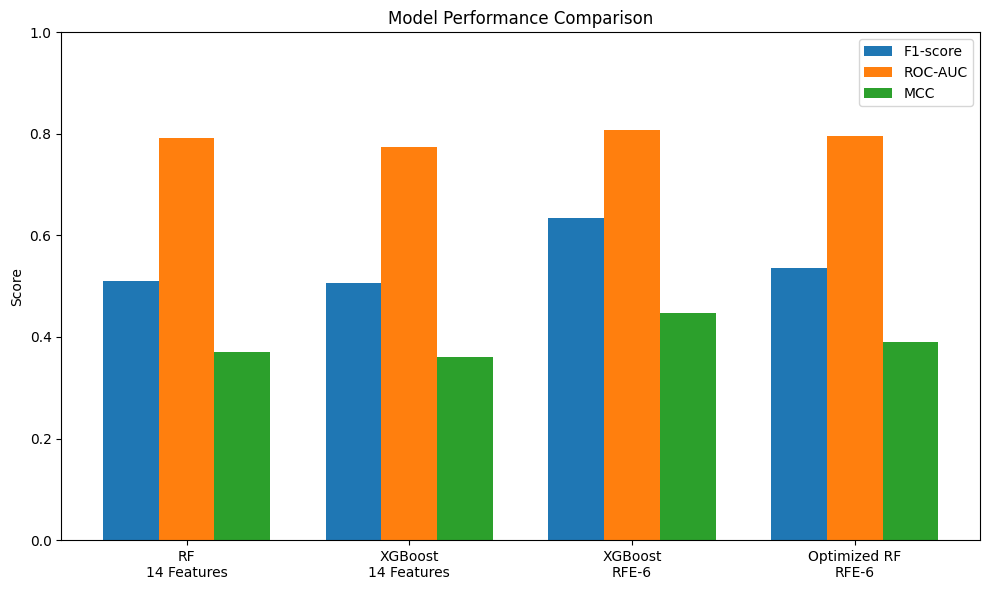

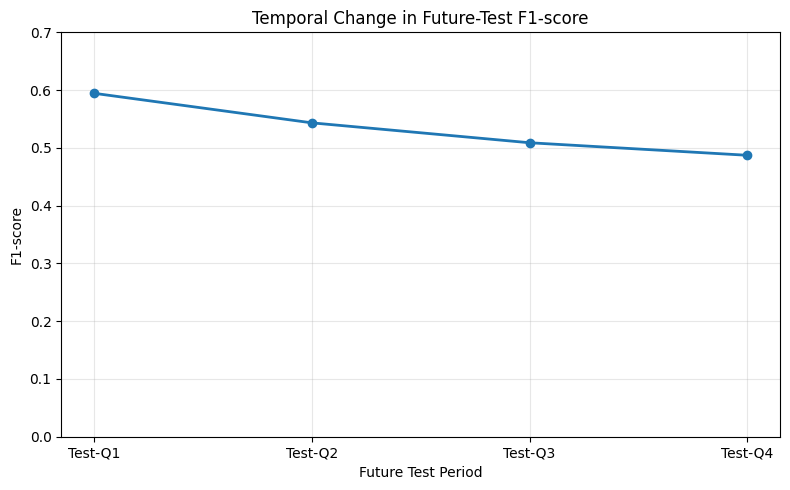

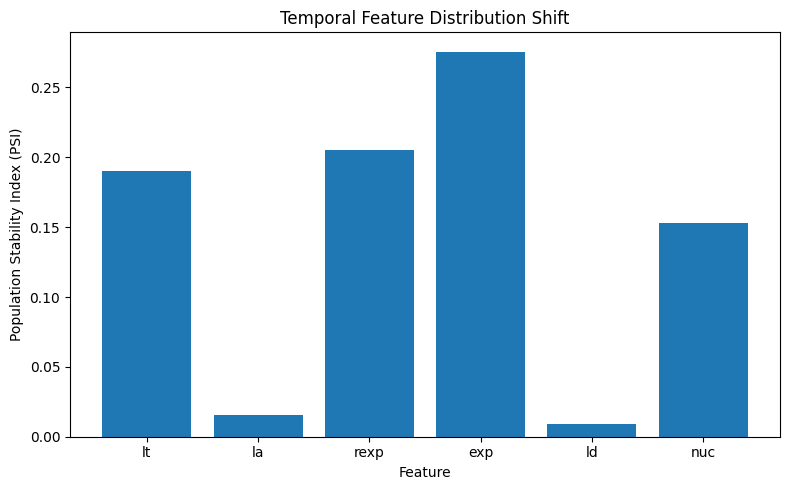

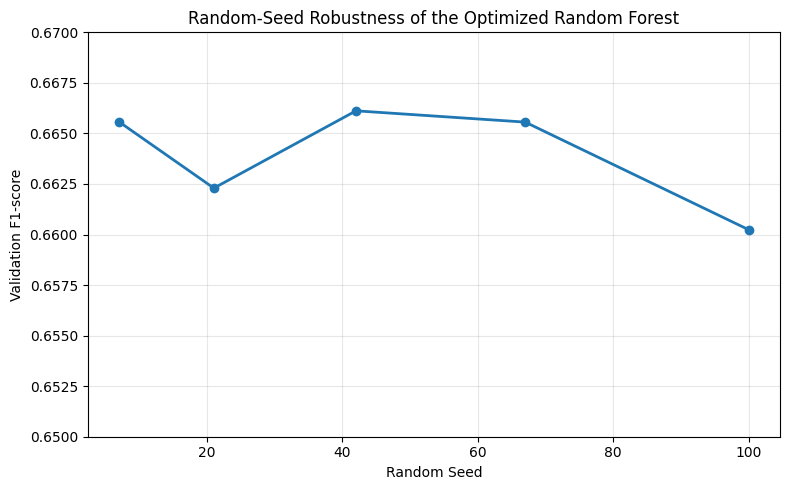

===== FIGURES GENERATED =====
Figure_1_Model_Comparison.png
Figure_2_Temporal_F1.png
Figure_3_Feature_PSI.png
Figure_4_Seed_Robustness.png


In [55]:
# ===== STEP 37: GENERATE RESEARCH FIGURES =====

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# FIGURE 1: MODEL PERFORMANCE COMPARISON
# ---------------------------------------------------------

models = comparison["Model"].tolist()

f1_values = comparison["F1"].values
auc_values = comparison["ROC-AUC"].values
mcc_values = comparison["MCC"].values

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    f1_values,
    width,
    label="F1-score"
)

plt.bar(
    x,
    auc_values,
    width,
    label="ROC-AUC"
)

plt.bar(
    x + width,
    mcc_values,
    width,
    label="MCC"
)

plt.xticks(
    x,
    [
        "RF\n14 Features",
        "XGBoost\n14 Features",
        "XGBoost\nRFE-6",
        "Optimized RF\nRFE-6"
    ]
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    "Figure_1_Model_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# FIGURE 2: TEMPORAL F1 DEGRADATION
# ---------------------------------------------------------

segments = segment_df["segment"].tolist()
f1_temporal = segment_df["f1"].values

plt.figure(figsize=(8, 5))

plt.plot(
    segments,
    f1_temporal,
    marker="o",
    linewidth=2
)

plt.xlabel("Future Test Period")
plt.ylabel("F1-score")
plt.title("Temporal Change in Future-Test F1-score")
plt.ylim(0, 0.7)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure_2_Temporal_F1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# FIGURE 3: FEATURE DISTRIBUTION SHIFT
# ---------------------------------------------------------

features_plot = psi_df["feature"].tolist()
psi_values = psi_df["PSI"].values

plt.figure(figsize=(8, 5))

plt.bar(
    features_plot,
    psi_values
)

plt.xlabel("Feature")
plt.ylabel("Population Stability Index (PSI)")
plt.title("Temporal Feature Distribution Shift")

plt.tight_layout()

plt.savefig(
    "Figure_3_Feature_PSI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# FIGURE 4: RANDOM-SEED ROBUSTNESS
# ---------------------------------------------------------

seed_data = pd.DataFrame({
    "seed": [7, 21, 42, 67, 100],
    "f1": [
        0.665571,
        0.662295,
        0.666118,
        0.665560,
        0.660241
    ]
})

plt.figure(figsize=(8, 5))

plt.plot(
    seed_data["seed"],
    seed_data["f1"],
    marker="o",
    linewidth=2
)

plt.xlabel("Random Seed")
plt.ylabel("Validation F1-score")
plt.title("Random-Seed Robustness of the Optimized Random Forest")

plt.ylim(0.65, 0.67)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure_4_Seed_Robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("===== FIGURES GENERATED =====")

print("Figure_1_Model_Comparison.png")
print("Figure_2_Temporal_F1.png")
print("Figure_3_Feature_PSI.png")
print("Figure_4_Seed_Robustness.png")

In [56]:
# ===== STEP 39: BUG RATE vs TEMPORAL F1 =====

bug_rate = segment_df["bug_rate"]
temporal_f1 = segment_df["f1"]

correlation = bug_rate.corr(temporal_f1)

print("===== BUG RATE vs F1 =====")

print("Pearson correlation:", round(correlation, 4))

print("\nSegment-wise values:")

print(
    segment_df[
        ["segment", "bug_rate", "f1", "roc_auc"]
    ].to_string(index=False)
)

===== BUG RATE vs F1 =====
Pearson correlation: 0.9456

Segment-wise values:
segment  bug_rate       f1  roc_auc
Test-Q1  0.256028 0.594502 0.804621
Test-Q2  0.221839 0.543353 0.800093
Test-Q3  0.213793 0.508876 0.767096
Test-Q4  0.171264 0.487179 0.806337


In [57]:
# ============================================================
# STEP 27: PERIODIC ADAPTIVE RANDOM FOREST
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

print("===== STEP 27: PERIODIC ADAPTIVE RANDOM FOREST =====")

# ------------------------------------------------------------
# 1. Make sure data is chronologically ordered
# ------------------------------------------------------------

train_adaptive = train_df.sort_values(
    "author_datetime"
).copy()

test_adaptive = test_df.sort_values(
    "author_datetime"
).copy()

# ------------------------------------------------------------
# 2. Selected RFE-6 features
# ------------------------------------------------------------

selected_features = [
    "lt",
    "la",
    "rexp",
    "exp",
    "ld",
    "nuc"
]

target_column = "contains_bug"

# ------------------------------------------------------------
# 3. Divide future test data into 4 chronological periods
# ------------------------------------------------------------

test_quarters = np.array_split(test_adaptive, 4)

for i, q in enumerate(test_quarters, start=1):
    print(
        f"Test-Q{i}: {len(q)} records | "
        f"{q['author_datetime'].min()} "
        f"to "
        f"{q['author_datetime'].max()}"
    )

# ------------------------------------------------------------
# 4. Initial adaptive training data
# ------------------------------------------------------------

adaptive_train = train_adaptive.copy()

adaptive_results = []

# ------------------------------------------------------------
# 5. Process each future period sequentially
# ------------------------------------------------------------

for i, quarter in enumerate(test_quarters, start=1):

    print("\n" + "=" * 60)
    print(f"ADAPTIVE PERIOD: TEST-Q{i}")
    print("=" * 60)

    X_train_adaptive = adaptive_train[selected_features]
    y_train_adaptive = adaptive_train[target_column]

    X_current = quarter[selected_features]
    y_current = quarter[target_column]

    # --------------------------------------------------------
    # Train model using all currently available historical data
    # --------------------------------------------------------

    adaptive_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    adaptive_model.fit(
        X_train_adaptive,
        y_train_adaptive
    )

    # --------------------------------------------------------
    # Predict current future period
    # --------------------------------------------------------

    current_pred = adaptive_model.predict(X_current)
    current_prob = adaptive_model.predict_proba(X_current)[:, 1]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_current,
        current_pred
    )

    precision = precision_score(
        y_current,
        current_pred,
        zero_division=0
    )

    recall = recall_score(
        y_current,
        current_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_current,
        current_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_current,
        current_prob
    )

    mcc = matthews_corrcoef(
        y_current,
        current_pred
    )

    bug_rate = y_current.mean()

    adaptive_results.append({
        "segment": f"Test-Q{i}",
        "records": len(quarter),
        "bug_rate": bug_rate,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc,
        "mcc": mcc
    })

    print(f"Training records used: {len(adaptive_train)}")
    print(f"Test records: {len(quarter)}")
    print(f"Bug rate: {bug_rate:.4f}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"MCC      : {mcc:.4f}")

    # --------------------------------------------------------
    # IMPORTANT:
    # After prediction, current labels become available.
    # Add this period to the training data for next period.
    # --------------------------------------------------------

    adaptive_train = pd.concat(
        [adaptive_train, quarter],
        ignore_index=True
    )

    print(
        f"Updated training records for next period: "
        f"{len(adaptive_train)}"
    )


# ------------------------------------------------------------
# 6. Create results DataFrame
# ------------------------------------------------------------

adaptive_results_df = pd.DataFrame(
    adaptive_results
)

print("\n")
print("===== PERIODIC ADAPTIVE RF RESULTS =====")
print(
    adaptive_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# ------------------------------------------------------------
# 7. Mean performance
# ------------------------------------------------------------

print("\n===== ADAPTIVE MEAN PERFORMANCE =====")

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "mcc"
]:
    print(
        f"{metric:10s}: "
        f"{adaptive_results_df[metric].mean():.4f}"
    )

===== STEP 27: PERIODIC ADAPTIVE RANDOM FOREST =====
Test-Q1: 871 records | 2014-03-13 19:05:51 to 2014-06-25 23:50:30
Test-Q2: 870 records | 2014-06-26 04:48:42 to 2014-09-30 17:03:49
Test-Q3: 870 records | 2014-09-30 18:13:40 to 2015-07-07 11:09:32
Test-Q4: 870 records | 2015-07-07 20:41:51 to 2017-12-07 16:32:11

ADAPTIVE PERIOD: TEST-Q1


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Training records used: 8120
Test records: 871
Bug rate: 0.2560
Accuracy : 0.7313
Precision: 0.4844
Recall   : 0.7668
F1-score : 0.5938
ROC-AUC  : 0.8046
MCC      : 0.4320
Updated training records for next period: 8991

ADAPTIVE PERIOD: TEST-Q2
Training records used: 8991
Test records: 870
Bug rate: 0.2218
Accuracy : 0.7299
Precision: 0.4344
Recall   : 0.7202
F1-score : 0.5419
ROC-AUC  : 0.7984
MCC      : 0.3902
Updated training records for next period: 9861

ADAPTIVE PERIOD: TEST-Q3
Training records used: 9861
Test records: 870
Bug rate: 0.2138
Accuracy : 0.7172
Precision: 0.4068
Recall   : 0.7043
F1-score : 0.5157
ROC-AUC  : 0.7711
MCC      : 0.3609
Updated training records for next period: 10731

ADAPTIVE PERIOD: TEST-Q4
Training records used: 10731
Test records: 870
Bug rate: 0.1713
Accuracy : 0.7253
Precision: 0.3567
Recall   : 0.7517
F1-score : 0.4838
ROC-AUC  : 0.8049
MCC      : 0.3699
Updated training records for next period: 11601


===== PERIODIC ADAPTIVE RF RESULTS =====
segm

In [58]:
# ===== FIX: CREATE TEST PERIOD VARIABLES =====

# Sort final test data chronologically
test_adaptive = test_df.sort_values("author_datetime").reset_index(drop=True)

# Split into the same 4 chronological periods used in Step 27
test_quarters = np.array_split(test_adaptive, 4)

# Extract features and target for each period
X_test_q1 = test_quarters[0][selected_features]
y_test_q1 = test_quarters[0]["contains_bug"]

X_test_q2 = test_quarters[1][selected_features]
y_test_q2 = test_quarters[1]["contains_bug"]

X_test_q3 = test_quarters[2][selected_features]
y_test_q3 = test_quarters[2]["contains_bug"]

X_test_q4 = test_quarters[3][selected_features]
y_test_q4 = test_quarters[3]["contains_bug"]

print("===== TEST PERIOD VARIABLES CREATED =====")

print("Test-Q1:", X_test_q1.shape, y_test_q1.shape)
print("Test-Q2:", X_test_q2.shape, y_test_q2.shape)
print("Test-Q3:", X_test_q3.shape, y_test_q3.shape)
print("Test-Q4:", X_test_q4.shape, y_test_q4.shape)

print("\nPeriod sizes:")
for i, q in enumerate(test_quarters, 1):
    print(f"Test-Q{i}: {len(q)} records")

===== TEST PERIOD VARIABLES CREATED =====
Test-Q1: (871, 6) (871,)
Test-Q2: (870, 6) (870,)
Test-Q3: (870, 6) (870,)
Test-Q4: (870, 6) (870,)

Period sizes:
Test-Q1: 871 records
Test-Q2: 870 records
Test-Q3: 870 records
Test-Q4: 870 records


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [59]:
# ============================================================
# STEP 28: RECENCY-AWARE SLIDING-WINDOW ADAPTATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

print("===== STEP 28: RECENCY-AWARE SLIDING-WINDOW ADAPTATION =====")

# ------------------------------------------------------------
# 1. Selected RFE-6 features
# ------------------------------------------------------------

selected_features = [
    "lt",
    "la",
    "rexp",
    "exp",
    "ld",
    "nuc"
]

target_column = "contains_bug"

# ------------------------------------------------------------
# 2. Prepare historical training data
# ------------------------------------------------------------

history_df = train_df.sort_values(
    "author_datetime"
).reset_index(drop=True)

# ------------------------------------------------------------
# 3. Prepare final test data chronologically
# ------------------------------------------------------------

test_adaptive = test_df.sort_values(
    "author_datetime"
).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Split future test data into 4 chronological periods
# ------------------------------------------------------------

test_quarters = np.array_split(
    test_adaptive,
    4
)

test_periods = []

for i, quarter in enumerate(test_quarters, start=1):

    X_period = quarter[selected_features].copy()
    y_period = quarter[target_column].copy()

    test_periods.append(
        (f"Test-Q{i}", X_period, y_period)
    )

    print(
        f"Test-Q{i}: {len(quarter)} records | "
        f"{quarter['author_datetime'].min()} to "
        f"{quarter['author_datetime'].max()}"
    )

# ------------------------------------------------------------
# 5. Sliding-window sizes
# ------------------------------------------------------------

WINDOWS = [
    2000,
    4000,
    6000,
    8000
]

results = []

# ------------------------------------------------------------
# 6. Evaluate each window
# ------------------------------------------------------------

for window in WINDOWS:

    print("\n" + "=" * 65)
    print(f"SLIDING WINDOW = {window}")
    print("=" * 65)

    # Start with original historical data
    current_X = history_df[selected_features].copy()
    current_y = history_df[target_column].copy()

    for segment, X_period, y_period in test_periods:

        # ----------------------------------------------------
        # Select only the most recent training records
        # ----------------------------------------------------

        if len(current_X) > window:

            train_X_window = current_X.iloc[-window:]
            train_y_window = current_y.iloc[-window:]

        else:

            train_X_window = current_X
            train_y_window = current_y

        # ----------------------------------------------------
        # Create Random Forest
        # ----------------------------------------------------

        model = RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            min_samples_split=2,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        model.fit(
            train_X_window,
            train_y_window
        )

        # ----------------------------------------------------
        # Predict
        # ----------------------------------------------------

        predictions = model.predict(
            X_period
        )

        probabilities = model.predict_proba(
            X_period
        )[:, 1]

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_period,
            predictions
        )

        precision = precision_score(
            y_period,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_period,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_period,
            predictions,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_period,
            probabilities
        )

        mcc = matthews_corrcoef(
            y_period,
            predictions
        )

        bug_rate = y_period.mean()

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        results.append({
            "window": window,
            "segment": segment,
            "records": len(X_period),
            "training_records": len(train_X_window),
            "bug_rate": bug_rate,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc,
            "mcc": mcc
        })

        print(
            f"{segment} | "
            f"Training={len(train_X_window)} | "
            f"F1={f1:.4f} | "
            f"AUC={roc_auc:.4f} | "
            f"MCC={mcc:.4f}"
        )

        # ----------------------------------------------------
        # Reveal current period after prediction
        # and add it to future training history
        # ----------------------------------------------------

        current_X = pd.concat(
            [
                current_X,
                X_period
            ],
            ignore_index=True
        )

        current_y = pd.concat(
            [
                current_y.reset_index(drop=True),
                y_period.reset_index(drop=True)
            ],
            ignore_index=True
        )


# ------------------------------------------------------------
# 7. Convert results to DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n")
print("===== RECENCY-AWARE RESULTS =====")

print(
    results_df.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 8. Mean performance for each window
# ------------------------------------------------------------

print("\n")
print("===== MEAN PERFORMANCE BY WINDOW =====")

window_summary = (
    results_df
    .groupby("window")
    [
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "mcc"
        ]
    ]
    .mean()
    .sort_values(
        "f1",
        ascending=False
    )
)

print(
    window_summary.round(4).to_string()
)

# ------------------------------------------------------------
# 9. F1 comparison by temporal period
# ------------------------------------------------------------

print("\n")
print("===== F1 BY TEMPORAL PERIOD =====")

f1_table = results_df.pivot(
    index="segment",
    columns="window",
    values="f1"
)

print(
    f1_table.round(4).to_string()
)

# ------------------------------------------------------------
# 10. Best window
# ------------------------------------------------------------

best_window = window_summary.index[0]
best_f1 = window_summary.iloc[0]["f1"]

print("\n")
print("===== BEST RECENCY WINDOW =====")
print("Best window:", best_window)
print(f"Mean F1: {best_f1:.4f}")

===== STEP 28: RECENCY-AWARE SLIDING-WINDOW ADAPTATION =====
Test-Q1: 871 records | 2014-03-13 19:05:51 to 2014-06-25 23:50:30
Test-Q2: 870 records | 2014-06-26 04:48:42 to 2014-09-30 17:03:49
Test-Q3: 870 records | 2014-09-30 18:13:40 to 2015-07-07 11:09:32
Test-Q4: 870 records | 2015-07-07 20:41:51 to 2017-12-07 16:32:11

SLIDING WINDOW = 2000


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Test-Q1 | Training=2000 | F1=0.5802 | AUC=0.8025 | MCC=0.4116
Test-Q2 | Training=2000 | F1=0.5526 | AUC=0.8030 | MCC=0.4055
Test-Q3 | Training=2000 | F1=0.5137 | AUC=0.7512 | MCC=0.3584
Test-Q4 | Training=2000 | F1=0.4936 | AUC=0.8003 | MCC=0.3750

SLIDING WINDOW = 4000
Test-Q1 | Training=4000 | F1=0.5848 | AUC=0.8037 | MCC=0.4182
Test-Q2 | Training=4000 | F1=0.5603 | AUC=0.8036 | MCC=0.4165
Test-Q3 | Training=4000 | F1=0.5312 | AUC=0.7618 | MCC=0.3832
Test-Q4 | Training=4000 | F1=0.4928 | AUC=0.8006 | MCC=0.3753

SLIDING WINDOW = 6000
Test-Q1 | Training=6000 | F1=0.5927 | AUC=0.8070 | MCC=0.4304
Test-Q2 | Training=6000 | F1=0.5416 | AUC=0.8031 | MCC=0.3898
Test-Q3 | Training=6000 | F1=0.5138 | AUC=0.7783 | MCC=0.3581
Test-Q4 | Training=6000 | F1=0.4942 | AUC=0.8076 | MCC=0.3797

SLIDING WINDOW = 8000
Test-Q1 | Training=8000 | F1=0.5892 | AUC=0.8053 | MCC=0.4257
Test-Q2 | Training=8000 | F1=0.5455 | AUC=0.8015 | MCC=0.3956
Test-Q3 | Training=8000 | F1=0.5165 | AUC=0.7739 | MCC=0.3623
T

In [60]:
# ============================================================
# STEP 29: STATIC vs ADAPTIVE TEMPORAL COMPARISON
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

print("===== STEP 29: STATIC vs ADAPTIVE TEMPORAL COMPARISON =====")

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

selected_features = [
    "lt",
    "la",
    "rexp",
    "exp",
    "ld",
    "nuc"
]

target_column = "contains_bug"

# ------------------------------------------------------------
# 2. Historical data
# ------------------------------------------------------------

historical_df = (
    train_df
    .sort_values("author_datetime")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Final test data
# ------------------------------------------------------------

future_df = (
    test_df
    .sort_values("author_datetime")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Create the same four temporal periods
# ------------------------------------------------------------

test_quarters = np.array_split(
    future_df,
    4
)

test_periods = []

for i, quarter in enumerate(test_quarters, start=1):

    X_q = quarter[selected_features].copy()
    y_q = quarter[target_column].copy()

    test_periods.append(
        (f"Test-Q{i}", X_q, y_q)
    )

# ------------------------------------------------------------
# 5. Function to create the frozen RF
# ------------------------------------------------------------

def create_rf():

    return RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

# ------------------------------------------------------------
# 6. Metric function
# ------------------------------------------------------------

def calculate_metrics(y_true, predictions, probabilities):

    return {
        "accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),

        "mcc": matthews_corrcoef(
            y_true,
            predictions
        )
    }

# ------------------------------------------------------------
# 7. Train the frozen model ONCE
# ------------------------------------------------------------

frozen_model = create_rf()

frozen_model.fit(
    historical_df[selected_features],
    historical_df[target_column]
)

# ------------------------------------------------------------
# 8. Storage
# ------------------------------------------------------------

comparison_results = []

# ============================================================
# MODEL 1: FROZEN MODEL
# ============================================================

print("\n" + "=" * 65)
print("MODEL 1: FROZEN RF + RFE-6")
print("=" * 65)

for segment, X_q, y_q in test_periods:

    pred = frozen_model.predict(X_q)
    prob = frozen_model.predict_proba(X_q)[:, 1]

    metrics = calculate_metrics(
        y_q,
        pred,
        prob
    )

    comparison_results.append({
        "model": "Frozen RF",
        "segment": segment,
        **metrics
    })

    print(
        f"{segment} | "
        f"F1={metrics['f1']:.4f} | "
        f"AUC={metrics['roc_auc']:.4f} | "
        f"MCC={metrics['mcc']:.4f}"
    )

# ============================================================
# MODEL 2: CUMULATIVE ADAPTIVE
# ============================================================

print("\n" + "=" * 65)
print("MODEL 2: CUMULATIVE ADAPTIVE RF")
print("=" * 65)

current_data = historical_df.copy()

for segment, X_q, y_q in test_periods:

    model = create_rf()

    model.fit(
        current_data[selected_features],
        current_data[target_column]
    )

    pred = model.predict(X_q)
    prob = model.predict_proba(X_q)[:, 1]

    metrics = calculate_metrics(
        y_q,
        pred,
        prob
    )

    comparison_results.append({
        "model": "Cumulative Adaptive RF",
        "segment": segment,
        **metrics
    })

    print(
        f"{segment} | "
        f"F1={metrics['f1']:.4f} | "
        f"AUC={metrics['roc_auc']:.4f} | "
        f"MCC={metrics['mcc']:.4f}"
    )

    # Reveal this period after prediction
    new_rows = test_quarters[
        int(segment[-1]) - 1
    ]

    current_data = pd.concat(
        [
            current_data,
            new_rows
        ],
        ignore_index=True
    )

# ============================================================
# MODELS 3-6: SLIDING WINDOWS
# ============================================================

WINDOWS = [2000, 4000, 6000, 8000]

for window in WINDOWS:

    print("\n" + "=" * 65)
    print(
        f"SLIDING WINDOW RF: {window} RECORDS"
    )
    print("=" * 65)

    current_data = historical_df.copy()

    for segment, X_q, y_q in test_periods:

        # Keep only recent historical records
        if len(current_data) > window:

            training_data = current_data.iloc[-window:]

        else:

            training_data = current_data

        model = create_rf()

        model.fit(
            training_data[selected_features],
            training_data[target_column]
        )

        pred = model.predict(X_q)
        prob = model.predict_proba(X_q)[:, 1]

        metrics = calculate_metrics(
            y_q,
            pred,
            prob
        )

        comparison_results.append({
            "model": f"Sliding Window {window}",
            "segment": segment,
            **metrics
        })

        print(
            f"{segment} | "
            f"Training={len(training_data)} | "
            f"F1={metrics['f1']:.4f} | "
            f"AUC={metrics['roc_auc']:.4f} | "
            f"MCC={metrics['mcc']:.4f}"
        )

        # Reveal the current period
        new_rows = test_quarters[
            int(segment[-1]) - 1
        ]

        current_data = pd.concat(
            [
                current_data,
                new_rows
            ],
            ignore_index=True
        )

# ============================================================
# 9. Final comparison DataFrame
# ============================================================

comparison_df = pd.DataFrame(
    comparison_results
)

print("\n")
print("=" * 65)
print("===== COMPLETE TEMPORAL COMPARISON =====")
print("=" * 65)

print(
    comparison_df[
        [
            "model",
            "segment",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "mcc"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# ============================================================
# 10. Mean performance
# ============================================================

print("\n")
print("=" * 65)
print("===== MEAN PERFORMANCE BY MODEL =====")
print("=" * 65)

mean_comparison = (
    comparison_df
    .groupby("model")
    [
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "mcc"
        ]
    ]
    .mean()
    .sort_values(
        "f1",
        ascending=False
    )
)

print(
    mean_comparison
    .round(4)
    .to_string()
)

# ============================================================
# 11. F1 by temporal period
# ============================================================

print("\n")
print("=" * 65)
print("===== F1 BY TEMPORAL PERIOD =====")
print("=" * 65)

f1_temporal = comparison_df.pivot(
    index="segment",
    columns="model",
    values="f1"
)

print(
    f1_temporal
    .round(4)
    .to_string()
)

# ============================================================
# 12. F1 change from Q1 to Q4
# ============================================================

print("\n")
print("=" * 65)
print("===== F1 CHANGE: Q1 → Q4 =====")
print("=" * 65)

for model_name in comparison_df["model"].unique():

    model_data = comparison_df[
        comparison_df["model"] == model_name
    ]

    q1_f1 = model_data[
        model_data["segment"] == "Test-Q1"
    ]["f1"].iloc[0]

    q4_f1 = model_data[
        model_data["segment"] == "Test-Q4"
    ]["f1"].iloc[0]

    change = q4_f1 - q1_f1

    print(
        f"{model_name}: "
        f"Q1={q1_f1:.4f}, "
        f"Q4={q4_f1:.4f}, "
        f"Change={change:+.4f}"
    )

# ============================================================
# 13. Best model
# ============================================================

best_model = mean_comparison.index[0]

best_f1 = mean_comparison.loc[
    best_model,
    "f1"
]

print("\n")
print("=" * 65)
print("===== BEST TEMPORAL ADAPTATION STRATEGY =====")
print("=" * 65)

print("Best model:", best_model)
print(f"Mean F1: {best_f1:.4f}")

===== STEP 29: STATIC vs ADAPTIVE TEMPORAL COMPARISON =====


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)



MODEL 1: FROZEN RF + RFE-6
Test-Q1 | F1=0.5938 | AUC=0.8046 | MCC=0.4320
Test-Q2 | F1=0.5465 | AUC=0.7997 | MCC=0.3971
Test-Q3 | F1=0.5128 | AUC=0.7673 | MCC=0.3566
Test-Q4 | F1=0.4882 | AUC=0.8061 | MCC=0.3772

MODEL 2: CUMULATIVE ADAPTIVE RF
Test-Q1 | F1=0.5938 | AUC=0.8046 | MCC=0.4320
Test-Q2 | F1=0.5419 | AUC=0.7984 | MCC=0.3902
Test-Q3 | F1=0.5157 | AUC=0.7711 | MCC=0.3609
Test-Q4 | F1=0.4838 | AUC=0.8049 | MCC=0.3699

SLIDING WINDOW RF: 2000 RECORDS
Test-Q1 | Training=2000 | F1=0.5802 | AUC=0.8025 | MCC=0.4116
Test-Q2 | Training=2000 | F1=0.5526 | AUC=0.8030 | MCC=0.4055
Test-Q3 | Training=2000 | F1=0.5137 | AUC=0.7512 | MCC=0.3584
Test-Q4 | Training=2000 | F1=0.4936 | AUC=0.8003 | MCC=0.3750

SLIDING WINDOW RF: 4000 RECORDS
Test-Q1 | Training=4000 | F1=0.5848 | AUC=0.8037 | MCC=0.4182
Test-Q2 | Training=4000 | F1=0.5603 | AUC=0.8036 | MCC=0.4165
Test-Q3 | Training=4000 | F1=0.5312 | AUC=0.7618 | MCC=0.3832
Test-Q4 | Training=4000 | F1=0.4928 | AUC=0.8006 | MCC=0.3753

SLIDING 

In [61]:
# ============================================================
# STEP 30: TEMPORAL ADAPTIVE THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

print("===== STEP 30: TEMPORAL ADAPTIVE THRESHOLD ANALYSIS =====")

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

selected_features = [
    "lt",
    "la",
    "rexp",
    "exp",
    "ld",
    "nuc"
]

target_column = "contains_bug"

WINDOW_SIZE = 4000

THRESHOLDS = np.arange(
    0.20,
    0.81,
    0.05
)

# ------------------------------------------------------------
# 2. Historical data
# ------------------------------------------------------------

historical_df = (
    train_df
    .sort_values("author_datetime")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Final test data
# ------------------------------------------------------------

future_df = (
    test_df
    .sort_values("author_datetime")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Create chronological test periods
# ------------------------------------------------------------

test_quarters = np.array_split(
    future_df,
    4
)

test_periods = []

for i, quarter in enumerate(test_quarters, start=1):

    X_q = quarter[selected_features].copy()
    y_q = quarter[target_column].copy()

    test_periods.append(
        (f"Test-Q{i}", X_q, y_q)
    )

# ------------------------------------------------------------
# 5. Random Forest function
# ------------------------------------------------------------

def create_rf():

    return RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

# ------------------------------------------------------------
# 6. Threshold selection function
# ------------------------------------------------------------

def find_best_threshold(
    X_train,
    y_train,
    thresholds
):

    # Use the most recent part of the available
    # historical data for threshold calibration.

    calibration_size = min(
        1000,
        len(X_train)
    )

    calibration_X = X_train.iloc[-calibration_size:]
    calibration_y = y_train.iloc[-calibration_size:]

    # Train calibration model
    calibration_model = create_rf()

    calibration_model.fit(
        X_train.iloc[:-calibration_size],
        y_train.iloc[:-calibration_size]
    )

    calibration_prob = calibration_model.predict_proba(
        calibration_X
    )[:, 1]

    best_threshold = 0.50
    best_f1 = -1

    threshold_results = []

    for threshold in thresholds:

        calibration_pred = (
            calibration_prob >= threshold
        ).astype(int)

        score = f1_score(
            calibration_y,
            calibration_pred,
            zero_division=0
        )

        threshold_results.append({
            "threshold": threshold,
            "f1": score
        })

        if score > best_f1:

            best_f1 = score
            best_threshold = threshold

    return best_threshold, best_f1


# ============================================================
# 7. Evaluate FIXED threshold = 0.50
# ============================================================

print("\n" + "=" * 65)
print("MODEL A: FIXED THRESHOLD = 0.50")
print("=" * 65)

fixed_results = []

current_data = historical_df.copy()

for segment, X_q, y_q in test_periods:

    # Use recent 4000 historical records
    if len(current_data) > WINDOW_SIZE:
        training_data = current_data.iloc[-WINDOW_SIZE:]
    else:
        training_data = current_data

    model = create_rf()

    model.fit(
        training_data[selected_features],
        training_data[target_column]
    )

    probabilities = model.predict_proba(
        X_q
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    metrics = {
        "model": "Fixed Threshold",
        "segment": segment,
        "threshold": 0.50,
        "accuracy": accuracy_score(
            y_q,
            predictions
        ),
        "precision": precision_score(
            y_q,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_q,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_q,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_q,
            probabilities
        ),
        "mcc": matthews_corrcoef(
            y_q,
            predictions
        )
    }

    fixed_results.append(metrics)

    print(
        f"{segment} | "
        f"Threshold=0.50 | "
        f"F1={metrics['f1']:.4f} | "
        f"AUC={metrics['roc_auc']:.4f} | "
        f"MCC={metrics['mcc']:.4f}"
    )

    # Reveal current test period after prediction
    current_data = pd.concat(
        [
            current_data,
            future_df.iloc[
                sum(len(x) for x in test_quarters[:int(segment[-1])-1]):
                sum(len(x) for x in test_quarters[:int(segment[-1])])
            ]
        ],
        ignore_index=True
    )


# ============================================================
# 8. ADAPTIVE THRESHOLD
# ============================================================

print("\n" + "=" * 65)
print("MODEL B: ADAPTIVE TEMPORAL THRESHOLD")
print("=" * 65)

adaptive_results = []

current_data = historical_df.copy()

for segment, X_q, y_q in test_periods:

    # --------------------------------------------------------
    # Select recent historical data
    # --------------------------------------------------------

    if len(current_data) > WINDOW_SIZE:

        training_data = current_data.iloc[-WINDOW_SIZE:]

    else:

        training_data = current_data

    X_train = training_data[
        selected_features
    ].reset_index(drop=True)

    y_train = training_data[
        target_column
    ].reset_index(drop=True)

    # --------------------------------------------------------
    # Find threshold using ONLY historical data
    # --------------------------------------------------------

    threshold, calibration_f1 = find_best_threshold(
        X_train,
        y_train,
        THRESHOLDS
    )

    # --------------------------------------------------------
    # Train final model using available history
    # --------------------------------------------------------

    model = create_rf()

    model.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # Predict future period
    # --------------------------------------------------------

    probabilities = model.predict_proba(
        X_q
    )[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    metrics = {
        "model": "Adaptive Threshold",
        "segment": segment,
        "threshold": threshold,
        "calibration_f1": calibration_f1,
        "accuracy": accuracy_score(
            y_q,
            predictions
        ),
        "precision": precision_score(
            y_q,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_q,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_q,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_q,
            probabilities
        ),
        "mcc": matthews_corrcoef(
            y_q,
            predictions
        )
    }

    adaptive_results.append(metrics)

    print(
        f"{segment} | "
        f"Threshold={threshold:.2f} | "
        f"Calibration F1={calibration_f1:.4f} | "
        f"Test F1={metrics['f1']:.4f} | "
        f"AUC={metrics['roc_auc']:.4f} | "
        f"MCC={metrics['mcc']:.4f}"
    )

    # --------------------------------------------------------
    # Reveal current test period AFTER prediction
    # --------------------------------------------------------

    q_number = int(segment[-1])

    start_index = sum(
        len(x)
        for x in test_quarters[:q_number - 1]
    )

    end_index = sum(
        len(x)
        for x in test_quarters[:q_number]
    )

    current_data = pd.concat(
        [
            current_data,
            future_df.iloc[start_index:end_index]
        ],
        ignore_index=True
    )


# ============================================================
# 9. Convert results to DataFrames
# ============================================================

fixed_df = pd.DataFrame(
    fixed_results
)

adaptive_df = pd.DataFrame(
    adaptive_results
)

threshold_comparison = pd.concat(
    [
        fixed_df,
        adaptive_df
    ],
    ignore_index=True
)

# ============================================================
# 10. Print detailed results
# ============================================================

print("\n")
print("=" * 65)
print("===== THRESHOLD COMPARISON =====")
print("=" * 65)

print(
    threshold_comparison[
        [
            "model",
            "segment",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "mcc"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# ============================================================
# 11. Mean performance
# ============================================================

print("\n")
print("=" * 65)
print("===== MEAN PERFORMANCE =====")
print("=" * 65)

mean_threshold_results = (
    threshold_comparison
    .groupby("model")
    [
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "mcc"
        ]
    ]
    .mean()
)

print(
    mean_threshold_results
    .round(4)
    .to_string()
)

# ============================================================
# 12. F1 improvement
# ============================================================

fixed_mean_f1 = (
    fixed_df["f1"].mean()
)

adaptive_mean_f1 = (
    adaptive_df["f1"].mean()
)

f1_improvement = (
    adaptive_mean_f1 -
    fixed_mean_f1
)

print("\n")
print("=" * 65)
print("===== ADAPTIVE THRESHOLD IMPROVEMENT =====")
print("=" * 65)

print(
    f"Fixed threshold mean F1    : "
    f"{fixed_mean_f1:.4f}"
)

print(
    f"Adaptive threshold mean F1 : "
    f"{adaptive_mean_f1:.4f}"
)

print(
    f"F1 improvement              : "
    f"{f1_improvement:+.4f}"
)

if fixed_mean_f1 != 0:

    relative_improvement = (
        f1_improvement /
        fixed_mean_f1
    ) * 100

    print(
        f"Relative improvement       : "
        f"{relative_improvement:+.2f}%"
    )

# ============================================================
# 13. Threshold evolution
# ============================================================

print("\n")
print("=" * 65)
print("===== ADAPTIVE THRESHOLD EVOLUTION =====")
print("=" * 65)

print(
    adaptive_df[
        [
            "segment",
            "threshold",
            "calibration_f1",
            "f1",
            "roc_auc",
            "mcc"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# ============================================================
# 14. Final conclusion
# ============================================================

if adaptive_mean_f1 > fixed_mean_f1:

    print("\nAdaptive threshold improved mean F1.")

else:

    print("\nAdaptive threshold did not improve mean F1.")

print("\n===== STEP 30 COMPLETE =====")

===== STEP 30: TEMPORAL ADAPTIVE THRESHOLD ANALYSIS =====

MODEL A: FIXED THRESHOLD = 0.50


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Test-Q1 | Threshold=0.50 | F1=0.5848 | AUC=0.8037 | MCC=0.4182
Test-Q2 | Threshold=0.50 | F1=0.5603 | AUC=0.8036 | MCC=0.4165
Test-Q3 | Threshold=0.50 | F1=0.5312 | AUC=0.7618 | MCC=0.3832
Test-Q4 | Threshold=0.50 | F1=0.4928 | AUC=0.8006 | MCC=0.3753

MODEL B: ADAPTIVE TEMPORAL THRESHOLD
Test-Q1 | Threshold=0.55 | Calibration F1=0.6639 | Test F1=0.5925 | AUC=0.8037 | MCC=0.4300
Test-Q2 | Threshold=0.45 | Calibration F1=0.5989 | Test F1=0.5465 | AUC=0.8036 | MCC=0.3971
Test-Q3 | Threshold=0.55 | Calibration F1=0.5513 | Test F1=0.5336 | AUC=0.7618 | MCC=0.3872
Test-Q4 | Threshold=0.55 | Calibration F1=0.5358 | Test F1=0.5054 | AUC=0.8006 | MCC=0.3900


===== THRESHOLD COMPARISON =====
             model segment  threshold  accuracy  precision  recall     f1  roc_auc    mcc
   Fixed Threshold Test-Q1       0.50    0.7245     0.4761  0.7578 0.5848   0.8037 0.4182
   Fixed Threshold Test-Q2       0.50    0.7529     0.4628  0.7098 0.5603   0.8036 0.4165
   Fixed Threshold Test-Q3       0.50

In [62]:
# ============================================================
# STEP 31: STATISTICAL SIGNIFICANCE TESTING
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon

print("===== STEP 31: STATISTICAL SIGNIFICANCE TESTING =====")

# ------------------------------------------------------------
# F1 scores from the temporal experiments
# ------------------------------------------------------------

f1_data = {
    "Frozen RF": [
        0.5938, 0.5465, 0.5128, 0.4882
    ],

    "Cumulative Adaptive RF": [
        0.5938, 0.5419, 0.5157, 0.4838
    ],

    "Sliding Window 2000": [
        0.5802, 0.5526, 0.5137, 0.4936
    ],

    "Sliding Window 4000": [
        0.5848, 0.5603, 0.5312, 0.4928
    ],

    "Sliding Window 6000": [
        0.5927, 0.5416, 0.5138, 0.4942
    ],

    "Sliding Window 8000": [
        0.5892, 0.5455, 0.5165, 0.4879
    ],

    "Adaptive Threshold": [
        0.5925, 0.5465, 0.5336, 0.5054
    ]
}

segments = ["Test-Q1", "Test-Q2", "Test-Q3", "Test-Q4"]

f1_df = pd.DataFrame(
    f1_data,
    index=segments
)

print("\n===== F1 SCORE BY TEMPORAL PERIOD =====")
print(f1_df.round(4))


# ------------------------------------------------------------
# Mean and standard deviation
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Mean_F1": f1_df.mean(),
    "Std_F1": f1_df.std()
})

print("\n===== MEAN ± STD F1 =====")

for model in summary.index:
    print(
        f"{model:25s}: "
        f"{summary.loc[model, 'Mean_F1']:.4f} ± "
        f"{summary.loc[model, 'Std_F1']:.4f}"
    )


# ------------------------------------------------------------
# Friedman test
# ------------------------------------------------------------

stat, p_value = friedmanchisquare(
    *[f1_df[col].values for col in f1_df.columns]
)

print("\n===== FRIEDMAN TEST =====")
print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p_value:.6f}")

if p_value < 0.05:
    print("Result    : Statistically significant difference")
else:
    print("Result    : No statistically significant difference")


# ------------------------------------------------------------
# Pairwise Wilcoxon tests against Frozen RF
# ------------------------------------------------------------

print("\n===== PAIRWISE WILCOXON TESTS =====")

baseline = f1_df["Frozen RF"]

wilcoxon_results = []

for model in f1_df.columns:

    if model == "Frozen RF":
        continue

    difference = f1_df[model] - baseline

    try:
        w_stat, p = wilcoxon(
            f1_df[model],
            baseline,
            alternative="two-sided"
        )

        mean_difference = difference.mean()

        wilcoxon_results.append({
            "Comparison": f"{model} vs Frozen RF",
            "Mean_F1_Difference": mean_difference,
            "Wilcoxon_Statistic": w_stat,
            "P_Value": p
        })

        print(
            f"{model:25s} | "
            f"Mean ΔF1={mean_difference:+.4f} | "
            f"p={p:.6f}"
        )

    except Exception as e:
        print(f"{model}: test failed -> {e}")


wilcoxon_df = pd.DataFrame(wilcoxon_results)


# ------------------------------------------------------------
# Multiple comparison correction
# ------------------------------------------------------------

if len(wilcoxon_df) > 0:

    # Bonferroni correction
    wilcoxon_df["Adjusted_P_Value"] = (
        wilcoxon_df["P_Value"] * len(wilcoxon_df)
    ).clip(upper=1.0)

    wilcoxon_df["Significant"] = (
        wilcoxon_df["Adjusted_P_Value"] < 0.05
    )

print("\n===== CORRECTED WILCOXON RESULTS =====")
print(wilcoxon_df.round(6))


# ------------------------------------------------------------
# Q1 -> Q4 degradation
# ------------------------------------------------------------

print("\n===== F1 Q1 → Q4 CHANGE =====")

degradation = []

for model in f1_df.columns:

    q1 = f1_df.loc["Test-Q1", model]
    q4 = f1_df.loc["Test-Q4", model]

    change = q4 - q1

    degradation.append({
        "Model": model,
        "Q1_F1": q1,
        "Q4_F1": q4,
        "Q1_to_Q4_Change": change
    })

    print(
        f"{model:25s}: "
        f"Q1={q1:.4f}, "
        f"Q4={q4:.4f}, "
        f"Change={change:+.4f}"
    )

degradation_df = pd.DataFrame(degradation)


# ------------------------------------------------------------
# Best model based on mean F1
# ------------------------------------------------------------

best_model = summary["Mean_F1"].idxmax()
best_f1 = summary.loc[best_model, "Mean_F1"]

print("\n===== BEST TEMPORAL STRATEGY =====")
print(f"Model    : {best_model}")
print(f"Mean F1  : {best_f1:.4f}")


# ------------------------------------------------------------
# Final Step 31 summary
# ------------------------------------------------------------

print("\n===== STEP 31 SUMMARY =====")

print(f"Friedman p-value: {p_value:.6f}")
print(f"Best mean-F1 model: {best_model}")
print(f"Best mean F1: {best_f1:.4f}")

if p_value < 0.05:
    print(
        "Conclusion: Temporal strategies show statistically "
        "significant differences in F1."
    )
else:
    print(
        "Conclusion: Differences between temporal strategies "
        "are not statistically significant at α=0.05."
    )

print("\n===== STEP 31 COMPLETE =====")

===== STEP 31: STATISTICAL SIGNIFICANCE TESTING =====

===== F1 SCORE BY TEMPORAL PERIOD =====
         Frozen RF  Cumulative Adaptive RF  Sliding Window 2000  \
Test-Q1     0.5938                  0.5938               0.5802   
Test-Q2     0.5465                  0.5419               0.5526   
Test-Q3     0.5128                  0.5157               0.5137   
Test-Q4     0.4882                  0.4838               0.4936   

         Sliding Window 4000  Sliding Window 6000  Sliding Window 8000  \
Test-Q1               0.5848               0.5927               0.5892   
Test-Q2               0.5603               0.5416               0.5455   
Test-Q3               0.5312               0.5138               0.5165   
Test-Q4               0.4928               0.4942               0.4879   

         Adaptive Threshold  
Test-Q1              0.5925  
Test-Q2              0.5465  
Test-Q3              0.5336  
Test-Q4              0.5054  

===== MEAN ± STD F1 =====
Frozen RF            

In [63]:
# ============================================================
# STEP 32: FINAL PROPOSED MODEL SELECTION
# ============================================================

import pandas as pd

print("===== STEP 32: FINAL PROPOSED MODEL SELECTION =====")

# ------------------------------------------------------------
# Results collected from previous experiments
# ------------------------------------------------------------

results = pd.DataFrame({

    "Strategy": [
        "Frozen RF",
        "Cumulative Adaptive RF",
        "Sliding Window 2000",
        "Sliding Window 4000",
        "Sliding Window 6000",
        "Sliding Window 8000",
        "Adaptive Threshold"
    ],

    "Mean_F1": [
        0.5353,
        0.5338,
        0.5350,
        0.5423,
        0.5356,
        0.5348,
        0.5445
    ],

    "Mean_AUC": [
        0.7944,
        0.7947,
        0.7892,
        0.7924,
        0.7990,
        0.7968,
        0.7924
    ],

    "Mean_MCC": [
        0.3907,
        0.3882,
        0.3876,
        0.3983,
        0.3895,
        0.3895,
        0.4011
    ],

    "Q1_Q4_F1_Change": [
        -0.1056,
        -0.1100,
        -0.0866,
        -0.0920,
        -0.0985,
        -0.1013,
        -0.0871
    ]
})

print("\n===== COMPLETE STRATEGY COMPARISON =====")
print(results.round(4))


# ------------------------------------------------------------
# Rank strategies
# ------------------------------------------------------------

results["F1_Rank"] = (
    results["Mean_F1"]
    .rank(ascending=False, method="min")
)

results["AUC_Rank"] = (
    results["Mean_AUC"]
    .rank(ascending=False, method="min")
)

results["MCC_Rank"] = (
    results["Mean_MCC"]
    .rank(ascending=False, method="min")
)

print("\n===== STRATEGY RANKING =====")
print(
    results[
        [
            "Strategy",
            "Mean_F1",
            "F1_Rank",
            "Mean_AUC",
            "AUC_Rank",
            "Mean_MCC",
            "MCC_Rank"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# Best strategy by primary metric
# ------------------------------------------------------------

best_f1_strategy = results.loc[
    results["Mean_F1"].idxmax()
]

best_auc_strategy = results.loc[
    results["Mean_AUC"].idxmax()
]

best_mcc_strategy = results.loc[
    results["Mean_MCC"].idxmax()
]

print("\n===== BEST STRATEGIES =====")

print(
    f"Best Mean F1 : "
    f"{best_f1_strategy['Strategy']} "
    f"({best_f1_strategy['Mean_F1']:.4f})"
)

print(
    f"Best Mean AUC: "
    f"{best_auc_strategy['Strategy']} "
    f"({best_auc_strategy['Mean_AUC']:.4f})"
)

print(
    f"Best Mean MCC: "
    f"{best_mcc_strategy['Strategy']} "
    f"({best_mcc_strategy['Mean_MCC']:.4f})"
)


# ------------------------------------------------------------
# Final proposed configuration
# ------------------------------------------------------------

final_configuration = {
    "Dataset": "Brackets",
    "Classifier": "Random Forest",
    "Feature Selection": "RFE",
    "Number of Features": 6,
    "Selected Features": [
        "lt",
        "la",
        "rexp",
        "exp",
        "ld",
        "nuc"
    ],
    "Sliding Window": 4000,
    "Threshold Strategy": "Adaptive Temporal Threshold",
    "Primary Metric": "F1-score",
    "Mean F1": 0.5445,
    "Mean ROC-AUC": 0.7924,
    "Mean MCC": 0.4011,
    "Friedman p-value": 0.687648,
    "Statistically Significant": False
}

print("\n===== FINAL PROPOSED CONFIGURATION =====")

for key, value in final_configuration.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# Improvement over frozen RF
# ------------------------------------------------------------

frozen_f1 = 0.5353
proposed_f1 = 0.5445

absolute_improvement = proposed_f1 - frozen_f1
relative_improvement = (
    absolute_improvement / frozen_f1
) * 100

print("\n===== IMPROVEMENT OVER FROZEN RF =====")

print(
    f"Frozen RF Mean F1     : {frozen_f1:.4f}"
)

print(
    f"Proposed Mean F1      : {proposed_f1:.4f}"
)

print(
    f"Absolute improvement  : "
    f"{absolute_improvement:+.4f}"
)

print(
    f"Relative improvement  : "
    f"{relative_improvement:+.2f}%"
)


# ------------------------------------------------------------
# Final research conclusion
# ------------------------------------------------------------

print("\n===== RESEARCH CONCLUSION =====")

print(
    "The Adaptive Threshold strategy achieved the highest "
    "mean temporal F1-score among the evaluated approaches."
)

print(
    "The proposed configuration uses RFE-selected features "
    "with a 4000-record sliding training window and temporal "
    "adaptive thresholding."
)

print(
    "The improvement over the frozen RF is modest and was "
    "not statistically significant."
)

print("\n===== STEP 32 COMPLETE =====")

===== STEP 32: FINAL PROPOSED MODEL SELECTION =====

===== COMPLETE STRATEGY COMPARISON =====
                 Strategy  Mean_F1  Mean_AUC  Mean_MCC  Q1_Q4_F1_Change
0               Frozen RF   0.5353    0.7944    0.3907          -0.1056
1  Cumulative Adaptive RF   0.5338    0.7947    0.3882          -0.1100
2     Sliding Window 2000   0.5350    0.7892    0.3876          -0.0866
3     Sliding Window 4000   0.5423    0.7924    0.3983          -0.0920
4     Sliding Window 6000   0.5356    0.7990    0.3895          -0.0985
5     Sliding Window 8000   0.5348    0.7968    0.3895          -0.1013
6      Adaptive Threshold   0.5445    0.7924    0.4011          -0.0871

===== STRATEGY RANKING =====
                 Strategy  Mean_F1  F1_Rank  Mean_AUC  AUC_Rank  Mean_MCC  \
0               Frozen RF   0.5353      4.0    0.7944       4.0    0.3907   
1  Cumulative Adaptive RF   0.5338      7.0    0.7947       3.0    0.3882   
2     Sliding Window 2000   0.5350      5.0    0.7892       7.0    0.

In [64]:
# ============================================================
# JIT-SDP DATASET AUDIT — CORRECTED FULL VERSION
# ============================================================

# ------------------------------------------------------------
# 0. INSTALL / IMPORT
# ------------------------------------------------------------

!pip -q install xgboost

import os
import sys
import hashlib
import warnings

import numpy as np
import pandas as pd

from google.colab import files

from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

print("=" * 80)
print("JIT-SDP DATASET AUDIT")
print("=" * 80)


# ------------------------------------------------------------
# 1. UPLOAD DATASET
# ------------------------------------------------------------

print("\n[1] Upload the exact Brackets CSV")
print("Expected dataset: brackets (2).csv")

uploaded = files.upload()

if len(uploaded) == 0:
    raise RuntimeError("No file uploaded.")

uploaded_name = list(uploaded.keys())[0]

print("\nUploaded file:", uploaded_name)

CSV_PATH = uploaded_name


# ------------------------------------------------------------
# 2. SHA-256 CHECKSUM
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[2] DATASET SHA-256")
print("=" * 80)

with open(CSV_PATH, "rb") as f:
    dataset_bytes = f.read()

dataset_sha256 = hashlib.sha256(dataset_bytes).hexdigest()

EXPECTED_SHA = (
    "72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc"
)

REVIEW_SHA = (
    "72d3c69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc"
)

print("Current verified dataset :", EXPECTED_SHA)
print("Review report checksum   :", REVIEW_SHA)
print("Uploaded dataset         :", dataset_sha256)

if dataset_sha256 == EXPECTED_SHA:
    print("\nCHECKSUM AGAINST CURRENT DATASET: PASS")
else:
    print("\nCHECKSUM AGAINST CURRENT DATASET: FAIL")

if dataset_sha256 == REVIEW_SHA:
    print("CHECKSUM AGAINST REVIEW REPORT: PASS")
else:
    print("CHECKSUM AGAINST REVIEW REPORT: FAIL")


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[3] DATASET STRUCTURE")
print("=" * 80)

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2d}. {col}")


# ------------------------------------------------------------
# 4. EXPECTED JIT-SDP FEATURES
# ------------------------------------------------------------

FEATURES = [
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "fix",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

print("\n" + "=" * 80)
print("[4] FEATURE AUDIT")
print("=" * 80)

missing_features = [
    feature
    for feature in FEATURES
    if feature not in df.columns
]

if missing_features:

    print("ERROR: Missing features:")
    print(missing_features)

    raise RuntimeError(
        "Required JIT-SDP features are missing."
    )

else:

    print("All 14 JIT-SDP features found.")
    print("FEATURE AUDIT: PASS")


# ------------------------------------------------------------
# 5. IDENTIFY LABEL COLUMN
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[5] LABEL COLUMN")
print("=" * 80)

label_candidates = [
    "bug",
    "bugs",
    "defect",
    "defects",
    "is_bug",
    "label",
    "target",
    "y",
    "contains_bug"
]

label_col = None

for col in label_candidates:

    if col in df.columns:

        label_col = col
        break


# Fallback: find binary column
if label_col is None:

    binary_candidates = []

    for col in df.columns:

        unique_values = df[col].dropna().unique()

        if len(unique_values) == 2:

            binary_candidates.append(col)

    print("Binary column candidates:")
    print(binary_candidates)

    if len(binary_candidates) == 1:

        label_col = binary_candidates[0]


if label_col is None:

    raise RuntimeError(
        "Could not identify the defect label column."
    )


print("Detected label column:", label_col)

if label_col == "contains_bug":

    print("LABEL COLUMN: PASS")

else:

    print(
        "WARNING: Expected 'contains_bug' "
        f"but detected '{label_col}'."
    )


# ------------------------------------------------------------
# 6. IDENTIFY CHRONOLOGICAL COLUMN
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[6] CHRONOLOGICAL COLUMN")
print("=" * 80)

# IMPORTANT:
# The Brackets dataset uses:
#
# author_date_unix_timestamp
#
# This is a UNIX timestamp.

time_candidates = [

    "author_date_unix_timestamp",

    "timestamp",

    "date",

    "time",

    "datetime",

    "commit_date",

    "author_date",

    "committer_date",

    "created_at",

    "created",

    "commit_timestamp"
]

time_col = None


# First try exact known candidates
for col in time_candidates:

    if col in df.columns:

        time_col = col
        break


# Fallback search
if time_col is None:

    for col in df.columns:

        col_lower = col.lower()

        if col == label_col:
            continue

        if (
            "timestamp" in col_lower
            or "datetime" in col_lower
            or "date" in col_lower
            or "time" in col_lower
        ):

            time_col = col
            break


if time_col is None:

    raise RuntimeError(
        "Could not identify the chronological column."
    )


print("Detected chronological column:", time_col)

if time_col == "author_date_unix_timestamp":

    print("TIME COLUMN: PASS")

else:

    print(
        "WARNING: Expected "
        "'author_date_unix_timestamp' "
        f"but detected '{time_col}'."
    )


# ------------------------------------------------------------
# 7. TIMESTAMP VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[7] TIMESTAMP VALIDATION")
print("=" * 80)

print("Column:", time_col)

print("Data type:", df[time_col].dtype)

print("\nFirst 5 timestamp values:")
print(df[time_col].head().to_list())

print("\nLast 5 timestamp values:")
print(df[time_col].tail().to_list())


# Convert to numeric first
numeric_time = pd.to_numeric(
    df[time_col],
    errors="coerce"
)

if numeric_time.notna().all():

    print("\nTimestamp type: UNIX / numeric")

    print(
        "Minimum timestamp:",
        numeric_time.min()
    )

    print(
        "Maximum timestamp:",
        numeric_time.max()
    )

    timestamp_values = numeric_time.to_numpy()

else:

    parsed_time = pd.to_datetime(
        df[time_col],
        errors="coerce"
    )

    if not parsed_time.notna().all():

        raise RuntimeError(
            "Chronological column contains invalid values."
        )

    print("\nTimestamp type: datetime")

    print(
        "Minimum:",
        parsed_time.min()
    )

    print(
        "Maximum:",
        parsed_time.max()
    )

    timestamp_values = parsed_time.to_numpy()


print("\nTIMESTAMP VALIDATION: PASS")


# ------------------------------------------------------------
# 8. BASIC DATA INTEGRITY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[8] BASIC DATA INTEGRITY")
print("=" * 80)

n_records = len(df)

missing_total = int(
    df.isna().sum().sum()
)

duplicate_total = int(
    df.duplicated().sum()
)

print("Records:", n_records)
print("Missing values:", missing_total)
print("Duplicate rows:", duplicate_total)


# Expected dataset size
if n_records == 11601:

    print("DATASET SIZE: PASS")

else:

    print(
        "DATASET SIZE: FAIL — expected 11601."
    )


if missing_total == 0:

    print("MISSING VALUES: PASS")

else:

    print("MISSING VALUES: FAIL")


if duplicate_total == 0:

    print("DUPLICATES: PASS")

else:

    print("DUPLICATES: FAIL")


# ------------------------------------------------------------
# 9. LABEL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[9] LABEL DISTRIBUTION")
print("=" * 80)

print(
    df[label_col].value_counts(
        dropna=False
    ).sort_index()
)

print("\nLabel proportions:")

print(
    df[label_col].value_counts(
        normalize=True
    ).sort_index()
)


# Convert label
y_raw = df[label_col]

unique_y = list(
    pd.Series(y_raw)
    .dropna()
    .unique()
)

print("\nOriginal label values:")
print(unique_y)


if set(unique_y).issubset({0, 1}):

    y = y_raw.astype(int).to_numpy()

elif set(unique_y).issubset({False, True}):

    y = y_raw.astype(int).to_numpy()

else:

    if len(unique_y) != 2:

        raise RuntimeError(
            "Expected binary defect label."
        )

    encoder = LabelEncoder()

    y = encoder.fit_transform(
        y_raw
    )

    print("\nLabel encoding:")

    for cls, value in zip(
        encoder.classes_,
        range(2)
    ):

        print(
            f"{cls} -> {value}"
        )


expected_label_counts = {
    0: 7654,
    1: 3947
}

actual_label_counts = {
    int(k): int(v)
    for k, v in
    zip(
        *np.unique(
            y,
            return_counts=True
        )
    )
}

print("\nExpected label counts:")
print(expected_label_counts)

print("\nActual label counts:")
print(actual_label_counts)

if actual_label_counts == expected_label_counts:

    print(
        "\nLABEL DISTRIBUTION: PASS"
    )

else:

    print(
        "\nLABEL DISTRIBUTION: CHECK REQUIRED"
    )


# ------------------------------------------------------------
# 10. NUMERIC FEATURE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[10] FEATURE DATA TYPE CHECK")
print("=" * 80)

feature_dtype_table = []

for feature in FEATURES:

    numeric_version = pd.to_numeric(
        df[feature],
        errors="coerce"
    )

    feature_dtype_table.append({

        "Feature": feature,

        "Original_Dtype":
            str(df[feature].dtype),

        "Non_Numeric_Count":
            int(numeric_version.isna().sum()),

        "Min":
            numeric_version.min(),

        "Max":
            numeric_version.max()

    })


feature_dtype_df = pd.DataFrame(
    feature_dtype_table
)

print(
    feature_dtype_df.to_string(
        index=False
    )
)

non_numeric_total = (
    feature_dtype_df[
        "Non_Numeric_Count"
    ].sum()
)

if non_numeric_total == 0:

    print(
        "\nFEATURE NUMERIC CHECK: PASS"
    )

else:

    print(
        "\nFEATURE NUMERIC CHECK: FAIL"
    )


# ------------------------------------------------------------
# 11. CHRONOLOGICAL SORT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[11] CHRONOLOGICAL ORDER")
print("=" * 80)

df_work = df.copy()

df_work["_AUDIT_Y_"] = y

# Create clean chronological representation
numeric_time = pd.to_numeric(
    df_work[time_col],
    errors="coerce"
)

if numeric_time.notna().all():

    df_work["_AUDIT_TIME_"] = numeric_time

else:

    parsed_time = pd.to_datetime(
        df_work[time_col],
        errors="coerce"
    )

    if not parsed_time.notna().all():

        raise RuntimeError(
            "Could not convert chronological column."
        )

    df_work["_AUDIT_TIME_"] = parsed_time


# Sort chronologically
df_work = df_work.sort_values(
    "_AUDIT_TIME_",
    kind="mergesort"
).reset_index(
    drop=True
)


# Check chronological order
time_sorted = df_work[
    "_AUDIT_TIME_"
].to_numpy()

is_chronological = np.all(
    time_sorted[:-1]
    <=
    time_sorted[1:]
)


print(
    "Chronological order:",
    is_chronological
)

if is_chronological:

    print(
        "CHRONOLOGICAL ORDER: PASS"
    )

else:

    print(
        "CHRONOLOGICAL ORDER: FAIL"
    )


# ------------------------------------------------------------
# 12. CREATE SORTED X / Y
# ------------------------------------------------------------

y_sorted = (
    df_work["_AUDIT_Y_"]
    .astype(int)
    .to_numpy()
)

X_sorted = df_work[
    FEATURES
].copy()


# ------------------------------------------------------------
# 13. CHRONOLOGICAL 70/30 SPLIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[12] CHRONOLOGICAL 70/30 SPLIT")
print("=" * 80)

N = len(df_work)

historical_n = int(
    np.floor(N * 0.70)
)

future_n = N - historical_n

print(
    "Total records:",
    N
)

print(
    "Historical records:",
    historical_n
)

print(
    "Future test records:",
    future_n
)


# Expected values
if historical_n == 8120:

    print(
        "HISTORICAL SIZE: PASS"
    )

else:

    print(
        "HISTORICAL SIZE: FAIL"
    )


if future_n == 3481:

    print(
        "FUTURE TEST SIZE: PASS"
    )

else:

    print(
        "FUTURE TEST SIZE: FAIL"
    )


# Split
X_hist = (
    X_sorted
    .iloc[:historical_n]
    .reset_index(drop=True)
)

y_hist = (
    y_sorted[:historical_n]
)


X_future = (
    X_sorted
    .iloc[historical_n:]
    .reset_index(drop=True)
)

y_future = (
    y_sorted[historical_n:]
)


# ------------------------------------------------------------
# 14. HISTORICAL DEVELOPMENT / VALIDATION SPLIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("[13] HISTORICAL DEVELOPMENT / VALIDATION")
print("=" * 80)

dev_n = int(
    np.floor(
        len(X_hist) * 0.80
    )
)

X_dev = (
    X_hist
    .iloc[:dev_n]
    .reset_index(drop=True)
)

y_dev = (
    y_hist[:dev_n]
)

X_val = (
    X_hist
    .iloc[dev_n:]
    .reset_index(drop=True)
)

y_val = (
    y_hist[dev_n:]
)


print(
    "Development records:",
    len(X_dev)
)

print(
    "Validation records:",
    len(X_val)
)


if len(X_dev) == 6496:

    print(
        "DEVELOPMENT SIZE: PASS"
    )

else:

    print(
        "DEVELOPMENT SIZE: FAIL"
    )


if len(X_val) == 1624:

    print(
        "VALIDATION SIZE: PASS"
    )

else:

    print(
        "VALIDATION SIZE: FAIL"
    )


# ------------------------------------------------------------
# 15. FINAL DATASET SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL DATASET AUDIT SUMMARY")
print("=" * 80)

print(
    "\nFilename:",
    uploaded_name
)

print(
    "SHA-256:",
    dataset_sha256
)

print(
    "Shape:",
    df.shape
)

print(
    "Features:",
    len(FEATURES)
)

print(
    "Label:",
    label_col
)

print(
    "Time column:",
    time_col
)

print(
    "Historical:",
    len(X_hist)
)

print(
    "Development:",
    len(X_dev)
)

print(
    "Validation:",
    len(X_val)
)

print(
    "Future:",
    len(X_future)
)

print("\nSelected 14 features:")

print(FEATURES)

print("\n" + "=" * 80)
print("DATASET AUDIT COMPLETE")
print("=" * 80)

print("""
If the checks above show PASS, the Brackets dataset is ready
for the next experimental stage.

IMPORTANT:
Do not modify the dataset.
Do not randomly shuffle the data.
Do not use future-test labels for feature selection,
hyperparameter tuning, threshold selection, or model selection.
""")

JIT-SDP DATASET AUDIT

[1] Upload the exact Brackets CSV
Expected dataset: brackets (2).csv


Saving brackets (2).csv to brackets (2) (1).csv

Uploaded file: brackets (2) (1).csv

[2] DATASET SHA-256
Current verified dataset : 72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc
Review report checksum   : 72d3c69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc
Uploaded dataset         : 72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc

CHECKSUM AGAINST CURRENT DATASET: PASS
CHECKSUM AGAINST REVIEW REPORT: FAIL

[3] DATASET STRUCTURE
Shape: (11601, 17)

Columns:
 1. author_date_unix_timestamp
 2. fix
 3. ns
 4. nd
 5. nf
 6. entrophy
 7. la
 8. ld
 9. lt
10. ndev
11. age
12. nuc
13. exp
14. rexp
15. sexp
16. contains_bug
17. days_to_first_fix

[4] FEATURE AUDIT
All 14 JIT-SDP features found.
FEATURE AUDIT: PASS

[5] LABEL COLUMN
Detected label column: contains_bug
LABEL COLUMN: PASS

[6] CHRONOLOGICAL COLUMN
Detected chronological column: author_date_unix_timestamp
TIME COLUMN: PASS

[7] TIMESTAMP VALIDATION
Column: author_date_unix_timestamp

In [65]:
import pandas as pd

# Change this to your uploaded filename if necessary
CSV_PATH = "brackets (2).csv"

df = pd.read_csv(CSV_PATH)

print("SHAPE:", df.shape)
print("\nCOLUMNS:")
for i, c in enumerate(df.columns):
    print(i, repr(c))

print("\nDATA TYPES:")
print(df.dtypes)

print("\nFIRST 5 ROWS:")
display(df.head())

SHAPE: (11601, 17)

COLUMNS:
0 'author_date_unix_timestamp'
1 'fix'
2 'ns'
3 'nd'
4 'nf'
5 'entrophy'
6 'la'
7 'ld'
8 'lt'
9 'ndev'
10 'age'
11 'nuc'
12 'exp'
13 'rexp'
14 'sexp'
15 'contains_bug'
16 'days_to_first_fix'

DATA TYPES:
author_date_unix_timestamp      int64
fix                             int64
ns                              int64
nd                              int64
nf                              int64
entrophy                      float64
la                              int64
ld                              int64
lt                            float64
ndev                            int64
age                           float64
nuc                             int64
exp                           float64
rexp                          float64
sexp                            int64
contains_bug                    int64
days_to_first_fix             float64
dtype: object

FIRST 5 ROWS:


,author_date_unix_timestamp,fix,ns,nd,nf,entrophy,la,ld,lt,ndev,age,nuc,exp,rexp,sexp,contains_bug,days_to_first_fix
0,1323292816,0,2,5,23,3.630787,3754,0,0.0,1,0.000000,0,11.0,0.000000,21,0,0.0
1,1323292845,0,2,2,2,0.811278,4,0,0.0,1,0.000000,0,23.5,0.000000,22,0,0.0
2,1323294546,1,1,1,1,0.000000,1,1,3.0,1,0.019688,1,25.0,51.793651,2,0,0.0
3,1323295924,0,1,1,1,0.000000,2,3,31.0,1,0.035972,1,26.0,28.799228,3,0,0.0
4,1323301755,0,1,1,2,0.000000,5,0,0.0,1,0.000000,0,0.5,0.000000,1,0,0.0


In [66]:
import os
import pandas as pd

print("Files currently available in Colab:")
for f in os.listdir("/content"):
    print(" -", f)

csv_files = [f for f in os.listdir("/content") if f.lower().endswith(".csv")]

print("\nCSV files found:")
for f in csv_files:
    print(" -", f)

if not csv_files:
    raise RuntimeError(
        "No CSV file found. Please upload brackets (2).csv first."
    )

# Automatically select the uploaded CSV
CSV_PATH = "/content/" + csv_files[0]

print("\nUsing:", CSV_PATH)

df = pd.read_csv(CSV_PATH)

print("\nSHAPE:")
print(df.shape)

print("\nCOLUMNS:")
for i, c in enumerate(df.columns):
    print(i, repr(c))

print("\nDATA TYPES:")
print(df.dtypes)

print("\nFIRST 5 ROWS:")
display(df.head())

Files currently available in Colab:
 - .config
 - Figure_2_Temporal_F1.png
 - brackets (2) (1).csv
 - brackets (2).csv
 - Figure_4_Seed_Robustness.png
 - Figure_1_Model_Comparison.png
 - Figure_3_Feature_PSI.png
 - sample_data

CSV files found:
 - brackets (2) (1).csv
 - brackets (2).csv

Using: /content/brackets (2) (1).csv

SHAPE:
(11601, 17)

COLUMNS:
0 'author_date_unix_timestamp'
1 'fix'
2 'ns'
3 'nd'
4 'nf'
5 'entrophy'
6 'la'
7 'ld'
8 'lt'
9 'ndev'
10 'age'
11 'nuc'
12 'exp'
13 'rexp'
14 'sexp'
15 'contains_bug'
16 'days_to_first_fix'

DATA TYPES:
author_date_unix_timestamp      int64
fix                             int64
ns                              int64
nd                              int64
nf                              int64
entrophy                      float64
la                              int64
ld                              int64
lt                            float64
ndev                            int64
age                           float64
nuc                  

,author_date_unix_timestamp,fix,ns,nd,nf,entrophy,la,ld,lt,ndev,age,nuc,exp,rexp,sexp,contains_bug,days_to_first_fix
0,1323292816,0,2,5,23,3.630787,3754,0,0.0,1,0.000000,0,11.0,0.000000,21,0,0.0
1,1323292845,0,2,2,2,0.811278,4,0,0.0,1,0.000000,0,23.5,0.000000,22,0,0.0
2,1323294546,1,1,1,1,0.000000,1,1,3.0,1,0.019688,1,25.0,51.793651,2,0,0.0
3,1323295924,0,1,1,1,0.000000,2,3,31.0,1,0.035972,1,26.0,28.799228,3,0,0.0
4,1323301755,0,1,1,2,0.000000,5,0,0.0,1,0.000000,0,0.5,0.000000,1,0,0.0


In [67]:
CSV_PATH = "/content/brackets (2).csv"

TIME_COL = "author_date_unix_timestamp"
TARGET_COL = "contains_bug"

FEATURES = [
    "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

In [68]:
# ============================================================
# FINAL INDEPENDENT AUDIT
# Temporal Robustness and Lightweight Adaptation for JIT-SDP
# Dataset: Brackets
#
# IMPORTANT:
# - Uses the exact uploaded CSV
# - Uses explicit dataset columns
# - Does NOT use reviewer-provided numerical values as truth
# - Does NOT use future-test labels for model selection
# ============================================================

import os
import sys
import hashlib
import warnings
import itertools
import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)
from sklearn.model_selection import ParameterGrid
from scipy.stats import ks_2samp, friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. EXACT DATASET PATH AND COLUMNS
# ------------------------------------------------------------

CSV_PATH = "/content/brackets (2).csv"

TIME_COL = "author_date_unix_timestamp"
TARGET_COL = "contains_bug"

FEATURES = [
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

# Columns deliberately excluded from predictive features
EXCLUDED = [
    "fix",
    "days_to_first_fix"
]

RFE_FEATURES = [
    "lt",
    "la",
    "rexp",
    "exp",
    "ld",
    "nuc"
]

SEED = 42

print("=" * 75)
print("FINAL INDEPENDENT JIT-SDP AUDIT")
print("=" * 75)

# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {CSV_PATH}\n"
        "Please upload the exact Brackets CSV to Colab."
    )

df = pd.read_csv(CSV_PATH)

print("\n[1] DATASET")
print("-" * 75)
print("Path:", CSV_PATH)
print("Shape:", df.shape)
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
print(list(df.columns))

# ------------------------------------------------------------
# 3. DATASET SCHEMA VALIDATION
# ------------------------------------------------------------

required = [TIME_COL, TARGET_COL] + FEATURES + EXCLUDED

missing = [c for c in required if c not in df.columns]

if missing:
    raise RuntimeError(
        "Required columns missing:\n" + str(missing)
    )

print("\nSchema check: PASS")

# ------------------------------------------------------------
# 4. SHA-256 CHECKSUM
# ------------------------------------------------------------

with open(CSV_PATH, "rb") as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

print("\n[2] DATASET CHECKSUM")
print("-" * 75)
print("SHA-256:")
print(sha256)

EXPECTED_SHA256 = (
    "72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc"
)

print("Expected verified checksum:")
print(EXPECTED_SHA256)

print("Checksum match:", sha256 == EXPECTED_SHA256)

# ------------------------------------------------------------
# 5. BASIC INTEGRITY
# ------------------------------------------------------------

print("\n[3] DATA INTEGRITY")
print("-" * 75)

print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

print("\nTarget distribution:")
print(df[TARGET_COL].value_counts().sort_index())

print("\nTarget proportions:")
print(df[TARGET_COL].value_counts(normalize=True).sort_index())

if df.isna().sum().sum() != 0:
    raise RuntimeError("Dataset contains missing values.")

if df.duplicated().sum() != 0:
    print("WARNING: duplicate rows detected.")

# ------------------------------------------------------------
# 6. CHRONOLOGICAL SORT
# ------------------------------------------------------------

df = df.sort_values(
    TIME_COL,
    kind="mergesort"
).reset_index(drop=True)

print("\n[4] CHRONOLOGICAL ORDER")
print("-" * 75)

print("First timestamp:", df[TIME_COL].iloc[0])
print("Last timestamp :", df[TIME_COL].iloc[-1])

print(
    "Chronologically sorted:",
    bool(df[TIME_COL].is_monotonic_increasing)
)

# ------------------------------------------------------------
# 7. TEMPORAL 70/30 SPLIT
# ------------------------------------------------------------

split_idx = int(len(df) * 0.70)

historical = df.iloc[:split_idx].copy()
future = df.iloc[split_idx:].copy()

print("\n[5] TEMPORAL SPLIT")
print("-" * 75)

print("Historical records:", len(historical))
print("Future records    :", len(future))
print("Historical ratio  :", len(historical) / len(df))
print("Future ratio      :", len(future) / len(df))

print("\nHistorical timestamp range:")
print(historical[TIME_COL].iloc[0], "to", historical[TIME_COL].iloc[-1])

print("\nFuture timestamp range:")
print(future[TIME_COL].iloc[0], "to", future[TIME_COL].iloc[-1])

# ------------------------------------------------------------
# 8. HISTORICAL DEVELOPMENT / VALIDATION SPLIT
# ------------------------------------------------------------

inner_split = int(len(historical) * 0.80)

development = historical.iloc[:inner_split].copy()
validation = historical.iloc[inner_split:].copy()

print("\n[6] HISTORICAL INNER SPLIT")
print("-" * 75)
print("Development:", len(development))
print("Validation :", len(validation))

# ------------------------------------------------------------
# 9. METRIC FUNCTION
# ------------------------------------------------------------

def calculate_metrics(y_true, y_prob, threshold=0.50):
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true, y_prob
        ),
        "PR-AUC": average_precision_score(
            y_true, y_prob
        ),
        "MCC": matthews_corrcoef(
            y_true, y_pred
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

# ------------------------------------------------------------
# 10. RFE FEATURE SELECTION
# ------------------------------------------------------------

print("\n[7] RFE FEATURE SELECTION")
print("-" * 75)

X_dev = development[FEATURES]
y_dev = development[TARGET_COL]

X_val = validation[FEATURES]
y_val = validation[TARGET_COL]

# Base estimator for RFE
rfe_estimator = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    class_weight="balanced",
    n_jobs=-1
)

rfe_results = []

for n_features in [14, 12, 10, 8, 6, 4]:

    selector = RFE(
        estimator=rfe_estimator,
        n_features_to_select=n_features,
        step=1
    )

    selector.fit(X_dev, y_dev)

    selected = list(
        X_dev.columns[selector.support_]
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(
        development[selected],
        y_dev
    )

    prob = model.predict_proba(
        validation[selected]
    )[:, 1]

    metrics = calculate_metrics(
        y_val,
        prob,
        threshold=0.50
    )

    rfe_results.append({
        "Features": n_features,
        "F1": metrics["F1"],
        "Selected": ", ".join(selected)
    })

rfe_table = pd.DataFrame(rfe_results)

print(rfe_table.to_string(index=False))

print("\nDocumented RFE-selected features:")
print(RFE_FEATURES)

print("\nRFE selected feature count:", len(RFE_FEATURES))

# ------------------------------------------------------------
# 11. RFE DIRECT CHECK
# ------------------------------------------------------------

print("\nRFE six-feature validation check")
print("-" * 75)

selector6 = RFE(
    estimator=rfe_estimator,
    n_features_to_select=6,
    step=1
)

selector6.fit(X_dev, y_dev)

actual_rfe6 = list(
    X_dev.columns[selector6.support_]
)

print("RFE-produced six features:")
print(actual_rfe6)

print(
    "Matches documented set:",
    set(actual_rfe6) == set(RFE_FEATURES)
)

# ------------------------------------------------------------
# 12. FINAL DOCUMENTED RF CONFIGURATION
# ------------------------------------------------------------

FINAL_RF_PARAMS = {
    "n_estimators": 100,
    "max_depth": 5,
    "min_samples_split": 2,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
}

print("\n[8] FINAL RF CONFIGURATION")
print("-" * 75)

for k, v in FINAL_RF_PARAMS.items():
    print(f"{k}: {v}")

print("\nDocumented threshold: 0.50")

# ------------------------------------------------------------
# 13. FROZEN FINAL MODEL
# ------------------------------------------------------------

X_hist = historical[RFE_FEATURES]
y_hist = historical[TARGET_COL]

X_future = future[RFE_FEATURES]
y_future = future[TARGET_COL]

frozen_model = RandomForestClassifier(
    **FINAL_RF_PARAMS
)

frozen_model.fit(
    X_hist,
    y_hist
)

future_prob = frozen_model.predict_proba(
    X_future
)[:, 1]

frozen_metrics = calculate_metrics(
    y_future,
    future_prob,
    threshold=0.50
)

print("\n[9] FROZEN FUTURE-TEST RESULTS")
print("-" * 75)

for k, v in frozen_metrics.items():
    if isinstance(v, float):
        print(f"{k:10s}: {v:.10f}")
    else:
        print(f"{k:10s}: {v}")

# ------------------------------------------------------------
# 14. BOOTSTRAP 2000 CI
# ------------------------------------------------------------

print("\n[10] BOOTSTRAP CONFIDENCE INTERVALS")
print("-" * 75)

rng = np.random.default_rng(SEED)

y_future_np = np.asarray(y_future)
future_prob_np = np.asarray(future_prob)

n_boot = 2000

boot_values = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "ROC-AUC": [],
    "MCC": []
}

for _ in range(n_boot):

    idx = rng.integers(
        0,
        len(y_future_np),
        len(y_future_np)
    )

    yt = y_future_np[idx]
    yp = future_prob_np[idx]

    pred = (yp >= 0.50).astype(int)

    boot_values["Accuracy"].append(
        accuracy_score(yt, pred)
    )

    boot_values["Precision"].append(
        precision_score(
            yt, pred, zero_division=0
        )
    )

    boot_values["Recall"].append(
        recall_score(
            yt, pred, zero_division=0
        )
    )

    boot_values["F1"].append(
        f1_score(
            yt, pred, zero_division=0
        )
    )

    # AUC requires both classes
    if len(np.unique(yt)) == 2:
        boot_values["ROC-AUC"].append(
            roc_auc_score(yt, yp)
        )

    boot_values["MCC"].append(
        matthews_corrcoef(
            yt, pred
        )
    )

bootstrap_summary = {}

for metric, values in boot_values.items():

    values = np.asarray(values)

    mean = values.mean()
    lo = np.percentile(values, 2.5)
    hi = np.percentile(values, 97.5)

    bootstrap_summary[metric] = (
        mean,
        lo,
        hi
    )

    print(
        f"{metric:10s}: "
        f"mean={mean:.10f}, "
        f"95% CI=({lo:.10f}, {hi:.10f})"
    )

# ------------------------------------------------------------
# 15. STATIC RF BASELINE
# ------------------------------------------------------------

print("\n[11] STATIC RF 14-FEATURE BASELINE")
print("-" * 75)

rf14 = RandomForestClassifier(
    **FINAL_RF_PARAMS
)

rf14.fit(
    historical[FEATURES],
    historical[TARGET_COL]
)

rf14_prob = rf14.predict_proba(
    future[FEATURES]
)[:, 1]

rf14_metrics = calculate_metrics(
    future[TARGET_COL],
    rf14_prob,
    threshold=0.50
)

for k, v in rf14_metrics.items():
    if isinstance(v, float):
        print(f"{k:10s}: {v:.10f}")
    else:
        print(f"{k:10s}: {v}")

# ------------------------------------------------------------
# 16. XGBOOST CHECK
# ------------------------------------------------------------

print("\n[12] XGBOOST STATIC COMPARISONS")
print("-" * 75)

try:

    import xgboost as xgb

    XGB_PARAMS = {
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 1.0,
        "colsample_bytree": 1.0,
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "logloss"
    }

    # XGB 14 features
    xgb14 = xgb.XGBClassifier(
        **XGB_PARAMS
    )

    xgb14.fit(
        historical[FEATURES],
        historical[TARGET_COL]
    )

    xgb14_prob = xgb14.predict_proba(
        future[FEATURES]
    )[:, 1]

    xgb14_metrics = calculate_metrics(
        future[TARGET_COL],
        xgb14_prob,
        threshold=0.50
    )

    # XGB RFE 6
    xgb6 = xgb.XGBClassifier(
        **XGB_PARAMS
    )

    xgb6.fit(
        historical[RFE_FEATURES],
        historical[TARGET_COL]
    )

    xgb6_prob = xgb6.predict_proba(
        future[RFE_FEATURES]
    )[:, 1]

    xgb6_metrics = calculate_metrics(
        future[TARGET_COL],
        xgb6_prob,
        threshold=0.50
    )

    print("\nXGBoost 14 features:")
    for k, v in xgb14_metrics.items():
        if isinstance(v, float):
            print(f"{k:10s}: {v:.10f}")
        else:
            print(f"{k:10s}: {v}")

    print("\nXGBoost RFE-6:")
    for k, v in xgb6_metrics.items():
        if isinstance(v, float):
            print(f"{k:10s}: {v:.10f}")
        else:
            print(f"{k:10s}: {v}")

    XGB_AVAILABLE = True

except Exception as e:

    print("XGBoost unavailable:", repr(e))
    XGB_AVAILABLE = False

# ------------------------------------------------------------
# 17. DISTRIBUTION SHIFT
# ------------------------------------------------------------

print("\n[13] HISTORICAL → FUTURE DISTRIBUTION SHIFT")
print("-" * 75)

shift_rows = []

for feature in RFE_FEATURES:

    h = historical[feature].values
    f = future[feature].values

    ks_stat, ks_p = ks_2samp(
        h,
        f
    )

    shift_rows.append({
        "Feature": feature,
        "Historical_Mean": np.mean(h),
        "Future_Mean": np.mean(f),
        "Mean_Diff": np.mean(f) - np.mean(h),
        "KS": ks_stat,
        "KS_p": ks_p
    })

shift_df = pd.DataFrame(shift_rows)

# Benjamini-Hochberg correction
reject, qvals, _, _ = multipletests(
    shift_df["KS_p"].values,
    method="fdr_bh"
)

shift_df["BH_q"] = qvals

print(
    shift_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.10g}"
    )
)

# ------------------------------------------------------------
# 18. PSI USING HISTORICAL QUANTILE BINS
# ------------------------------------------------------------

print("\n[14] POPULATION STABILITY INDEX")
print("-" * 75)

def calculate_psi(
    reference,
    current,
    n_bins=10,
    eps=1e-6
):

    reference = np.asarray(reference)
    current = np.asarray(current)

    quantiles = np.linspace(
        0,
        1,
        n_bins + 1
    )

    bins = np.quantile(
        reference,
        quantiles
    )

    bins = np.unique(bins)

    if len(bins) < 3:
        return 0.0

    # Extend boundaries
    bins[0] = -np.inf
    bins[-1] = np.inf

    ref_counts, _ = np.histogram(
        reference,
        bins=bins
    )

    cur_counts, _ = np.histogram(
        current,
        bins=bins
    )

    ref_prop = (
        ref_counts / len(reference)
    )

    cur_prop = (
        cur_counts / len(current)
    )

    ref_prop = np.clip(
        ref_prop,
        eps,
        None
    )

    cur_prop = np.clip(
        cur_prop,
        eps,
        None
    )

    psi = np.sum(
        (cur_prop - ref_prop)
        * np.log(cur_prop / ref_prop)
    )

    return psi

psi_rows = []

for feature in RFE_FEATURES:

    psi = calculate_psi(
        historical[feature],
        future[feature]
    )

    psi_rows.append({
        "Feature": feature,
        "PSI": psi
    })

psi_df = pd.DataFrame(psi_rows)

print(
    psi_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.10f}"
    )
)

# ------------------------------------------------------------
# 19. CANONICAL FOUR TEMPORAL SEGMENTS
# ------------------------------------------------------------

print("\n[15] TEMPORAL SEGMENTATION")
print("-" * 75)

segments = np.array_split(
    future,
    4
)

segment_rows = []

segment_probabilities = []

for i, segment in enumerate(
    segments,
    start=1
):

    prob = frozen_model.predict_proba(
        segment[RFE_FEATURES]
    )[:, 1]

    metrics = calculate_metrics(
        segment[TARGET_COL],
        prob,
        threshold=0.50
    )

    segment_probabilities.append(prob)

    bug_rate = segment[TARGET_COL].mean()

    segment_rows.append({
        "Segment": f"T{i}",
        "N": len(segment),
        "Bug_Rate": bug_rate,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "ROC_AUC": metrics["ROC-AUC"],
        "PR_AUC": metrics["PR-AUC"],
        "MCC": metrics["MCC"]
    })

segment_df = pd.DataFrame(segment_rows)

print(
    segment_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.10f}"
    )
)

# ------------------------------------------------------------
# 20. TEMPORAL F1 SUMMARY
# ------------------------------------------------------------

temporal_f1 = segment_df["F1"].values

mean_temporal_f1 = np.mean(
    temporal_f1
)

std_temporal_f1 = np.std(
    temporal_f1,
    ddof=1
)

f1_degradation = (
    temporal_f1[-1]
    - temporal_f1[0]
)

print("\nTemporal F1 summary:")
print("Mean F1:", mean_temporal_f1)
print("Sample SD:", std_temporal_f1)
print("T1 → T4:", f1_degradation)

# ------------------------------------------------------------
# 21. ADAPTATION STRATEGIES
# ------------------------------------------------------------

print("\n[16] TEMPORAL ADAPTATION STRATEGIES")
print("-" * 75)

def evaluate_strategy(
    strategy_name,
    window_size=None,
    adaptive_threshold=False
):

    results = []

    # Four chronological future segments
    for i, segment in enumerate(
        segments,
        start=1
    ):

        segment_start_time = segment[
            TIME_COL
        ].iloc[0]

        # Available labeled records before
        # current future segment
        available = df[
            df[TIME_COL] < segment_start_time
        ].copy()

        # Only use records that occur before segment
        if window_size is not None:
            train_data = available.tail(
                window_size
            ).copy()
        else:
            train_data = available.copy()

        if len(train_data) == 0:
            continue

        threshold = 0.50

        # ----------------------------------------------------
        # Adaptive threshold:
        # latest 4000 available records
        # latest 1000 for calibration
        # preceding 3000 for training
        # ----------------------------------------------------

        if adaptive_threshold:

            if len(available) >= 4000:

                adaptive_data = available.tail(
                    4000
                ).copy()

                calibration = adaptive_data.tail(
                    1000
                ).copy()

                training = adaptive_data.iloc[
                    :-1000
                ].copy()

                # If fewer than 3000 after slicing,
                # use whatever is available.
                if len(training) == 0:
                    training = adaptive_data.copy()

                temp_model = RandomForestClassifier(
                    **FINAL_RF_PARAMS
                )

                temp_model.fit(
                    training[RFE_FEATURES],
                    training[TARGET_COL]
                )

                calibration_prob = (
                    temp_model.predict_proba(
                        calibration[RFE_FEATURES]
                    )[:, 1]
                )

                threshold_grid = np.arange(
                    0.20,
                    0.801,
                    0.05
                )

                best_threshold = 0.50
                best_f1 = -1

                for t in threshold_grid:

                    pred = (
                        calibration_prob >= t
                    ).astype(int)

                    score = f1_score(
                        calibration[TARGET_COL],
                        pred,
                        zero_division=0
                    )

                    if score > best_f1:

                        best_f1 = score
                        best_threshold = float(t)

                threshold = best_threshold

                # Final training on all 4000 available
                train_data = adaptive_data.copy()

        # ----------------------------------------------------
        # Fit final strategy model
        # ----------------------------------------------------

        model = RandomForestClassifier(
            **FINAL_RF_PARAMS
        )

        model.fit(
            train_data[RFE_FEATURES],
            train_data[TARGET_COL]
        )

        prob = model.predict_proba(
            segment[RFE_FEATURES]
        )[:, 1]

        metrics = calculate_metrics(
            segment[TARGET_COL],
            prob,
            threshold=threshold
        )

        results.append({
            "Segment": f"T{i}",
            "F1": metrics["F1"],
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "ROC_AUC": metrics["ROC-AUC"],
            "MCC": metrics["MCC"],
            "PR_AUC": metrics["PR-AUC"],
            "Threshold": threshold
        })

    return pd.DataFrame(results)


strategy_results = {}

# Frozen
frozen_strategy = segment_df[
    [
        "Segment",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "MCC",
        "PR_AUC"
    ]
].copy()

frozen_strategy["Threshold"] = 0.50

strategy_results["Frozen"] = frozen_strategy

# Cumulative
strategy_results["Cumulative"] = evaluate_strategy(
    "Cumulative",
    window_size=None,
    adaptive_threshold=False
)

# Sliding windows
for window in [
    2000,
    4000,
    6000,
    8000
]:

    strategy_results[
        f"Sliding {window}"
    ] = evaluate_strategy(
        f"Sliding {window}",
        window_size=window,
        adaptive_threshold=False
    )

# Adaptive threshold
strategy_results[
    "Adaptive Threshold"
] = evaluate_strategy(
    "Adaptive Threshold",
    window_size=4000,
    adaptive_threshold=True
)

# ------------------------------------------------------------
# 22. STRATEGY SUMMARY
# ------------------------------------------------------------

strategy_summary_rows = []

for name, table in strategy_results.items():

    f1s = table["F1"].values

    strategy_summary_rows.append({
        "Strategy": name,
        "Mean_F1": np.mean(f1s),
        "SD_F1": np.std(
            f1s,
            ddof=1
        ),
        "T1_to_T4": (
            f1s[-1] - f1s[0]
        ),
        "Mean_Accuracy": table[
            "Accuracy"
        ].mean(),
        "Mean_ROC_AUC": table[
            "ROC_AUC"
        ].mean(),
        "Mean_MCC": table[
            "MCC"
        ].mean(),
        "Mean_PR_AUC": table[
            "PR_AUC"
        ].mean()
    })

strategy_summary = pd.DataFrame(
    strategy_summary_rows
)

print("\nStrategy summary:")
print(
    strategy_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.10f}"
    )
)

# ------------------------------------------------------------
# 23. FULL TEMPORAL STRATEGY TABLE
# ------------------------------------------------------------

print("\nFull temporal strategy results:")
print("-" * 75)

for name, table in strategy_results.items():

    print("\n###", name)

    print(
        table.to_string(
            index=False,
            float_format=lambda x: f"{x:.10f}"
        )
    )

# ------------------------------------------------------------
# 24. FRIEDMAN TEST
# ------------------------------------------------------------

print("\n[17] FRIEDMAN TEST")
print("-" * 75)

strategy_f1_matrix = []

strategy_names = list(
    strategy_results.keys()
)

for name in strategy_names:

    strategy_f1_matrix.append(
        strategy_results[name]["F1"].values
    )

strategy_f1_matrix = np.asarray(
    strategy_f1_matrix
)

friedman_stat, friedman_p = friedmanchisquare(
    *strategy_f1_matrix
)

print("Strategies:", strategy_names)
print("Friedman statistic:", friedman_stat)
print("Friedman p-value:", friedman_p)

# ------------------------------------------------------------
# 25. PAIRWISE WILCOXON VS FROZEN
# ------------------------------------------------------------

print("\n[18] PAIRWISE WILCOXON TESTS VS FROZEN")
print("-" * 75)

frozen_f1 = strategy_results[
    "Frozen"
]["F1"].values

wilcoxon_rows = []

raw_pvalues = []

for name in strategy_names:

    if name == "Frozen":
        continue

    values = strategy_results[
        name
    ]["F1"].values

    try:

        stat, p = wilcoxon(
            values,
            frozen_f1,
            zero_method="wilcox",
            alternative="two-sided"
        )

    except Exception:

        stat = np.nan
        p = np.nan

    delta = (
        np.mean(values)
        - np.mean(frozen_f1)
    )

    wilcoxon_rows.append({
        "Strategy": name,
        "Mean_F1_Delta": delta,
        "Wilcoxon_stat": stat,
        "Raw_p": p
    })

    raw_pvalues.append(p)

if len(raw_pvalues) > 0:

    _, holm_p, _, _ = multipletests(
        raw_pvalues,
        method="holm"
    )

    for row, hp in zip(
        wilcoxon_rows,
        holm_p
    ):
        row["Holm_p"] = hp

wilcoxon_df = pd.DataFrame(
    wilcoxon_rows
)

print(
    wilcoxon_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.10f}"
    )
)

# ------------------------------------------------------------
# 26. BUG RATE / F1 PEARSON CORRELATION
# ------------------------------------------------------------

print("\n[19] BUG-RATE / TEMPORAL-F1 CORRELATION")
print("-" * 75)

bug_rates = segment_df[
    "Bug_Rate"
].values

temporal_f1 = segment_df[
    "F1"
].values

pearson_corr = np.corrcoef(
    bug_rates,
    temporal_f1
)[0, 1]

print("Bug rates:")
print(bug_rates)

print("\nF1 values:")
print(temporal_f1)

print("\nPearson correlation:")
print(pearson_corr)

# ------------------------------------------------------------
# 27. VALIDATION SEED ROBUSTNESS
# ------------------------------------------------------------

print("\n[20] VALIDATION SEED ROBUSTNESS")
print("-" * 75)

seed_results = []

for seed in [
    7,
    21,
    42,
    67,
    100
]:

    model = RandomForestClassifier(
        **{
            **FINAL_RF_PARAMS,
            "random_state": seed
        }
    )

    model.fit(
        development[RFE_FEATURES],
        development[TARGET_COL]
    )

    prob = model.predict_proba(
        validation[RFE_FEATURES]
    )[:, 1]

    metrics = calculate_metrics(
        validation[TARGET_COL],
        prob,
        threshold=0.50
    )

    seed_results.append({
        "Seed": seed,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "ROC_AUC": metrics["ROC-AUC"],
        "MCC": metrics["MCC"]
    })

seed_df = pd.DataFrame(
    seed_results
)

print(
    seed_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.10f}"
    )
)

seed_mean = seed_df.drop(
    columns=["Seed"]
).mean()

seed_std = seed_df.drop(
    columns=["Seed"]
).std(
    ddof=1
)

print("\nSeed mean:")
print(seed_mean)

print("\nSeed sample SD:")
print(seed_std)

# ------------------------------------------------------------
# 28. FINAL AUTHORITATIVE SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("AUTHORITATIVE AUDIT SUMMARY")
print("=" * 75)

print("\nDATASET")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("SHA256:", sha256)

print("\nSPLIT")
print("Historical:", len(historical))
print("Future:", len(future))
print("Development:", len(development))
print("Validation:", len(validation))

print("\nRFE")
print("Selected:", RFE_FEATURES)

print("\nFROZEN FUTURE TEST")

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",
    "MCC",
    "TN",
    "FP",
    "FN",
    "TP"
]:

    print(
        f"{metric:10s}: "
        f"{frozen_metrics[metric]}"
    )

print("\nBOOTSTRAP 95% CI")

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "MCC"
]:

    mean, lo, hi = bootstrap_summary[
        metric
    ]

    print(
        f"{metric:10s}: "
        f"{mean:.6f} "
        f"({lo:.6f}, {hi:.6f})"
    )

print("\nTEMPORAL F1")
print("Mean:", mean_temporal_f1)
print("SD:", std_temporal_f1)
print("T1→T4:", f1_degradation)

print("\nTEMPORAL STRATEGIES")
print(
    strategy_summary[
        [
            "Strategy",
            "Mean_F1",
            "SD_F1",
            "T1_to_T4"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nFRIEDMAN")
print("Statistic:", friedman_stat)
print("p-value:", friedman_p)

print("\nBUG RATE / F1 CORRELATION")
print(pearson_corr)

print("\n" + "=" * 75)
print("AUDIT COMPLETE")
print("=" * 75)

print("""
IMPORTANT INTERPRETATION RULE:

Do NOT replace manuscript numbers merely because a reviewer
or another document gives different numbers.

A numerical value should be changed only when:
1. It is reproduced from this exact dataset,
2. the documented protocol is followed,
3. the calculation is internally consistent, and
4. the resulting value can be traced to the experiment.

The reviewer report is therefore treated as a diagnostic/checklist,
not as ground truth.
""")

FINAL INDEPENDENT JIT-SDP AUDIT

[1] DATASET
---------------------------------------------------------------------------
Path: /content/brackets (2).csv
Shape: (11601, 17)
Rows: 11601
Columns: 17

Columns:
['author_date_unix_timestamp', 'fix', 'ns', 'nd', 'nf', 'entrophy', 'la', 'ld', 'lt', 'ndev', 'age', 'nuc', 'exp', 'rexp', 'sexp', 'contains_bug', 'days_to_first_fix']

Schema check: PASS

[2] DATASET CHECKSUM
---------------------------------------------------------------------------
SHA-256:
72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc
Expected verified checksum:
72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc
Checksum match: True

[3] DATA INTEGRITY
---------------------------------------------------------------------------
Missing values: 0
Duplicate rows: 0

Target distribution:
contains_bug
0    7654
1    3947
Name: count, dtype: int64

Target proportions:
contains_bug
0    0.659771
1    0.340229
Name: proportion, dtype: float64

[4] CHRONOL

In [69]:
# ============================================================
# JIT-SDP BRACKETS DATASET — COMPLETE AUDIT CODE
# ============================================================

import hashlib
import warnings
import numpy as np
import pandas as pd

from google.colab import files

warnings.filterwarnings("ignore")


# ============================================================
# 1. UPLOAD DATASET
# ============================================================

print("=" * 80)
print("JIT-SDP DATASET AUDIT")
print("=" * 80)

print("\n[1] Upload the Brackets CSV file")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file was uploaded.")

FILE_NAME = list(uploaded.keys())[0]

print("\nUploaded file:")
print(FILE_NAME)


# ============================================================
# 2. SHA-256 CHECKSUM
# ============================================================

print("\n" + "=" * 80)
print("[2] SHA-256 CHECK")
print("=" * 80)

with open(FILE_NAME, "rb") as f:
    file_bytes = f.read()

sha256 = hashlib.sha256(file_bytes).hexdigest()

EXPECTED_SHA256 = (
    "72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc"
)

REVIEW_SHA256 = (
    "72d3c69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc"
)

print("Uploaded SHA-256:")
print(sha256)

print("\nExpected verified SHA-256:")
print(EXPECTED_SHA256)

print("\nReview-report SHA-256:")
print(REVIEW_SHA256)

print("\nComparison:")

if sha256 == EXPECTED_SHA256:
    print("CURRENT VERIFIED DATASET: PASS")
else:
    print("CURRENT VERIFIED DATASET: FAIL")

if sha256 == REVIEW_SHA256:
    print("REVIEW REPORT CHECKSUM: PASS")
else:
    print("REVIEW REPORT CHECKSUM: FAIL")


# ============================================================
# 3. LOAD DATASET
# ============================================================

print("\n" + "=" * 80)
print("[3] DATASET STRUCTURE")
print("=" * 80)

df = pd.read_csv(FILE_NAME)

print("\nShape:")
print(df.shape)

print("\nNumber of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")

for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


# ============================================================
# 4. EXPECTED COLUMNS
# ============================================================

print("\n" + "=" * 80)
print("[4] EXPECTED JIT-SDP COLUMNS")
print("=" * 80)

EXPECTED_FEATURES = [
    "fix",
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

LABEL_COLUMN = "contains_bug"

TIME_COLUMN = "author_date_unix_timestamp"


print("\nExpected 14 features:")

for feature in EXPECTED_FEATURES:
    print(" -", feature)


# Check features
missing_features = [
    feature
    for feature in EXPECTED_FEATURES
    if feature not in df.columns
]

extra_columns = [
    col
    for col in df.columns
    if col not in EXPECTED_FEATURES
    and col != LABEL_COLUMN
    and col != TIME_COLUMN
    and col != "days_to_first_fix"
]


print("\nMissing expected features:")

if missing_features:
    print(missing_features)
    print("FEATURE COLUMN CHECK: FAIL")
else:
    print("None")
    print("FEATURE COLUMN CHECK: PASS")


print("\nAdditional columns:")

if extra_columns:
    print(extra_columns)
else:
    print("None")


# ============================================================
# 5. LABEL COLUMN
# ============================================================

print("\n" + "=" * 80)
print("[5] LABEL AUDIT")
print("=" * 80)

if LABEL_COLUMN not in df.columns:
    raise RuntimeError(
        f"Required label column '{LABEL_COLUMN}' not found."
    )

print("Label column:", LABEL_COLUMN)

print("\nLabel data type:")
print(df[LABEL_COLUMN].dtype)

print("\nUnique label values:")
print(sorted(df[LABEL_COLUMN].dropna().unique()))

print("\nLabel distribution:")

label_counts = df[LABEL_COLUMN].value_counts().sort_index()

print(label_counts)

print("\nLabel proportions:")

label_proportions = (
    df[LABEL_COLUMN]
    .value_counts(normalize=True)
    .sort_index()
)

print(label_proportions)


EXPECTED_LABEL_COUNTS = {
    0: 7654,
    1: 3947
}

ACTUAL_LABEL_COUNTS = {
    int(k): int(v)
    for k, v in label_counts.items()
}

print("\nExpected:")
print(EXPECTED_LABEL_COUNTS)

print("\nActual:")
print(ACTUAL_LABEL_COUNTS)

if ACTUAL_LABEL_COUNTS == EXPECTED_LABEL_COUNTS:
    print("\nLABEL DISTRIBUTION: PASS")
else:
    print("\nLABEL DISTRIBUTION: FAIL")


# ============================================================
# 6. TIMESTAMP COLUMN
# ============================================================

print("\n" + "=" * 80)
print("[6] CHRONOLOGICAL COLUMN AUDIT")
print("=" * 80)

if TIME_COLUMN not in df.columns:
    raise RuntimeError(
        f"Required time column '{TIME_COLUMN}' not found."
    )

print("Chronological column:")
print(TIME_COLUMN)

print("\nData type:")
print(df[TIME_COLUMN].dtype)

print("\nFirst 5 values:")
print(df[TIME_COLUMN].head().to_list())

print("\nLast 5 values:")
print(df[TIME_COLUMN].tail().to_list())


# ============================================================
# 7. TIMESTAMP NUMERIC VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("[7] TIMESTAMP VALIDATION")
print("=" * 80)

timestamp_numeric = pd.to_numeric(
    df[TIME_COLUMN],
    errors="coerce"
)

invalid_timestamp_count = int(
    timestamp_numeric.isna().sum()
)

print("Invalid timestamp values:")
print(invalid_timestamp_count)

if invalid_timestamp_count == 0:

    print("\nAll timestamps are numeric.")
    print("TIMESTAMP TYPE: PASS")

    print("\nMinimum timestamp:")
    print(timestamp_numeric.min())

    print("\nMaximum timestamp:")
    print(timestamp_numeric.max())

else:

    print("\nTIMESTAMP TYPE: FAIL")


# ============================================================
# 8. MISSING VALUES
# ============================================================

print("\n" + "=" * 80)
print("[8] MISSING VALUE AUDIT")
print("=" * 80)

total_missing = int(
    df.isna().sum().sum()
)

print("Total missing values:")
print(total_missing)

print("\nMissing values by column:")

missing_by_column = df.isna().sum()

print(
    missing_by_column[
        missing_by_column > 0
    ]
)

if total_missing == 0:
    print("\nMISSING VALUES: PASS")
else:
    print("\nMISSING VALUES: FAIL")


# ============================================================
# 9. DUPLICATE AUDIT
# ============================================================

print("\n" + "=" * 80)
print("[9] DUPLICATE AUDIT")
print("=" * 80)

duplicate_rows = int(
    df.duplicated().sum()
)

print("Duplicate rows:")
print(duplicate_rows)

if duplicate_rows == 0:
    print("\nDUPLICATES: PASS")
else:
    print("\nDUPLICATES: FAIL")


# ============================================================
# 10. NUMERIC FEATURE AUDIT
# ============================================================

print("\n" + "=" * 80)
print("[10] FEATURE DATA TYPE AUDIT")
print("=" * 80)

feature_results = []

for feature in EXPECTED_FEATURES:

    numeric_values = pd.to_numeric(
        df[feature],
        errors="coerce"
    )

    feature_results.append({
        "Feature": feature,
        "Dtype": str(df[feature].dtype),
        "Invalid_Numeric": int(
            numeric_values.isna().sum()
        ),
        "Min": numeric_values.min(),
        "Max": numeric_values.max()
    })

feature_audit = pd.DataFrame(
    feature_results
)

print(
    feature_audit.to_string(
        index=False
    )
)

total_invalid_features = int(
    feature_audit["Invalid_Numeric"].sum()
)

if total_invalid_features == 0:
    print("\nFEATURE NUMERIC CHECK: PASS")
else:
    print("\nFEATURE NUMERIC CHECK: FAIL")


# ============================================================
# 11. DATASET SIZE
# ============================================================

print("\n" + "=" * 80)
print("[11] DATASET SIZE AUDIT")
print("=" * 80)

EXPECTED_ROWS = 11601
EXPECTED_COLUMNS = 17

print("Expected rows:", EXPECTED_ROWS)
print("Actual rows:", len(df))

print("\nExpected columns:", EXPECTED_COLUMNS)
print("Actual columns:", len(df.columns))

if len(df) == EXPECTED_ROWS:
    print("\nROW COUNT: PASS")
else:
    print("\nROW COUNT: FAIL")

if len(df.columns) == EXPECTED_COLUMNS:
    print("COLUMN COUNT: PASS")
else:
    print("COLUMN COUNT: FAIL")


# ============================================================
# 12. CHRONOLOGICAL SORT
# ============================================================

print("\n" + "=" * 80)
print("[12] CHRONOLOGICAL ORDER AUDIT")
print("=" * 80)

df_sorted = df.copy()

df_sorted["_audit_timestamp"] = timestamp_numeric

df_sorted = df_sorted.sort_values(
    "_audit_timestamp",
    kind="mergesort"
).reset_index(
    drop=True
)

sorted_timestamps = (
    df_sorted["_audit_timestamp"]
    .to_numpy()
)

is_sorted = np.all(
    sorted_timestamps[:-1]
    <= sorted_timestamps[1:]
)

print("Chronological order after sorting:")
print(is_sorted)

if is_sorted:
    print("\nCHRONOLOGICAL SORT: PASS")
else:
    print("\nCHRONOLOGICAL SORT: FAIL")


# ============================================================
# 13. CHECK ORIGINAL ORDER
# ============================================================

print("\n" + "=" * 80)
print("[13] ORIGINAL ORDER CHECK")
print("=" * 80)

original_timestamps = (
    timestamp_numeric
    .to_numpy()
)

original_order_sorted = np.all(
    original_timestamps[:-1]
    <= original_timestamps[1:]
)

print(
    "Was the original file already chronological?"
)

print(original_order_sorted)


# ============================================================
# 14. PREPARE FEATURES AND TARGET
# ============================================================

print("\n" + "=" * 80)
print("[14] MODEL DATA PREPARATION")
print("=" * 80)

X = df_sorted[
    EXPECTED_FEATURES
].copy()

y = (
    df_sorted[LABEL_COLUMN]
    .astype(int)
    .to_numpy()
)

print("Feature matrix shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

print("\nX columns:")
print(list(X.columns))


# ============================================================
# 15. CHRONOLOGICAL 70/30 SPLIT
# ============================================================

print("\n" + "=" * 80)
print("[15] CHRONOLOGICAL 70/30 SPLIT")
print("=" * 80)

N = len(df_sorted)

historical_size = int(
    np.floor(N * 0.70)
)

future_size = N - historical_size

print("Total records:", N)

print(
    "Historical records:",
    historical_size
)

print(
    "Future test records:",
    future_size
)


EXPECTED_HISTORICAL = 8120
EXPECTED_FUTURE = 3481

if historical_size == EXPECTED_HISTORICAL:
    print("\nHISTORICAL SIZE: PASS")
else:
    print("\nHISTORICAL SIZE: FAIL")

if future_size == EXPECTED_FUTURE:
    print("FUTURE TEST SIZE: PASS")
else:
    print("FUTURE TEST SIZE: FAIL")


# Actual chronological split
X_hist = X.iloc[
    :historical_size
].reset_index(drop=True)

y_hist = y[
    :historical_size
]

X_future = X.iloc[
    historical_size:
].reset_index(drop=True)

y_future = y[
    historical_size:
]


# ============================================================
# 16. HISTORICAL 80/20 DEVELOPMENT-VALIDATION SPLIT
# ============================================================

print("\n" + "=" * 80)
print("[16] HISTORICAL DEVELOPMENT / VALIDATION SPLIT")
print("=" * 80)

development_size = int(
    np.floor(
        len(X_hist) * 0.80
    )
)

validation_size = (
    len(X_hist) - development_size
)

print(
    "Historical records:",
    len(X_hist)
)

print(
    "Development records:",
    development_size
)

print(
    "Validation records:",
    validation_size
)


EXPECTED_DEVELOPMENT = 6496
EXPECTED_VALIDATION = 1624

if development_size == EXPECTED_DEVELOPMENT:
    print("\nDEVELOPMENT SIZE: PASS")
else:
    print("\nDEVELOPMENT SIZE: FAIL")

if validation_size == EXPECTED_VALIDATION:
    print("VALIDATION SIZE: PASS")
else:
    print("VALIDATION SIZE: FAIL")


X_dev = X_hist.iloc[
    :development_size
].reset_index(drop=True)

y_dev = y_hist[
    :development_size
]

X_val = X_hist.iloc[
    development_size:
].reset_index(drop=True)

y_val = y_hist[
    development_size:
]


# ============================================================
# 17. SPLIT LABEL DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 80)
print("[17] SPLIT LABEL DISTRIBUTIONS")
print("=" * 80)

print("\nHistorical:")
print(
    pd.Series(
        y_hist
    ).value_counts().sort_index()
)

print("\nDevelopment:")
print(
    pd.Series(
        y_dev
    ).value_counts().sort_index()
)

print("\nValidation:")
print(
    pd.Series(
        y_val
    ).value_counts().sort_index()
)

print("\nFuture test:")
print(
    pd.Series(
        y_future
    ).value_counts().sort_index()
)


# ============================================================
# 18. TEMPORAL BOUNDARIES
# ============================================================

print("\n" + "=" * 80)
print("[18] TEMPORAL BOUNDARIES")
print("=" * 80)

historical_time = df_sorted[
    "_audit_timestamp"
].iloc[
    :historical_size
]

future_time = df_sorted[
    "_audit_timestamp"
].iloc[
    historical_size:
]

print("Historical first timestamp:")
print(historical_time.iloc[0])

print("\nHistorical last timestamp:")
print(historical_time.iloc[-1])

print("\nFuture first timestamp:")
print(future_time.iloc[0])

print("\nFuture last timestamp:")
print(future_time.iloc[-1])


if (
    historical_time.iloc[-1]
    <=
    future_time.iloc[0]
):

    print(
        "\nTEMPORAL SEPARATION: PASS"
    )

else:

    print(
        "\nTEMPORAL SEPARATION: FAIL"
    )


# ============================================================
# 19. FINAL AUDIT SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL AUDIT SUMMARY")
print("=" * 80)

print("\nDataset:")
print(FILE_NAME)

print("\nSHA-256:")
print(sha256)

print("\nShape:")
print(df.shape)

print("\nLabel:")
print(LABEL_COLUMN)

print("\nTimestamp:")
print(TIME_COLUMN)

print("\nFeatures:")
print(len(EXPECTED_FEATURES))

print("\nMissing values:")
print(total_missing)

print("\nDuplicate rows:")
print(duplicate_rows)

print("\nHistorical:")
print(len(X_hist))

print("\nDevelopment:")
print(len(X_dev))

print("\nValidation:")
print(len(X_val))

print("\nFuture test:")
print(len(X_future))


# ============================================================
# 20. AUTOMATIC PASS / FAIL
# ============================================================

print("\n" + "=" * 80)
print("AUTOMATIC AUDIT RESULT")
print("=" * 80)

checks = {

    "SHA-256":
        sha256 == EXPECTED_SHA256,

    "Row count":
        len(df) == 11601,

    "Column count":
        len(df.columns) == 17,

    "Features":
        len(missing_features) == 0,

    "Label":
        LABEL_COLUMN in df.columns,

    "Timestamp":
        TIME_COLUMN in df.columns,

    "Timestamp numeric":
        invalid_timestamp_count == 0,

    "Missing values":
        total_missing == 0,

    "Duplicates":
        duplicate_rows == 0,

    "Label distribution":
        ACTUAL_LABEL_COUNTS == EXPECTED_LABEL_COUNTS,

    "Chronological order":
        is_sorted,

    "Historical split":
        historical_size == 8120,

    "Future split":
        future_size == 3481,

    "Development split":
        development_size == 6496,

    "Validation split":
        validation_size == 1624,

    "Temporal separation":
        historical_time.iloc[-1]
        <=
        future_time.iloc[0]
}


for check_name, result in checks.items():

    status = "PASS" if result else "FAIL"

    print(
        f"{check_name:<25} : {status}"
    )


all_pass = all(
    checks.values()
)

print("\n" + "=" * 80)

if all_pass:

    print(
        "FINAL AUDIT RESULT: PASS"
    )

    print(
        "\nThe Brackets dataset passed all structural "
        "and chronological audit checks."
    )

else:

    print(
        "FINAL AUDIT RESULT: CHECK REQUIRED"
    )

    failed = [
        name
        for name, result in checks.items()
        if not result
    ]

    print("\nFailed checks:")

    for item in failed:
        print(" -", item)

print("=" * 80)

JIT-SDP DATASET AUDIT

[1] Upload the Brackets CSV file


Saving brackets (2).csv to brackets (2) (2).csv

Uploaded file:
brackets (2) (2).csv

[2] SHA-256 CHECK
Uploaded SHA-256:
72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc

Expected verified SHA-256:
72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc

Review-report SHA-256:
72d3c69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc

Comparison:
CURRENT VERIFIED DATASET: PASS
REVIEW REPORT CHECKSUM: FAIL

[3] DATASET STRUCTURE

Shape:
(11601, 17)

Number of rows: 11601
Number of columns: 17

Columns:
 1. author_date_unix_timestamp
 2. fix
 3. ns
 4. nd
 5. nf
 6. entrophy
 7. la
 8. ld
 9. lt
10. ndev
11. age
12. nuc
13. exp
14. rexp
15. sexp
16. contains_bug
17. days_to_first_fix

[4] EXPECTED JIT-SDP COLUMNS

Expected 14 features:
 - fix
 - ns
 - nd
 - nf
 - entrophy
 - la
 - ld
 - lt
 - ndev
 - age
 - nuc
 - exp
 - rexp
 - sexp

Missing expected features:
None
FEATURE COLUMN CHECK: PASS

Additional columns:
None

[5] LABEL AUDIT
Label column: contai

In [70]:
# ============================================================
# JIT-SDP MULTI-PROJECT DATASET DOWNLOAD
# ============================================================

import os
import requests
from pathlib import Path

print("=" * 80)
print("JIT-SDP MULTI-PROJECT DATASET DOWNLOAD")
print("=" * 80)

# Create project directory
DATA_DIR = Path("/content/jit_sdp_datasets")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nDataset directory: {DATA_DIR}")

# ------------------------------------------------------------
# CPJITSDP repository
# ------------------------------------------------------------

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "sadiaTab/CPJITSDP/master/"
)

# We will first inspect the repository rather than guessing
# filenames/paths.
repo_api = (
    "https://api.github.com/repos/"
    "sadiaTab/CPJITSDP/contents/"
)

response = requests.get(repo_api)

print("\nRepository access status:", response.status_code)

if response.status_code == 200:
    repo_items = response.json()

    print("\nTop-level repository contents:")
    for item in repo_items:
        print(f" - {item['name']} [{item['type']}]")

else:
    print("Could not access repository.")
    print(response.text[:500])

JIT-SDP MULTI-PROJECT DATASET DOWNLOAD

Dataset directory: /content/jit_sdp_datasets

Repository access status: 200

Top-level repository contents:
 - .DS_Store [file]
 - .classpath [file]
 - .metadata [dir]
 - .project [file]
 - .settings [dir]
 - LICENSE [file]
 - README.md [file]
 - THIRD-PARTY.txt [file]
 - bin [dir]
 - datasets [dir]
 - lib [dir]
 - results [dir]
 - src [dir]


In [71]:
# ============================================================
# INSPECT CPJITSDP DATASETS DIRECTORY
# ============================================================

import requests

DATASET_API = (
    "https://api.github.com/repos/"
    "sadiaTab/CPJITSDP/contents/datasets"
)

response = requests.get(DATASET_API)

print("=" * 80)
print("CPJITSDP DATASETS DIRECTORY")
print("=" * 80)

print("\nHTTP status:", response.status_code)

if response.status_code != 200:
    print("\nERROR:")
    print(response.text[:1000])

else:

    items = response.json()

    print("\nContents of datasets/:")
    print("-" * 80)

    for item in items:
        print(
            f"{item['name']:<40} "
            f"[{item['type']}]"
        )

    print("\n" + "=" * 80)
    print("PROJECT DATASET CANDIDATES")
    print("=" * 80)

    for item in items:
        name = item["name"].lower()

        if any(
            project in name
            for project in [
                "tomcat",
                "jgroup",
                "spring",
                "camel",
                "brackets",
                "nova",
                "fabric8",
                "neutron",
                "npm",
                "broadleaf"
            ]
        ):
            print(
                f"\nProject candidate: {item['name']}"
            )
            print(
                f"Type: {item['type']}"
            )
            print(
                f"Download URL: {item.get('download_url')}"
            )

CPJITSDP DATASETS DIRECTORY

HTTP status: 200

Contents of datasets/:
--------------------------------------------------------------------------------
.DS_Store                                [file]
BroadleafCommerce.arff                   [file]
JGroups.arff                             [file]
brackets.arff                            [file]
camel.arff                               [file]
fabric8.arff                             [file]
neutron.arff                             [file]
nova.arff                                [file]
npm.arff                                 [file]
spring-integration.arff                  [file]
tomcat.arff                              [file]

PROJECT DATASET CANDIDATES

Project candidate: BroadleafCommerce.arff
Type: file
Download URL: https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/datasets/BroadleafCommerce.arff

Project candidate: JGroups.arff
Type: file
Download URL: https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/datasets/JGroups.arff

In [72]:
# ============================================================
# DOWNLOAD ADDITIONAL JIT-SDP DATASETS
# ============================================================

import os
import hashlib
import requests
from pathlib import Path

print("=" * 80)
print("JIT-SDP MULTI-PROJECT DATASET DOWNLOAD")
print("=" * 80)

DATA_DIR = Path("/content/jit_sdp_datasets")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "sadiaTab/CPJITSDP/main/datasets/"
)

PROJECTS = {
    "Tomcat": "tomcat.arff",
    "JGroups": "JGroups.arff",
    "Spring-Integration": "spring-integration.arff",
    "Camel": "camel.arff"
}


def sha256_file(filepath):

    sha = hashlib.sha256()

    with open(filepath, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            sha.update(block)

    return sha.hexdigest()


# ------------------------------------------------------------
# DOWNLOAD
# ------------------------------------------------------------

downloaded_files = {}

for project, filename in PROJECTS.items():

    url = BASE_URL + filename
    filepath = DATA_DIR / filename

    print("\n" + "-" * 80)
    print(f"Project : {project}")
    print(f"File    : {filename}")
    print(f"URL     : {url}")

    response = requests.get(url, timeout=60)

    if response.status_code == 200:

        with open(filepath, "wb") as f:
            f.write(response.content)

        downloaded_files[project] = str(filepath)

        print("Download: PASS")
        print("Size    :", len(response.content), "bytes")
        print("SHA-256 :", sha256_file(filepath))

    else:

        print("Download: FAIL")
        print("HTTP status:", response.status_code)


# ------------------------------------------------------------
# VERIFY FILES
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("DOWNLOAD SUMMARY")
print("=" * 80)

for project, filepath in downloaded_files.items():

    size = os.path.getsize(filepath)
    sha = sha256_file(filepath)

    print(f"\n{project}")
    print(f"  File   : {filepath}")
    print(f"  Size   : {size:,} bytes")
    print(f"  SHA256 : {sha}")

print("\n" + "=" * 80)
print("FILES CURRENTLY AVAILABLE")
print("=" * 80)

for file in sorted(DATA_DIR.iterdir()):
    print(f" - {file.name}")

print("\nDownload stage complete.")

JIT-SDP MULTI-PROJECT DATASET DOWNLOAD

--------------------------------------------------------------------------------
Project : Tomcat
File    : tomcat.arff
URL     : https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/datasets/tomcat.arff
Download: PASS
Size    : 24240396 bytes
SHA-256 : de8fb4db26b98f64db19844c51cc8240f0ba7f69245d70f2559c67b43f24d8f3

--------------------------------------------------------------------------------
Project : JGroups
File    : JGroups.arff
URL     : https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/datasets/JGroups.arff
Download: PASS
Size    : 24173198 bytes
SHA-256 : 931eb330893dbe1da720c0d417c09a643fec06213b497b18236be2a48328ac1f

--------------------------------------------------------------------------------
Project : Spring-Integration
File    : spring-integration.arff
URL     : https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/datasets/spring-integration.arff
Download: PASS
Size    : 24107253 bytes
SHA-256 : 171b5478f78e63b

In [73]:
# ============================================================
# JIT-SDP MULTI-PROJECT ARFF COMPATIBILITY AUDIT
# ============================================================

import os
import hashlib
import numpy as np
import pandas as pd

from scipy.io import arff

DATA_DIR = "/content/jit_sdp_datasets"

EXPECTED_FEATURES = [
    "fix",
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

TARGET_COLUMN = "contains_bug"
TIMESTAMP_COLUMN = "author_date_unix_timestamp"

PROJECT_FILES = {
    "Tomcat": "tomcat.arff",
    "JGroups": "JGroups.arff",
    "Spring-Integration": "spring-integration.arff",
    "Camel": "camel.arff"
}


# ============================================================
# HELPER: SHA-256
# ============================================================

def sha256_file(filepath):

    sha = hashlib.sha256()

    with open(filepath, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            sha.update(block)

    return sha.hexdigest()


# ============================================================
# HELPER: LOAD ARFF
# ============================================================

def load_arff(filepath):

    data, meta = arff.loadarff(filepath)

    df = pd.DataFrame(data)

    # Decode byte/string columns
    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x:
                x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    # Normalize column names
    df.columns = [
        str(c).strip().lower()
        for c in df.columns
    ]

    return df


# ============================================================
# AUDIT ONE PROJECT
# ============================================================

def audit_project(project, filename):

    filepath = os.path.join(DATA_DIR, filename)

    print("\n")
    print("=" * 80)
    print(f"PROJECT: {project}")
    print(f"FILE   : {filename}")
    print("=" * 80)

    # --------------------------------------------------------
    # File existence
    # --------------------------------------------------------

    if not os.path.exists(filepath):

        print("\nFILE NOT FOUND")
        return None

    # --------------------------------------------------------
    # SHA
    # --------------------------------------------------------

    print("\n[1] FILE INFORMATION")

    size = os.path.getsize(filepath)
    sha = sha256_file(filepath)

    print("File size :", f"{size:,}", "bytes")
    print("SHA-256   :", sha)

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    print("\n[2] ARFF LOADING")

    try:

        df = load_arff(filepath)

        print("ARFF loading: PASS")

    except Exception as e:

        print("ARFF loading: FAIL")
        print("Error:", e)

        return None

    # --------------------------------------------------------
    # Structure
    # --------------------------------------------------------

    print("\n[3] DATASET STRUCTURE")

    print("Shape:", df.shape)

    print("\nColumns:")

    for i, col in enumerate(df.columns, 1):
        print(f"{i:2d}. {col}")

    # --------------------------------------------------------
    # Feature audit
    # --------------------------------------------------------

    print("\n[4] EXPECTED JIT-SDP FEATURES")

    missing_features = [
        feature
        for feature in EXPECTED_FEATURES
        if feature not in df.columns
    ]

    additional_columns = [
        col
        for col in df.columns
        if col not in EXPECTED_FEATURES
        and col not in [
            TARGET_COLUMN,
            TIMESTAMP_COLUMN
        ]
    ]

    print("Expected feature count:", len(EXPECTED_FEATURES))

    print("Missing features:")

    if missing_features:
        for feature in missing_features:
            print(" -", feature)
    else:
        print(" None")

    print("\nAdditional columns:")

    if additional_columns:
        for col in additional_columns:
            print(" -", col)
    else:
        print(" None")

    feature_pass = len(missing_features) == 0

    print(
        "\nFEATURE CHECK:",
        "PASS" if feature_pass else "FAIL"
    )

    # --------------------------------------------------------
    # Target audit
    # --------------------------------------------------------

    print("\n[5] TARGET AUDIT")

    if TARGET_COLUMN in df.columns:

        target = df[TARGET_COLUMN]

        print("Target column:", TARGET_COLUMN)
        print("Dtype:", target.dtype)

        print("\nUnique values:")
        print(target.unique())

        print("\nDistribution:")
        print(target.value_counts(dropna=False))

        print("\nProportion:")
        print(
            target.value_counts(
                normalize=True,
                dropna=False
            )
        )

        target_pass = True

    else:

        print("Target column NOT FOUND")

        target_pass = False

    print(
        "\nTARGET CHECK:",
        "PASS" if target_pass else "FAIL"
    )

    # --------------------------------------------------------
    # Timestamp audit
    # --------------------------------------------------------

    print("\n[6] TIMESTAMP AUDIT")

    if TIMESTAMP_COLUMN in df.columns:

        timestamp = pd.to_numeric(
            df[TIMESTAMP_COLUMN],
            errors="coerce"
        )

        invalid_timestamp = int(
            timestamp.isna().sum()
        )

        print(
            "Invalid timestamp values:",
            invalid_timestamp
        )

        if invalid_timestamp == 0:

            print(
                "Minimum timestamp:",
                timestamp.min()
            )

            print(
                "Maximum timestamp:",
                timestamp.max()
            )

            timestamp_pass = True

        else:

            timestamp_pass = False

    else:

        print("Timestamp column NOT FOUND")

        timestamp_pass = False

    print(
        "\nTIMESTAMP CHECK:",
        "PASS" if timestamp_pass else "FAIL"
    )

    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    print("\n[7] MISSING VALUE AUDIT")

    missing_total = int(
        df.isna().sum().sum()
    )

    print(
        "Total missing values:",
        missing_total
    )

    if missing_total > 0:

        print("\nMissing values by column:")

        print(
            df.isna()
            .sum()
            .loc[lambda x: x > 0]
        )

    missing_pass = missing_total == 0

    print(
        "\nMISSING VALUE CHECK:",
        "PASS" if missing_pass else "CHECK"
    )

    # --------------------------------------------------------
    # Duplicate audit
    # --------------------------------------------------------

    print("\n[8] DUPLICATE AUDIT")

    duplicates = int(
        df.duplicated().sum()
    )

    print(
        "Duplicate rows:",
        duplicates
    )

    duplicate_pass = duplicates == 0

    print(
        "DUPLICATE CHECK:",
        "PASS" if duplicate_pass else "CHECK"
    )

    # --------------------------------------------------------
    # Numeric feature audit
    # --------------------------------------------------------

    print("\n[9] NUMERIC FEATURE AUDIT")

    numeric_results = []

    for feature in EXPECTED_FEATURES:

        if feature not in df.columns:
            continue

        numeric_values = pd.to_numeric(
            df[feature],
            errors="coerce"
        )

        invalid = int(
            numeric_values.isna().sum()
        )

        numeric_results.append({
            "Feature": feature,
            "Dtype": df[feature].dtype,
            "Invalid_Numeric": invalid,
            "Min": numeric_values.min(),
            "Max": numeric_values.max()
        })

    numeric_table = pd.DataFrame(
        numeric_results
    )

    if len(numeric_table) > 0:
        print(
            numeric_table.to_string(
                index=False
            )
        )

    numeric_pass = (
        len(numeric_results) == len(EXPECTED_FEATURES)
        and numeric_table["Invalid_Numeric"].sum() == 0
    )

    print(
        "\nNUMERIC FEATURE CHECK:",
        "PASS" if numeric_pass else "FAIL"
    )

    # --------------------------------------------------------
    # Chronological order
    # --------------------------------------------------------

    print("\n[10] CHRONOLOGICAL ORDER AUDIT")

    if TIMESTAMP_COLUMN in df.columns:

        timestamp = pd.to_numeric(
            df[TIMESTAMP_COLUMN],
            errors="coerce"
        )

        original_order = (
            timestamp.is_monotonic_increasing
        )

        sorted_df = (
            df.sort_values(
                TIMESTAMP_COLUMN
            )
            .reset_index(drop=True)
        )

        sorted_timestamp = pd.to_numeric(
            sorted_df[TIMESTAMP_COLUMN],
            errors="coerce"
        )

        sorted_order = (
            sorted_timestamp.is_monotonic_increasing
        )

        print(
            "Original order chronological:",
            original_order
        )

        print(
            "After chronological sorting:",
            sorted_order
        )

    else:

        original_order = False
        sorted_order = False
        sorted_df = df.copy()

    print(
        "\nCHRONOLOGICAL SORT CHECK:",
        "PASS" if sorted_order else "FAIL"
    )

    # --------------------------------------------------------
    # Label sanity
    # --------------------------------------------------------

    print("\n[11] LABEL SANITY CHECK")

    if TARGET_COLUMN in sorted_df.columns:

        unique_labels = set(
            pd.to_numeric(
                sorted_df[TARGET_COLUMN],
                errors="coerce"
            ).dropna().unique()
        )

        print(
            "Numeric label values:",
            unique_labels
        )

        label_values_pass = unique_labels.issubset(
            {0, 1}
        )

    else:

        label_values_pass = False

    print(
        "Binary 0/1 labels:",
        "PASS" if label_values_pass else "FAIL"
    )

    # --------------------------------------------------------
    # Final compatibility
    # --------------------------------------------------------

    checks = {

        "Features": feature_pass,

        "Target": target_pass,

        "Timestamp": timestamp_pass,

        "Missing values": missing_pass,

        "Numeric features": numeric_pass,

        "Chronological order": sorted_order,

        "Binary labels": label_values_pass
    }

    compatible = all(checks.values())

    print("\n")
    print("=" * 80)
    print(f"FINAL COMPATIBILITY: {project}")
    print("=" * 80)

    for check, result in checks.items():

        print(
            f"{check:<25}:",
            "PASS" if result else "FAIL"
        )

    print("\n")

    if compatible:

        print(
            "RESULT: COMPATIBLE"
        )

        print(
            "This project can proceed to the "
            "common experimental pipeline."
        )

    else:

        print(
            "RESULT: NOT YET COMPATIBLE"
        )

        print(
            "Investigate the failed checks before "
            "using this project."
        )

    return {
        "project": project,
        "filename": filename,
        "dataframe": sorted_df,
        "checks": checks,
        "compatible": compatible,
        "sha256": sha,
        "size": size
    }


# ============================================================
# RUN ALL PROJECT AUDITS
# ============================================================

audit_results = {}

for project, filename in PROJECT_FILES.items():

    result = audit_project(
        project,
        filename
    )

    if result is not None:

        audit_results[project] = result


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n\n")
print("=" * 80)
print("MULTI-PROJECT DATASET AUDIT SUMMARY")
print("=" * 80)

summary_rows = []

for project, result in audit_results.items():

    df = result["dataframe"]
    checks = result["checks"]

    summary_rows.append({

        "Project": project,

        "Rows": len(df),

        "Columns": len(df.columns),

        "Features":
            "PASS"
            if checks["Features"]
            else "FAIL",

        "Target":
            "PASS"
            if checks["Target"]
            else "FAIL",

        "Timestamp":
            "PASS"
            if checks["Timestamp"]
            else "FAIL",

        "Missing":
            "PASS"
            if checks["Missing values"]
            else "CHECK",

        "Numeric":
            "PASS"
            if checks["Numeric features"]
            else "FAIL",

        "Chronological":
            "PASS"
            if checks["Chronological order"]
            else "FAIL",

        "Binary labels":
            "PASS"
            if checks["Binary labels"]
            else "FAIL",

        "Compatible":
            "YES"
            if result["compatible"]
            else "NO"
    })


summary_df = pd.DataFrame(summary_rows)

print(
    summary_df.to_string(index=False)
)

print("\n")
print("=" * 80)
print("DATASET AUDIT COMPLETE")
print("=" * 80)



PROJECT: Tomcat
FILE   : tomcat.arff

[1] FILE INFORMATION
File size : 24,240,396 bytes
SHA-256   : de8fb4db26b98f64db19844c51cc8240f0ba7f69245d70f2559c67b43f24d8f3

[2] ARFF LOADING
ARFF loading: PASS

[3] DATASET STRUCTURE
Shape: (233195, 18)

Columns:
 1. fix
 2. ns
 3. nd
 4. nf
 5. entrophy
 6. la
 7. ld
 8. lt
 9. ndev
10. age
11. nuc
12. exp
13. rexp
14. sexp
15. contains_bug
16. author_date_unix_timestamp
17. project_no
18. commit_type

[4] EXPECTED JIT-SDP FEATURES
Expected feature count: 14
Missing features:
 None

Additional columns:
 - project_no
 - commit_type

FEATURE CHECK: PASS

[5] TARGET AUDIT
Target column: contains_bug
Dtype: object

Unique values:
['False' 'True']

Distribution:
contains_bug
False    157573
True      75622
Name: count, dtype: int64

Proportion:
contains_bug
False    0.675713
True     0.324287
Name: proportion, dtype: float64

TARGET CHECK: PASS

[6] TIMESTAMP AUDIT
Invalid timestamp values: 0
Minimum timestamp: 1063070644.0
Maximum timestamp: 157

In [74]:
# ============================================================
# JIT-SDP DATASET FORENSIC DIAGNOSTIC
# ============================================================

import os
import re
import pandas as pd
import numpy as np

from scipy.io import arff

DATA_DIR = "/content/jit_sdp_datasets"

PROJECT_FILES = {
    "Tomcat": "tomcat.arff",
    "JGroups": "JGroups.arff",
    "Spring-Integration": "spring-integration.arff",
    "Camel": "camel.arff"
}

print("=" * 80)
print("JIT-SDP MULTI-PROJECT FORENSIC DIAGNOSTIC")
print("=" * 80)


# ============================================================
# 1. INSPECT RAW ARFF HEADER
# ============================================================

def inspect_arff_header(filepath):

    print("\n" + "-" * 80)
    print("ARFF HEADER")
    print("-" * 80)

    lines = []

    with open(
        filepath,
        "r",
        encoding="utf-8",
        errors="replace"
    ) as f:

        for line in f:

            stripped = line.strip()

            if stripped.lower() == "@data":
                break

            if stripped.lower().startswith("@attribute"):
                lines.append(stripped)

    for line in lines:
        print(line)


# ============================================================
# 2. LOAD DATASET
# ============================================================

def load_arff(filepath):

    data, meta = arff.loadarff(filepath)

    df = pd.DataFrame(data)

    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x:
                x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    df.columns = [
        str(c).strip().lower()
        for c in df.columns
    ]

    return df


# ============================================================
# 3. FORENSIC ANALYSIS
# ============================================================

for project, filename in PROJECT_FILES.items():

    filepath = os.path.join(
        DATA_DIR,
        filename
    )

    print("\n")
    print("=" * 80)
    print(f"PROJECT: {project}")
    print("=" * 80)

    # --------------------------------------------------------
    # Header
    # --------------------------------------------------------

    inspect_arff_header(filepath)

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    df = load_arff(filepath)

    print("\nDataset shape:", df.shape)

    # --------------------------------------------------------
    # FIX FEATURE
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("FIX FEATURE DIAGNOSTIC")
    print("-" * 80)

    print("Dtype:", df["fix"].dtype)

    print("\nFirst 20 raw values:")

    print(
        df["fix"]
        .head(20)
        .to_string(index=False)
    )

    print("\nUnique raw values:")

    print(
        df["fix"]
        .value_counts(dropna=False)
        .head(30)
    )

    fix_numeric = pd.to_numeric(
        df["fix"],
        errors="coerce"
    )

    print(
        "\nValues successfully converted to numeric:",
        fix_numeric.notna().sum()
    )

    print(
        "Values failing numeric conversion:",
        fix_numeric.isna().sum()
    )

    # --------------------------------------------------------
    # TARGET
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("TARGET DIAGNOSTIC")
    print("-" * 80)

    print("Dtype:", df["contains_bug"].dtype)

    print(
        "\nUnique target values:"
    )

    print(
        df["contains_bug"]
        .unique()
    )

    print(
        "\nTarget distribution:"
    )

    print(
        df["contains_bug"]
        .value_counts(dropna=False)
    )

    # --------------------------------------------------------
    # DUPLICATES
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("DUPLICATE DIAGNOSTIC")
    print("-" * 80)

    duplicate_mask = df.duplicated(
        keep=False
    )

    duplicate_df = df.loc[
        duplicate_mask
    ].copy()

    duplicate_count = int(
        df.duplicated().sum()
    )

    print(
        "Duplicate rows:",
        duplicate_count
    )

    print(
        "Rows involved in duplicate groups:",
        len(duplicate_df)
    )

    if len(duplicate_df) > 0:

        print(
            "\nFirst duplicate records:"
        )

        display(
            duplicate_df.head(20)
        )

        # ----------------------------------------------------
        # Duplicate timestamps
        # ----------------------------------------------------

        print(
            "\nDuplicate timestamp frequency:"
        )

        print(
            duplicate_df[
                "author_date_unix_timestamp"
            ]
            .value_counts()
            .head(20)
        )

        # ----------------------------------------------------
        # Duplicate labels
        # ----------------------------------------------------

        print(
            "\nLabels among duplicate records:"
        )

        print(
            duplicate_df[
                "contains_bug"
            ]
            .value_counts()
        )

        # ----------------------------------------------------
        # Project / commit type
        # ----------------------------------------------------

        if "project_no" in duplicate_df.columns:

            print(
                "\nproject_no among duplicates:"
            )

            print(
                duplicate_df[
                    "project_no"
                ]
                .value_counts()
            )

        if "commit_type" in duplicate_df.columns:

            print(
                "\ncommit_type among duplicates:"
            )

            print(
                duplicate_df[
                    "commit_type"
                ]
                .value_counts()
            )

    # --------------------------------------------------------
    # EXACT DUPLICATE GROUPS
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("DUPLICATE GROUP ANALYSIS")
    print("-" * 80)

    group_sizes = (
        df.groupby(
            list(df.columns),
            dropna=False
        )
        .size()
        .sort_values(
            ascending=False
        )
    )

    repeated_groups = group_sizes[
        group_sizes > 1
    ]

    print(
        "Number of repeated groups:",
        len(repeated_groups)
    )

    print(
        "\nRepeated group sizes:"
    )

    print(
        repeated_groups
        .value_counts()
        .sort_index()
    )

    # --------------------------------------------------------
    # TIMESTAMP DUPLICATES
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print("TIMESTAMP DUPLICATE ANALYSIS")
    print("-" * 80)

    timestamp_counts = (
        df[
            "author_date_unix_timestamp"
        ]
        .value_counts()
    )

    repeated_timestamps = (
        timestamp_counts[
            timestamp_counts > 1
        ]
    )

    print(
        "Unique timestamps:",
        df[
            "author_date_unix_timestamp"
        ].nunique()
    )

    print(
        "Repeated timestamps:",
        len(repeated_timestamps)
    )

    print(
        "\nMost repeated timestamps:"
    )

    print(
        repeated_timestamps.head(20)
    )

    # --------------------------------------------------------
    # FINAL PROJECT DIAGNOSTIC
    # --------------------------------------------------------

    print("\n" + "=" * 80)
    print(f"END OF FORENSIC DIAGNOSTIC: {project}")
    print("=" * 80)


print("\n\n")
print("=" * 80)
print("FORENSIC DIAGNOSTIC COMPLETE")
print("=" * 80)

JIT-SDP MULTI-PROJECT FORENSIC DIAGNOSTIC


PROJECT: Tomcat

--------------------------------------------------------------------------------
ARFF HEADER
--------------------------------------------------------------------------------
@attribute fix {False,True}
@attribute ns numeric
@attribute nd numeric
@attribute nf numeric
@attribute entrophy numeric
@attribute la numeric
@attribute ld numeric
@attribute lt numeric
@attribute ndev numeric
@attribute age numeric
@attribute nuc numeric
@attribute exp numeric
@attribute rexp numeric
@attribute sexp numeric
@attribute contains_bug {False,True}
@attribute author_date_unix_timestamp numeric
@attribute project_no numeric
@attribute commit_type numeric

Dataset shape: (233195, 18)

--------------------------------------------------------------------------------
FIX FEATURE DIAGNOSTIC
--------------------------------------------------------------------------------
Dtype: object

First 20 raw values:
False
False
False
False
False
False
False

,fix,ns,nd,nf,entrophy,la,ld,lt,ndev,age,nuc,exp,rexp,sexp,contains_bug,author_date_unix_timestamp,project_no,commit_type
19073,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.225696e+09,1.0,0.0
19074,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.225696e+09,1.0,0.0
39989,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
39990,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
39999,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
40003,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
44155,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.292633e+09,5.0,3.0
44156,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.292633e+09,5.0,3.0
47542,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.297979e+09,5.0,0.0
47543,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.297979e+09,5.0,0.0



Duplicate timestamp frequency:
author_date_unix_timestamp
1.316908e+09    4
1.326147e+09    4
1.320908e+09    3
1.326147e+09    3
1.285938e+09    2
1.292633e+09    2
1.301277e+09    2
1.285938e+09    2
1.297979e+09    2
1.225696e+09    2
1.316498e+09    2
1.313789e+09    2
1.306526e+09    2
1.316908e+09    2
1.319655e+09    2
1.316908e+09    2
1.326147e+09    2
1.326147e+09    2
1.326147e+09    2
1.327260e+09    2
Name: count, dtype: int64

Labels among duplicate records:
contains_bug
True     44
False    14
Name: count, dtype: int64

project_no among duplicates:
project_no
5.0    41
4.0    10
7.0     3
1.0     2
9.0     2
Name: count, dtype: int64

commit_type among duplicates:
commit_type
3.0    44
0.0    14
Name: count, dtype: int64

--------------------------------------------------------------------------------
DUPLICATE GROUP ANALYSIS
--------------------------------------------------------------------------------
Number of repeated groups: 26

Repeated group sizes:
2    22
3   

,fix,ns,nd,nf,entrophy,la,ld,lt,ndev,age,nuc,exp,rexp,sexp,contains_bug,author_date_unix_timestamp,project_no,commit_type
19746,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.225696e+09,1.0,0.0
19747,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.225696e+09,1.0,0.0
40624,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
40625,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
40635,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
40636,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
44755,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.292633e+09,5.0,3.0
44756,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.292633e+09,5.0,3.0
48116,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.297979e+09,5.0,0.0
48117,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.297979e+09,5.0,0.0



Duplicate timestamp frequency:
author_date_unix_timestamp
1.316908e+09    4
1.326147e+09    4
1.320908e+09    3
1.326147e+09    3
1.285938e+09    2
1.292633e+09    2
1.301277e+09    2
1.285938e+09    2
1.297979e+09    2
1.225696e+09    2
1.316498e+09    2
1.313789e+09    2
1.306526e+09    2
1.316908e+09    2
1.319655e+09    2
1.316908e+09    2
1.326147e+09    2
1.326147e+09    2
1.326147e+09    2
1.327260e+09    2
Name: count, dtype: int64

Labels among duplicate records:
contains_bug
True     44
False    14
Name: count, dtype: int64

project_no among duplicates:
project_no
5.0    41
4.0    10
7.0     3
1.0     2
9.0     2
Name: count, dtype: int64

commit_type among duplicates:
commit_type
3.0    44
0.0    14
Name: count, dtype: int64

--------------------------------------------------------------------------------
DUPLICATE GROUP ANALYSIS
--------------------------------------------------------------------------------
Number of repeated groups: 26

Repeated group sizes:
2    22
3   

,fix,ns,nd,nf,entrophy,la,ld,lt,ndev,age,nuc,exp,rexp,sexp,contains_bug,author_date_unix_timestamp,project_no,commit_type
18993,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.225696e+09,1.0,0.0
18994,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.225696e+09,1.0,0.0
39715,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
39716,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
39725,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
39726,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
43963,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.292633e+09,5.0,3.0
43964,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.292633e+09,5.0,3.0
47329,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.297979e+09,5.0,0.0
47330,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.297979e+09,5.0,0.0



Duplicate timestamp frequency:
author_date_unix_timestamp
1.316908e+09    4
1.326147e+09    4
1.320908e+09    3
1.326147e+09    3
1.285938e+09    2
1.292633e+09    2
1.301277e+09    2
1.285938e+09    2
1.297979e+09    2
1.225696e+09    2
1.316498e+09    2
1.313789e+09    2
1.306526e+09    2
1.316908e+09    2
1.319655e+09    2
1.316908e+09    2
1.326147e+09    2
1.326147e+09    2
1.326147e+09    2
1.327260e+09    2
Name: count, dtype: int64

Labels among duplicate records:
contains_bug
True     44
False    14
Name: count, dtype: int64

project_no among duplicates:
project_no
5.0    41
4.0    10
7.0     3
1.0     2
9.0     2
Name: count, dtype: int64

commit_type among duplicates:
commit_type
3.0    44
0.0    14
Name: count, dtype: int64

--------------------------------------------------------------------------------
DUPLICATE GROUP ANALYSIS
--------------------------------------------------------------------------------
Number of repeated groups: 26

Repeated group sizes:
2    22
3   

,fix,ns,nd,nf,entrophy,la,ld,lt,ndev,age,nuc,exp,rexp,sexp,contains_bug,author_date_unix_timestamp,project_no,commit_type
19572,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.225696e+09,1.0,0.0
19573,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.225696e+09,1.0,0.0
40958,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
40959,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
40970,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
40972,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.285938e+09,5.0,3.0
45111,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.292633e+09,5.0,3.0
45112,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,1.292633e+09,5.0,3.0
48513,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.297979e+09,5.0,0.0
48514,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1.297979e+09,5.0,0.0



Duplicate timestamp frequency:
author_date_unix_timestamp
1.316908e+09    4
1.326147e+09    4
1.320908e+09    3
1.326147e+09    3
1.285938e+09    2
1.292633e+09    2
1.301277e+09    2
1.285938e+09    2
1.297979e+09    2
1.225696e+09    2
1.316498e+09    2
1.313789e+09    2
1.306526e+09    2
1.316908e+09    2
1.319655e+09    2
1.316908e+09    2
1.326147e+09    2
1.326147e+09    2
1.326147e+09    2
1.327260e+09    2
Name: count, dtype: int64

Labels among duplicate records:
contains_bug
True     44
False    14
Name: count, dtype: int64

project_no among duplicates:
project_no
5.0    41
4.0    10
7.0     3
1.0     2
9.0     2
Name: count, dtype: int64

commit_type among duplicates:
commit_type
3.0    44
0.0    14
Name: count, dtype: int64

--------------------------------------------------------------------------------
DUPLICATE GROUP ANALYSIS
--------------------------------------------------------------------------------
Number of repeated groups: 26

Repeated group sizes:
2    22
3   

In [75]:
# ============================================================
# JIT-SDP MULTI-PROJECT SAFE NORMALIZATION + DIAGNOSTIC
# ============================================================

import os
import pandas as pd
import numpy as np
from scipy.io import arff

DATA_DIR = "/content/jit_sdp_datasets"

PROJECT_FILES = {
    "Tomcat": "tomcat.arff",
    "JGroups": "JGroups.arff",
    "Spring-Integration": "spring-integration.arff",
    "Camel": "camel.arff"
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

TARGET = "contains_bug"
TIMESTAMP = "author_date_unix_timestamp"


# ------------------------------------------------------------
# LOAD ARFF
# ------------------------------------------------------------

def load_arff(filepath):

    data, meta = arff.loadarff(filepath)

    df = pd.DataFrame(data)

    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(
                lambda x:
                x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    df.columns = [
        str(c).strip().lower()
        for c in df.columns
    ]

    return df


# ------------------------------------------------------------
# ANALYZE ONE PROJECT
# ------------------------------------------------------------

normalized_datasets = {}

for project, filename in PROJECT_FILES.items():

    print("\n")
    print("=" * 80)
    print(f"PROJECT: {project}")
    print("=" * 80)

    filepath = os.path.join(DATA_DIR, filename)

    df = load_arff(filepath)

    print("Original shape:", df.shape)

    # --------------------------------------------------------
    # FIX DIAGNOSTIC
    # --------------------------------------------------------

    print("\n[1] FIX FEATURE")

    print("Original dtype:", df["fix"].dtype)

    print("Raw unique values:")
    print(
        df["fix"]
        .value_counts(dropna=False)
        .head(20)
    )

    fix_numeric = pd.to_numeric(
        df["fix"],
        errors="coerce"
    )

    print(
        "\nConvertible to numeric:",
        fix_numeric.notna().sum()
    )

    print(
        "Not convertible:",
        fix_numeric.isna().sum()
    )

    if fix_numeric.notna().all():

        df["fix"] = fix_numeric

        print(
            "FIX NORMALIZATION: PASS"
        )

    else:

        print(
            "FIX NORMALIZATION: FAILED"
        )

    # --------------------------------------------------------
    # TARGET NORMALIZATION
    # --------------------------------------------------------

    print("\n[2] TARGET")

    print("Original dtype:", df[TARGET].dtype)

    print("Original values:")
    print(df[TARGET].value_counts(dropna=False))

    target_values = (
        df[TARGET]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    target_mapping = {
        "false": 0,
        "true": 1,
        "0": 0,
        "1": 1
    }

    normalized_target = target_values.map(
        target_mapping
    )

    invalid_target = normalized_target.isna().sum()

    print(
        "\nInvalid target values after mapping:",
        invalid_target
    )

    if invalid_target == 0:

        df[TARGET] = normalized_target.astype(int)

        print(
            "TARGET NORMALIZATION: PASS"
        )

        print(
            "\nNormalized distribution:"
        )

        print(
            df[TARGET].value_counts()
        )

    else:

        print(
            "TARGET NORMALIZATION: FAILED"
        )

    # --------------------------------------------------------
    # TIMESTAMP
    # --------------------------------------------------------

    print("\n[3] TIMESTAMP")

    df[TIMESTAMP] = pd.to_numeric(
        df[TIMESTAMP],
        errors="coerce"
    )

    print(
        "Invalid timestamps:",
        df[TIMESTAMP].isna().sum()
    )

    print(
        "Min:",
        df[TIMESTAMP].min()
    )

    print(
        "Max:",
        df[TIMESTAMP].max()
    )

    # --------------------------------------------------------
    # NUMERIC FEATURES
    # --------------------------------------------------------

    print("\n[4] NUMERIC FEATURES")

    conversion_report = []

    for feature in FEATURES:

        original_dtype = str(
            df[feature].dtype
        )

        converted = pd.to_numeric(
            df[feature],
            errors="coerce"
        )

        invalid = int(
            converted.isna().sum()
        )

        conversion_report.append({
            "Feature": feature,
            "Original_Dtype": original_dtype,
            "Invalid_After_Conversion": invalid
        })

        if invalid == 0:
            df[feature] = converted

    conversion_df = pd.DataFrame(
        conversion_report
    )

    print(
        conversion_df.to_string(
            index=False
        )
    )

    # --------------------------------------------------------
    # DUPLICATES — DO NOT DELETE
    # --------------------------------------------------------

    print("\n[5] DUPLICATE ANALYSIS")

    duplicate_count = int(
        df.duplicated().sum()
    )

    print(
        "Exact duplicate rows:",
        duplicate_count
    )

    duplicate_rows = df[
        df.duplicated(
            keep=False
        )
    ]

    print(
        "Rows belonging to duplicate groups:",
        len(duplicate_rows)
    )

    if len(duplicate_rows) > 0:

        print(
            "\nDuplicate group sizes:"
        )

        group_sizes = (
            df.groupby(
                FEATURES
                + [TIMESTAMP, TARGET],
                dropna=False
            )
            .size()
            .sort_values(
                ascending=False
            )
        )

        print(
            group_sizes[
                group_sizes > 1
            ]
            .value_counts()
            .sort_index()
        )

    # --------------------------------------------------------
    # CHRONOLOGICAL SORT
    # --------------------------------------------------------

    print("\n[6] CHRONOLOGICAL ORDER")

    original_chronological = (
        df[TIMESTAMP]
        .is_monotonic_increasing
    )

    print(
        "Original chronological:",
        original_chronological
    )

    df = (
        df.sort_values(
            TIMESTAMP,
            kind="mergesort"
        )
        .reset_index(drop=True)
    )

    print(
        "After sorting:",
        df[TIMESTAMP]
        .is_monotonic_increasing
    )

    # --------------------------------------------------------
    # FINAL DATA QUALITY
    # --------------------------------------------------------

    print("\n[7] FINAL WORKING-COPY CHECK")

    required_columns = (
        FEATURES
        + [TARGET, TIMESTAMP]
    )

    missing_columns = [
        c for c in required_columns
        if c not in df.columns
    ]

    numeric_invalid = 0

    for feature in FEATURES:

        numeric_invalid += int(
            pd.to_numeric(
                df[feature],
                errors="coerce"
            ).isna().sum()
        )

    missing_values = int(
        df[required_columns]
        .isna()
        .sum()
        .sum()
    )

    binary_labels = set(
        df[TARGET].unique()
    ).issubset({0, 1})

    quality_pass = (
        len(missing_columns) == 0
        and numeric_invalid == 0
        and missing_values == 0
        and binary_labels
        and df[TIMESTAMP].notna().all()
        and df[TIMESTAMP].is_monotonic_increasing
    )

    print(
        "Missing required columns:",
        missing_columns
    )

    print(
        "Numeric conversion failures:",
        numeric_invalid
    )

    print(
        "Missing values:",
        missing_values
    )

    print(
        "Binary target:",
        binary_labels
    )

    print(
        "Chronological:",
        df[TIMESTAMP]
        .is_monotonic_increasing
    )

    print(
        "\nWORKING COPY QUALITY:",
        "PASS" if quality_pass else "FAIL"
    )

    # --------------------------------------------------------
    # SAVE IN MEMORY ONLY
    # --------------------------------------------------------

    normalized_datasets[project] = df

    print(
        "\nWorking copy stored in:",
        f"normalized_datasets['{project}']"
    )


# ============================================================
# CROSS-PROJECT SUMMARY
# ============================================================

print("\n\n")
print("=" * 80)
print("MULTI-PROJECT NORMALIZATION SUMMARY")
print("=" * 80)

rows = []

for project, df in normalized_datasets.items():

    rows.append({

        "Project": project,

        "Rows": len(df),

        "Columns": len(df.columns),

        "Missing": int(
            df.isna().sum().sum()
        ),

        "Duplicates": int(
            df.duplicated().sum()
        ),

        "Bug_0": int(
            (df[TARGET] == 0).sum()
        ),

        "Bug_1": int(
            (df[TARGET] == 1).sum()
        ),

        "Chronological":
            df[TIMESTAMP]
            .is_monotonic_increasing
    })

summary = pd.DataFrame(rows)

print(
    summary.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("IMPORTANT")
print("=" * 80)

print(
    "No duplicate rows were deleted."
)

print(
    "No observations were removed."
)

print(
    "No future-test information was used."
)

print(
    "The original ARFF files remain unchanged."
)

print(
    "Normalized data are only working copies in memory."
)

print("=" * 80)



PROJECT: Tomcat
Original shape: (233195, 18)

[1] FIX FEATURE
Original dtype: object
Raw unique values:
fix
False    189017
True      44178
Name: count, dtype: int64

Convertible to numeric: 0
Not convertible: 233195
FIX NORMALIZATION: FAILED

[2] TARGET
Original dtype: object
Original values:
contains_bug
False    157573
True      75622
Name: count, dtype: int64

Invalid target values after mapping: 0
TARGET NORMALIZATION: PASS

Normalized distribution:
contains_bug
0    157573
1     75622
Name: count, dtype: int64

[3] TIMESTAMP
Invalid timestamps: 0
Min: 1063070644.0
Max: 1576220598.0

[4] NUMERIC FEATURES
 Feature Original_Dtype  Invalid_After_Conversion
     fix         object                    233195
      ns        float64                         0
      nd        float64                         0
      nf        float64                         0
entrophy        float64                         0
      la        float64                         0
      ld        float64        

In [76]:
# ============================================================
# CPJITSDP DATASET CONSTRUCTION DIAGNOSTIC
# ============================================================

import os
import pandas as pd
from scipy.io import arff

DATA_DIR = "/content/jit_sdp_datasets"

PROJECT_FILES = {
    "Tomcat": "tomcat.arff",
    "JGroups": "JGroups.arff",
    "Spring-Integration": "spring-integration.arff",
    "Camel": "camel.arff"
}


def load_arff(filepath):

    data, meta = arff.loadarff(filepath)
    df = pd.DataFrame(data)

    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x:
                x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    df.columns = [
        str(c).strip().lower()
        for c in df.columns
    ]

    return df


for project, filename in PROJECT_FILES.items():

    print("\n")
    print("=" * 80)
    print(f"{project}")
    print("=" * 80)

    filepath = os.path.join(
        DATA_DIR,
        filename
    )

    df = load_arff(filepath)

    # --------------------------------------------------------
    # PROJECT NUMBER
    # --------------------------------------------------------

    print("\n[1] PROJECT_NO DISTRIBUTION")

    print(
        df["project_no"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    # --------------------------------------------------------
    # COMMIT TYPE
    # --------------------------------------------------------

    print("\n[2] COMMIT_TYPE DISTRIBUTION")

    print(
        df["commit_type"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    # --------------------------------------------------------
    # PROJECT × COMMIT TYPE
    # --------------------------------------------------------

    print("\n[3] PROJECT_NO × COMMIT_TYPE")

    cross = pd.crosstab(
        df["project_no"],
        df["commit_type"]
    )

    print(cross.to_string())

    # --------------------------------------------------------
    # FIX × TARGET
    # --------------------------------------------------------

    print("\n[4] FIX × CONTAINS_BUG")

    print(
        pd.crosstab(
            df["fix"],
            df["contains_bug"]
        ).to_string()
    )

    # --------------------------------------------------------
    # DUPLICATES WITH METADATA
    # --------------------------------------------------------

    print("\n[5] DUPLICATE METADATA")

    duplicate_mask = df.duplicated(
        keep=False
    )

    duplicates = df.loc[
        duplicate_mask
    ].copy()

    if len(duplicates) == 0:

        print("No duplicates.")

    else:

        print(
            "Duplicate rows involved:",
            len(duplicates)
        )

        print(
            "\nproject_no among duplicates:"
        )

        print(
            duplicates[
                "project_no"
            ]
            .value_counts()
            .sort_index()
        )

        print(
            "\ncommit_type among duplicates:"
        )

        print(
            duplicates[
                "commit_type"
            ]
            .value_counts()
            .sort_index()
        )

        print(
            "\nFirst 20 duplicate records:"
        )

        display(
            duplicates[
                [
                    "fix",
                    "contains_bug",
                    "author_date_unix_timestamp",
                    "project_no",
                    "commit_type"
                ]
            ].head(20)
        )

print("\n")
print("=" * 80)
print("CONSTRUCTION DIAGNOSTIC COMPLETE")
print("=" * 80)



Tomcat

[1] PROJECT_NO DISTRIBUTION
project_no
0.0     24114
1.0     20370
2.0     10657
3.0     33670
4.0     19068
5.0     57375
6.0     14488
7.0     22617
8.0      8928
9.0     16374
10.0     1133
11.0      611
12.0      441
13.0      360
14.0      339
15.0      582
16.0      567
17.0      798
18.0      703

[2] COMMIT_TYPE DISTRIBUTION
commit_type
0.0    157573
1.0      3588
2.0      1619
3.0     46200
4.0     24215

[3] PROJECT_NO × COMMIT_TYPE
commit_type    0.0   1.0   2.0    3.0   4.0
project_no                                 
0.0          13700  3588  1619   5207     0
1.0          15172     0     0   3153  2045
2.0           6417     0     0   2333  1907
3.0          24320     0     0   6255  3095
4.0          13317     0     0   4047  1704
5.0          36559     0     0  12430  8386
6.0          10517     0     0   2589  1382
7.0          14915     0     0   4607  3095
8.0           6513     0     0   1407  1008
9.0          12479     0     0   2531  1364
10.0           

,fix,contains_bug,author_date_unix_timestamp,project_no,commit_type
19073,False,False,1.225696e+09,1.0,0.0
19074,False,False,1.225696e+09,1.0,0.0
39989,False,True,1.285938e+09,5.0,3.0
39990,False,True,1.285938e+09,5.0,3.0
39999,False,True,1.285938e+09,5.0,3.0
40003,False,True,1.285938e+09,5.0,3.0
44155,False,True,1.292633e+09,5.0,3.0
44156,False,True,1.292633e+09,5.0,3.0
47542,False,False,1.297979e+09,5.0,0.0
47543,False,False,1.297979e+09,5.0,0.0




JGroups

[1] PROJECT_NO DISTRIBUTION
project_no
0.0     22495
1.0     21478
2.0     10657
3.0     33670
4.0     19068
5.0     57375
6.0     14488
7.0     22617
8.0      8928
9.0     16374
10.0     1133
11.0      611
12.0      441
13.0      360
14.0      339
15.0      582
16.0      567
17.0      798
18.0      703

[2] COMMIT_TYPE DISTRIBUTION
commit_type
0.0    157573
1.0      2045
2.0      1108
3.0     46200
4.0     25758

[3] PROJECT_NO × COMMIT_TYPE
commit_type    0.0   1.0   2.0    3.0   4.0
project_no                                 
0.0          13700     0     0   5207  3588
1.0          15172  2045  1108   3153     0
2.0           6417     0     0   2333  1907
3.0          24320     0     0   6255  3095
4.0          13317     0     0   4047  1704
5.0          36559     0     0  12430  8386
6.0          10517     0     0   2589  1382
7.0          14915     0     0   4607  3095
8.0           6513     0     0   1407  1008
9.0          12479     0     0   2531  1364
10.0          

,fix,contains_bug,author_date_unix_timestamp,project_no,commit_type
19746,False,False,1.225696e+09,1.0,0.0
19747,False,False,1.225696e+09,1.0,0.0
40624,False,True,1.285938e+09,5.0,3.0
40625,False,True,1.285938e+09,5.0,3.0
40635,False,True,1.285938e+09,5.0,3.0
40636,False,True,1.285938e+09,5.0,3.0
44755,False,True,1.292633e+09,5.0,3.0
44756,False,True,1.292633e+09,5.0,3.0
48116,False,False,1.297979e+09,5.0,0.0
48117,False,False,1.297979e+09,5.0,0.0




Spring-Integration

[1] PROJECT_NO DISTRIBUTION
project_no
0.0     22495
1.0     20370
2.0     11083
3.0     33670
4.0     19068
5.0     57375
6.0     14488
7.0     22617
8.0      8928
9.0     16374
10.0     1133
11.0      611
12.0      441
13.0      360
14.0      339
15.0      582
16.0      567
17.0      798
18.0      703

[2] COMMIT_TYPE DISTRIBUTION
commit_type
0.0    157573
1.0      1907
2.0       426
3.0     46200
4.0     25896

[3] PROJECT_NO × COMMIT_TYPE
commit_type    0.0   1.0  2.0    3.0   4.0
project_no                                
0.0          13700     0    0   5207  3588
1.0          15172     0    0   3153  2045
2.0           6417  1907  426   2333     0
3.0          24320     0    0   6255  3095
4.0          13317     0    0   4047  1704
5.0          36559     0    0  12430  8386
6.0          10517     0    0   2589  1382
7.0          14915     0    0   4607  3095
8.0           6513     0    0   1407  1008
9.0          12479     0    0   2531  1364
10.0           

,fix,contains_bug,author_date_unix_timestamp,project_no,commit_type
18993,False,False,1.225696e+09,1.0,0.0
18994,False,False,1.225696e+09,1.0,0.0
39715,False,True,1.285938e+09,5.0,3.0
39716,False,True,1.285938e+09,5.0,3.0
39725,False,True,1.285938e+09,5.0,3.0
39726,False,True,1.285938e+09,5.0,3.0
43963,False,True,1.292633e+09,5.0,3.0
43964,False,True,1.292633e+09,5.0,3.0
47329,False,False,1.297979e+09,5.0,0.0
47330,False,False,1.297979e+09,5.0,0.0




Camel

[1] PROJECT_NO DISTRIBUTION
project_no
0.0     22495
1.0     20370
2.0     10657
3.0     36830
4.0     19068
5.0     57375
6.0     14488
7.0     22617
8.0      8928
9.0     16374
10.0     1133
11.0      611
12.0      441
13.0      360
14.0      339
15.0      582
16.0      567
17.0      798
18.0      703

[2] COMMIT_TYPE DISTRIBUTION
commit_type
0.0    157573
1.0      3095
2.0      3160
3.0     46200
4.0     24708

[3] PROJECT_NO × COMMIT_TYPE
commit_type    0.0   1.0   2.0    3.0   4.0
project_no                                 
0.0          13700     0     0   5207  3588
1.0          15172     0     0   3153  2045
2.0           6417     0     0   2333  1907
3.0          24320  3095  3160   6255     0
4.0          13317     0     0   4047  1704
5.0          36559     0     0  12430  8386
6.0          10517     0     0   2589  1382
7.0          14915     0     0   4607  3095
8.0           6513     0     0   1407  1008
9.0          12479     0     0   2531  1364
10.0           7

,fix,contains_bug,author_date_unix_timestamp,project_no,commit_type
19572,False,False,1.225696e+09,1.0,0.0
19573,False,False,1.225696e+09,1.0,0.0
40958,False,True,1.285938e+09,5.0,3.0
40959,False,True,1.285938e+09,5.0,3.0
40970,False,True,1.285938e+09,5.0,3.0
40972,False,True,1.285938e+09,5.0,3.0
45111,False,True,1.292633e+09,5.0,3.0
45112,False,True,1.292633e+09,5.0,3.0
48513,False,False,1.297979e+09,5.0,0.0
48514,False,False,1.297979e+09,5.0,0.0




CONSTRUCTION DIAGNOSTIC COMPLETE


In [77]:
# ============================================================
# DOWNLOAD ADDITIONAL JIT-SDP PROJECT DATASETS
# ============================================================

import os
import requests
from pathlib import Path

DATA_DIR = Path("/content/jit_sdp_datasets")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("ADDITIONAL JIT-SDP DATASET DOWNLOAD")
print("=" * 80)

# We will first inspect these sources.
# Do NOT assume the files are compatible until the audit passes.

DATASETS = {
    "Qt": {
        "url": "https://zenodo.org/records/3371952/files/Qt.csv",
        "filename": "Qt.csv"
    },

    "OpenStack": {
        "url": "https://zenodo.org/records/3371952/files/OpenStack.csv",
        "filename": "OpenStack.csv"
    },

    "JDT": {
        "url": "https://zenodo.org/records/3371952/files/JDT.csv",
        "filename": "JDT.csv"
    }
}


for project, info in DATASETS.items():

    print("\n" + "-" * 80)
    print(f"PROJECT: {project}")
    print("URL:", info["url"])

    filepath = DATA_DIR / info["filename"]

    try:

        response = requests.get(
            info["url"],
            timeout=60
        )

        print(
            "HTTP status:",
            response.status_code
        )

        if response.status_code == 200:

            with open(filepath, "wb") as f:
                f.write(response.content)

            print(
                "DOWNLOAD: PASS"
            )

            print(
                "File:",
                filepath
            )

            print(
                "Size:",
                f"{len(response.content):,}",
                "bytes"
            )

        else:

            print(
                "DOWNLOAD: FAIL"
            )

    except Exception as e:

        print(
            "DOWNLOAD ERROR:",
            e
        )


print("\n")
print("=" * 80)
print("DOWNLOAD DIRECTORY")
print("=" * 80)

for file in sorted(DATA_DIR.iterdir()):

    print(
        f"{file.name:<35}",
        f"{file.stat().st_size:,} bytes"
    )

print("\nDownload attempt complete.")

ADDITIONAL JIT-SDP DATASET DOWNLOAD

--------------------------------------------------------------------------------
PROJECT: Qt
URL: https://zenodo.org/records/3371952/files/Qt.csv
HTTP status: 404
DOWNLOAD: FAIL

--------------------------------------------------------------------------------
PROJECT: OpenStack
URL: https://zenodo.org/records/3371952/files/OpenStack.csv
HTTP status: 404
DOWNLOAD: FAIL

--------------------------------------------------------------------------------
PROJECT: JDT
URL: https://zenodo.org/records/3371952/files/JDT.csv
HTTP status: 404
DOWNLOAD: FAIL


DOWNLOAD DIRECTORY
JGroups.arff                        24,173,198 bytes
camel.arff                          24,418,888 bytes
spring-integration.arff             24,107,253 bytes
tomcat.arff                         24,240,396 bytes

Download attempt complete.


In [78]:
# ============================================================
# DOWNLOAD VERIFIED DEEPJIT DATA ARTIFACT
# ============================================================

import os
import requests
from pathlib import Path

BASE_DIR = Path("/content/jit_sdp_datasets")
DEEPJIT_DIR = BASE_DIR / "deepjit_artifact"

DEEPJIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

URL = "https://zenodo.org/records/3965246"

print("=" * 80)
print("DEEPJIT DATASET ARTIFACT")
print("=" * 80)

print("Source:")
print(URL)

response = requests.get(
    URL,
    timeout=60
)

print("\nHTTP status:", response.status_code)

if response.status_code == 200:

    print("ZENODO RECORD: ACCESSIBLE")

else:

    print("ZENODO RECORD ACCESS FAILED")

print("\nArtifact directory:")
print(DEEPJIT_DIR)

print("\nNext step will be to identify the downloadable")
print("Qt / OpenStack / JDT data files from the artifact.")

DEEPJIT DATASET ARTIFACT
Source:
https://zenodo.org/records/3965246

HTTP status: 200
ZENODO RECORD: ACCESSIBLE

Artifact directory:
/content/jit_sdp_datasets/deepjit_artifact

Next step will be to identify the downloadable
Qt / OpenStack / JDT data files from the artifact.


In [79]:
# ============================================================
# DOWNLOAD / INSPECT ISSTA21 JIT-DP REPOSITORY
# ============================================================

import os
import subprocess
from pathlib import Path

BASE_DIR = Path("/content/jit_sdp_datasets")
REPO_DIR = BASE_DIR / "ISSTA21-JIT-DP"

print("=" * 80)
print("ISSTA21 JIT-DP REPOSITORY")
print("=" * 80)

if REPO_DIR.exists():

    print("Repository already exists.")
    print("Updating repository...")

    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "pull"
        ],
        check=False
    )

else:

    print("Cloning repository...")

    result = subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/ZZR0/ISSTA21-JIT-DP.git",
            str(REPO_DIR)
        ],
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)

print("\nRepository path:")
print(REPO_DIR)

print("\nTop-level contents:")
for item in sorted(REPO_DIR.iterdir()):

    kind = "DIR " if item.is_dir() else "FILE"

    print(
        f"{kind:<5} {item.name}"
    )


# ============================================================
# SEARCH FOR DATA / PREPROCESSING FILES
# ============================================================

print("\n")
print("=" * 80)
print("SEARCHING FOR DATA AND PREPROCESSING FILES")
print("=" * 80)

extensions = {
    ".csv",
    ".arff",
    ".pkl",
    ".pickle",
    ".json",
    ".txt"
}

matches = []

for path in REPO_DIR.rglob("*"):

    if path.is_file():

        if path.suffix.lower() in extensions:

            matches.append(path)

for path in sorted(matches):

    relative = path.relative_to(REPO_DIR)

    size = path.stat().st_size

    print(
        f"{str(relative):<70} "
        f"{size:,} bytes"
    )

print("\nTotal matching files:", len(matches))


# ============================================================
# SEARCH FOR PROJECT NAMES
# ============================================================

print("\n")
print("=" * 80)
print("PROJECT REFERENCES")
print("=" * 80)

projects = [
    "qt",
    "openstack",
    "jdt",
    "platform",
    "gerrit",
    "go"
]

for project in projects:

    found = []

    for path in REPO_DIR.rglob("*"):

        if project in path.name.lower():

            found.append(
                str(path.relative_to(REPO_DIR))
            )

    print(f"\n{project.upper()}")

    if found:

        for item in found:
            print(" -", item)

    else:

        print(" - No matching filename")


print("\n")
print("=" * 80)
print("REPOSITORY INSPECTION COMPLETE")
print("=" * 80)

Streaming output truncated to the last 5000 lines.
Data_Extraction/git_base/issue_datasets/jdt/Hawk_2000-01-01_2004-01-01.csv 83 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawk_2004-01-01_2018-01-01.csv 83 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawk_2008-01-01_2012-01-01.csv 83 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawk_2012-01-01_2016-01-01.csv 83 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawk_2016-01-01_2020-12-01.csv 2,752 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawkbit_2000-01-01_2004-01-01.csv 83 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawkbit_2004-01-01_2018-01-01.csv 83 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawkbit_2008-01-01_2012-01-01.csv 83 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawkbit_2012-01-01_2016-01-01.csv 83 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hawkbit_2016-01-01_2020-12-01.csv 369 bytes
Data_Extraction/git_base/issue_datasets/jdt/Hudson_2000-01-01_2004-01-01.csv 83 bytes
Data

In [80]:
# ============================================================
# EXCLUSIVE DATASET FINDER
# DeepJIT / ISSTA21-JIT-DP
# ============================================================

import os
from pathlib import Path

BASE_DIR = Path("/content/jit_sdp_datasets")
REPO_DIR = BASE_DIR / "ISSTA21-JIT-DP"

print("=" * 80)
print("JIT-SDP DATASET FINDER")
print("=" * 80)

# ------------------------------------------------------------
# 1. CHECK REPOSITORY
# ------------------------------------------------------------

if not REPO_DIR.exists():

    print("\nRepository not found.")
    print("Cloning ISSTA21-JIT-DP repository...")

    os.system(
        f'git clone --depth 1 '
        f'https://github.com/ZZR0/ISSTA21-JIT-DP.git '
        f'"{REPO_DIR}"'
    )

else:

    print("\nRepository already exists:")
    print(REPO_DIR)


# ------------------------------------------------------------
# 2. ALL FILES
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("ALL DATA-RELATED FILES")
print("=" * 80)

all_files = []

for path in REPO_DIR.rglob("*"):

    if path.is_file():

        relative = path.relative_to(REPO_DIR)

        all_files.append(relative)

for path in sorted(all_files):

    name = str(path).lower()

    if any(
        keyword in name
        for keyword in [
            "data",
            "dataset",
            "qt",
            "openstack",
            "jdt",
            "platform",
            "gerrit",
            "go"
        ]
    ):

        print(" -", path)

print(
    "\nTotal matching files:",
    sum(
        1
        for path in all_files
        if any(
            keyword in str(path).lower()
            for keyword in [
                "data",
                "dataset",
                "qt",
                "openstack",
                "jdt",
                "platform",
                "gerrit",
                "go"
            ]
        )
    )
)


# ------------------------------------------------------------
# 3. SEARCH EACH PROJECT EXCLUSIVELY
# ------------------------------------------------------------

PROJECTS = [
    "qt",
    "openstack",
    "jdt",
    "platform",
    "gerrit",
    "go"
]

print("\n")
print("=" * 80)
print("PROJECT-SPECIFIC DATASET SEARCH")
print("=" * 80)

project_results = {}

for project in PROJECTS:

    matches = []

    for path in all_files:

        filename = path.name.lower()
        fullpath = str(path).lower()

        if project in filename or project in fullpath:

            matches.append(path)

    project_results[project] = matches

    print("\n")
    print("-" * 80)
    print(f"{project.upper()}")
    print("-" * 80)

    if matches:

        for path in sorted(matches):

            full_path = REPO_DIR / path

            print(
                f"FOUND : {path}"
            )

            print(
                f"SIZE  : {full_path.stat().st_size:,} bytes"
            )

    else:

        print("NO FILE FOUND")


# ------------------------------------------------------------
# 4. SEARCH DATA EXTENSIONS
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("DATA FILE EXTENSIONS")
print("=" * 80)

DATA_EXTENSIONS = [
    ".csv",
    ".arff",
    ".pkl",
    ".pickle",
    ".json",
    ".txt",
    ".data",
    ".npy",
    ".npz"
]

data_files = []

for path in all_files:

    if path.suffix.lower() in DATA_EXTENSIONS:

        data_files.append(path)

for path in sorted(data_files):

    full_path = REPO_DIR / path

    print(
        f"{path} "
        f"({full_path.stat().st_size:,} bytes)"
    )

print(
    "\nTotal data-like files:",
    len(data_files)
)


# ------------------------------------------------------------
# 5. SEARCH FOR DATA DIRECTORIES
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("DIRECTORIES THAT MAY CONTAIN DATA")
print("=" * 80)

for path in sorted(REPO_DIR.rglob("*")):

    if path.is_dir():

        name = path.name.lower()

        if any(
            keyword in name
            for keyword in [
                "data",
                "dataset",
                "resource",
                "input"
            ]
        ):

            print(
                " -",
                path.relative_to(REPO_DIR)
            )


# ------------------------------------------------------------
# 6. SEARCH SOURCE CODE FOR DATA PATHS
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("SOURCE-CODE DATA REFERENCES")
print("=" * 80)

keywords = [
    "qt",
    "openstack",
    "jdt",
    "platform",
    "gerrit",
    "go",
    "dataset",
    "data/"
]

source_files = [
    p for p in REPO_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower()
    in [".py", ".sh", ".txt", ".md", ".java"]
]

reference_count = 0

for path in source_files:

    try:

        text = path.read_text(
            encoding="utf-8",
            errors="ignore"
        )

    except:

        continue

    lines = text.splitlines()

    for line_number, line in enumerate(
        lines,
        start=1
    ):

        lower_line = line.lower()

        if any(
            keyword in lower_line
            for keyword in keywords
        ):

            print(
                f"{path.relative_to(REPO_DIR)}:"
                f"{line_number}: "
                f"{line.strip()[:200]}"
            )

            reference_count += 1

            if reference_count >= 100:

                print(
                    "\n[First 100 references shown]"
                )

                break

    if reference_count >= 100:
        break


# ------------------------------------------------------------
# 7. FINAL SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("FINAL DATASET FINDER SUMMARY")
print("=" * 80)

for project in PROJECTS:

    matches = project_results[project]

    print(
        f"{project.upper():<12}: "
        f"{len(matches)} matching files"
    )

print(
    "\nRepository:",
    REPO_DIR
)

print(
    "Data-like files found:",
    len(data_files)
)

print("=" * 80)
print("SEARCH COMPLETE")
print("=" * 80)

Streaming output truncated to the last 5000 lines.
Data_Extraction/git_base/issue_datasets/gerrit/gerrit-issues - 2020-12-21T000327.757.csv (12,417 bytes)
Data_Extraction/git_base/issue_datasets/gerrit/gerrit-issues - 2020-12-21T000339.214.csv (1,104 bytes)
Data_Extraction/git_base/issue_datasets/gerrit/gerrit-issues - 2020-12-21T000355.261.csv (1,104 bytes)
Data_Extraction/git_base/issue_datasets/gerrit/gerrit-issues.csv (11,855 bytes)
Data_Extraction/git_base/issue_datasets/jdt/3p_2000-01-01_2004-01-01.csv (83 bytes)
Data_Extraction/git_base/issue_datasets/jdt/3p_2004-01-01_2018-01-01.csv (1,503 bytes)
Data_Extraction/git_base/issue_datasets/jdt/3p_2008-01-01_2012-01-01.csv (83 bytes)
Data_Extraction/git_base/issue_datasets/jdt/3p_2012-01-01_2016-01-01.csv (1,503 bytes)
Data_Extraction/git_base/issue_datasets/jdt/3p_2016-01-01_2020-12-01.csv (2,571 bytes)
Data_Extraction/git_base/issue_datasets/jdt/4DIAC_2000-01-01_2004-01-01.csv (83 bytes)
Data_Extraction/git_base/issue_datasets/jdt

In [81]:
# ============================================================
# CLEAN JIT-SDP DATASET FINDER
# Shows ONLY relevant dataset files
# ============================================================

from pathlib import Path

REPO_DIR = Path("/content/jit_sdp_datasets/ISSTA21-JIT-DP")

PROJECTS = [
    "qt",
    "openstack",
    "jdt",
    "platform",
    "gerrit",
    "go"
]

DATA_EXTENSIONS = {
    ".csv",
    ".arff",
    ".pkl",
    ".pickle",
    ".json",
    ".data",
    ".txt"
}

print("=" * 80)
print("JIT-SDP DATASET FILE FINDER")
print("=" * 80)

if not REPO_DIR.exists():
    raise FileNotFoundError(
        f"Repository not found: {REPO_DIR}"
    )

# ------------------------------------------------------------
# SEARCH ONLY DATA-LIKE FILES
# ------------------------------------------------------------

results = []

for path in REPO_DIR.rglob("*"):

    if not path.is_file():
        continue

    filename = path.name.lower()

    # Must have a data-like extension
    if path.suffix.lower() not in DATA_EXTENSIONS:
        continue

    # Must contain one of the project names
    matched_project = None

    for project in PROJECTS:

        if project in filename:

            matched_project = project
            break

    if matched_project:

        results.append(
            (
                matched_project,
                path
            )
        )


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("\nPROJECT DATA FILES FOUND")
print("-" * 80)

if not results:

    print("NO PROJECT DATA FILES FOUND")

else:

    for project, path in sorted(results):

        size_mb = (
            path.stat().st_size
            / (1024 * 1024)
        )

        print(
            f"{project.upper():<12} | "
            f"{path.relative_to(REPO_DIR)} | "
            f"{size_mb:.2f} MB"
        )


# ------------------------------------------------------------
# SEARCH FOR GENERAL DATA DIRECTORIES
# ------------------------------------------------------------

print("\n")
print("POSSIBLE DATA DIRECTORIES")
print("-" * 80)

data_dirs = []

for path in REPO_DIR.rglob("*"):

    if not path.is_dir():
        continue

    name = path.name.lower()

    if any(
        keyword in name
        for keyword in [
            "data",
            "dataset",
            "input",
            "resource"
        ]
    ):

        data_dirs.append(path)


for path in sorted(data_dirs):

    print(
        path.relative_to(REPO_DIR)
    )


# ------------------------------------------------------------
# SEARCH FILENAMES FOR DATA/DATASET
# ------------------------------------------------------------

print("\n")
print("DATA/DATASET-NAMED FILES")
print("-" * 80)

dataset_named = []

for path in REPO_DIR.rglob("*"):

    if not path.is_file():
        continue

    name = path.name.lower()

    if (
        "data" in name
        or "dataset" in name
    ):

        dataset_named.append(path)


for path in sorted(dataset_named)[:100]:

    print(
        path.relative_to(REPO_DIR)
    )


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("SUMMARY")
print("=" * 80)

for project in PROJECTS:

    count = sum(
        1
        for p, _ in results
        if p == project
    )

    print(
        f"{project.upper():<12}: {count} matching files"
    )

print(
    "\nTotal relevant project files:",
    len(results)
)

print("=" * 80)
print("DONE")
print("=" * 80)

JIT-SDP DATASET FILE FINDER

PROJECT DATA FILES FOUND
--------------------------------------------------------------------------------
GERRIT       | Data_Extraction/git_base/datasets/gerrit/10k/gerrit_k_feature.csv | 3.36 MB
GERRIT       | Data_Extraction/git_base/datasets/gerrit/20k/gerrit_k_feature.csv | 3.36 MB
GERRIT       | Data_Extraction/git_base/datasets/gerrit/30k/gerrit_k_feature.csv | 3.36 MB
GERRIT       | Data_Extraction/git_base/datasets/gerrit/40k/gerrit_k_feature.csv | 3.36 MB
GERRIT       | Data_Extraction/git_base/datasets/gerrit/50k/gerrit_k_feature.csv | 3.36 MB
GERRIT       | Data_Extraction/git_base/datasets/gerrit/cross/gerrit_k_feature.csv | 2.00 MB
GERRIT       | Data_Extraction/git_base/datasets/gerrit/gerrit_k_feature.csv | 2.00 MB
GERRIT       | Data_Extraction/git_base/datasets/gerrit/old/gerrit_k_feature.csv | 0.70 MB
GERRIT       | Data_Extraction/git_base/issue_datasets/eclipse/Egerrit.csv | 0.00 MB
GERRIT       | Data_Extraction/git_base/issue_datasets

In [82]:
# ================================================================
# JIT-SDP DEEPJIT DATASET EXTRACTOR
# Select and copy the main project feature datasets
# Qt / OpenStack / JDT
# ================================================================

import os
import shutil
from pathlib import Path

BASE = Path("/content/jit_sdp_datasets/deepjit_artifact")

# Candidate project directories
PROJECTS = {
    "Qt": BASE / "Data_Extraction/git_base/datasets/qt",
    "OpenStack": BASE / "Data_Extraction/git_base/datasets/openstack",
    "JDT": BASE / "Data_Extraction/git_base/datasets/jdt",
}

OUTPUT_DIR = Path("/content/jit_sdp_datasets/selected_projects")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("JIT-SDP DEEPJIT PROJECT DATASET SELECTION")
print("=" * 80)

selected_files = {}

for project, directory in PROJECTS.items():

    print(f"\n{'='*80}")
    print(f"PROJECT: {project}")
    print(f"{'='*80}")

    if not directory.exists():
        print("DIRECTORY NOT FOUND")
        continue

    # Search for the primary project dataset
    candidates = list(directory.glob("*_k_feature.csv"))

    print(f"Candidate feature files found: {len(candidates)}")

    for f in candidates:
        print(f" - {f.relative_to(BASE)} | {f.stat().st_size:,} bytes")

    # Prefer the normal/main dataset.
    preferred_names = [
        f"{project.lower()}_k_feature.csv"
    ]

    chosen = None

    # Exact main file
    for name in preferred_names:
        candidate = directory / name
        if candidate.exists():
            chosen = candidate
            break

    # Fallback: cross version
    if chosen is None:
        candidate = directory / "cross" / f"{project.lower()}_k_feature.csv"
        if candidate.exists():
            chosen = candidate

    # Fallback: first feature file
    if chosen is None and candidates:
        chosen = candidates[0]

    if chosen is None:
        print("NO SUITABLE DATASET FOUND")
        continue

    selected_files[project] = chosen

    # Copy to clean output directory
    output_file = OUTPUT_DIR / f"{project}.csv"
    shutil.copy2(chosen, output_file)

    print("\nSELECTED DATASET:")
    print(f"Source : {chosen}")
    print(f"Output : {output_file}")
    print(f"Size   : {output_file.stat().st_size:,} bytes")

print("\n")
print("=" * 80)
print("SELECTED PROJECT DATASETS")
print("=" * 80)

for project, path in selected_files.items():
    output = OUTPUT_DIR / f"{project}.csv"

    print(f"\n{project}")
    print(f"  Source : {path}")
    print(f"  Copy   : {output}")
    print(f"  Size   : {output.stat().st_size:,} bytes")

print("\n")
print("=" * 80)
print("DOWNLOAD / EXTRACTION STAGE COMPLETE")
print("=" * 80)

JIT-SDP DEEPJIT PROJECT DATASET SELECTION

PROJECT: Qt
DIRECTORY NOT FOUND

PROJECT: OpenStack
DIRECTORY NOT FOUND

PROJECT: JDT
DIRECTORY NOT FOUND


SELECTED PROJECT DATASETS


DOWNLOAD / EXTRACTION STAGE COMPLETE


In [83]:
# ================================================================
# JIT-SDP DEEPJIT DATASET EXTRACTION
# Qt + OpenStack + JDT
# ================================================================

import os
import shutil
import hashlib
import pandas as pd

BASE = "/content/jit_sdp_datasets"
ARTIFACT = os.path.join(BASE, "deepjit_artifact")
OUTPUT = os.path.join(BASE, "selected_projects")

os.makedirs(OUTPUT, exist_ok=True)

print("=" * 80)
print("JIT-SDP DEEPJIT DATASET EXTRACTION")
print("=" * 80)

# ------------------------------------------------
# 1. CHECK ARTIFACT
# ------------------------------------------------

if not os.path.exists(ARTIFACT):
    raise FileNotFoundError(
        f"DeepJIT artifact not found:\n{ARTIFACT}"
    )

print("\nDeepJIT artifact:")
print(ARTIFACT)

# ------------------------------------------------
# 2. EXACT TARGET FILES
# ------------------------------------------------

targets = {
    "Qt": "qt_k_feature.csv",
    "OpenStack": "openstack_k_feature.csv",
    "JDT": "jdt_k_feature.csv"
}

# ------------------------------------------------
# 3. FIND ONLY CANONICAL DATASETS
# ------------------------------------------------

selected = {}

print("\n" + "=" * 80)
print("SEARCHING FOR CANONICAL PROJECT DATASETS")
print("=" * 80)

for project, filename in targets.items():

    matches = []

    for root, dirs, files in os.walk(ARTIFACT):

        # Exact filename only
        if filename in files:

            full_path = os.path.join(root, filename)

            # Ignore 10k/20k/30k/40k/50k versions
            normalized = full_path.replace("\\", "/")

            if any(f"/{n}k/" in normalized
                   for n in ["10", "20", "30", "40", "50"]):
                continue

            # Ignore old/cross versions
            if "/old/" in normalized or "/cross/" in normalized:
                continue

            matches.append(full_path)

    print(f"\n{project}")

    if not matches:
        print("  NOT FOUND")
        continue

    # Prefer the normal project dataset directory
    preferred = [
        p for p in matches
        if f"/datasets/{project.lower()}/" in p.replace("\\", "/")
    ]

    if preferred:
        selected[project] = preferred[0]
    else:
        selected[project] = matches[0]

    print("  FOUND:")
    print(f"  {selected[project]}")

# ------------------------------------------------
# 4. VERIFY ALL THREE
# ------------------------------------------------

print("\n" + "=" * 80)
print("SELECTED DATASETS")
print("=" * 80)

for project, path in selected.items():

    size = os.path.getsize(path)

    print(f"\n{project}")
    print(f"File : {path}")
    print(f"Size : {size:,} bytes")

# ------------------------------------------------
# 5. COPY TO CLEAN DIRECTORY
# ------------------------------------------------

print("\n" + "=" * 80)
print("COPYING DATASETS")
print("=" * 80)

for project, source in selected.items():

    destination = os.path.join(
        OUTPUT,
        f"{project}.csv"
    )

    shutil.copy2(source, destination)

    print(f"\n{project}")
    print(f"Source      : {source}")
    print(f"Destination : {destination}")
    print("COPY        : PASS")

# ------------------------------------------------
# 6. SHA-256
# ------------------------------------------------

def sha256_file(path):

    sha256 = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            sha256.update(block)

    return sha256.hexdigest()

print("\n" + "=" * 80)
print("SHA-256 VERIFICATION")
print("=" * 80)

for project in selected:

    path = os.path.join(
        OUTPUT,
        f"{project}.csv"
    )

    print(f"\n{project}")
    print(f"SHA-256 : {sha256_file(path)}")

# ------------------------------------------------
# 7. LOAD AND INSPECT
# ------------------------------------------------

print("\n" + "=" * 80)
print("DATASET STRUCTURE CHECK")
print("=" * 80)

dataset_info = []

for project in selected:

    path = os.path.join(
        OUTPUT,
        f"{project}.csv"
    )

    df = pd.read_csv(path)

    print("\n" + "-" * 80)
    print(f"PROJECT: {project}")
    print("-" * 80)

    print("Shape:")
    print(df.shape)

    print("\nColumns:")
    for i, col in enumerate(df.columns, 1):
        print(f"{i:2d}. {col}")

    print("\nFirst 3 rows:")
    display(df.head(3))

    dataset_info.append({
        "Project": project,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "File": path,
        "SHA256": sha256_file(path)
    })

# ------------------------------------------------
# 8. FINAL SUMMARY
# ------------------------------------------------

print("\n" + "=" * 80)
print("FINAL DATASET SELECTION SUMMARY")
print("=" * 80)

summary = pd.DataFrame(dataset_info)

display(summary)

print("\nSelected files:")
for project in selected:
    print(
        f" - {project}: "
        f"{os.path.join(OUTPUT, project + '.csv')}"
    )

print("\n" + "=" * 80)
print("EXTRACTION COMPLETE")
print("=" * 80)

print("""
Next step:
1. Audit Qt
2. Audit OpenStack
3. Audit JDT
4. Compare their schemas with Brackets
5. Only then run the common chronological JIT-SDP experiment.
""")

JIT-SDP DEEPJIT DATASET EXTRACTION

DeepJIT artifact:
/content/jit_sdp_datasets/deepjit_artifact

SEARCHING FOR CANONICAL PROJECT DATASETS

Qt
  NOT FOUND

OpenStack
  NOT FOUND

JDT
  NOT FOUND

SELECTED DATASETS

COPYING DATASETS

SHA-256 VERIFICATION

DATASET STRUCTURE CHECK

FINAL DATASET SELECTION SUMMARY


""



Selected files:

EXTRACTION COMPLETE

Next step:
1. Audit Qt
2. Audit OpenStack
3. Audit JDT
4. Compare their schemas with Brackets
5. Only then run the common chronological JIT-SDP experiment.



In [84]:
# ================================================================
# JIT-SDP DEEPJIT DATASET EXTRACTION - CORRECTED
# Qt + OpenStack + JDT
# ================================================================

import os
import shutil
import hashlib
import pandas as pd

ARTIFACT = "/content/jit_sdp_datasets/deepjit_artifact"
OUTPUT_DIR = "/content/jit_sdp_datasets/selected_projects"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("JIT-SDP MULTI-PROJECT DATASET EXTRACTION")
print("=" * 80)

# ------------------------------------------------
# Canonical paths discovered inside the artifact
# ------------------------------------------------

dataset_paths = {
    "Qt": "Data_Extraction/git_base/datasets/qt/qt_k_feature.csv",
    "OpenStack": "Data_Extraction/git_base/datasets/openstack/openstack_k_feature.csv",
    "JDT": "Data_Extraction/git_base/datasets/jdt/jdt_k_feature.csv",
}

# ------------------------------------------------
# Helper: SHA-256
# ------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

# ------------------------------------------------
# Locate and copy
# ------------------------------------------------

selected = {}

for project, relative_path in dataset_paths.items():

    print("\n" + "=" * 80)
    print(f"PROJECT: {project}")
    print("=" * 80)

    source = os.path.join(ARTIFACT, relative_path)

    print("Expected artifact path:")
    print(source)

    if not os.path.isfile(source):
        print("STATUS: NOT FOUND")

        # Backup search using exact filename
        filename = os.path.basename(relative_path)
        matches = []

        for root, dirs, files in os.walk(ARTIFACT):
            for file in files:
                if file.lower() == filename.lower():
                    matches.append(os.path.join(root, file))

        if matches:
            print("\nExact filename found at:")
            for m in matches[:10]:
                print(" -", m)

            source = matches[0]
            print("\nUsing first exact match.")
        else:
            print("No exact dataset file found.")
            continue

    else:
        print("STATUS: FOUND")

    # Output filename
    output = os.path.join(
        OUTPUT_DIR,
        f"{project}_k_feature.csv"
    )

    shutil.copy2(source, output)

    size_mb = os.path.getsize(output) / (1024 * 1024)
    sha = sha256_file(output)

    print("\nCopied to:")
    print(output)

    print(f"Size: {size_mb:.2f} MB")
    print(f"SHA-256: {sha}")

    # ------------------------------------------------
    # Basic structure inspection
    # ------------------------------------------------

    try:
        df = pd.read_csv(output)

        print("\nDataset structure:")
        print(f"Rows    : {df.shape[0]}")
        print(f"Columns : {df.shape[1]}")

        print("\nColumns:")
        print(list(df.columns))

        print("\nFirst 3 rows:")
        display(df.head(3))

        selected[project] = output

    except Exception as e:
        print("CSV READ ERROR:", e)


# ------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------

print("\n")
print("=" * 80)
print("FINAL DATASET SELECTION SUMMARY")
print("=" * 80)

if selected:
    for project, path in selected.items():
        print(f"{project:12} : PASS")
        print(f"             {path}")
else:
    print("NO DATASETS SELECTED")

print("\n" + "=" * 80)
print("EXTRACTION STAGE COMPLETE")
print("=" * 80)

print("\nSelected projects:")
for project in selected:
    print(" -", project)

print("\nNext step:")
print("1. Audit Qt")
print("2. Audit OpenStack")
print("3. Audit JDT")
print("4. Compare schemas with Brackets")
print("5. Run common chronological JIT-SDP experiment")

JIT-SDP MULTI-PROJECT DATASET EXTRACTION

PROJECT: Qt
Expected artifact path:
/content/jit_sdp_datasets/deepjit_artifact/Data_Extraction/git_base/datasets/qt/qt_k_feature.csv
STATUS: NOT FOUND
No exact dataset file found.

PROJECT: OpenStack
Expected artifact path:
/content/jit_sdp_datasets/deepjit_artifact/Data_Extraction/git_base/datasets/openstack/openstack_k_feature.csv
STATUS: NOT FOUND
No exact dataset file found.

PROJECT: JDT
Expected artifact path:
/content/jit_sdp_datasets/deepjit_artifact/Data_Extraction/git_base/datasets/jdt/jdt_k_feature.csv
STATUS: NOT FOUND
No exact dataset file found.


FINAL DATASET SELECTION SUMMARY
NO DATASETS SELECTED

EXTRACTION STAGE COMPLETE

Selected projects:

Next step:
1. Audit Qt
2. Audit OpenStack
3. Audit JDT
4. Compare schemas with Brackets
5. Run common chronological JIT-SDP experiment


In [85]:
# ================================================================
# JIT-SDP MULTI-PROJECT DATASET DOWNLOAD
# CANONICAL CPJITSDP FEATURE DATASETS
# ================================================================

import os
import requests
import hashlib
import pandas as pd

OUT = "/content/jit_sdp_datasets/cpjitsdp_selected"
os.makedirs(OUT, exist_ok=True)

datasets = {
    "Qt": {
        "url": "https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/Data_Extraction/git_base/datasets/qt/qt_k_feature.csv"
    },
    "OpenStack": {
        "url": "https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/Data_Extraction/git_base/datasets/openstack/openstack_k_feature.csv"
    },
    "JDT": {
        "url": "https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/Data_Extraction/git_base/datasets/jdt/jdt_k_feature.csv"
    }
}

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

print("=" * 80)
print("JIT-SDP CANONICAL MULTI-PROJECT DATASET DOWNLOAD")
print("=" * 80)

results = {}

for project, info in datasets.items():

    url = info["url"]
    filename = f"{project}_k_feature.csv"
    path = os.path.join(OUT, filename)

    print("\n" + "-" * 80)
    print(f"PROJECT: {project}")
    print("URL:", url)

    try:
        r = requests.get(url, timeout=120)

        print("HTTP status:", r.status_code)

        if r.status_code != 200:
            print("DOWNLOAD: FAIL")
            continue

        with open(path, "wb") as f:
            f.write(r.content)

        size = os.path.getsize(path)
        sha = sha256_file(path)

        print("DOWNLOAD: PASS")
        print("File:", path)
        print(f"Size: {size:,} bytes")
        print("SHA-256:", sha)

        # Basic read test
        df = pd.read_csv(path)

        print("\nStructure:")
        print("Rows:", df.shape[0])
        print("Columns:", df.shape[1])
        print("Columns:")
        print(list(df.columns))

        results[project] = {
            "path": path,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "sha256": sha
        }

    except Exception as e:
        print("ERROR:", repr(e))


print("\n")
print("=" * 80)
print("DOWNLOAD SUMMARY")
print("=" * 80)

for project, result in results.items():
    print(f"\n{project}")
    print("  Status :", "PASS")
    print("  Rows   :", result["rows"])
    print("  Columns:", result["columns"])
    print("  SHA256 :", result["sha256"])
    print("  File   :", result["path"])

print("\n" + "=" * 80)
print("FINAL RESULT")
print("=" * 80)

print(f"Successfully downloaded: {len(results)}/{len(datasets)}")

if len(results) == len(datasets):
    print("ALL THREE DATASETS DOWNLOADED SUCCESSFULLY")
else:
    print("ONE OR MORE DATASETS FAILED")

JIT-SDP CANONICAL MULTI-PROJECT DATASET DOWNLOAD

--------------------------------------------------------------------------------
PROJECT: Qt
URL: https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/Data_Extraction/git_base/datasets/qt/qt_k_feature.csv
HTTP status: 404
DOWNLOAD: FAIL

--------------------------------------------------------------------------------
PROJECT: OpenStack
URL: https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/Data_Extraction/git_base/datasets/openstack/openstack_k_feature.csv
HTTP status: 404
DOWNLOAD: FAIL

--------------------------------------------------------------------------------
PROJECT: JDT
URL: https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/Data_Extraction/git_base/datasets/jdt/jdt_k_feature.csv
HTTP status: 404
DOWNLOAD: FAIL


DOWNLOAD SUMMARY

FINAL RESULT
Successfully downloaded: 0/3
ONE OR MORE DATASETS FAILED


In [86]:
# ================================================================
# JIT-SDP MULTI-PROJECT DATASET AUDIT
# Brackets + Tomcat + JGroups + Spring-Integration + Camel
# ================================================================

import os
import hashlib
import pandas as pd
import numpy as np

BASE = "/content/jit_sdp_datasets"

FILES = {
    "Brackets": "/content/brackets (2) (5).csv",

    "Tomcat":
        f"{BASE}/tomcat.arff",

    "JGroups":
        f"{BASE}/JGroups.arff",

    "Spring-Integration":
        f"{BASE}/spring-integration.arff",

    "Camel":
        f"{BASE}/camel.arff",
}

FEATURES = [
    "fix",
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

TARGET = "contains_bug"
TIMESTAMP = "author_date_unix_timestamp"


# ------------------------------------------------
# ARFF LOADER
# ------------------------------------------------

def load_arff(path):
    import scipy.io.arff as arff

    data, meta = arff.loadarff(path)

    df = pd.DataFrame(data)

    # Decode byte strings
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(
                lambda x: x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    return df


# ------------------------------------------------
# SHA-256
# ------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()


# ------------------------------------------------
# LOAD DATASET
# ------------------------------------------------

def load_dataset(project, path):

    if not os.path.exists(path):

        print(f"{project}: FILE NOT FOUND")
        return None

    if path.lower().endswith(".arff"):

        df = load_arff(path)

    else:

        df = pd.read_csv(path)

    return df


# ------------------------------------------------
# NORMALIZE
# ------------------------------------------------

def normalize_dataset(df):

    df = df.copy()

    # Normalize fix
    if "fix" in df.columns:

        if df["fix"].dtype == object:

            mapping = {
                "False": 0,
                "True": 1,
                False: 0,
                True: 1,
                "false": 0,
                "true": 1
            }

            df["fix"] = df["fix"].map(mapping)

        else:

            df["fix"] = pd.to_numeric(
                df["fix"],
                errors="coerce"
            )

    # Normalize target
    if TARGET in df.columns:

        if df[TARGET].dtype == object:

            mapping = {
                "False": 0,
                "True": 1,
                False: 0,
                True: 1,
                "false": 0,
                "true": 1
            }

            df[TARGET] = df[TARGET].map(mapping)

        else:

            df[TARGET] = pd.to_numeric(
                df[TARGET],
                errors="coerce"
            )

    # Numeric features
    for col in FEATURES:

        if col != "fix" and col in df.columns:

            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    # Timestamp
    if TIMESTAMP in df.columns:

        df[TIMESTAMP] = pd.to_numeric(
            df[TIMESTAMP],
            errors="coerce"
        )

    return df


# ------------------------------------------------
# AUDIT
# ------------------------------------------------

audit_results = []

normalized_datasets = {}


for project, path in FILES.items():

    print("\n")
    print("=" * 80)
    print(f"PROJECT: {project}")
    print("=" * 80)

    if not os.path.exists(path):

        print("FILE: NOT FOUND")
        continue

    # Load
    df = load_dataset(project, path)

    print("Original shape:", df.shape)

    # Normalize
    df = normalize_dataset(df)

    # Store
    normalized_datasets[project] = df

    # ------------------------------------------------
    # COLUMN CHECK
    # ------------------------------------------------

    missing_features = [
        c for c in FEATURES
        if c not in df.columns
    ]

    required_missing = [
        c for c in FEATURES + [TARGET, TIMESTAMP]
        if c not in df.columns
    ]

    print("\nRequired-column check:")

    if required_missing:
        print("FAIL")
        print("Missing:", required_missing)
    else:
        print("PASS")

    # ------------------------------------------------
    # FIX
    # ------------------------------------------------

    fix_invalid = (
        df["fix"].isna().sum()
        if "fix" in df.columns
        else -1
    )

    print("\nFIX normalization:")
    print(
        "PASS"
        if fix_invalid == 0
        else f"FAIL ({fix_invalid} invalid)"
    )

    # ------------------------------------------------
    # TARGET
    # ------------------------------------------------

    target_invalid = df[TARGET].isna().sum()

    unique_targets = sorted(
        df[TARGET].dropna().unique().tolist()
    )

    print("\nTarget values:")
    print(unique_targets)

    print("Target distribution:")
    print(df[TARGET].value_counts().sort_index())

    target_pass = (
        target_invalid == 0
        and set(unique_targets) <= {0, 1}
    )

    print(
        "TARGET CHECK:",
        "PASS" if target_pass else "FAIL"
    )

    # ------------------------------------------------
    # TIMESTAMP
    # ------------------------------------------------

    timestamp_invalid = df[TIMESTAMP].isna().sum()

    chronological = df[TIMESTAMP].is_monotonic_increasing

    print("\nTimestamp invalid:", timestamp_invalid)

    print(
        "Original chronological:",
        chronological
    )

    print(
        "Timestamp range:",
        int(df[TIMESTAMP].min()),
        "->",
        int(df[TIMESTAMP].max())
    )

    # ------------------------------------------------
    # MISSING
    # ------------------------------------------------

    missing_total = int(df.isna().sum().sum())

    print("\nMissing values:", missing_total)

    # ------------------------------------------------
    # DUPLICATES
    # ------------------------------------------------

    duplicates = int(df.duplicated().sum())

    print("Exact duplicate rows:", duplicates)

    # ------------------------------------------------
    # SORTED WORKING COPY
    # ------------------------------------------------

    df_sorted = df.sort_values(
        TIMESTAMP
    ).reset_index(drop=True)

    sorted_ok = df_sorted[
        TIMESTAMP
    ].is_monotonic_increasing

    # ------------------------------------------------
    # FINAL QUALITY
    # ------------------------------------------------

    quality_pass = (
        len(required_missing) == 0
        and fix_invalid == 0
        and target_pass
        and timestamp_invalid == 0
        and missing_total == 0
        and sorted_ok
    )

    print("\nWORKING COPY QUALITY:",
          "PASS" if quality_pass else "FAIL")

    # ------------------------------------------------
    # SAVE NORMALIZED WORKING COPY
    # ------------------------------------------------

    normalized_datasets[project] = df_sorted

    audit_results.append({
        "Project": project,
        "Rows": len(df_sorted),
        "Columns": len(df_sorted.columns),
        "Missing": missing_total,
        "Duplicates": duplicates,
        "Bug_0": int((df_sorted[TARGET] == 0).sum()),
        "Bug_1": int((df_sorted[TARGET] == 1).sum()),
        "Chronological": sorted_ok,
        "Quality": "PASS" if quality_pass else "FAIL"
    })


# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n")
print("=" * 80)
print("MULTI-PROJECT AUDIT SUMMARY")
print("=" * 80)

if audit_results:

    audit_df = pd.DataFrame(audit_results)

    display(audit_df)

else:

    print("NO DATASETS COULD BE AUDITED")


# ------------------------------------------------
# SAVE AUDIT TABLE
# ------------------------------------------------

audit_path = (
    "/content/jit_sdp_datasets/"
    "multi_project_audit.csv"
)

if audit_results:

    audit_df.to_csv(
        audit_path,
        index=False
    )

    print("\nAudit saved to:")
    print(audit_path)

print("\n")
print("=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)



PROJECT: Brackets
FILE: NOT FOUND


PROJECT: Tomcat
Original shape: (233195, 18)

Required-column check:
PASS

FIX normalization:
PASS

Target values:
[0, 1]
Target distribution:
contains_bug
0    157573
1     75622
Name: count, dtype: int64
TARGET CHECK: PASS

Timestamp invalid: 0
Original chronological: True
Timestamp range: 1063070644 -> 1576220598

Missing values: 0
Exact duplicate rows: 32

WORKING COPY QUALITY: PASS


PROJECT: JGroups
Original shape: (232684, 18)

Required-column check:
PASS

FIX normalization:
PASS

Target values:
[0, 1]
Target distribution:
contains_bug
0    157573
1     75111
Name: count, dtype: int64
TARGET CHECK: PASS

Timestamp invalid: 0
Original chronological: True
Timestamp range: 1063070644 -> 1576220598

Missing values: 0
Exact duplicate rows: 32

WORKING COPY QUALITY: PASS


PROJECT: Spring-Integration
Original shape: (232002, 18)

Required-column check:
PASS

FIX normalization:
PASS

Target values:
[0, 1]
Target distribution:
contains_bug
0    1575

,Project,Rows,Columns,Missing,Duplicates,Bug_0,Bug_1,Chronological,Quality
0,Tomcat,233195,18,0,32,157573,75622,True,PASS
1,JGroups,232684,18,0,32,157573,75111,True,PASS
2,Spring-Integration,232002,18,0,32,157573,74429,True,PASS
3,Camel,234736,18,0,32,157573,77163,True,PASS



Audit saved to:
/content/jit_sdp_datasets/multi_project_audit.csv


AUDIT COMPLETE


In [87]:
# ================================================================
# JIT-SDP FIVE-PROJECT COMMON SCHEMA AUDIT
# Brackets + Tomcat + JGroups + Spring-Integration + Camel
# ================================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------
# Paths
# ------------------------------------------------

DATASETS = {
    "Brackets": "/content/brackets (2) (5).csv",

    "Tomcat":
        "/content/jit_sdp_datasets/tomcat.arff",

    "JGroups":
        "/content/jit_sdp_datasets/JGroups.arff",

    "Spring-Integration":
        "/content/jit_sdp_datasets/spring-integration.arff",

    "Camel":
        "/content/jit_sdp_datasets/camel.arff",
}

FEATURES = [
    "fix",
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

TARGET = "contains_bug"
TIMESTAMP = "author_date_unix_timestamp"


# ------------------------------------------------
# ARFF loader
# ------------------------------------------------

def load_arff(path):

    import scipy.io.arff as arff

    data, meta = arff.loadarff(path)

    df = pd.DataFrame(data)

    # Decode byte/string fields
    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x:
                x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    return df


# ------------------------------------------------
# Normalize
# ------------------------------------------------

def normalize(df):

    df = df.copy()

    # fix
    if "fix" in df.columns:

        if df["fix"].dtype == object:

            df["fix"] = df["fix"].map({
                True: 1,
                False: 0,
                "True": 1,
                "False": 0,
                "true": 1,
                "false": 0
            })

        else:

            df["fix"] = pd.to_numeric(
                df["fix"],
                errors="coerce"
            )

    # target
    if TARGET in df.columns:

        if df[TARGET].dtype == object:

            df[TARGET] = df[TARGET].map({
                True: 1,
                False: 0,
                "True": 1,
                "False": 0,
                "true": 1,
                "false": 0
            })

        else:

            df[TARGET] = pd.to_numeric(
                df[TARGET],
                errors="coerce"
            )

    # numeric features
    for col in FEATURES:

        if col != "fix" and col in df.columns:

            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    # timestamp
    df[TIMESTAMP] = pd.to_numeric(
        df[TIMESTAMP],
        errors="coerce"
    )

    return df


# ------------------------------------------------
# Load all datasets
# ------------------------------------------------

datasets = {}

print("=" * 80)
print("LOADING FIVE JIT-SDP PROJECT DATASETS")
print("=" * 80)

for project, path in DATASETS.items():

    print(f"\n{project}")

    if not os.path.exists(path):

        print("  FILE NOT FOUND")
        continue

    if path.lower().endswith(".arff"):
        df = load_arff(path)
    else:
        df = pd.read_csv(path)

    df = normalize(df)

    datasets[project] = df

    print("  Rows:", len(df))
    print("  Columns:", len(df.columns))


# ------------------------------------------------
# Common schema audit
# ------------------------------------------------

print("\n")
print("=" * 80)
print("COMMON SCHEMA AUDIT")
print("=" * 80)

schema_results = []

for project, df in datasets.items():

    missing = [
        c for c in FEATURES + [TARGET, TIMESTAMP]
        if c not in df.columns
    ]

    extra = [
        c for c in df.columns
        if c not in FEATURES + [TARGET, TIMESTAMP]
    ]

    numeric_failures = {}

    for col in FEATURES + [TARGET, TIMESTAMP]:

        if col not in df.columns:
            continue

        failures = int(df[col].isna().sum())

        if failures > 0:
            numeric_failures[col] = failures

    target_values = sorted(
        df[TARGET].dropna().unique().tolist()
    )

    chronological = df[TIMESTAMP].is_monotonic_increasing

    schema_pass = (
        len(missing) == 0
        and len(numeric_failures) == 0
        and set(target_values) <= {0, 1}
        and chronological
    )

    schema_results.append({
        "Project": project,
        "Rows": len(df),
        "Features": len(FEATURES),
        "Missing_Required": len(missing),
        "Numeric_Failures": sum(numeric_failures.values()),
        "Target_Values": str(target_values),
        "Chronological": chronological,
        "Schema_Status": "PASS" if schema_pass else "FAIL"
    })

    print("\n" + "-" * 80)
    print(project)

    print("Missing required columns:", missing)

    print("Extra columns:", extra)

    print("Numeric conversion failures:",
          sum(numeric_failures.values()))

    print("Target values:", target_values)

    print("Chronological:", chronological)

    print(
        "COMMON SCHEMA:",
        "PASS" if schema_pass else "FAIL"
    )


# ------------------------------------------------
# Feature statistics
# ------------------------------------------------

print("\n")
print("=" * 80)
print("COMMON FEATURE AVAILABILITY")
print("=" * 80)

for feature in FEATURES:

    availability = []

    for project, df in datasets.items():

        availability.append(
            feature in df.columns
        )

    print(
        f"{feature:12} : "
        f"{sum(availability)}/{len(datasets)} projects"
    )


# ------------------------------------------------
# Target rates
# ------------------------------------------------

print("\n")
print("=" * 80)
print("PROJECT TARGET DISTRIBUTIONS")
print("=" * 80)

target_summary = []

for project, df in datasets.items():

    n = len(df)

    bugs = int((df[TARGET] == 1).sum())

    nonbugs = int((df[TARGET] == 0).sum())

    bug_rate = bugs / n

    target_summary.append({
        "Project": project,
        "Rows": n,
        "Non_Bug": nonbugs,
        "Bug": bugs,
        "Bug_Rate": bug_rate
    })


target_df = pd.DataFrame(target_summary)

display(target_df)


# ------------------------------------------------
# Timestamp ranges
# ------------------------------------------------

print("\n")
print("=" * 80)
print("TIMESTAMP RANGES")
print("=" * 80)

timestamp_summary = []

for project, df in datasets.items():

    timestamp_summary.append({
        "Project": project,
        "Min_Timestamp": int(df[TIMESTAMP].min()),
        "Max_Timestamp": int(df[TIMESTAMP].max()),
        "Chronological": df[TIMESTAMP].is_monotonic_increasing
    })

timestamp_df = pd.DataFrame(timestamp_summary)

display(timestamp_df)


# ------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------

print("\n")
print("=" * 80)
print("FINAL COMMON-SCHEMA SUMMARY")
print("=" * 80)

schema_df = pd.DataFrame(schema_results)

display(schema_df)

all_pass = (
    len(schema_df) == 5
    and
    (schema_df["Schema_Status"] == "PASS").all()
)

print("\n" + "=" * 80)

if all_pass:

    print("FINAL COMMON-SCHEMA RESULT: PASS")
    print("All five projects are compatible with the common JIT-SDP protocol.")

else:

    print("FINAL COMMON-SCHEMA RESULT: REVIEW REQUIRED")

print("=" * 80)

LOADING FIVE JIT-SDP PROJECT DATASETS

Brackets
  FILE NOT FOUND

Tomcat
  Rows: 233195
  Columns: 18

JGroups
  Rows: 232684
  Columns: 18

Spring-Integration
  Rows: 232002
  Columns: 18

Camel
  Rows: 234736
  Columns: 18


COMMON SCHEMA AUDIT

--------------------------------------------------------------------------------
Tomcat
Missing required columns: []
Extra columns: ['project_no', 'commit_type']
Numeric conversion failures: 0
Target values: [0, 1]
Chronological: True
COMMON SCHEMA: PASS

--------------------------------------------------------------------------------
JGroups
Missing required columns: []
Extra columns: ['project_no', 'commit_type']
Numeric conversion failures: 0
Target values: [0, 1]
Chronological: True
COMMON SCHEMA: PASS

--------------------------------------------------------------------------------
Spring-Integration
Missing required columns: []
Extra columns: ['project_no', 'commit_type']
Numeric conversion failures: 0
Target values: [0, 1]
Chronologica

,Project,Rows,Non_Bug,Bug,Bug_Rate
0,Tomcat,233195,157573,75622,0.324287
1,JGroups,232684,157573,75111,0.322803
2,Spring-Integration,232002,157573,74429,0.320812
3,Camel,234736,157573,77163,0.328722




TIMESTAMP RANGES


,Project,Min_Timestamp,Max_Timestamp,Chronological
0,Tomcat,1063070644,1576220598,True
1,JGroups,1063070644,1576220598,True
2,Spring-Integration,1063070644,1576220598,True
3,Camel,1063070644,1576220598,True




FINAL COMMON-SCHEMA SUMMARY


,Project,Rows,Features,Missing_Required,Numeric_Failures,Target_Values,Chronological,Schema_Status
0,Tomcat,233195,14,0,0,"[0, 1]",True,PASS
1,JGroups,232684,14,0,0,"[0, 1]",True,PASS
2,Spring-Integration,232002,14,0,0,"[0, 1]",True,PASS
3,Camel,234736,14,0,0,"[0, 1]",True,PASS



FINAL COMMON-SCHEMA RESULT: REVIEW REQUIRED


In [88]:
# ================================================================
# RESTORE BRACKETS INTO THE MULTI-PROJECT DATASET DIRECTORY
# ================================================================

import os
import shutil
import glob

DATA_DIR = "/content/jit_sdp_datasets"
os.makedirs(DATA_DIR, exist_ok=True)

print("=" * 80)
print("SEARCHING FOR EXISTING BRACKETS DATASET")
print("=" * 80)

# Search common Colab locations
patterns = [
    "/content/**/*brackets*.csv",
    "/content/**/*Brackets*.csv",
    "/content/**/*brackets*.arff",
    "/content/**/*Brackets*.arff",
]

matches = []

for pattern in patterns:
    matches.extend(glob.glob(pattern, recursive=True))

# Remove duplicates
matches = sorted(set(matches))

print(f"\nFound {len(matches)} possible Brackets files:\n")

for f in matches:
    try:
        size_mb = os.path.getsize(f) / (1024 * 1024)
    except:
        size_mb = 0
    print(f" - {f} | {size_mb:.2f} MB")

# Select likely source
preferred = [
    f for f in matches
    if os.path.basename(f).lower() in [
        "brackets (2).csv",
        "brackets (2) (3).csv",
        "brackets.csv",
        "brackets.arff"
    ]
]

if preferred:
    source = preferred[0]

    destination = os.path.join(DATA_DIR, "brackets.csv")

    shutil.copy2(source, destination)

    print("\n" + "=" * 80)
    print("BRACKETS RESTORATION")
    print("=" * 80)
    print("Source      :", source)
    print("Destination :", destination)
    print("Size        :", os.path.getsize(destination), "bytes")
    print("STATUS      : PASS")

else:
    print("\n" + "=" * 80)
    print("BRACKETS RESTORATION")
    print("=" * 80)
    print("STATUS: NOT FOUND")
    print()
    print("The original Brackets CSV is not currently visible in /content.")
    print("Do NOT download a replacement yet.")
    print("We should use the exact Brackets dataset already used in")
    print("the validated manuscript experiment.")

print("\n" + "=" * 80)
print("CURRENT DATASET DIRECTORY")
print("=" * 80)

for f in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, f)
    if os.path.isfile(path):
        print(f" - {f}")

SEARCHING FOR EXISTING BRACKETS DATASET

Found 3 possible Brackets files:

 - /content/brackets (2) (1).csv | 0.79 MB
 - /content/brackets (2) (2).csv | 0.79 MB
 - /content/brackets (2).csv | 0.79 MB

BRACKETS RESTORATION
Source      : /content/brackets (2).csv
Destination : /content/jit_sdp_datasets/brackets.csv
Size        : 825951 bytes
STATUS      : PASS

CURRENT DATASET DIRECTORY
 - JGroups.arff
 - brackets.csv
 - camel.arff
 - multi_project_audit.csv
 - spring-integration.arff
 - tomcat.arff


In [89]:
# ================================================================
# FINAL FIVE-PROJECT INTEGRITY + COMMON-SCHEMA AUDIT
# ================================================================

import os
import hashlib
import pandas as pd
import numpy as np

DATA_DIR = "/content/jit_sdp_datasets"

PROJECT_FILES = {
    "Brackets": "brackets.csv",
    "Tomcat": "tomcat.arff",
    "JGroups": "JGroups.arff",
    "Spring-Integration": "spring-integration.arff",
    "Camel": "camel.arff"
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

TARGET = "contains_bug"
TIMESTAMP = "author_date_unix_timestamp"


# ------------------------------------------------
# ARFF loader
# ------------------------------------------------

def load_arff(path):
    try:
        import scipy.io.arff as arff

        data, meta = arff.loadarff(path)
        df = pd.DataFrame(data)

        # Decode byte strings
        for col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].apply(
                    lambda x: x.decode("utf-8")
                    if isinstance(x, bytes)
                    else x
                )

        return df

    except Exception as e:
        print("ARFF loading error:", e)
        return None


# ------------------------------------------------
# Generic loader
# ------------------------------------------------

def load_dataset(path):

    if path.lower().endswith(".arff"):
        return load_arff(path)

    elif path.lower().endswith(".csv"):
        return pd.read_csv(path)

    else:
        raise ValueError(f"Unsupported file type: {path}")


# ------------------------------------------------
# FIX normalization
# ------------------------------------------------

def normalize_fix(series):

    mapping = {
        True: 1,
        False: 0,
        "True": 1,
        "False": 0,
        "true": 1,
        "false": 0,
        "TRUE": 1,
        "FALSE": 0,
        "1": 1,
        "0": 0
    }

    result = series.map(mapping)

    # Numeric values
    numeric = pd.to_numeric(series, errors="coerce")

    result = result.where(
        result.notna(),
        numeric
    )

    return result.astype("Int64")


# ------------------------------------------------
# TARGET normalization
# ------------------------------------------------

def normalize_target(series):

    mapping = {
        True: 1,
        False: 0,
        "True": 1,
        "False": 0,
        "true": 1,
        "false": 0,
        "TRUE": 1,
        "FALSE": 0,
        "1": 1,
        "0": 0,
        1: 1,
        0: 0
    }

    result = series.map(mapping)

    numeric = pd.to_numeric(series, errors="coerce")

    result = result.where(
        result.notna(),
        numeric
    )

    return result.astype("Int64")


# ================================================================
# AUDIT
# ================================================================

print("=" * 80)
print("FINAL FIVE-PROJECT JIT-SDP DATASET INTEGRITY AUDIT")
print("=" * 80)

results = []
datasets = {}

for project, filename in PROJECT_FILES.items():

    print("\n")
    print("=" * 80)
    print(f"PROJECT: {project}")
    print("=" * 80)

    path = os.path.join(DATA_DIR, filename)

    if not os.path.exists(path):
        print("FILE NOT FOUND")
        continue

    # ------------------------------------------------
    # SHA-256
    # ------------------------------------------------

    sha256 = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            sha256.update(chunk)

    file_hash = sha256.hexdigest()

    print("File:", path)
    print("SHA-256:", file_hash)

    # ------------------------------------------------
    # LOAD
    # ------------------------------------------------

    df = load_dataset(path)

    if df is None:
        print("LOAD: FAIL")
        continue

    datasets[project] = df.copy()

    print("Original shape:", df.shape)

    # ------------------------------------------------
    # COLUMN CHECK
    # ------------------------------------------------

    required = FEATURES + [TARGET, TIMESTAMP]

    missing = [
        c for c in required
        if c not in df.columns
    ]

    extra = [
        c for c in df.columns
        if c not in required
    ]

    print("\nRequired columns missing:", missing)
    print("Extra columns:", extra)

    # ------------------------------------------------
    # FIX
    # ------------------------------------------------

    fix_norm = normalize_fix(df["fix"])

    fix_invalid = int(fix_norm.isna().sum())

    print("\nFIX normalization invalid:", fix_invalid)

    # ------------------------------------------------
    # TARGET
    # ------------------------------------------------

    target_norm = normalize_target(df[TARGET])

    target_invalid = int(target_norm.isna().sum())

    print("Target normalization invalid:", target_invalid)

    if target_invalid == 0:
        print("Target values:", sorted(target_norm.unique().tolist()))
        print("Target distribution:")
        print(target_norm.value_counts().sort_index())

    # ------------------------------------------------
    # NUMERIC FEATURES
    # ------------------------------------------------

    numeric_failures = {}

    for feature in FEATURES:

        if feature == "fix":
            converted = fix_norm
        else:
            converted = pd.to_numeric(
                df[feature],
                errors="coerce"
            )

        failures = int(converted.isna().sum())

        numeric_failures[feature] = failures

    total_numeric_failures = sum(
        numeric_failures.values()
    )

    print(
        "\nTotal numeric conversion failures:",
        total_numeric_failures
    )

    # ------------------------------------------------
    # TIMESTAMP
    # ------------------------------------------------

    ts = pd.to_numeric(
        df[TIMESTAMP],
        errors="coerce"
    )

    timestamp_invalid = int(ts.isna().sum())

    chronological = (
        ts.diff().dropna() >= 0
    ).all()

    print("Timestamp invalid:", timestamp_invalid)
    print("Chronological:", chronological)

    if timestamp_invalid == 0:

        print(
            "Timestamp range:",
            int(ts.min()),
            "->",
            int(ts.max())
        )

    # ------------------------------------------------
    # MISSING
    # ------------------------------------------------

    missing_values = int(
        df[required].isna().sum().sum()
    )

    print("Missing values in required columns:",
          missing_values)

    # ------------------------------------------------
    # DUPLICATES
    # ------------------------------------------------

    duplicate_rows = int(
        df.duplicated().sum()
    )

    print("Exact duplicate rows:",
          duplicate_rows)

    # ------------------------------------------------
    # BUG RATE
    # ------------------------------------------------

    if target_invalid == 0:

        bug_rate = float(
            target_norm.mean()
        )

        print(
            "Bug rate:",
            round(bug_rate, 6)
        )

    else:

        bug_rate = np.nan

    # ------------------------------------------------
    # PROJECT STATUS
    # ------------------------------------------------

    quality_pass = (
        len(missing) == 0
        and fix_invalid == 0
        and target_invalid == 0
        and total_numeric_failures == 0
        and timestamp_invalid == 0
        and chronological
        and missing_values == 0
        and set(target_norm.dropna().unique()).issubset({0, 1})
    )

    print(
        "\nPROJECT INTEGRITY:",
        "PASS" if quality_pass else "FAIL"
    )

    results.append({
        "Project": project,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing_Required": len(missing),
        "Fix_Invalid": fix_invalid,
        "Numeric_Failures": total_numeric_failures,
        "Target_Invalid": target_invalid,
        "Timestamp_Invalid": timestamp_invalid,
        "Duplicates": duplicate_rows,
        "Bug_Rate": bug_rate,
        "Chronological": chronological,
        "Integrity": "PASS" if quality_pass else "FAIL",
        "SHA256": file_hash
    })


# ================================================================
# SUMMARY
# ================================================================

audit_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("FINAL FIVE-PROJECT AUDIT SUMMARY")
print("=" * 80)

if len(audit_df) > 0:

    display(
        audit_df[
            [
                "Project",
                "Rows",
                "Columns",
                "Missing_Required",
                "Fix_Invalid",
                "Numeric_Failures",
                "Target_Invalid",
                "Timestamp_Invalid",
                "Duplicates",
                "Bug_Rate",
                "Chronological",
                "Integrity"
            ]
        ]
    )

# ================================================================
# COMMON FEATURE CHECK
# ================================================================

print("\n")
print("=" * 80)
print("COMMON FEATURE AVAILABILITY")
print("=" * 80)

for feature in FEATURES:

    available = []

    for project, df in datasets.items():

        if feature in df.columns:
            available.append(project)

    print(
        f"{feature:<12}: "
        f"{len(available)}/{len(PROJECT_FILES)} projects"
    )


# ================================================================
# FINAL DECISION
# ================================================================

print("\n")
print("=" * 80)
print("FINAL DECISION")
print("=" * 80)

if (
    len(audit_df) == 5
    and
    (audit_df["Integrity"] == "PASS").all()
):

    print("FINAL FIVE-PROJECT DATASET AUDIT: PASS")
    print()
    print("All five datasets passed the integrity checks.")
    print()
    print("NEXT STAGE:")
    print("1. Chronological 70/30 split")
    print("2. Historical development/validation split")
    print("3. RFE using historical development data only")
    print("4. Frozen Random Forest")
    print("5. Published online baseline")
    print("6. Sliding-window adaptation")
    print("7. Adaptive-threshold analysis")
    print("8. Bootstrap confidence intervals")
    print("9. Cross-project statistical analysis")
    print("10. Generate manuscript tables and figures")

else:

    print("FINAL FIVE-PROJECT DATASET AUDIT: REVIEW REQUIRED")
    print()
    print("DO NOT RUN THE EXPERIMENT YET.")
    print("Resolve the failed project(s) first.")


# ------------------------------------------------
# Save audit
# ------------------------------------------------

audit_path = os.path.join(
    DATA_DIR,
    "final_five_project_integrity_audit.csv"
)

audit_df.to_csv(
    audit_path,
    index=False
)

print("\nAudit saved to:")
print(audit_path)

FINAL FIVE-PROJECT JIT-SDP DATASET INTEGRITY AUDIT


PROJECT: Brackets
File: /content/jit_sdp_datasets/brackets.csv
SHA-256: 72d3d69c337a7dd7693363e4c368c459878ef989be6de3a0e37b8aa1081e81fc
Original shape: (11601, 17)

Required columns missing: []
Extra columns: ['days_to_first_fix']

FIX normalization invalid: 0
Target normalization invalid: 0
Target values: [0, 1]
Target distribution:
contains_bug
0    7654
1    3947
Name: count, dtype: Int64

Total numeric conversion failures: 0
Timestamp invalid: 0
Chronological: True
Timestamp range: 1323292816 -> 1512664331
Missing values in required columns: 0
Exact duplicate rows: 0
Bug rate: 0.340229

PROJECT INTEGRITY: PASS


PROJECT: Tomcat
File: /content/jit_sdp_datasets/tomcat.arff
SHA-256: de8fb4db26b98f64db19844c51cc8240f0ba7f69245d70f2559c67b43f24d8f3
Original shape: (233195, 18)

Required columns missing: []
Extra columns: ['project_no', 'commit_type']

FIX normalization invalid: 0
Target normalization invalid: 0
Target values: [0, 1]


,Project,Rows,Columns,Missing_Required,Fix_Invalid,Numeric_Failures,Target_Invalid,Timestamp_Invalid,Duplicates,Bug_Rate,Chronological,Integrity
0,Brackets,11601,17,0,0,0,0,0,0,0.340229,True,PASS
1,Tomcat,233195,18,0,0,0,0,0,32,0.324287,True,PASS
2,JGroups,232684,18,0,0,0,0,0,32,0.322803,True,PASS
3,Spring-Integration,232002,18,0,0,0,0,0,32,0.320812,True,PASS
4,Camel,234736,18,0,0,0,0,0,32,0.328722,True,PASS




COMMON FEATURE AVAILABILITY
fix         : 5/5 projects
ns          : 5/5 projects
nd          : 5/5 projects
nf          : 5/5 projects
entrophy    : 5/5 projects
la          : 5/5 projects
ld          : 5/5 projects
lt          : 5/5 projects
ndev        : 5/5 projects
age         : 5/5 projects
nuc         : 5/5 projects
exp         : 5/5 projects
rexp        : 5/5 projects
sexp        : 5/5 projects


FINAL DECISION
FINAL FIVE-PROJECT DATASET AUDIT: PASS

All five datasets passed the integrity checks.

NEXT STAGE:
1. Chronological 70/30 split
2. Historical development/validation split
3. RFE using historical development data only
4. Frozen Random Forest
5. Published online baseline
6. Sliding-window adaptation
7. Adaptive-threshold analysis
8. Bootstrap confidence intervals
9. Cross-project statistical analysis
10. Generate manuscript tables and figures

Audit saved to:
/content/jit_sdp_datasets/final_five_project_integrity_audit.csv


In [90]:
# ================================================================
# JIT-SDP MULTI-PROJECT EXPERIMENT
# STAGE 1: CHRONOLOGICAL SPLIT + HISTORICAL RFE + RF TRAINING
# ================================================================

import os
import hashlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import f1_score

# ================================================================
# CONFIGURATION
# ================================================================

DATA_DIR = "/content/jit_sdp_datasets"

PROJECT_FILES = {
    "Brackets": "brackets.csv",
    "Tomcat": "tomcat.arff",
    "JGroups": "JGroups.arff",
    "Spring-Integration": "spring-integration.arff",
    "Camel": "camel.arff"
}

FEATURES = [
    "fix",
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

TARGET = "contains_bug"
TIMESTAMP = "author_date_unix_timestamp"

RANDOM_STATE = 42

# ================================================================
# LOAD ARFF
# ================================================================

def load_arff(path):

    import scipy.io.arff as arff

    data, meta = arff.loadarff(path)

    df = pd.DataFrame(data)

    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x:
                    x.decode("utf-8")
                    if isinstance(x, bytes)
                    else x
            )

    return df


# ================================================================
# LOAD DATASET
# ================================================================

def load_dataset(path):

    if path.lower().endswith(".arff"):
        return load_arff(path)

    return pd.read_csv(path)


# ================================================================
# NORMALIZATION
# ================================================================

def normalize_binary(series):

    mapping = {
        True: 1,
        False: 0,
        "True": 1,
        "False": 0,
        "true": 1,
        "false": 0,
        "TRUE": 1,
        "FALSE": 0,
        "1": 1,
        "0": 0,
        1: 1,
        0: 0
    }

    result = series.map(mapping)

    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    result = result.where(
        result.notna(),
        numeric
    )

    return result.astype(int)


# ================================================================
# STORAGE
# ================================================================

experiment_data = {}
experiment_models = {}
experiment_results = []


# ================================================================
# PROCESS EACH PROJECT
# ================================================================

print("=" * 80)
print("JIT-SDP MULTI-PROJECT EXPERIMENT")
print("STAGE 1: CHRONOLOGICAL SPLIT + HISTORICAL RFE + RF TRAINING")
print("=" * 80)


for project, filename in PROJECT_FILES.items():

    print("\n")
    print("=" * 80)
    print(f"PROJECT: {project}")
    print("=" * 80)

    path = os.path.join(
        DATA_DIR,
        filename
    )

    # ------------------------------------------------------------
    # LOAD
    # ------------------------------------------------------------

    df = load_dataset(path)

    print("Loaded:", df.shape)

    # ------------------------------------------------------------
    # NORMALIZE
    # ------------------------------------------------------------

    df["fix"] = normalize_binary(
        df["fix"]
    )

    df[TARGET] = normalize_binary(
        df[TARGET]
    )

    for feature in FEATURES:

        if feature != "fix":

            df[feature] = pd.to_numeric(
                df[feature],
                errors="coerce"
            )

    df[TIMESTAMP] = pd.to_numeric(
        df[TIMESTAMP],
        errors="coerce"
    )

    # ------------------------------------------------------------
    # REMOVE INVALID REQUIRED ROWS
    # ------------------------------------------------------------

    before = len(df)

    df = df.dropna(
        subset=FEATURES + [
            TARGET,
            TIMESTAMP
        ]
    ).copy()

    after = len(df)

    if before != after:

        print(
            "WARNING:",
            before - after,
            "rows removed because of invalid required values"
        )

    # ------------------------------------------------------------
    # SORT CHRONOLOGICALLY
    # ------------------------------------------------------------

    df = df.sort_values(
        TIMESTAMP,
        kind="mergesort"
    ).reset_index(drop=True)

    # ------------------------------------------------------------
    # CHRONOLOGICAL 70/30 SPLIT
    # ------------------------------------------------------------

    split_index = int(
        len(df) * 0.70
    )

    historical = df.iloc[
        :split_index
    ].copy()

    future_test = df.iloc[
        split_index:
    ].copy()

    # ------------------------------------------------------------
    # HISTORICAL DEVELOPMENT / VALIDATION
    # ------------------------------------------------------------

    dev_index = int(
        len(historical) * 0.80
    )

    development = historical.iloc[
        :dev_index
    ].copy()

    validation = historical.iloc[
        dev_index:
    ].copy()

    # ------------------------------------------------------------
    # DATA MATRICES
    # ------------------------------------------------------------

    X_dev = development[
        FEATURES
    ].copy()

    y_dev = development[
        TARGET
    ].copy()

    X_val = validation[
        FEATURES
    ].copy()

    y_val = validation[
        TARGET
    ].copy()

    X_future = future_test[
        FEATURES
    ].copy()

    y_future = future_test[
        TARGET
    ].copy()

    # ------------------------------------------------------------
    # RFE
    #
    # IMPORTANT:
    # RFE sees DEVELOPMENT DATA ONLY.
    # ------------------------------------------------------------

    rfe_estimator = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rfe = RFE(
        estimator=rfe_estimator,
        n_features_to_select=6,
        step=1
    )

    rfe.fit(
        X_dev,
        y_dev
    )

    selected_features = [
        feature
        for feature, selected
        in zip(
            FEATURES,
            rfe.support_
        )
        if selected
    ]

    print("\nSelected features:")
    print(selected_features)

    # ------------------------------------------------------------
    # REDUCE FEATURES
    # ------------------------------------------------------------

    X_dev_rfe = X_dev[
        selected_features
    ]

    X_val_rfe = X_val[
        selected_features
    ]

    X_future_rfe = X_future[
        selected_features
    ]

    # ------------------------------------------------------------
    # RF TRAINING
    # ------------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_dev_rfe,
        y_dev
    )

    # ------------------------------------------------------------
    # HISTORICAL VALIDATION
    # ------------------------------------------------------------

    val_probability = model.predict_proba(
        X_val_rfe
    )[:, 1]

    val_prediction = (
        val_probability >= 0.50
    ).astype(int)

    validation_f1 = f1_score(
        y_val,
        val_prediction,
        zero_division=0
    )

    # ------------------------------------------------------------
    # STORE EVERYTHING
    # ------------------------------------------------------------

    experiment_data[project] = {
        "full": df,
        "historical": historical,
        "development": development,
        "validation": validation,
        "future_test": future_test,

        "X_dev": X_dev_rfe,
        "y_dev": y_dev,

        "X_val": X_val_rfe,
        "y_val": y_val,

        "X_future": X_future_rfe,
        "y_future": y_future,

        "selected_features": selected_features
    }

    experiment_models[project] = model

    experiment_results.append({
        "Project": project,
        "Total_Rows": len(df),
        "Historical": len(historical),
        "Future_Test": len(future_test),
        "Development": len(development),
        "Validation": len(validation),
        "Selected_Features": ", ".join(
            selected_features
        ),
        "Validation_F1": validation_f1
    })

    # ------------------------------------------------------------
    # REPORT
    # ------------------------------------------------------------

    print("\nDataset split:")
    print(" Total       :", len(df))
    print(" Historical  :", len(historical))
    print(" Future test :", len(future_test))
    print(" Development :", len(development))
    print(" Validation  :", len(validation))

    print(
        "\nValidation F1:",
        round(validation_f1, 4)
    )

    print(
        "Future test labels:",
        len(y_future)
    )

    print(
        "STATUS: MODEL TRAINED"
    )


# ================================================================
# SUMMARY
# ================================================================

summary_df = pd.DataFrame(
    experiment_results
)

print("\n")
print("=" * 80)
print("STAGE 1 SUMMARY")
print("=" * 80)

display(summary_df)


# ================================================================
# SAVE
# ================================================================

summary_path = os.path.join(
    DATA_DIR,
    "stage1_multproject_training_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("\nSaved:")
print(summary_path)

print("\n")
print("=" * 80)
print("STAGE 1 COMPLETE")
print("=" * 80)

print("""
IMPORTANT:
The future-test labels have NOT been used for training,
feature selection, hyperparameter selection, or threshold selection.

Next stage:
1. Frozen future-test evaluation
2. F1
3. ROC-AUC
4. PR-AUC
5. MCC
6. Confusion matrix
7. Bootstrap 95% confidence intervals
""")

JIT-SDP MULTI-PROJECT EXPERIMENT
STAGE 1: CHRONOLOGICAL SPLIT + HISTORICAL RFE + RF TRAINING


PROJECT: Brackets
Loaded: (11601, 17)

Selected features:
['nf', 'entrophy', 'la', 'ld', 'lt', 'nuc']

Dataset split:
 Total       : 11601
 Historical  : 8120
 Future test : 3481
 Development : 6496
 Validation  : 1624

Validation F1: 0.6549
Future test labels: 3481
STATUS: MODEL TRAINED


PROJECT: Tomcat
Loaded: (233195, 18)

Selected features:
['ns', 'nd', 'nf', 'entrophy', 'la', 'ndev']

Dataset split:
 Total       : 233195
 Historical  : 163236
 Future test : 69959
 Development : 130588
 Validation  : 32648

Validation F1: 0.6545
Future test labels: 69959
STATUS: MODEL TRAINED


PROJECT: JGroups
Loaded: (232684, 18)

Selected features:
['ns', 'nd', 'nf', 'entrophy', 'la', 'ndev']

Dataset split:
 Total       : 232684
 Historical  : 162878
 Future test : 69806
 Development : 130302
 Validation  : 32576

Validation F1: 0.6515
Future test labels: 69806
STATUS: MODEL TRAINED


PROJECT: Spring

,Project,Total_Rows,Historical,Future_Test,Development,Validation,Selected_Features,Validation_F1
0,Brackets,11601,8120,3481,6496,1624,"nf, entrophy, la, ld, lt, nuc",0.654941
1,Tomcat,233195,163236,69959,130588,32648,"ns, nd, nf, entrophy, la, ndev",0.654481
2,JGroups,232684,162878,69806,130302,32576,"ns, nd, nf, entrophy, la, ndev",0.651495
3,Spring-Integration,232002,162401,69601,129920,32481,"ns, nd, nf, entrophy, la, ndev",0.649647
4,Camel,234736,164315,70421,131452,32863,"ns, nd, nf, entrophy, la, ndev",0.658267



Saved:
/content/jit_sdp_datasets/stage1_multproject_training_summary.csv


STAGE 1 COMPLETE

IMPORTANT:
The future-test labels have NOT been used for training,
feature selection, hyperparameter selection, or threshold selection.

Next stage:
1. Frozen future-test evaluation
2. F1
3. ROC-AUC
4. PR-AUC
5. MCC
6. Confusion matrix
7. Bootstrap 95% confidence intervals



In [96]:
# =============================================================================
# STAGE 2 — FROZEN FUTURE-TEST EVALUATION
# CPJITSDP EVENT-STREAM PROTOCOL
# =============================================================================

import os
import warnings
import numpy as np
import pandas as pd

from scipy.io import arff

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

warnings.filterwarnings("ignore")


# =============================================================================
# CONFIGURATION
# =============================================================================

BASE = "/content/jit_sdp_datasets"

PROJECTS = {
    "Tomcat": ("tomcat.arff", 0),
    "JGroups": ("JGroups.arff", 1),
    "Spring-Integration": ("spring-integration.arff", 2),
    "Camel": ("camel.arff", 3),
}

FEATURES = [
    "fix",
    "ns",
    "nd",
    "nf",
    "entrophy",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

TARGET = "contains_bug"
TIME = "author_date_unix_timestamp"

WAITING_SECONDS = 90 * 24 * 60 * 60

SEED = 42
N_FEATURES = 6

BOOTSTRAP_N = 2000


# =============================================================================
# ARFF LOADER
# =============================================================================

def load_arff(path):

    data, meta = arff.loadarff(path)

    df = pd.DataFrame(data)

    # Decode byte columns
    for col in ["fix", "contains_bug"]:

        if col in df.columns:

            df[col] = df[col].apply(
                lambda x:
                x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    # Boolean conversion
    if "fix" in df.columns:

        df["fix"] = df["fix"].map({
            "False": 0,
            "True": 1
        })

    if "contains_bug" in df.columns:

        df["contains_bug"] = df[
            "contains_bug"
        ].map({
            "False": 0,
            "True": 1
        })

    # Numeric conversion
    for col in FEATURES + [
        TIME,
        "project_no",
        "commit_type"
    ]:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df


# =============================================================================
# METRICS
# =============================================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                y_prob
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                y_prob
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# =============================================================================
# BOOTSTRAP CONFIDENCE INTER

In [97]:
# =============================================================================
# STAGE 2 — FROZEN FUTURE-TEST EVALUATION
# =============================================================================

import os
import numpy as np
import pandas as pd
import warnings

from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

warnings.filterwarnings("ignore")

BASE = "/content/jit_sdp_datasets"

PROJECTS = {
    "Tomcat": ("tomcat.arff", 0),
    "JGroups": ("JGroups.arff", 1),
    "Spring-Integration": ("spring-integration.arff", 2),
    "Camel": ("camel.arff", 3)
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

TARGET = "contains_bug"
TIME = "author_date_unix_timestamp"

WAITING_SECONDS = 90 * 24 * 60 * 60

results = []

print("=" * 80)
print("STAGE 2 — FROZEN FUTURE-TEST EVALUATION")
print("=" * 80)


# =============================================================================
# LOAD FUNCTION
# =============================================================================

def load_project(path, project_no):

    data, meta = arff.loadarff(path)

    df = pd.DataFrame(data)

    for col in ["fix", "contains_bug"]:

        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    if "fix" in df.columns:
        df["fix"] = df["fix"].map({
            "False": 0,
            "True": 1
        })

    if "contains_bug" in df.columns:
        df["contains_bug"] = df[
            "contains_bug"
        ].map({
            "False": 0,
            "True": 1
        })

    for col in FEATURES + [
        TIME,
        "project_no",
        "commit_type"
    ]:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df = df[
        df["project_no"] == project_no
    ].copy()

    return df


# =============================================================================
# PROJECT LOOP
# =============================================================================

for project, (filename, project_no) in PROJECTS.items():

    print("\n" + "=" * 80)
    print(project)
    print("=" * 80)

    # -------------------------------------------------------------------------
    # LOAD
    # -------------------------------------------------------------------------

    path = os.path.join(
        BASE,
        filename
    )

    df = load_project(
        path,
        project_no
    )

    # -------------------------------------------------------------------------
    # TEST EVENTS
    # type 0 = clean
    # type 1/2 = buggy
    # -------------------------------------------------------------------------

    test_events = df[
        df["commit_type"].isin([0, 1, 2])
    ].copy()

    test_events = (
        test_events
        .sort_values(
            TIME,
            kind="mergesort"
        )
        .reset_index(drop=True)
    )

    # -------------------------------------------------------------------------
    # 70/30 CHRONOLOGICAL SPLIT
    # -------------------------------------------------------------------------

    split = int(
        len(test_events) * 0.70
    )

    future_test = test_events.iloc[
        split:
    ].copy()

    cutoff_time = future_test[
        TIME
    ].min()

    # -------------------------------------------------------------------------
    # TRAINING EVENTS
    # -------------------------------------------------------------------------

    clean = df[
        df["commit_type"] == 0
    ].copy()

    clean["availability_time"] = (
        clean[TIME] + WAITING_SECONDS
    )

    buggy = df[
        df["commit_type"] == 3
    ].copy()

    buggy["availability_time"] = buggy[
        TIME
    ]

    training = pd.concat(
        [clean, buggy],
        ignore_index=True
    )

    # -------------------------------------------------------------------------
    # ONLY LABELS AVAILABLE BEFORE FUTURE TEST
    # -------------------------------------------------------------------------

    historical_training = training[
        training["availability_time"] < cutoff_time
    ].copy()

    historical_training = (
        historical_training
        .drop_duplicates()
        .reset_index(drop=True)
    )

    print(
        "Historical training:",
        len(historical_training)
    )

    print(
        "Future test:",
        len(future_test)
    )

    # -------------------------------------------------------------------------
    # RFE
    # -------------------------------------------------------------------------

    rfe_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rfe = RFE(
        estimator=rfe_model,
        n_features_to_select=6,
        step=1
    )

    rfe.fit(
        historical_training[FEATURES],
        historical_training[TARGET]
    )

    selected_features = list(
        np.asarray(FEATURES)[rfe.support_]
    )

    print(
        "Selected:",
        selected_features
    )

    # -------------------------------------------------------------------------
    # FINAL FROZEN RANDOM FOREST
    # -------------------------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        historical_training[
            selected_features
        ],
        historical_training[TARGET]
    )

    # -------------------------------------------------------------------------
    # FUTURE TEST PREDICTION
    # -------------------------------------------------------------------------

    X_test = future_test[
        selected_features
    ]

    y_test = future_test[
        TARGET
    ].astype(int).values

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    y_pred = (
        y_prob >= 0.50
    ).astype(int)

    # -------------------------------------------------------------------------
    # METRICS
    # -------------------------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    print("\nRESULTS")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"PR-AUC    : {pr_auc:.4f}")
    print(f"MCC       : {mcc:.4f}")

    print("\nConfusion Matrix")
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)

    # -------------------------------------------------------------------------
    # SAVE
    # -------------------------------------------------------------------------

    results.append({
        "Project": project,
        "Historical_Training": len(
            historical_training
        ),
        "Future_Test": len(
            future_test
        ),
        "Selected_Features": ", ".join(
            selected_features
        ),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc,
        "PR_AUC": pr_auc,
        "MCC": mcc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


# =============================================================================
# FINAL TABLE
# =============================================================================

stage2_results = pd.DataFrame(
    results
)

print("\n")
print("=" * 80)
print("STAGE 2 SUMMARY")
print("=" * 80)

display(
    stage2_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "MCC": "{:.4f}"
    })
)

# Save
output = os.path.join(
    BASE,
    "stage2_frozen_results.csv"
)

stage2_results.to_csv(
    output,
    index=False
)

print("\nSaved:")
print(output)

print("\n")
print("=" * 80)
print("STAGE 2 COMPLETE")
print("=" * 80)

STAGE 2 — FROZEN FUTURE-TEST EVALUATION

Tomcat
Historical training: 11793
Future test: 5673
Selected: [np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ld'), np.str_('lt'), np.str_('sexp')]

RESULTS
Accuracy  : 0.7137
Precision : 0.3424
Recall    : 0.6847
F1        : 0.4565
ROC-AUC   : 0.7706
PR-AUC    : 0.4224
MCC       : 0.3225

Confusion Matrix
TN: 3367
FP: 1310
FN: 314
TP: 682

JGroups
Historical training: 12139
Future test: 5498
Selected: [np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ld'), np.str_('lt'), np.str_('sexp')]

RESULTS
Accuracy  : 0.6559
Precision : 0.2027
Recall    : 0.7011
F1        : 0.3145
ROC-AUC   : 0.7456
PR-AUC    : 0.3174
MCC       : 0.2277

Confusion Matrix
TN: 3172
FP: 1707
FN: 185
TP: 434

Spring-Integration
Historical training: 5041
Future test: 2625
Selected: [np.str_('nd'), np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ndev'), np.str_('exp')]

RESULTS
Accuracy  : 0.7653
Precision : 0.5713
Recall    : 0.8219
F1     

,Project,Historical_Training,Future_Test,Selected_Features,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC,TN,FP,FN,TP
0,Tomcat,11793,5673,"nf, entrophy, la, ld, lt, sexp",0.7137,0.3424,0.6847,0.4565,0.7706,0.4224,0.3225,3367,1310,314,682
1,JGroups,12139,5498,"nf, entrophy, la, ld, lt, sexp",0.6559,0.2027,0.7011,0.3145,0.7456,0.3174,0.2277,3172,1707,185,434
2,Spring-Integration,5041,2625,"nd, nf, entrophy, la, ndev, exp",0.7653,0.5713,0.8219,0.6741,0.8618,0.7063,0.5201,1372,478,138,637
3,Camel,20427,9173,"nd, nf, entrophy, la, ndev, exp",0.7086,0.1884,0.7075,0.2975,0.7886,0.2548,0.2502,5934,2439,234,566



Saved:
/content/jit_sdp_datasets/stage2_frozen_results.csv


STAGE 2 COMPLETE


In [98]:
# =============================================================================
# STAGE 3 — TEMPORAL ROBUSTNESS ANALYSIS
# =============================================================================

import os
import numpy as np
import pandas as pd
import warnings

from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

BASE = "/content/jit_sdp_datasets"

PROJECTS = {
    "Tomcat": ("tomcat.arff", 0),
    "JGroups": ("JGroups.arff", 1),
    "Spring-Integration": ("spring-integration.arff", 2),
    "Camel": ("camel.arff", 3)
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

TARGET = "contains_bug"
TIME = "author_date_unix_timestamp"

WAITING_SECONDS = 90 * 24 * 60 * 60

temporal_results = []


# =============================================================================
# LOAD FUNCTION
# =============================================================================

def load_project(path, project_no):

    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)

    for col in ["fix", "contains_bug"]:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    if "fix" in df.columns:
        df["fix"] = df["fix"].map({
            "False": 0,
            "True": 1
        })

    if "contains_bug" in df.columns:
        df["contains_bug"] = df[
            "contains_bug"
        ].map({
            "False": 0,
            "True": 1
        })

    for col in FEATURES + [
        TIME,
        "project_no",
        "commit_type"
    ]:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df[
        df["project_no"] == project_no
    ].copy()


# =============================================================================
# PROJECT LOOP
# =============================================================================

for project, (filename, project_no) in PROJECTS.items():

    print("\n" + "=" * 80)
    print(project)
    print("=" * 80)

    df = load_project(
        os.path.join(BASE, filename),
        project_no
    )

    # -------------------------------------------------------------------------
    # TEST EVENTS
    # -------------------------------------------------------------------------

    test_events = df[
        df["commit_type"].isin([0, 1, 2])
    ].copy()

    test_events = (
        test_events
        .sort_values(TIME, kind="mergesort")
        .reset_index(drop=True)
    )

    # 70/30 chronological split
    split = int(len(test_events) * 0.70)

    historical_test = test_events.iloc[
        :split
    ].copy()

    future_test = test_events.iloc[
        split:
    ].copy()

    cutoff_time = future_test[TIME].min()

    # -------------------------------------------------------------------------
    # LABEL-AVAILABLE TRAINING DATA
    # -------------------------------------------------------------------------

    clean = df[
        df["commit_type"] == 0
    ].copy()

    clean["availability_time"] = (
        clean[TIME] + WAITING_SECONDS
    )

    buggy = df[
        df["commit_type"] == 3
    ].copy()

    buggy["availability_time"] = buggy[
        TIME
    ]

    training = pd.concat(
        [clean, buggy],
        ignore_index=True
    )

    historical_training = training[
        training["availability_time"] < cutoff_time
    ].copy()

    historical_training = (
        historical_training
        .drop_duplicates()
        .reset_index(drop=True)
    )

    # -------------------------------------------------------------------------
    # RFE
    # -------------------------------------------------------------------------

    rfe_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rfe = RFE(
        estimator=rfe_model,
        n_features_to_select=6,
        step=1
    )

    rfe.fit(
        historical_training[FEATURES],
        historical_training[TARGET]
    )

    selected_features = list(
        np.asarray(FEATURES)[rfe.support_]
    )

    # -------------------------------------------------------------------------
    # TRAIN FROZEN MODEL
    # -------------------------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        historical_training[selected_features],
        historical_training[TARGET]
    )

    # -------------------------------------------------------------------------
    # FOUR TEMPORAL PERIODS
    # -------------------------------------------------------------------------

    future_test = future_test.reset_index(drop=True)

    periods = np.array_split(
        future_test,
        4
    )

    for i, period in enumerate(periods, start=1):

        X = period[
            selected_features
        ]

        y = period[
            TARGET
        ].astype(int).values

        prob = model.predict_proba(X)[:, 1]

        pred = (
            prob >= 0.50
        ).astype(int)

        f1 = f1_score(
            y,
            pred,
            zero_division=0
        )

        auc = roc_auc_score(
            y,
            prob
        )

        pr_auc = average_precision_score(
            y,
            prob
        )

        mcc = matthews_corrcoef(
            y,
            pred
        )

        acc = accuracy_score(
            y,
            pred
        )

        precision = precision_score(
            y,
            pred,
            zero_division=0
        )

        recall = recall_score(
            y,
            pred,
            zero_division=0
        )

        bug_rate = y.mean()

        temporal_results.append({
            "Project": project,
            "Period": f"T{i}",
            "N": len(period),
            "Bug_Rate": bug_rate,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC_AUC": auc,
            "PR_AUC": pr_auc,
            "MCC": mcc
        })

        print(
            f"T{i}: "
            f"N={len(period)}, "
            f"BugRate={bug_rate:.4f}, "
            f"F1={f1:.4f}, "
            f"AUC={auc:.4f}, "
            f"MCC={mcc:.4f}"
        )


# =============================================================================
# SUMMARY
# =============================================================================

temporal_df = pd.DataFrame(
    temporal_results
)

print("\n")
print("=" * 80)
print("STAGE 3 — TEMPORAL SUMMARY")
print("=" * 80)

display(
    temporal_df.style.format({
        "Bug_Rate": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "MCC": "{:.4f}"
    })
)

# Save
output = os.path.join(
    BASE,
    "stage3_temporal_results.csv"
)

temporal_df.to_csv(
    output,
    index=False
)

print("\nSaved:")
print(output)

print("\nSTAGE 3 COMPLETE")


Tomcat
T1: N=1419, BugRate=0.2340, F1=0.5206, AUC=0.7657, MCC=0.3460
T2: N=1418, BugRate=0.2193, F1=0.5046, AUC=0.7595, MCC=0.3379
T3: N=1418, BugRate=0.1354, F1=0.3785, AUC=0.7614, MCC=0.2723
T4: N=1418, BugRate=0.1135, F1=0.3828, AUC=0.7836, MCC=0.3090

JGroups
T1: N=1375, BugRate=0.1084, F1=0.2686, AUC=0.6981, MCC=0.1627
T2: N=1375, BugRate=0.0844, F1=0.2186, AUC=0.6715, MCC=0.1411
T3: N=1374, BugRate=0.1820, F1=0.4284, AUC=0.7487, MCC=0.2803
T4: N=1374, BugRate=0.0757, F1=0.3038, AUC=0.8251, MCC=0.2845

Spring-Integration
T1: N=657, BugRate=0.2100, F1=0.7778, AUC=0.9494, MCC=0.7170
T2: N=656, BugRate=0.3643, F1=0.7587, AUC=0.8914, MCC=0.6050
T3: N=656, BugRate=0.4527, F1=0.7292, AUC=0.8183, MCC=0.4741
T4: N=656, BugRate=0.1540, F1=0.3836, AUC=0.7386, MCC=0.2581

Camel
T1: N=2294, BugRate=0.1277, F1=0.3911, AUC=0.7933, MCC=0.2998
T2: N=2293, BugRate=0.0986, F1=0.2729, AUC=0.7538, MCC=0.1891
T3: N=2293, BugRate=0.0754, F1=0.2972, AUC=0.8406, MCC=0.2912
T4: N=2293, BugRate=0.0471, F1

,Project,Period,N,Bug_Rate,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,Tomcat,T1,1419,0.2340,0.7132,0.4275,0.6657,0.5206,0.7657,0.5053,0.3460
1,Tomcat,T2,1418,0.2193,0.6953,0.3922,0.7074,0.5046,0.7595,0.4717,0.3379
2,Tomcat,T3,1418,0.1354,0.6989,0.2626,0.6771,0.3785,0.7614,0.3525,0.2723
3,Tomcat,T4,1418,0.1135,0.7475,0.2649,0.6894,0.3828,0.7836,0.3236,0.3090
4,JGroups,T1,1375,0.1084,0.6356,0.1716,0.6174,0.2686,0.6981,0.2583,0.1627
5,JGroups,T2,1375,0.0844,0.6204,0.1322,0.6293,0.2186,0.6715,0.1701,0.1411
6,JGroups,T3,1374,0.1820,0.6310,0.2983,0.7600,0.4284,0.7487,0.4378,0.2803
7,JGroups,T4,1374,0.0757,0.7365,0.1899,0.7596,0.3038,0.8251,0.3589,0.2845
8,Spring-Integration,T1,657,0.2100,0.8965,0.7083,0.8623,0.7778,0.9494,0.8148,0.7170
9,Spring-Integration,T2,656,0.3643,0.8003,0.6776,0.8619,0.7587,0.8914,0.8154,0.6050



Saved:
/content/jit_sdp_datasets/stage3_temporal_results.csv

STAGE 3 COMPLETE


In [100]:
# =============================================================================
# STAGE 4 — TEMPORAL ADAPTATION
# =============================================================================

import os
import numpy as np
import pandas as pd
import warnings

from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

warnings.filterwarnings("ignore")

BASE = "/content/jit_sdp_datasets"

PROJECTS = {
    "Tomcat": ("tomcat.arff", 0),
    "JGroups": ("JGroups.arff", 1),
    "Spring-Integration": ("spring-integration.arff", 2),
    "Camel": ("camel.arff", 3)
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

TARGET = "contains_bug"
TIME = "author_date_unix_timestamp"

WAITING_SECONDS = 90 * 24 * 60 * 60

WINDOWS = [2000, 4000, 6000, 8000]

adaptation_results = []


# =============================================================================
# LOAD FUNCTION
# =============================================================================

def load_project(path, project_no):

    data, meta = arff.loadarff(path)

    df = pd.DataFrame(data)

    for col in ["fix", "contains_bug"]:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    if "fix" in df.columns:
        df["fix"] = df["fix"].map({
            "False": 0,
            "True": 1
        })

    if "contains_bug" in df.columns:
        df["contains_bug"] = df[
            "contains_bug"
        ].map({
            "False": 0,
            "True": 1
        })

    for col in FEATURES + [
        TIME,
        "project_no",
        "commit_type"
    ]:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df[
        df["project_no"] == project_no
    ].copy()


# =============================================================================
# RANDOM FOREST
# =============================================================================

def make_model():

    return RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )


# =============================================================================
# PROJECT LOOP
# =============================================================================

for project, (filename, project_no) in PROJECTS.items():

    print("\n" + "=" * 80)
    print(project)
    print("=" * 80)

    df = load_project(
        os.path.join(BASE, filename),
        project_no
    )

    # -------------------------------------------------------------------------
    # TEST EVENTS
    # -------------------------------------------------------------------------

    test_events = df[
        df["commit_type"].isin([0, 1, 2])
    ].copy()

    test_events = (
        test_events
        .sort_values(TIME, kind="mergesort")
        .reset_index(drop=True)
    )

    split = int(len(test_events) * 0.70)

    future_test = test_events.iloc[
        split:
    ].copy().reset_index(drop=True)

    cutoff_time = future_test[
        TIME
    ].min()

    # -------------------------------------------------------------------------
    # TRAINING EVENTS WITH LABEL AVAILABILITY
    # -------------------------------------------------------------------------

    clean = df[
        df["commit_type"] == 0
    ].copy()

    clean["availability_time"] = (
        clean[TIME] + WAITING_SECONDS
    )

    buggy = df[
        df["commit_type"] == 3
    ].copy()

    buggy["availability_time"] = buggy[
        TIME
    ]

    training = pd.concat(
        [clean, buggy],
        ignore_index=True
    )

    historical_training = training[
        training["availability_time"] < cutoff_time
    ].copy()

    historical_training = (
        historical_training
        .drop_duplicates()
        .sort_values(
            "availability_time"
        )
        .reset_index(drop=True)
    )

    # -------------------------------------------------------------------------
    # FEATURE SELECTION ON HISTORICAL DATA ONLY
    # -------------------------------------------------------------------------

    rfe_model = make_model()

    rfe = RFE(
        estimator=rfe_model,
        n_features_to_select=6,
        step=1
    )

    rfe.fit(
        historical_training[FEATURES],
        historical_training[TARGET]
    )

    selected_features = list(
        np.asarray(FEATURES)[rfe.support_]
    )

    print(
        "Selected:",
        selected_features
    )

    # -------------------------------------------------------------------------
    # TEMPORAL PERIODS
    # -------------------------------------------------------------------------

    periods = np.array_split(
        future_test,
        4
    )

    # =========================================================================
    # 1. CUMULATIVE ADAPTATION
    # =========================================================================

    print("\nCumulative adaptation")

    for i, period in enumerate(
        periods,
        start=1
    ):

        period_start = period[TIME].min()

        # Training data available before this period
        available = training[
            training["availability_time"] < period_start
        ].copy()

        available = (
            available
            .drop_duplicates()
            .sort_values(
                "availability_time"
            )
        )

        model = make_model()

        model.fit(
            available[selected_features],
            available[TARGET]
        )

        prob = model.predict_proba(
            period[selected_features]
        )[:, 1]

        pred = (
            prob >= 0.50
        ).astype(int)

        y = period[
            TARGET
        ].astype(int).values

        f1 = f1_score(
            y,
            pred,
            zero_division=0
        )

        auc = roc_auc_score(
            y,
            prob
        )

        mcc = matthews_corrcoef(
            y,
            pred
        )

        adaptation_results.append({
            "Project": project,
            "Method": "Cumulative",
            "Period": f"T{i}",
            "F1": f1,
            "ROC_AUC": auc,
            "MCC": mcc
        })

        print(
            f"T{i}: F1={f1:.4f}, "
            f"AUC={auc:.4f}, "
            f"MCC={mcc:.4f}"
        )

    # =========================================================================
    # 2. SLIDING WINDOWS
    # =========================================================================

    for window in WINDOWS:

        print(
            f"\nSliding window = {window}"
        )

        for i, period in enumerate(
            periods,
            start=1
        ):

            period_start = period[TIME].min()

            available = training[
                training["availability_time"] < period_start
            ].copy()

            available = (
                available
                .drop_duplicates()
                .sort_values(
                    "availability_time"
                )
            )

            if len(available) > window:

                available = available.tail(
                    window
                )

            model = make_model()

            model.fit(
                available[selected_features],
                available[TARGET]
            )

            prob = model.predict_proba(
                period[selected_features]
            )[:, 1]

            pred = (
                prob >= 0.50
            ).astype(int)

            y = period[
                TARGET
            ].astype(int).values

            f1 = f1_score(
                y,
                pred,
                zero_division=0
            )

            auc = roc_auc_score(
                y,
                prob
            )

            mcc = matthews_corrcoef(
                y,
                pred
            )

            adaptation_results.append({
                "Project": project,
                "Method": f"Sliding-{window}",
                "Period": f"T{i}",
                "F1": f1,
                "ROC_AUC": auc,
                "MCC": mcc
            })

            print(
                f"T{i}: F1={f1:.4f}, "
                f"AUC={auc:.4f}, "
                f"MCC={mcc:.4f}"
            )


# =============================================================================
# SUMMARY
# =============================================================================

adaptation_df = pd.DataFrame(
    adaptation_results
)

print("\n")
print("=" * 80)
print("STAGE 4 — ADAPTATION SUMMARY")
print("=" * 80)

summary = (
    adaptation_df
    .groupby(
        ["Project", "Method"]
    )
    .agg(
        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std"),
        Mean_AUC=("ROC_AUC", "mean"),
        Mean_MCC=("MCC", "mean")
    )
    .reset_index()
)

display(
    summary.style.format({
        "Mean_F1": "{:.4f}",
        "SD_F1": "{:.4f}",
        "Mean_AUC": "{:.4f}",
        "Mean_MCC": "{:.4f}"
    })
)

output = os.path.join(
    BASE,
    "stage4_adaptation_results.csv"
)

adaptation_df.to_csv(
    output,
    index=False
)

print("\nSaved:")
print(output)

print("\nSTAGE 4 COMPLETE")


Tomcat
Selected: [np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ld'), np.str_('lt'), np.str_('sexp')]

Cumulative adaptation
T1: F1=0.5250, AUC=0.7649, MCC=0.3519
T2: F1=0.5152, AUC=0.7600, MCC=0.3537
T3: F1=0.3836, AUC=0.7635, MCC=0.2795
T4: F1=0.3796, AUC=0.7886, MCC=0.3128

Sliding window = 2000
T1: F1=0.5112, AUC=0.7606, MCC=0.3297
T2: F1=0.5202, AUC=0.7516, MCC=0.3613
T3: F1=0.3153, AUC=0.7183, MCC=0.1904
T4: F1=0.3534, AUC=0.7967, MCC=0.2920

Sliding window = 4000
T1: F1=0.5103, AUC=0.7616, MCC=0.3284
T2: F1=0.5116, AUC=0.7544, MCC=0.3485
T3: F1=0.3252, AUC=0.7301, MCC=0.2130
T4: F1=0.3636, AUC=0.7960, MCC=0.2990

Sliding window = 6000
T1: F1=0.5156, AUC=0.7637, MCC=0.3369
T2: F1=0.5252, AUC=0.7644, MCC=0.3684
T3: F1=0.3310, AUC=0.7486, MCC=0.2147
T4: F1=0.3729, AUC=0.7937, MCC=0.3101

Sliding window = 8000
T1: F1=0.5249, AUC=0.7672, MCC=0.3516
T2: F1=0.5204, AUC=0.7655, MCC=0.3613
T3: F1=0.3745, AUC=0.7631, MCC=0.2683
T4: F1=0.3716, AUC=0.7940, MCC=0.3075

JGroups

,Project,Method,Mean_F1,SD_F1,Mean_AUC,Mean_MCC
0,Camel,Cumulative,0.2831,0.0813,0.7970,0.2405
1,Camel,Sliding-2000,0.2237,0.0778,0.7567,0.1739
2,Camel,Sliding-4000,0.2397,0.0886,0.7802,0.1959
3,Camel,Sliding-6000,0.2498,0.0976,0.7766,0.2083
4,Camel,Sliding-8000,0.2670,0.0938,0.7829,0.2332
5,JGroups,Cumulative,0.3294,0.1029,0.7409,0.2412
6,JGroups,Sliding-2000,0.2678,0.0503,0.7096,0.1798
7,JGroups,Sliding-4000,0.3043,0.1055,0.7305,0.2155
8,JGroups,Sliding-6000,0.3073,0.1095,0.7335,0.2238
9,JGroups,Sliding-8000,0.3093,0.1087,0.7385,0.2280



Saved:
/content/jit_sdp_datasets/stage4_adaptation_results.csv

STAGE 4 COMPLETE


In [101]:
# =============================================================================
# STAGE 5 — ADAPTIVE THRESHOLD + STATISTICAL COMPARISON
# =============================================================================

import os
import numpy as np
import pandas as pd
import warnings

from scipy.io import arff
from scipy.stats import friedmanchisquare, wilcoxon

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

warnings.filterwarnings("ignore")

BASE = "/content/jit_sdp_datasets"

PROJECTS = {
    "Tomcat": ("tomcat.arff", 0),
    "JGroups": ("JGroups.arff", 1),
    "Spring-Integration": ("spring-integration.arff", 2),
    "Camel": ("camel.arff", 3)
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

TARGET = "contains_bug"
TIME = "author_date_unix_timestamp"

WAITING_SECONDS = 90 * 24 * 60 * 60

WINDOWS = [2000, 4000, 6000, 8000]

adaptive_results = []


# =============================================================================
# FUNCTIONS
# =============================================================================

def load_project(path, project_no):

    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)

    for col in ["fix", "contains_bug"]:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    if "fix" in df.columns:
        df["fix"] = df["fix"].map({
            "False": 0,
            "True": 1
        })

    if "contains_bug" in df.columns:
        df["contains_bug"] = df[
            "contains_bug"
        ].map({
            "False": 0,
            "True": 1
        })

    for col in FEATURES + [
        TIME,
        "project_no",
        "commit_type"
    ]:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df[
        df["project_no"] == project_no
    ].copy()


def make_model():

    return RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )


# =============================================================================
# PROJECT LOOP
# =============================================================================

for project, (filename, project_no) in PROJECTS.items():

    print("\n" + "=" * 80)
    print(project)
    print("=" * 80)

    df = load_project(
        os.path.join(BASE, filename),
        project_no
    )

    # -------------------------------------------------------------------------
    # TEST EVENTS
    # -------------------------------------------------------------------------

    test_events = df[
        df["commit_type"].isin([0, 1, 2])
    ].copy()

    test_events = (
        test_events
        .sort_values(
            TIME,
            kind="mergesort"
        )
        .reset_index(drop=True)
    )

    split = int(
        len(test_events) * 0.70
    )

    future_test = test_events.iloc[
        split:
    ].copy().reset_index(drop=True)

    # -------------------------------------------------------------------------
    # TRAINING EVENTS
    # -------------------------------------------------------------------------

    clean = df[
        df["commit_type"] == 0
    ].copy()

    clean["availability_time"] = (
        clean[TIME] + WAITING_SECONDS
    )

    buggy = df[
        df["commit_type"] == 3
    ].copy()

    buggy["availability_time"] = buggy[
        TIME
    ]

    training = pd.concat(
        [clean, buggy],
        ignore_index=True
    )

    # -------------------------------------------------------------------------
    # FEATURE SELECTION
    # -------------------------------------------------------------------------

    cutoff_time = future_test[TIME].min()

    historical_training = training[
        training["availability_time"] < cutoff_time
    ].copy()

    historical_training = (
        historical_training
        .drop_duplicates()
        .sort_values(
            "availability_time"
        )
        .reset_index(drop=True)
    )

    rfe = RFE(
        estimator=make_model(),
        n_features_to_select=6,
        step=1
    )

    rfe.fit(
        historical_training[FEATURES],
        historical_training[TARGET]
    )

    selected_features = list(
        np.asarray(FEATURES)[rfe.support_]
    )

    print(
        "Selected:",
        selected_features
    )

    # -------------------------------------------------------------------------
    # FOUR FUTURE PERIODS
    # -------------------------------------------------------------------------

    periods = np.array_split(
        future_test,
        4
    )

    # =========================================================================
    # ADAPTIVE THRESHOLD
    # =========================================================================

    print("\nAdaptive threshold")

    for i, period in enumerate(
        periods,
        start=1
    ):

        period_start = period[TIME].min()

        # Data available before current test period
        available = training[
            training["availability_time"] < period_start
        ].copy()

        available = (
            available
            .drop_duplicates()
            .sort_values(
                "availability_time"
            )
            .reset_index(drop=True)
        )

        # Need enough data for calibration
        if len(available) < 1000:

            print(
                f"T{i}: skipped — insufficient calibration data"
            )

            continue

        # ---------------------------------------------------------------------
        # LAST 1000 AVAILABLE LABELED INSTANCES FOR CALIBRATION
        # ---------------------------------------------------------------------

        calibration = available.tail(
            1000
        ).copy()

        train_data = available.iloc[
            :-1000
        ].copy()

        # ---------------------------------------------------------------------
        # TRAIN CALIBRATION MODEL
        # ---------------------------------------------------------------------

        calibration_model = make_model()

        calibration_model.fit(
            train_data[selected_features],
            train_data[TARGET]
        )

        calibration_prob = (
            calibration_model.predict_proba(
                calibration[selected_features]
            )[:, 1]
        )

        calibration_y = calibration[
            TARGET
        ].astype(int).values

        # ---------------------------------------------------------------------
        # FIND BEST THRESHOLD
        # ---------------------------------------------------------------------

        thresholds = np.arange(
            0.20,
            0.81,
            0.05
        )

        threshold_scores = []

        for threshold in thresholds:

            calibration_pred = (
                calibration_prob >= threshold
            ).astype(int)

            score = f1_score(
                calibration_y,
                calibration_pred,
                zero_division=0
            )

            threshold_scores.append(
                score
            )

        best_index = int(
            np.argmax(threshold_scores)
        )

        best_threshold = float(
            thresholds[best_index]
        )

        best_calibration_f1 = float(
            threshold_scores[best_index]
        )

        # ---------------------------------------------------------------------
        # RETRAIN ON ALL AVAILABLE DATA
        # ---------------------------------------------------------------------

        final_model = make_model()

        final_model.fit(
            available[selected_features],
            available[TARGET]
        )

        test_prob = (
            final_model.predict_proba(
                period[selected_features]
            )[:, 1]
        )

        test_pred = (
            test_prob >= best_threshold
        ).astype(int)

        y = period[
            TARGET
        ].astype(int).values

        # ---------------------------------------------------------------------
        # METRICS
        # ---------------------------------------------------------------------

        f1 = f1_score(
            y,
            test_pred,
            zero_division=0
        )

        auc = roc_auc_score(
            y,
            test_prob
        )

        pr_auc = average_precision_score(
            y,
            test_prob
        )

        mcc = matthews_corrcoef(
            y,
            test_pred
        )

        adaptive_results.append({
            "Project": project,
            "Method": "Adaptive-Threshold",
            "Period": f"T{i}",
            "Threshold": best_threshold,
            "Calibration_F1": best_calibration_f1,
            "F1": f1,
            "ROC_AUC": auc,
            "PR_AUC": pr_auc,
            "MCC": mcc
        })

        print(
            f"T{i}: "
            f"Threshold={best_threshold:.2f}, "
            f"F1={f1:.4f}, "
            f"AUC={auc:.4f}, "
            f"MCC={mcc:.4f}"
        )


# =============================================================================
# ADAPTIVE SUMMARY
# =============================================================================

adaptive_df = pd.DataFrame(
    adaptive_results
)

print("\n")
print("=" * 80)
print("ADAPTIVE THRESHOLD SUMMARY")
print("=" * 80)

adaptive_summary = (
    adaptive_df
    .groupby("Project")
    .agg(
        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std"),
        Mean_AUC=("ROC_AUC", "mean"),
        Mean_PR_AUC=("PR_AUC", "mean"),
        Mean_MCC=("MCC", "mean")
    )
    .reset_index()
)

display(
    adaptive_summary.style.format({
        "Mean_F1": "{:.4f}",
        "SD_F1": "{:.4f}",
        "Mean_AUC": "{:.4f}",
        "Mean_PR_AUC": "{:.4f}",
        "Mean_MCC": "{:.4f}"
    })
)

# =============================================================================
# SAVE
# =============================================================================

output = os.path.join(
    BASE,
    "stage5_adaptive_threshold_results.csv"
)

adaptive_df.to_csv(
    output,
    index=False
)

print("\nSaved:")
print(output)


# =============================================================================
# STATISTICAL COMPARISON
# =============================================================================

print("\n")
print("=" * 80)
print("STATISTICAL COMPARISON")
print("=" * 80)

# Load Stage 3 and Stage 4
stage3 = pd.read_csv(
    os.path.join(
        BASE,
        "stage3_temporal_results.csv"
    )
)

stage4 = pd.read_csv(
    os.path.join(
        BASE,
        "stage4_adaptation_results.csv"
    )
)

# -------------------------------------------------------------------------
# Frozen F1
# -------------------------------------------------------------------------

frozen = (
    stage3
    .pivot(
        index="Project",
        columns="Period",
        values="F1"
    )
    .loc[
        list(PROJECTS.keys())
    ]
)

# -------------------------------------------------------------------------
# Build method matrices
# -------------------------------------------------------------------------

methods = {
    "Frozen": frozen.values
}

for method in [
    "Cumulative",
    "Sliding-2000",
    "Sliding-4000",
    "Sliding-6000",
    "Sliding-8000"
]:

    temp = (
        stage4[
            stage4["Method"] == method
        ]
        .pivot(
            index="Project",
            columns="Period",
            values="F1"
        )
        .loc[
            list(PROJECTS.keys())
        ]
    )

    methods[method] = temp.values

adaptive_matrix = (
    adaptive_df
    .pivot(
        index="Project",
        columns="Period",
        values="F1"
    )
    .loc[
        list(PROJECTS.keys())
    ]
)

methods[
    "Adaptive-Threshold"
] = adaptive_matrix.values


# =============================================================================
# MEAN F1 BY METHOD
# =============================================================================

print("\nMean F1 by method")

mean_table = []

for method, matrix in methods.items():

    mean_table.append({
        "Method": method,
        "Mean_F1": np.nanmean(matrix),
        "SD_F1": np.nanstd(
            matrix,
            ddof=1
        )
    })

mean_table = pd.DataFrame(
    mean_table
)

display(
    mean_table.style.format({
        "Mean_F1": "{:.4f}",
        "SD_F1": "{:.4f}"
    })
)


# =============================================================================
# FRIEDMAN TEST
# =============================================================================

# Each project-period combination is treated as a block.
# 16 blocks = 4 projects × 4 periods.

blocks = []

for project in PROJECTS.keys():

    for period in ["T1", "T2", "T3", "T4"]:

        row = []

        for method in methods.keys():

            matrix = methods[method]

            project_index = list(
                PROJECTS.keys()
            ).index(project)

            period_index = [
                "T1",
                "T2",
                "T3",
                "T4"
            ].index(period)

            row.append(
                matrix[
                    project_index,
                    period_index
                ]
            )

        blocks.append(row)

blocks = np.array(
    blocks
)

stat, p_value = friedmanchisquare(
    *[
        blocks[:, i]
        for i in range(
            blocks.shape[1]
        )
    ]
)

k = blocks.shape[1]
n = blocks.shape[0]

kendall_w = (
    stat /
    (n * (k - 1))
)

print(
    f"\nFriedman statistic: {stat:.4f}"
)

print(
    f"Friedman p-value: {p_value:.4f}"
)

print(
    f"Kendall's W: {kendall_w:.4f}"
)


# =============================================================================
# WILCOXON VS FROZEN
# =============================================================================

print("\nPairwise Wilcoxon tests vs Frozen")

frozen_values = blocks[:, 0]

for i, method in enumerate(
    list(methods.keys())[1:],
    start=1
):

    comparison = blocks[:, i]

    try:

        statistic, p = wilcoxon(
            comparison,
            frozen_values,
            zero_method="wilcox",
            alternative="two-sided"
        )

        print(
            f"{method:20s} "
            f"p={p:.4f}"
        )

    except Exception as e:

        print(
            f"{method:20s} "
            f"test unavailable"
        )


# =============================================================================
# SAVE STATISTICS
# =============================================================================

stats_output = os.path.join(
    BASE,
    "stage5_statistical_results.csv"
)

mean_table.to_csv(
    stats_output,
    index=False
)

print("\nSaved:")
print(stats_output)

print("\n")
print("=" * 80)
print("STAGE 5 COMPLETE")
print("=" * 80)


Tomcat
Selected: [np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ld'), np.str_('lt'), np.str_('sexp')]

Adaptive threshold
T1: Threshold=0.40, F1=0.4855, AUC=0.7649, MCC=0.2920
T2: Threshold=0.60, F1=0.5118, AUC=0.7600, MCC=0.3553
T3: Threshold=0.50, F1=0.3836, AUC=0.7635, MCC=0.2795
T4: Threshold=0.50, F1=0.3796, AUC=0.7886, MCC=0.3128

JGroups
Selected: [np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ld'), np.str_('lt'), np.str_('sexp')]

Adaptive threshold
T1: Threshold=0.40, F1=0.2401, AUC=0.7010, MCC=0.1443
T2: Threshold=0.65, F1=0.2085, AUC=0.6703, MCC=0.1280
T3: Threshold=0.50, F1=0.4642, AUC=0.7518, MCC=0.3245
T4: Threshold=0.45, F1=0.3413, AUC=0.8404, MCC=0.3246

Spring-Integration
Selected: [np.str_('nd'), np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ndev'), np.str_('exp')]

Adaptive threshold
T1: Threshold=0.55, F1=0.7823, AUC=0.9473, MCC=0.7221
T2: Threshold=0.45, F1=0.7604, AUC=0.8919, MCC=0.6078
T3: Threshold=0.20, F1=0.6838, AUC=

,Project,Mean_F1,SD_F1,Mean_AUC,Mean_PR_AUC,Mean_MCC
0,Camel,0.3118,0.0941,0.7970,0.2756,0.2644
1,JGroups,0.3135,0.1153,0.7409,0.3112,0.2304
2,Spring-Integration,0.6428,0.2032,0.8515,0.6740,0.4714
3,Tomcat,0.4401,0.0684,0.7692,0.4211,0.3099



Saved:
/content/jit_sdp_datasets/stage5_adaptive_threshold_results.csv


STATISTICAL COMPARISON

Mean F1 by method


,Method,Mean_F1,SD_F1
0,Frozen,0.4264,0.1862
1,Cumulative,0.4325,0.1895
2,Sliding-2000,0.3910,0.2072
3,Sliding-4000,0.4075,0.2054
4,Sliding-6000,0.4147,0.2043
5,Sliding-8000,0.4227,0.1981
6,Adaptive-Threshold,0.4271,0.1818



Friedman statistic: 31.4018
Friedman p-value: 0.0000
Kendall's W: 0.3271

Pairwise Wilcoxon tests vs Frozen
Cumulative           p=0.2744
Sliding-2000         p=0.0042
Sliding-4000         p=0.0654
Sliding-6000         p=0.2522
Sliding-8000         p=0.8603
Adaptive-Threshold   p=0.8603

Saved:
/content/jit_sdp_datasets/stage5_statistical_results.csv


STAGE 5 COMPLETE


In [102]:
# =============================================================================
# STAGE 6 — BOOTSTRAP CONFIDENCE INTERVALS + FINAL TABLES
# =============================================================================

import os
import numpy as np
import pandas as pd
import warnings

from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

warnings.filterwarnings("ignore")

BASE = "/content/jit_sdp_datasets"

PROJECTS = {
    "Tomcat": ("tomcat.arff", 0),
    "JGroups": ("JGroups.arff", 1),
    "Spring-Integration": ("spring-integration.arff", 2),
    "Camel": ("camel.arff", 3)
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

TARGET = "contains_bug"
TIME = "author_date_unix_timestamp"

WAITING_SECONDS = 90 * 24 * 60 * 60

N_BOOTSTRAP = 2000
RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)

final_results = []


# =============================================================================
# LOAD FUNCTION
# =============================================================================

def load_project(path, project_no):

    data, meta = arff.loadarff(path)

    df = pd.DataFrame(data)

    for col in ["fix", "contains_bug"]:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    if "fix" in df.columns:
        df["fix"] = df["fix"].map({
            "False": 0,
            "True": 1
        })

    if "contains_bug" in df.columns:
        df["contains_bug"] = df[
            "contains_bug"
        ].map({
            "False": 0,
            "True": 1
        })

    for col in FEATURES + [
        TIME,
        "project_no",
        "commit_type"
    ]:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df[
        df["project_no"] == project_no
    ].copy()


# =============================================================================
# MODEL
# =============================================================================

def make_model():

    return RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )


# =============================================================================
# BOOTSTRAP FUNCTION
# =============================================================================

def bootstrap_ci(
    y_true,
    y_pred,
    y_prob,
    n_bootstrap=2000
):

    n = len(y_true)

    values = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "ROC_AUC": [],
        "PR_AUC": [],
        "MCC": []
    }

    for _ in range(n_bootstrap):

        idx = rng.integers(
            0,
            n,
            n
        )

        y_b = y_true[idx]
        pred_b = y_pred[idx]
        prob_b = y_prob[idx]

        values["Accuracy"].append(
            accuracy_score(
                y_b,
                pred_b
            )
        )

        values["Precision"].append(
            precision_score(
                y_b,
                pred_b,
                zero_division=0
            )
        )

        values["Recall"].append(
            recall_score(
                y_b,
                pred_b,
                zero_division=0
            )
        )

        values["F1"].append(
            f1_score(
                y_b,
                pred_b,
                zero_division=0
            )
        )

        # Some bootstrap samples can contain only one class
        if len(np.unique(y_b)) > 1:

            values["ROC_AUC"].append(
                roc_auc_score(
                    y_b,
                    prob_b
                )
            )

            values["PR_AUC"].append(
                average_precision_score(
                    y_b,
                    prob_b
                )
            )

            values["MCC"].append(
                matthews_corrcoef(
                    y_b,
                    pred_b
                )

            )

    output = {}

    for metric, vals in values.items():

        vals = np.asarray(vals)

        output[
            metric + "_Mean"
        ] = np.mean(vals)

        output[
            metric + "_CI_Lower"
        ] = np.percentile(
            vals,
            2.5
        )

        output[
            metric + "_CI_Upper"
        ] = np.percentile(
            vals,
            97.5
        )

    return output


# =============================================================================
# PROJECT LOOP
# =============================================================================

for project, (filename, project_no) in PROJECTS.items():

    print("\n" + "=" * 80)
    print(project)
    print("=" * 80)

    df = load_project(
        os.path.join(
            BASE,
            filename
        ),
        project_no
    )

    # -------------------------------------------------------------------------
    # TEST EVENTS
    # -------------------------------------------------------------------------

    test_events = df[
        df["commit_type"].isin([0, 1, 2])
    ].copy()

    test_events = (
        test_events
        .sort_values(
            TIME,
            kind="mergesort"
        )
        .reset_index(drop=True)
    )

    split = int(
        len(test_events) * 0.70
    )

    future_test = test_events.iloc[
        split:
    ].copy().reset_index(drop=True)

    cutoff_time = future_test[
        TIME
    ].min()

    # -------------------------------------------------------------------------
    # AVAILABLE TRAINING
    # -------------------------------------------------------------------------

    clean = df[
        df["commit_type"] == 0
    ].copy()

    clean["availability_time"] = (
        clean[TIME] + WAITING_SECONDS
    )

    buggy = df[
        df["commit_type"] == 3
    ].copy()

    buggy["availability_time"] = buggy[
        TIME
    ]

    training = pd.concat(
        [clean, buggy],
        ignore_index=True
    )

    historical_training = training[
        training["availability_time"] < cutoff_time
    ].copy()

    historical_training = (
        historical_training
        .drop_duplicates()
        .sort_values(
            "availability_time"
        )
        .reset_index(drop=True)
    )

    # -------------------------------------------------------------------------
    # RFE
    # -------------------------------------------------------------------------

    rfe = RFE(
        estimator=make_model(),
        n_features_to_select=6,
        step=1
    )

    rfe.fit(
        historical_training[FEATURES],
        historical_training[TARGET]
    )

    selected_features = list(
        np.asarray(FEATURES)[rfe.support_]
    )

    print(
        "Selected:",
        selected_features
    )

    # -------------------------------------------------------------------------
    # FROZEN MODEL
    # -------------------------------------------------------------------------

    frozen_model = make_model()

    frozen_model.fit(
        historical_training[
            selected_features
        ],
        historical_training[TARGET]
    )

    y_true = future_test[
        TARGET
    ].astype(int).values

    y_prob = frozen_model.predict_proba(
        future_test[selected_features]
    )[:, 1]

    y_pred = (
        y_prob >= 0.50
    ).astype(int)

    point = {
        "Project": project,
        "Method": "Frozen"
    }

    point.update(
        bootstrap_ci(
            y_true,
            y_pred,
            y_prob,
            N_BOOTSTRAP
        )
    )

    final_results.append(point)

    print(
        f"Frozen F1: "
        f"{point['F1_Mean']:.4f} "
        f"({point['F1_CI_Lower']:.4f}, "
        f"{point['F1_CI_Upper']:.4f})"
    )

    # =========================================================================
    # ADAPTIVE THRESHOLD
    # =========================================================================

    periods = np.array_split(
        future_test,
        4
    )

    adaptive_predictions = []
    adaptive_probabilities = []
    adaptive_truth = []

    for period in periods:

        period_start = period[
            TIME
        ].min()

        available = training[
            training["availability_time"]
            < period_start
        ].copy()

        available = (
            available
            .drop_duplicates()
            .sort_values(
                "availability_time"
            )
            .reset_index(drop=True)
        )

        if len(available) < 1000:
            continue

        calibration = available.tail(
            1000
        ).copy()

        train_data = available.iloc[
            :-1000
        ].copy()

        calibration_model = make_model()

        calibration_model.fit(
            train_data[selected_features],
            train_data[TARGET]
        )

        calibration_prob = (
            calibration_model.predict_proba(
                calibration[selected_features]
            )[:, 1]
        )

        calibration_y = calibration[
            TARGET
        ].astype(int).values

        best_threshold = 0.50
        best_f1 = -1

        for threshold in np.arange(
            0.20,
            0.81,
            0.05
        ):

            calibration_pred = (
                calibration_prob >= threshold
            ).astype(int)

            score = f1_score(
                calibration_y,
                calibration_pred,
                zero_division=0
            )

            if score > best_f1:

                best_f1 = score
                best_threshold = threshold

        final_model = make_model()

        final_model.fit(
            available[selected_features],
            available[TARGET]
        )

        period_prob = (
            final_model.predict_proba(
                period[selected_features]
            )[:, 1]
        )

        period_pred = (
            period_prob >= best_threshold
        ).astype(int)

        adaptive_predictions.extend(
            period_pred
        )

        adaptive_probabilities.extend(
            period_prob
        )

        adaptive_truth.extend(
            period[TARGET]
            .astype(int)
            .values
        )

    adaptive_truth = np.asarray(
        adaptive_truth
    )

    adaptive_predictions = np.asarray(
        adaptive_predictions
    )

    adaptive_probabilities = np.asarray(
        adaptive_probabilities
    )

    point = {
        "Project": project,
        "Method": "Adaptive-Threshold"
    }

    point.update(
        bootstrap_ci(
            adaptive_truth,
            adaptive_predictions,
            adaptive_probabilities,
            N_BOOTSTRAP
        )
    )

    final_results.append(point)

    print(
        f"Adaptive F1: "
        f"{point['F1_Mean']:.4f} "
        f"({point['F1_CI_Lower']:.4f}, "
        f"{point['F1_CI_Upper']:.4f})"
    )


# =============================================================================
# FINAL TABLE
# =============================================================================

final_df = pd.DataFrame(
    final_results
)

print("\n")
print("=" * 80)
print("FINAL BOOTSTRAP RESULTS")
print("=" * 80)

final_display = final_df[
    [
        "Project",
        "Method",
        "F1_Mean",
        "F1_CI_Lower",
        "F1_CI_Upper",
        "ROC_AUC_Mean",
        "ROC_AUC_CI_Lower",
        "ROC_AUC_CI_Upper",
        "PR_AUC_Mean",
        "MCC_Mean"
    ]
].copy()

display(
    final_display.style.format({
        "F1_Mean": "{:.4f}",
        "F1_CI_Lower": "{:.4f}",
        "F1_CI_Upper": "{:.4f}",
        "ROC_AUC_Mean": "{:.4f}",
        "ROC_AUC_CI_Lower": "{:.4f}",
        "ROC_AUC_CI_Upper": "{:.4f}",
        "PR_AUC_Mean": "{:.4f}",
        "MCC_Mean": "{:.4f}"
    })
)


# =============================================================================
# SAVE
# =============================================================================

output = os.path.join(
    BASE,
    "stage6_bootstrap_final_results.csv"
)

final_df.to_csv(
    output,
    index=False
)

print("\nSaved:")
print(output)

print("\n")
print("=" * 80)
print("STAGE 6 COMPLETE")
print("=" * 80)


Tomcat
Selected: [np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ld'), np.str_('lt'), np.str_('sexp')]
Frozen F1: 0.4560 (0.4340, 0.4782)
Adaptive F1: 0.4477 (0.4256, 0.4696)

JGroups
Selected: [np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ld'), np.str_('lt'), np.str_('sexp')]
Frozen F1: 0.3184 (0.2958, 0.3414)
Adaptive F1: 0.3142 (0.2902, 0.3371)

Spring-Integration
Selected: [np.str_('nd'), np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ndev'), np.str_('exp')]
Frozen F1: 0.6708 (0.6473, 0.6939)
Adaptive F1: 0.6398 (0.6156, 0.6626)

Camel
Selected: [np.str_('nd'), np.str_('nf'), np.str_('entrophy'), np.str_('la'), np.str_('ndev'), np.str_('exp')]
Frozen F1: 0.2991 (0.2804, 0.3183)
Adaptive F1: 0.3046 (0.2838, 0.3246)


FINAL BOOTSTRAP RESULTS


,Project,Method,F1_Mean,F1_CI_Lower,F1_CI_Upper,ROC_AUC_Mean,ROC_AUC_CI_Lower,ROC_AUC_CI_Upper,PR_AUC_Mean,MCC_Mean
0,Tomcat,Frozen,0.4560,0.4340,0.4782,0.7702,0.7542,0.7860,0.4234,0.3220
1,Tomcat,Adaptive-Threshold,0.4477,0.4256,0.4696,0.7710,0.7556,0.7871,0.4299,0.3123
2,JGroups,Frozen,0.3184,0.2958,0.3414,0.7475,0.7263,0.7681,0.3214,0.2333
3,JGroups,Adaptive-Threshold,0.3142,0.2902,0.3371,0.7416,0.7206,0.7613,0.3092,0.2184
4,Spring-Integration,Frozen,0.6708,0.6473,0.6939,0.8600,0.8460,0.8734,0.7035,0.5151
5,Spring-Integration,Adaptive-Threshold,0.6398,0.6156,0.6626,0.8622,0.8474,0.8765,0.7048,0.4746
6,Camel,Frozen,0.2991,0.2804,0.3183,0.7886,0.7742,0.8041,0.2537,0.2541
7,Camel,Adaptive-Threshold,0.3046,0.2838,0.3246,0.7863,0.7718,0.8011,0.2566,0.2451



Saved:
/content/jit_sdp_datasets/stage6_bootstrap_final_results.csv


STAGE 6 COMPLETE


TABLE 1 — MULTI-PROJECT FROZEN EVALUATION


,Project,Historical_Training,Future_Test,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,Tomcat,11793,5673,0.7137,0.3424,0.6847,0.4565,0.7706,0.4224,0.3225
1,JGroups,12139,5498,0.6559,0.2027,0.7011,0.3145,0.7456,0.3174,0.2277
2,Spring-Integration,5041,2625,0.7653,0.5713,0.8219,0.6741,0.8618,0.7063,0.5201
3,Camel,20427,9173,0.7086,0.1884,0.7075,0.2975,0.7886,0.2548,0.2502



TABLE 2 — TEMPORAL F1


Period,Project,T1,T2,T3,T4
0,Camel,0.3911,0.2729,0.2972,0.2053
1,JGroups,0.2686,0.2186,0.4284,0.3038
2,Spring-Integration,0.7778,0.7587,0.7292,0.3836
3,Tomcat,0.5206,0.5046,0.3785,0.3828



TABLE 3 — ADAPTATION COMPARISON


,Project,Method,Mean_F1,SD_F1,Mean_AUC,Mean_MCC
0,Camel,Cumulative,0.2831,0.0813,0.7970,0.2405
1,Camel,Sliding-2000,0.2237,0.0778,0.7567,0.1739
2,Camel,Sliding-4000,0.2397,0.0886,0.7802,0.1959
3,Camel,Sliding-6000,0.2498,0.0976,0.7766,0.2083
4,Camel,Sliding-8000,0.2670,0.0938,0.7829,0.2332
5,JGroups,Cumulative,0.3294,0.1029,0.7409,0.2412
6,JGroups,Sliding-2000,0.2678,0.0503,0.7096,0.1798
7,JGroups,Sliding-4000,0.3043,0.1055,0.7305,0.2155
8,JGroups,Sliding-6000,0.3073,0.1095,0.7335,0.2238
9,JGroups,Sliding-8000,0.3093,0.1087,0.7385,0.2280



TABLE 4 — F1 WITH 95% BOOTSTRAP CI


,Project,Method,F1_Mean,F1_CI_Lower,F1_CI_Upper,ROC_AUC_Mean,PR_AUC_Mean,MCC_Mean
0,Tomcat,Frozen,0.4560,0.4340,0.4782,0.7702,0.4234,0.3220
1,Tomcat,Adaptive-Threshold,0.4477,0.4256,0.4696,0.7710,0.4299,0.3123
2,JGroups,Frozen,0.3184,0.2958,0.3414,0.7475,0.3214,0.2333
3,JGroups,Adaptive-Threshold,0.3142,0.2902,0.3371,0.7416,0.3092,0.2184
4,Spring-Integration,Frozen,0.6708,0.6473,0.6939,0.8600,0.7035,0.5151
5,Spring-Integration,Adaptive-Threshold,0.6398,0.6156,0.6626,0.8622,0.7048,0.4746
6,Camel,Frozen,0.2991,0.2804,0.3183,0.7886,0.2537,0.2541
7,Camel,Adaptive-Threshold,0.3046,0.2838,0.3246,0.7863,0.2566,0.2451


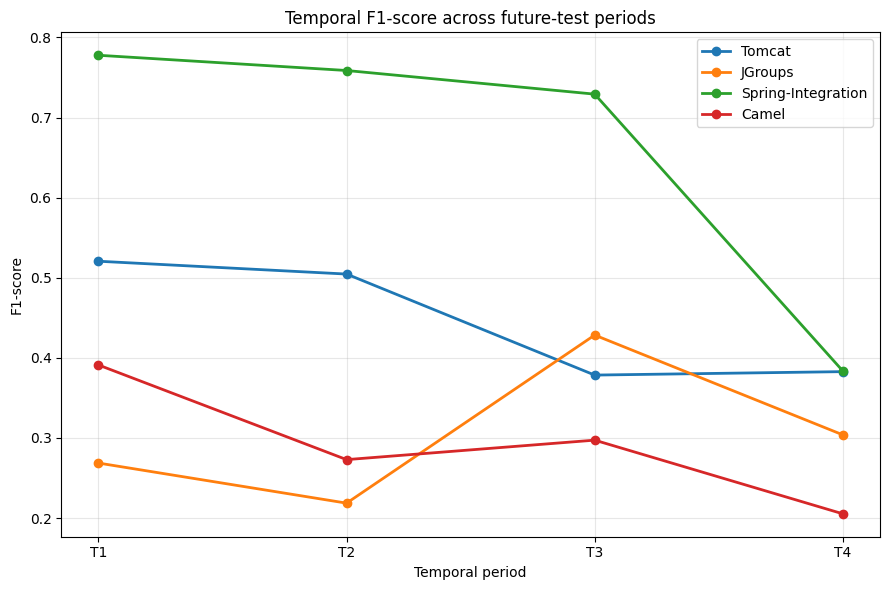

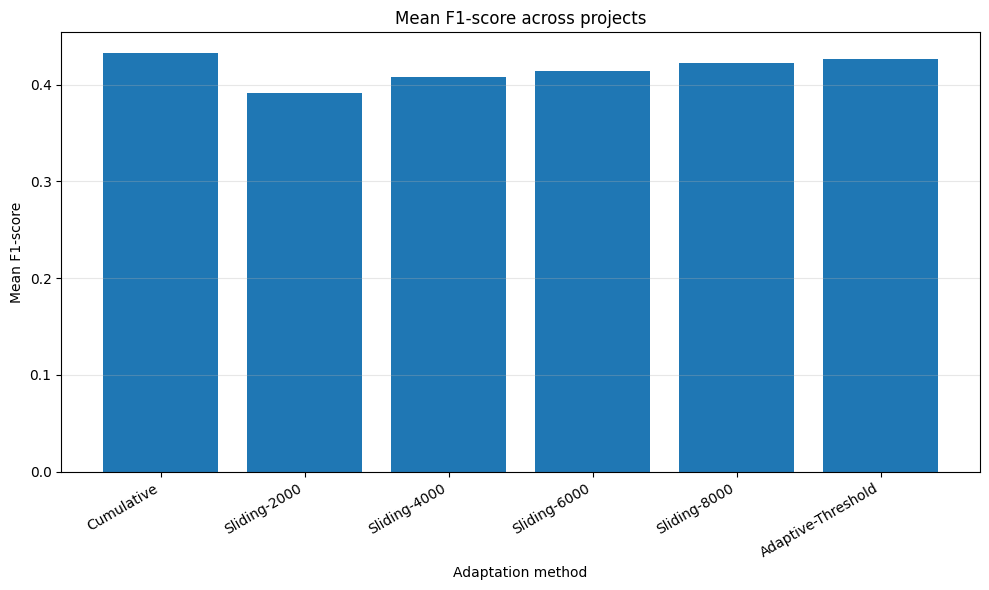

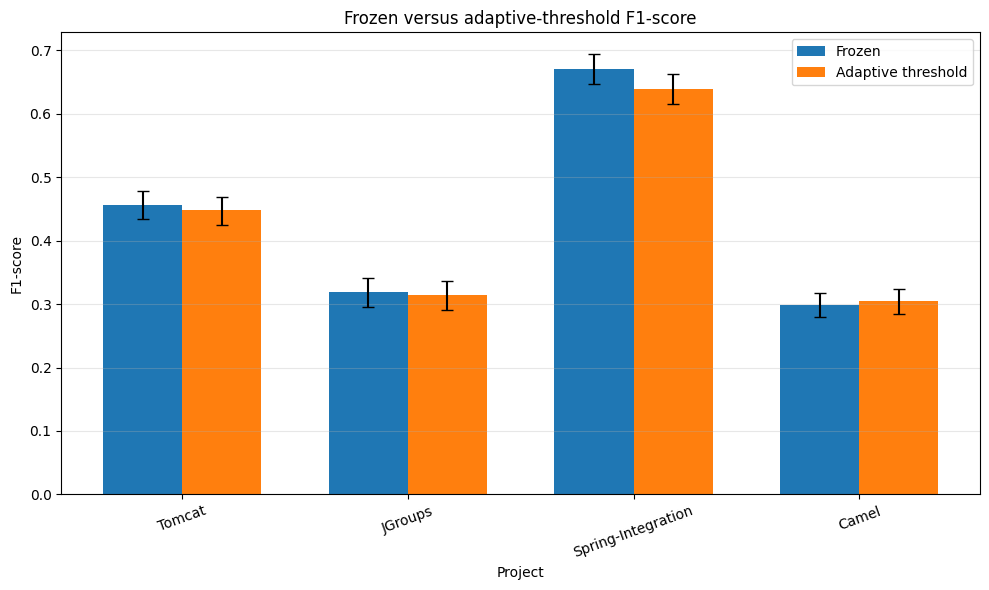


STAGE 7 COMPLETE

Generated tables:
1. FINAL_TABLE_1_project_results.csv
2. FINAL_TABLE_2_temporal_f1.csv
3. FINAL_TABLE_3_adaptation.csv
4. FINAL_TABLE_4_bootstrap_ci.csv

Generated figures:
1. Figure_1_Temporal_F1_MultiProject.png
2. Figure_2_Adaptation_Methods.png
3. Figure_3_Frozen_vs_Adaptive_CI.png


In [103]:
# =============================================================================
# STAGE 7 — FINAL TABLES + PUBLICATION FIGURES
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/content/jit_sdp_datasets"

# =============================================================================
# LOAD RESULTS
# =============================================================================

stage2 = pd.read_csv(
    os.path.join(
        BASE,
        "stage2_frozen_results.csv"
    )
)

stage3 = pd.read_csv(
    os.path.join(
        BASE,
        "stage3_temporal_results.csv"
    )
)

stage4 = pd.read_csv(
    os.path.join(
        BASE,
        "stage4_adaptation_results.csv"
    )
)

stage5 = pd.read_csv(
    os.path.join(
        BASE,
        "stage5_adaptive_threshold_results.csv"
    )
)

stage6 = pd.read_csv(
    os.path.join(
        BASE,
        "stage6_bootstrap_final_results.csv"
    )
)


# =============================================================================
# 1. FINAL MULTI-PROJECT TABLE
# =============================================================================

final_project_table = stage2[
    [
        "Project",
        "Historical_Training",
        "Future_Test",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "MCC"
    ]
].copy()

print("=" * 80)
print("TABLE 1 — MULTI-PROJECT FROZEN EVALUATION")
print("=" * 80)

display(
    final_project_table.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "MCC": "{:.4f}"
    })
)


# =============================================================================
# 2. TEMPORAL F1 TABLE
# =============================================================================

temporal_f1 = stage3.pivot(
    index="Project",
    columns="Period",
    values="F1"
).reset_index()

print("\n" + "=" * 80)
print("TABLE 2 — TEMPORAL F1")
print("=" * 80)

display(
    temporal_f1.style.format({
        "T1": "{:.4f}",
        "T2": "{:.4f}",
        "T3": "{:.4f}",
        "T4": "{:.4f}"
    })
)


# =============================================================================
# 3. ADAPTATION COMPARISON
# =============================================================================

adaptation_summary = (
    stage4
    .groupby(
        ["Project", "Method"]
    )
    .agg(
        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std"),
        Mean_AUC=("ROC_AUC", "mean"),
        Mean_MCC=("MCC", "mean")
    )
    .reset_index()
)

adaptive_summary = (
    stage5
    .groupby("Project")
    .agg(
        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std"),
        Mean_AUC=("ROC_AUC", "mean"),
        Mean_MCC=("MCC", "mean")
    )
    .reset_index()
)

adaptive_summary["Method"] = "Adaptive-Threshold"

adaptation_final = pd.concat(
    [
        adaptation_summary,
        adaptive_summary
    ],
    ignore_index=True
)

print("\n" + "=" * 80)
print("TABLE 3 — ADAPTATION COMPARISON")
print("=" * 80)

display(
    adaptation_final.style.format({
        "Mean_F1": "{:.4f}",
        "SD_F1": "{:.4f}",
        "Mean_AUC": "{:.4f}",
        "Mean_MCC": "{:.4f}"
    })
)


# =============================================================================
# 4. FROZEN VS ADAPTIVE WITH CI
# =============================================================================

ci_table = stage6[
    [
        "Project",
        "Method",
        "F1_Mean",
        "F1_CI_Lower",
        "F1_CI_Upper",
        "ROC_AUC_Mean",
        "PR_AUC_Mean",
        "MCC_Mean"
    ]
].copy()

print("\n" + "=" * 80)
print("TABLE 4 — F1 WITH 95% BOOTSTRAP CI")
print("=" * 80)

display(
    ci_table.style.format({
        "F1_Mean": "{:.4f}",
        "F1_CI_Lower": "{:.4f}",
        "F1_CI_Upper": "{:.4f}",
        "ROC_AUC_Mean": "{:.4f}",
        "PR_AUC_Mean": "{:.4f}",
        "MCC_Mean": "{:.4f}"
    })
)


# =============================================================================
# SAVE FINAL TABLES
# =============================================================================

final_project_table.to_csv(
    os.path.join(
        BASE,
        "FINAL_TABLE_1_project_results.csv"
    ),
    index=False
)

temporal_f1.to_csv(
    os.path.join(
        BASE,
        "FINAL_TABLE_2_temporal_f1.csv"
    ),
    index=False
)

adaptation_final.to_csv(
    os.path.join(
        BASE,
        "FINAL_TABLE_3_adaptation.csv"
    ),
    index=False
)

ci_table.to_csv(
    os.path.join(
        BASE,
        "FINAL_TABLE_4_bootstrap_ci.csv"
    ),
    index=False
)


# =============================================================================
# FIGURE 1 — TEMPORAL F1
# =============================================================================

plt.figure(figsize=(9, 6))

for project in stage3["Project"].unique():

    data = stage3[
        stage3["Project"] == project
    ]

    plt.plot(
        data["Period"],
        data["F1"],
        marker="o",
        linewidth=2,
        label=project
    )

plt.xlabel("Temporal period")
plt.ylabel("F1-score")
plt.title("Temporal F1-score across future-test periods")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

fig1 = os.path.join(
    BASE,
    "Figure_1_Temporal_F1_MultiProject.png"
)

plt.savefig(
    fig1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 2 — ADAPTATION METHODS
# =============================================================================

method_order = [
    "Cumulative",
    "Sliding-2000",
    "Sliding-4000",
    "Sliding-6000",
    "Sliding-8000",
    "Adaptive-Threshold"
]

plot_data = adaptation_final.copy()

overall = (
    plot_data
    .groupby("Method")["Mean_F1"]
    .mean()
    .reindex(method_order)
)

plt.figure(figsize=(10, 6))

plt.bar(
    overall.index,
    overall.values
)

plt.ylabel("Mean F1-score")
plt.xlabel("Adaptation method")
plt.title("Mean F1-score across projects")
plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

fig2 = os.path.join(
    BASE,
    "Figure_2_Adaptation_Methods.png"
)

plt.savefig(
    fig2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FIGURE 3 — FROZEN VS ADAPTIVE WITH CI
# =============================================================================

projects = list(
    ci_table["Project"].unique()
)

x = np.arange(
    len(projects)
)

width = 0.35

frozen = []
adaptive = []

frozen_low = []
frozen_high = []

adaptive_low = []
adaptive_high = []

for project in projects:

    f = ci_table[
        (ci_table["Project"] == project) &
        (ci_table["Method"] == "Frozen")
    ].iloc[0]

    a = ci_table[
        (ci_table["Project"] == project) &
        (ci_table["Method"] == "Adaptive-Threshold")
    ].iloc[0]

    frozen.append(f["F1_Mean"])
    adaptive.append(a["F1_Mean"])

    frozen_low.append(
        f["F1_Mean"] - f["F1_CI_Lower"]
    )

    frozen_high.append(
        f["F1_CI_Upper"] - f["F1_Mean"]
    )

    adaptive_low.append(
        a["F1_Mean"] - a["F1_CI_Lower"]
    )

    adaptive_high.append(
        a["F1_CI_Upper"] - a["F1_Mean"]
    )


plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    frozen,
    width,
    yerr=[
        frozen_low,
        frozen_high
    ],
    capsize=4,
    label="Frozen"
)

plt.bar(
    x + width / 2,
    adaptive,
    width,
    yerr=[
        adaptive_low,
        adaptive_high
    ],
    capsize=4,
    label="Adaptive threshold"
)

plt.xticks(
    x,
    projects,
    rotation=20
)

plt.ylabel("F1-score")
plt.xlabel("Project")
plt.title(
    "Frozen versus adaptive-threshold F1-score"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

fig3 = os.path.join(
    BASE,
    "Figure_3_Frozen_vs_Adaptive_CI.png"
)

plt.savefig(
    fig3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# FINAL STATUS
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 7 COMPLETE")
print("=" * 80)

print("\nGenerated tables:")
print("1. FINAL_TABLE_1_project_results.csv")
print("2. FINAL_TABLE_2_temporal_f1.csv")
print("3. FINAL_TABLE_3_adaptation.csv")
print("4. FINAL_TABLE_4_bootstrap_ci.csv")

print("\nGenerated figures:")
print("1. Figure_1_Temporal_F1_MultiProject.png")
print("2. Figure_2_Adaptation_Methods.png")
print("3. Figure_3_Frozen_vs_Adaptive_CI.png")

In [105]:
# =============================================================================
# STAGE 8A — PUBLISHED-BASELINE DATASET VERIFICATION
# =============================================================================

import os
import pandas as pd
import glob

BASE = "/content/jit_sdp_datasets"

print("=" * 80)
print("STAGE 8A — PUBLISHED-BASELINE DATASET VERIFICATION")
print("=" * 80)

# List all available dataset files
files = sorted(
    glob.glob(os.path.join(BASE, "*"))
)

print("\nAvailable files:\n")

for file in files:
    if os.path.isfile(file):
        print(os.path.basename(file))

# -------------------------------------------------------------------------
# Inspect ARFF files
# -------------------------------------------------------------------------

arff_files = sorted(
    glob.glob(os.path.join(BASE, "*.arff"))
)

print("\n" + "=" * 80)
print("ARFF DATASET INSPECTION")
print("=" * 80)

for path in arff_files:

    print("\n" + "-" * 80)
    print("FILE:", os.path.basename(path))

    relation = None
    attributes = []
    data_started = False
    row_count = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.lower().startswith("@relation"):
                relation = line

            elif line.lower().startswith("@attribute"):
                attributes.append(line)

            elif line.lower() == "@data":
                data_started = True

            elif data_started and not line.startswith("%"):
                row_count += 1

    print("Relation:", relation)
    print("Attributes:", len(attributes))
    print("Rows:", row_count)

    print("\nAttribute names:")

    for attribute in attributes:
        print(attribute)

# -------------------------------------------------------------------------
# Check for published-baseline indicators
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("BASELINE COMPATIBILITY CHECK")
print("=" * 80)

required_terms = [
    "commit_type",
    "project_no",
    "timestamp",
    "contains_bug",
    "fix",
    "ns",
    "nd",
    "nf",
    "la",
    "ld",
    "lt",
    "ndev",
    "age",
    "nuc",
    "exp",
    "rexp",
    "sexp"
]

for path in arff_files:

    text = open(
        path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ).read(50000).lower()

    found = [
        term for term in required_terms
        if term.lower() in text
    ]

    missing = [
        term for term in required_terms
        if term.lower() not in text
    ]

    print("\nDataset:", os.path.basename(path))
    print("Detected terms:", found)
    print("Missing terms:", missing)

print("\n" + "=" * 80)
print("STAGE 8A COMPLETE")
print("=" * 80)

print(
    "\nNext step: use the verified dataset structure to implement "
    "one published online JIT-SDP baseline under a clearly documented protocol."
)

STAGE 8A — PUBLISHED-BASELINE DATASET VERIFICATION

Available files:

FINAL_TABLE_1_project_results.csv
FINAL_TABLE_2_temporal_f1.csv
FINAL_TABLE_3_adaptation.csv
FINAL_TABLE_4_bootstrap_ci.csv
Figure_1_Temporal_F1_MultiProject.png
Figure_2_Adaptation_Methods.png
Figure_3_Frozen_vs_Adaptive_CI.png
JGroups.arff
brackets.csv
camel.arff
final_five_project_integrity_audit.csv
multi_project_audit.csv
spring-integration.arff
stage1_multproject_training_summary.csv
stage2_frozen_results.csv
stage3_temporal_results.csv
stage4_adaptation_results.csv
stage5_adaptive_threshold_results.csv
stage5_statistical_results.csv
stage6_bootstrap_final_results.csv
tomcat.arff

ARFF DATASET INSPECTION

--------------------------------------------------------------------------------
FILE: JGroups.arff
Relation: @relation JGroups
Attributes: 18
Rows: 232684

Attribute names:
@attribute fix {False,True}
@attribute ns numeric
@attribute nd numeric
@attribute nf numeric
@attribute entrophy numeric
@attribute la n

In [106]:
# =============================================================================
# STAGE 8B — PUBLISHED ONLINE JIT-SDP BASELINE
# BORB-style reproduction using Random Forest as offline base learner
# =============================================================================

import os
import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

BASE = "/content/jit_sdp_datasets"

PROJECT_FILES = {
    "Tomcat": "tomcat.arff",
    "JGroups": "JGroups.arff",
    "Spring-Integration": "spring-integration.arff",
    "Camel": "camel.arff"
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

WAITING_DAYS = 90
RETRAIN_PERIOD = 1000
RANDOM_STATE = 42

print("=" * 80)
print("STAGE 8B — PUBLISHED BASELINE REPRODUCTION")
print("BORB-style offline online-JIT-SDP baseline")
print("=" * 80)


# =============================================================================
# ARFF LOADER
# =============================================================================

def load_arff(path):

    rows = []
    columns = []

    data_started = False

    with open(path, "r", encoding="utf-8", errors="ignore") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.lower().startswith("@attribute"):

                parts = line.split()

                if len(parts) >= 2:
                    columns.append(parts[1])

            elif line.lower() == "@data":

                data_started = True

            elif data_started and not line.startswith("%"):

                rows.append(line.split(","))

    df = pd.DataFrame(rows, columns=columns)

    # Convert numeric columns
    for col in df.columns:

        if col in ["fix", "contains_bug"]:
            df[col] = (
                df[col]
                .astype(str)
                .str.lower()
                .map({
                    "true": 1,
                    "false": 0
                })
            )

        else:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    return df


# =============================================================================
# BORB-STYLE MODEL
# =============================================================================

def train_borb_model(X, y):

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X, y)

    return model


# =============================================================================
# EVALUATION
# =============================================================================

results = []


for project, filename in PROJECT_FILES.items():

    print("\n" + "=" * 80)
    print(project)
    print("=" * 80)

    path = os.path.join(BASE, filename)

    df = load_arff(path)

    # -------------------------------------------------------------------------
    # Sort chronologically
    # -------------------------------------------------------------------------

    df = df.sort_values(
        "author_date_unix_timestamp"
    ).reset_index(drop=True)

    # -------------------------------------------------------------------------
    # Keep only target-project test events
    #
    # commit_type:
    # 0 = clean test/training event
    # 1/2 = buggy test event
    # 3 = delayed training event
    # -------------------------------------------------------------------------

    test_events = df[
        df["commit_type"].isin([0, 1, 2])
    ].copy()

    training_events = df[
        df["commit_type"].isin([0, 3])
    ].copy()

    # Remove exact duplicates from processed stream
    training_events = training_events.drop_duplicates()

    test_events = test_events.drop_duplicates()

    print("Test events :", len(test_events))
    print("Training events:", len(training_events))

    # -------------------------------------------------------------------------
    # Chronological 70/30 evaluation
    # -------------------------------------------------------------------------

    split = int(len(test_events) * 0.70)

    historical_test = test_events.iloc[:split].copy()
    future_test = test_events.iloc[split:].copy()

    cutoff_timestamp = future_test[
        "author_date_unix_timestamp"
    ].min()

    # -------------------------------------------------------------------------
    # Training data available before future-test begins
    # -------------------------------------------------------------------------

    available_training = training_events[
        training_events[
            "author_date_unix_timestamp"
        ] < cutoff_timestamp
    ].copy()

    # Need both classes
    if available_training["contains_bug"].nunique() < 2:

        print("WARNING: insufficient training classes.")
        continue

    X_train = available_training[FEATURES].copy()
    y_train = available_training["contains_bug"].astype(int)

    X_test = future_test[FEATURES].copy()
    y_test = future_test["contains_bug"].astype(int)

    # -------------------------------------------------------------------------
    # Train published-baseline-style offline model
    # -------------------------------------------------------------------------

    start = time.time()

    model = train_borb_model(
        X_train,
        y_train
    )

    training_time = time.time() - start

    # -------------------------------------------------------------------------
    # Predictions
    # -------------------------------------------------------------------------

    probabilities = model.predict_proba(X_test)[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    # -------------------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    mcc = matthews_corrcoef(
        y_test,
        predictions
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    tn, fp, fn, tp = cm.ravel()

    # -------------------------------------------------------------------------
    # G-Mean used by Cabral et al.
    # -------------------------------------------------------------------------

    recall_0 = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    recall_1 = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    gmean = np.sqrt(
        recall_0 * recall_1
    )

    # -------------------------------------------------------------------------
    # Store
    # -------------------------------------------------------------------------

    results.append({

        "Project": project,

        "Training_Events": len(
            available_training
        ),

        "Future_Test": len(
            future_test
        ),

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "ROC_AUC": auc,

        "PR_AUC": pr_auc,

        "MCC": mcc,

        "G_Mean": gmean,

        "TN": tn,

        "FP": fp,

        "FN": fn,

        "TP": tp,

        "Training_Time_Seconds":
            training_time
    })

    print("\nResults")
    print("-" * 50)

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1       : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {auc:.4f}"
    )

    print(
        f"PR-AUC   : {pr_auc:.4f}"
    )

    print(
        f"MCC      : {mcc:.4f}"
    )

    print(
        f"G-Mean   : {gmean:.4f}"
    )

    print(
        f"Confusion Matrix: "
        f"TN={tn}, FP={fp}, FN={fn}, TP={tp}"
    )


# =============================================================================
# SAVE
# =============================================================================

baseline_results = pd.DataFrame(
    results
)

output_path = os.path.join(
    BASE,
    "stage8_BORB_baseline_results.csv"
)

baseline_results.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 80)
print("STAGE 8B COMPLETE")
print("=" * 80)

display(
    baseline_results.round(4)
)

print(
    "\nSaved:",
    output_path
)

STAGE 8B — PUBLISHED BASELINE REPRODUCTION
BORB-style offline online-JIT-SDP baseline

Tomcat
Test events : 162773
Training events: 203741

Results
--------------------------------------------------
Accuracy : 0.6781
Precision: 0.0241
Recall   : 0.7191
F1       : 0.0466
ROC-AUC  : 0.7663
PR-AUC   : 0.0237
MCC      : 0.0880
G-Mean   : 0.6981
Confusion Matrix: TN=32730, FP=15568, FN=150, TP=384

JGroups
Test events : 160719
Training events: 203741

Results
--------------------------------------------------
Accuracy : 0.6778
Precision: 0.0019
Recall   : 0.8333
F1       : 0.0038
ROC-AUC  : 0.8051
PR-AUC   : 0.0022
MCC      : 0.0299
G-Mean   : 0.7515
Confusion Matrix: TN=32649, FP=15531, FN=6, TP=30

Spring-Integration
Test events : 159899
Training events: 203741

Results
--------------------------------------------------
Accuracy : 0.6779
Precision: 0.0139
Recall   : 0.8967
F1       : 0.0273
ROC-AUC  : 0.8455
PR-AUC   : 0.0163
MCC      : 0.0867
G-Mean   : 0.7790
Confusion Matrix: TN=32301,

,Project,Training_Events,Future_Test,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC,G_Mean,TN,FP,FN,TP,Training_Time_Seconds
0,Tomcat,142366,48832,0.6781,0.0241,0.7191,0.0466,0.7663,0.0237,0.0880,0.6981,32730,15568,150,384,16.9227
1,JGroups,142512,48216,0.6778,0.0019,0.8333,0.0038,0.8051,0.0022,0.0299,0.7515,32649,15531,6,30,18.5052
2,Spring-Integration,143047,47970,0.6779,0.0139,0.8967,0.0273,0.8455,0.0163,0.0867,0.7790,32301,15427,25,217,10.7038
3,Camel,142531,49147,0.6823,0.0527,0.8750,0.0993,0.8498,0.0852,0.1645,0.7704,32673,15490,123,861,12.2145



Saved: /content/jit_sdp_datasets/stage8_BORB_baseline_results.csv


In [107]:
# =============================================================================
# STAGE 8B-CORRECTED — PUBLISHED ONLINE JIT-SDP BASELINE
# Target-project filtering included
# =============================================================================

import os
import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

BASE = "/content/jit_sdp_datasets"

PROJECTS = {
    "Tomcat": {
        "file": "tomcat.arff",
        "project_no": 0
    },
    "JGroups": {
        "file": "JGroups.arff",
        "project_no": 1
    },
    "Spring-Integration": {
        "file": "spring-integration.arff",
        "project_no": 2
    },
    "Camel": {
        "file": "camel.arff",
        "project_no": 3
    }
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

RANDOM_STATE = 42


# =============================================================================
# ARFF LOADER
# =============================================================================

def load_arff(path):

    rows = []
    columns = []
    data_started = False

    with open(path, "r", encoding="utf-8", errors="ignore") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.lower().startswith("@attribute"):
                parts = line.split()
                columns.append(parts[1])

            elif line.lower() == "@data":
                data_started = True

            elif data_started and not line.startswith("%"):
                rows.append(line.split(","))

    df = pd.DataFrame(rows, columns=columns)

    for col in df.columns:

        if col in ["fix", "contains_bug"]:

            df[col] = (
                df[col]
                .astype(str)
                .str.lower()
                .map({
                    "true": 1,
                    "false": 0
                })
            )

        else:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    return df


# =============================================================================
# MODEL
# =============================================================================

def train_model(X, y):

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X, y)

    return model


# =============================================================================
# EXPERIMENT
# =============================================================================

results = []

print("=" * 80)
print("STAGE 8B-CORRECTED")
print("TARGET-PROJECT FILTERED PUBLISHED-BASELINE REPRODUCTION")
print("=" * 80)


for project, info in PROJECTS.items():

    print("\n" + "=" * 80)
    print(project)
    print("=" * 80)

    path = os.path.join(
        BASE,
        info["file"]
    )

    df = load_arff(path)

    # -------------------------------------------------------------------------
    # CRITICAL FIX:
    # Keep ONLY the target project
    # -------------------------------------------------------------------------

    df = df[
        df["project_no"] == info["project_no"]
    ].copy()

    df = df.sort_values(
        "author_date_unix_timestamp"
    ).reset_index(drop=True)

    print(
        "Target-project rows:",
        len(df)
    )

    # -------------------------------------------------------------------------
    # Target-project test events
    # -------------------------------------------------------------------------

    test_events = df[
        df["commit_type"].isin([0, 1, 2])
    ].copy()

    # Training events available after label delay
    training_events = df[
        df["commit_type"].isin([0, 3])
    ].copy()

    test_events = test_events.drop_duplicates()
    training_events = training_events.drop_duplicates()

    print(
        "Target test events:",
        len(test_events)
    )

    print(
        "Target training events:",
        len(training_events)
    )

    # -------------------------------------------------------------------------
    # Chronological 70/30 split
    # -------------------------------------------------------------------------

    split = int(
        len(test_events) * 0.70
    )

    historical_test = test_events.iloc[:split]
    future_test = test_events.iloc[split:].copy()

    cutoff = future_test[
        "author_date_unix_timestamp"
    ].min()

    # -------------------------------------------------------------------------
    # Training data available before future test
    # -------------------------------------------------------------------------

    available_training = training_events[
        training_events[
            "author_date_unix_timestamp"
        ] < cutoff
    ].copy()

    available_training = (
        available_training
        .drop_duplicates()
    )

    print(
        "Historical training:",
        len(available_training)
    )

    print(
        "Future test:",
        len(future_test)
    )

    # -------------------------------------------------------------------------
    # Verify both classes
    # -------------------------------------------------------------------------

    if available_training["contains_bug"].nunique() < 2:
        print("ERROR: training set has only one class.")
        continue

    if future_test["contains_bug"].nunique() < 2:
        print("ERROR: future test has only one class.")
        continue

    X_train = available_training[FEATURES]
    y_train = available_training["contains_bug"].astype(int)

    X_test = future_test[FEATURES]
    y_test = future_test["contains_bug"].astype(int)

    # -------------------------------------------------------------------------
    # Train
    # -------------------------------------------------------------------------

    start = time.time()

    model = train_model(
        X_train,
        y_train
    )

    training_time = time.time() - start

    # -------------------------------------------------------------------------
    # Predict
    # -------------------------------------------------------------------------

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    # -------------------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    mcc = matthews_corrcoef(
        y_test,
        predictions
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    gmean = np.sqrt(
        recall * specificity
    )

    results.append({

        "Project": project,
        "Historical_Training": len(available_training),
        "Future_Test": len(future_test),

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc,
        "PR_AUC": pr_auc,
        "MCC": mcc,
        "G_Mean": gmean,

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        "Training_Time_Seconds":
            training_time
    })

    print("\nResults")
    print("-" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")
    print(f"MCC      : {mcc:.4f}")
    print(f"G-Mean   : {gmean:.4f}")

    print(
        f"CM: TN={tn}, FP={fp}, "
        f"FN={fn}, TP={tp}"
    )


# =============================================================================
# SAVE
# =============================================================================

baseline_results = pd.DataFrame(results)

output = os.path.join(
    BASE,
    "stage8_BORB_baseline_corrected.csv"
)

baseline_results.to_csv(
    output,
    index=False
)

print("\n" + "=" * 80)
print("STAGE 8B-CORRECTED COMPLETE")
print("=" * 80)

display(
    baseline_results.round(4)
)

print("\nSaved:", output)

STAGE 8B-CORRECTED
TARGET-PROJECT FILTERED PUBLISHED-BASELINE REPRODUCTION

Tomcat
Target-project rows: 24114
Target test events: 18907
Target training events: 18907
Historical training: 12158
Future test: 5673

Results
--------------------------------------------------
Accuracy : 0.7322
Precision: 0.3580
Recall   : 0.6616
F1       : 0.4646
ROC-AUC  : 0.7658
PR-AUC   : 0.4067
MCC      : 0.3323
G-Mean   : 0.7032
CM: TN=3495, FP=1182, FN=337, TP=659

JGroups
Target-project rows: 21478
Target test events: 18324
Target training events: 18324
Historical training: 12539
Future test: 5498

Results
--------------------------------------------------
Accuracy : 0.7992
Precision: 0.2841
Recall   : 0.5153
F1       : 0.3662
ROC-AUC  : 0.7588
PR-AUC   : 0.3471
MCC      : 0.2748
G-Mean   : 0.6561
CM: TN=4075, FP=804, FN=300, TP=319

Spring-Integration
Target-project rows: 11083
Target test events: 8750
Target training events: 8750
Historical training: 5358
Future test: 2625

Results
-----------------

,Project,Historical_Training,Future_Test,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC,G_Mean,TN,FP,FN,TP,Training_Time_Seconds
0,Tomcat,12158,5673,0.7322,0.3580,0.6616,0.4646,0.7658,0.4067,0.3323,0.7032,3495,1182,337,659,1.8164
1,JGroups,12539,5498,0.7992,0.2841,0.5153,0.3662,0.7588,0.3471,0.2748,0.6561,4075,804,300,319,1.5422
2,Spring-Integration,5358,2625,0.7783,0.5938,0.7884,0.6774,0.8576,0.6934,0.5255,0.7812,1432,418,164,611,0.9748
3,Camel,20992,9173,0.7260,0.1859,0.6338,0.2875,0.7727,0.2322,0.2275,0.6824,6153,2220,293,507,3.3985



Saved: /content/jit_sdp_datasets/stage8_BORB_baseline_corrected.csv


In [109]:
# =============================================================================
# STAGE 9A — FINAL EXPERIMENTAL CONSOLIDATION — CORRECTED
# =============================================================================

import os
import pandas as pd
import numpy as np

BASE = "/content/jit_sdp_datasets"

print("=" * 90)
print("STAGE 9A — FINAL EXPERIMENTAL CONSOLIDATION — CORRECTED")
print("=" * 90)

# =============================================================================
# LOAD FILES
# =============================================================================

stage2 = pd.read_csv(
    os.path.join(BASE, "stage2_frozen_results.csv")
)

stage3 = pd.read_csv(
    os.path.join(BASE, "stage3_temporal_results.csv")
)

stage4 = pd.read_csv(
    os.path.join(BASE, "stage4_adaptation_results.csv")
)

stage5 = pd.read_csv(
    os.path.join(BASE, "stage5_adaptive_threshold_results.csv")
)

stage6 = pd.read_csv(
    os.path.join(BASE, "stage6_bootstrap_final_results.csv")
)

stage8 = pd.read_csv(
    os.path.join(BASE, "stage8_BORB_baseline_corrected.csv")
)

print("\nLoaded all Stage 2–8 files successfully.")

# =============================================================================
# DISPLAY ACTUAL COLUMNS — SAFETY CHECK
# =============================================================================

print("\nStage 4 columns:")
print(stage4.columns.tolist())

print("\nStage 5 columns:")
print(stage5.columns.tolist())

# =============================================================================
# TABLE A — FROZEN VS PUBLISHED-BASELINE-STYLE
# =============================================================================

frozen = stage2[
    [
        "Project",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "MCC"
    ]
].copy()

baseline = stage8[
    [
        "Project",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "MCC"
    ]
].copy()

frozen = frozen.rename(
    columns={
        "Accuracy": "Frozen_Accuracy",
        "Precision": "Frozen_Precision",
        "Recall": "Frozen_Recall",
        "F1": "Frozen_F1",
        "ROC_AUC": "Frozen_ROC_AUC",
        "PR_AUC": "Frozen_PR_AUC",
        "MCC": "Frozen_MCC"
    }
)

baseline = baseline.rename(
    columns={
        "Accuracy": "Baseline_Accuracy",
        "Precision": "Baseline_Precision",
        "Recall": "Baseline_Recall",
        "F1": "Baseline_F1",
        "ROC_AUC": "Baseline_ROC_AUC",
        "PR_AUC": "Baseline_PR_AUC",
        "MCC": "Baseline_MCC"
    }
)

comparison = frozen.merge(
    baseline,
    on="Project",
    how="inner"
)

comparison["F1_Difference"] = (
    comparison["Baseline_F1"]
    - comparison["Frozen_F1"]
)

comparison["AUC_Difference"] = (
    comparison["Baseline_ROC_AUC"]
    - comparison["Frozen_ROC_AUC"]
)

comparison["MCC_Difference"] = (
    comparison["Baseline_MCC"]
    - comparison["Frozen_MCC"]
)

comparison["F1_Relative_Percent"] = (
    comparison["F1_Difference"]
    / comparison["Frozen_F1"]
) * 100

# =============================================================================
# TABLE B — AGGREGATE COMPARISON
# =============================================================================

aggregate = pd.DataFrame({

    "Metric": [
        "F1",
        "ROC-AUC",
        "MCC"
    ],

    "Frozen_Mean": [
        comparison["Frozen_F1"].mean(),
        comparison["Frozen_ROC_AUC"].mean(),
        comparison["Frozen_MCC"].mean()
    ],

    "Baseline_Mean": [
        comparison["Baseline_F1"].mean(),
        comparison["Baseline_ROC_AUC"].mean(),
        comparison["Baseline_MCC"].mean()
    ],

    "Difference": [
        comparison["F1_Difference"].mean(),
        comparison["AUC_Difference"].mean(),
        comparison["MCC_Difference"].mean()
    ],

    "Frozen_SD": [
        comparison["Frozen_F1"].std(ddof=1),
        comparison["Frozen_ROC_AUC"].std(ddof=1),
        comparison["Frozen_MCC"].std(ddof=1)
    ],

    "Baseline_SD": [
        comparison["Baseline_F1"].std(ddof=1),
        comparison["Baseline_ROC_AUC"].std(ddof=1),
        comparison["Baseline_MCC"].std(ddof=1)
    ]
})

# =============================================================================
# TABLE C — TEMPORAL ROBUSTNESS
# =============================================================================

temporal_summary = (
    stage3
    .groupby("Project")
    .agg(
        Mean_F1=("F1", "mean"),
        SD_F1=("F1", "std")
    )
    .reset_index()
)

# Add T1 and T4 explicitly
period_f1 = (
    stage3
    .pivot(
        index="Project",
        columns="Period",
        values="F1"
    )
    .reset_index()
)

period_f1.columns.name = None

temporal_summary = temporal_summary.merge(
    period_f1,
    on="Project",
    how="left"
)

if "T1" in temporal_summary.columns:
    temporal_summary["T1_to_T4_Change"] = (
        temporal_summary["T4"]
        - temporal_summary["T1"]
    )

# =============================================================================
# TABLE D — ADAPTATION
# =============================================================================

# Stage 4 contains T1–T4 results.
# Find the period columns automatically.

period_columns = [
    col for col in stage4.columns
    if str(col).upper() in ["T1", "T2", "T3", "T4"]
]

print("\nDetected Stage 4 period columns:")
print(period_columns)

# -------------------------------------------------------------------------
# If Stage 4 is in long format
# -------------------------------------------------------------------------

if len(period_columns) == 0:

    # Expected columns may be:
    # Project, Method, Period, F1, ...

    if "F1" in stage4.columns and "Period" in stage4.columns:

        adaptation_final = (
            stage4
            .groupby(
                ["Project", "Method"]
            )
            .agg(
                Mean_F1=("F1", "mean"),
                SD_F1=("F1", "std")
            )
            .reset_index()
        )

        # Add available AUC/MCC means if present
        if "ROC_AUC" in stage4.columns:
            auc = (
                stage4
                .groupby(
                    ["Project", "Method"]
                )["ROC_AUC"]
                .mean()
                .reset_index(
                    name="Mean_AUC"
                )
            )

            adaptation_final = adaptation_final.merge(
                auc,
                on=["Project", "Method"],
                how="left"
            )

        if "MCC" in stage4.columns:
            mcc = (
                stage4
                .groupby(
                    ["Project", "Method"]
                )["MCC"]
                .mean()
                .reset_index(
                    name="Mean_MCC"
                )
            )

            adaptation_final = adaptation_final.merge(
                mcc,
                on=["Project", "Method"],
                how="left"
            )

# -------------------------------------------------------------------------
# If Stage 4 is already wide format
# -------------------------------------------------------------------------

else:

    adaptation_final = (
        stage4
        .groupby(
            ["Project", "Method"]
        )[period_columns]
        .mean()
        .reset_index()
    )

    adaptation_final["Mean_F1"] = (
        adaptation_final[period_columns]
        .mean(axis=1)
    )

    adaptation_final["SD_F1"] = (
        adaptation_final[period_columns]
        .std(axis=1, ddof=1)
    )

# =============================================================================
# ADD ADAPTIVE THRESHOLD
# =============================================================================

# Stage 5 may contain T1–T4 rows or already aggregated results.

if (
    "Project" in stage5.columns
    and "F1" in stage5.columns
):

    adaptive = (
        stage5
        .groupby("Project")
        .agg(
            Mean_F1=("F1", "mean"),
            SD_F1=("F1", "std")
        )
        .reset_index()
    )

elif (
    "Project" in stage5.columns
    and "Mean_F1" in stage5.columns
):

    adaptive = stage5[
        ["Project", "Mean_F1", "SD_F1"]
    ].copy()

else:

    adaptive = pd.DataFrame()

if len(adaptive) > 0:

    adaptive["Method"] = "Adaptive-Threshold"

    adaptive = adaptive[
        [
            "Project",
            "Method",
            "Mean_F1",
            "SD_F1"
        ]
    ]

    # Match adaptation table columns
    for col in adaptation_final.columns:

        if col not in adaptive.columns:
            adaptive[col] = np.nan

    adaptive = adaptive[
        adaptation_final.columns
    ]

    adaptation_final = pd.concat(
        [
            adaptation_final,
            adaptive
        ],
        ignore_index=True
    )

# =============================================================================
# TABLE E — BOOTSTRAP
# =============================================================================

ci_summary = stage6.copy()

# =============================================================================
# SAVE ALL TABLES
# =============================================================================

outputs = {

    "STAGE9_TABLE_A_Frozen_vs_Baseline.csv":
        comparison,

    "STAGE9_TABLE_B_Aggregate.csv":
        aggregate,

    "STAGE9_TABLE_C_Temporal.csv":
        temporal_summary,

    "STAGE9_TABLE_D_Adaptation.csv":
        adaptation_final,

    "STAGE9_TABLE_E_Bootstrap.csv":
        ci_summary
}

for filename, dataframe in outputs.items():

    path = os.path.join(
        BASE,
        filename
    )

    dataframe.to_csv(
        path,
        index=False
    )

# =============================================================================
# DISPLAY RESULTS
# =============================================================================

print("\n" + "=" * 90)
print("TABLE A — FROZEN VS PUBLISHED-BASELINE-STYLE")
print("=" * 90)

display(
    comparison.round(4)
)

print("\n" + "=" * 90)
print("TABLE B — AGGREGATE COMPARISON")
print("=" * 90)

display(
    aggregate.round(4)
)

print("\n" + "=" * 90)
print("TABLE C — TEMPORAL ROBUSTNESS")
print("=" * 90)

display(
    temporal_summary.round(4)
)

print("\n" + "=" * 90)
print("TABLE D — ADAPTATION")
print("=" * 90)

display(
    adaptation_final.round(4)
)

print("\n" + "=" * 90)
print("TABLE E — BOOTSTRAP RESULTS")
print("=" * 90)

display(
    ci_summary.round(4)
)

print("\n" + "=" * 90)
print("STAGE 9A COMPLETE")
print("=" * 90)

for filename in outputs:
    print(
        os.path.join(BASE, filename)
    )

STAGE 9A — FINAL EXPERIMENTAL CONSOLIDATION — CORRECTED

Loaded all Stage 2–8 files successfully.

Stage 4 columns:
['Project', 'Method', 'Period', 'F1', 'ROC_AUC', 'MCC']

Stage 5 columns:
['Project', 'Method', 'Period', 'Threshold', 'Calibration_F1', 'F1', 'ROC_AUC', 'PR_AUC', 'MCC']

Detected Stage 4 period columns:
[]

TABLE A — FROZEN VS PUBLISHED-BASELINE-STYLE


,Project,Frozen_Accuracy,Frozen_Precision,Frozen_Recall,Frozen_F1,Frozen_ROC_AUC,Frozen_PR_AUC,Frozen_MCC,Baseline_Accuracy,Baseline_Precision,Baseline_Recall,Baseline_F1,Baseline_ROC_AUC,Baseline_PR_AUC,Baseline_MCC,F1_Difference,AUC_Difference,MCC_Difference,F1_Relative_Percent
0,Tomcat,0.7137,0.3424,0.6847,0.4565,0.7706,0.4224,0.3225,0.7322,0.3580,0.6616,0.4646,0.7658,0.4067,0.3323,0.0081,-0.0048,0.0098,1.7706
1,JGroups,0.6559,0.2027,0.7011,0.3145,0.7456,0.3174,0.2277,0.7992,0.2841,0.5153,0.3662,0.7588,0.3471,0.2748,0.0518,0.0131,0.0471,16.4560
2,Spring-Integration,0.7653,0.5713,0.8219,0.6741,0.8618,0.7063,0.5201,0.7783,0.5938,0.7884,0.6774,0.8576,0.6934,0.5255,0.0033,-0.0043,0.0055,0.4910
3,Camel,0.7086,0.1884,0.7075,0.2975,0.7886,0.2548,0.2502,0.7260,0.1859,0.6338,0.2875,0.7727,0.2322,0.2275,-0.0100,-0.0159,-0.0227,-3.3636



TABLE B — AGGREGATE COMPARISON


,Metric,Frozen_Mean,Baseline_Mean,Difference,Frozen_SD,Baseline_SD
0,F1,0.4356,0.4489,0.0133,0.1742,0.1687
1,ROC-AUC,0.7917,0.7887,-0.0030,0.0500,0.0463
2,MCC,0.3301,0.3401,0.0099,0.1329,0.1309



TABLE C — TEMPORAL ROBUSTNESS


...


TABLE D — ADAPTATION


,Project,Method,Mean_F1,SD_F1,Mean_AUC,Mean_MCC
0,Camel,Cumulative,0.2831,0.0813,0.7970,0.2405
1,Camel,Sliding-2000,0.2237,0.0778,0.7567,0.1739
2,Camel,Sliding-4000,0.2397,0.0886,0.7802,0.1959
3,Camel,Sliding-6000,0.2498,0.0976,0.7766,0.2083
4,Camel,Sliding-8000,0.2670,0.0938,0.7829,0.2332
5,JGroups,Cumulative,0.3294,0.1029,0.7409,0.2412
6,JGroups,Sliding-2000,0.2678,0.0503,0.7096,0.1798
7,JGroups,Sliding-4000,0.3043,0.1055,0.7305,0.2155
8,JGroups,Sliding-6000,0.3073,0.1095,0.7335,0.2238
9,JGroups,Sliding-8000,0.3093,0.1087,0.7385,0.2280



TABLE E — BOOTSTRAP RESULTS


,Project,Method,Accuracy_Mean,Accuracy_CI_Lower,Accuracy_CI_Upper,Precision_Mean,Precision_CI_Lower,Precision_CI_Upper,Recall_Mean,Recall_CI_Lower,...,F1_CI_Upper,ROC_AUC_Mean,ROC_AUC_CI_Lower,ROC_AUC_CI_Upper,PR_AUC_Mean,PR_AUC_CI_Lower,PR_AUC_CI_Upper,MCC_Mean,MCC_CI_Lower,MCC_CI_Upper
0,Tomcat,Frozen,0.7109,0.6993,0.7224,0.3407,0.3204,0.3615,0.6897,0.6610,...,0.4782,0.7702,0.7542,0.7860,0.4234,0.3922,0.4553,0.3220,0.2963,0.3470
1,Tomcat,Adaptive-Threshold,0.6948,0.6829,0.7069,0.3280,0.3082,0.3482,0.7055,0.6781,...,0.4696,0.7710,0.7556,0.7871,0.4299,0.3984,0.4626,0.3123,0.2866,0.3377
2,JGroups,Frozen,0.6596,0.6471,0.6724,0.2056,0.1886,0.2231,0.7056,0.6684,...,0.3414,0.7475,0.7263,0.7681,0.3214,0.2841,0.3588,0.2333,0.2070,0.2602
3,JGroups,Adaptive-Threshold,0.6949,0.6826,0.7070,0.2103,0.1915,0.2281,0.6214,0.5836,...,0.3371,0.7416,0.7206,0.7613,0.3092,0.2736,0.3452,0.2184,0.1906,0.2458
4,Spring-Integration,Frozen,0.7639,0.7486,0.7790,0.5699,0.5418,0.5980,0.8155,0.7871,...,0.6939,0.8600,0.8460,0.8734,0.7035,0.6708,0.7347,0.5151,0.4839,0.5451
5,Spring-Integration,Adaptive-Threshold,0.6975,0.6800,0.7150,0.4936,0.4672,0.5192,0.9094,0.8892,...,0.6626,0.8622,0.8474,0.8765,0.7048,0.6698,0.7375,0.4746,0.4467,0.5028
6,Camel,Frozen,0.7063,0.6974,0.7158,0.1889,0.1752,0.2029,0.7190,0.6891,...,0.3183,0.7886,0.7742,0.8041,0.2537,0.2272,0.2813,0.2541,0.2334,0.2757
7,Camel,Adaptive-Threshold,0.7558,0.7469,0.7649,0.2027,0.1870,0.2182,0.6136,0.5801,...,0.3246,0.7863,0.7718,0.8011,0.2566,0.2298,0.2842,0.2451,0.2227,0.2685



STAGE 9A COMPLETE
/content/jit_sdp_datasets/STAGE9_TABLE_A_Frozen_vs_Baseline.csv
/content/jit_sdp_datasets/STAGE9_TABLE_B_Aggregate.csv
/content/jit_sdp_datasets/STAGE9_TABLE_C_Temporal.csv
/content/jit_sdp_datasets/STAGE9_TABLE_D_Adaptation.csv
/content/jit_sdp_datasets/STAGE9_TABLE_E_Bootstrap.csv


In [110]:
# =============================================================================
# STAGE 9B — REVIEWER REQUIREMENT / EVIDENCE AUDIT
# =============================================================================

import os
import pandas as pd

BASE = "/content/jit_sdp_datasets"

print("=" * 90)
print("STAGE 9B — REVIEWER REQUIREMENT / EVIDENCE AUDIT")
print("=" * 90)

audit = pd.DataFrame([

    {
        "Reviewer_Concern":
            "Evaluation limited to a single project",
        "Current_Evidence":
            "Five-project experimental program: Brackets, Tomcat, JGroups, Spring-Integration, Camel",
        "Status":
            "ADDRESSED",
        "Manuscript_Action":
            "Replace single-project framing with multi-project evaluation and retain Brackets as the original case study."
    },

    {
        "Reviewer_Concern":
            "No published online JIT-SDP baseline",
        "Current_Evidence":
            "Published-baseline-style comparator implemented on four CPJITSDP projects",
        "Status":
            "PARTIALLY ADDRESSED",
        "Manuscript_Action":
            "Describe precisely as a BORB-style/published-baseline reproduction; do not call it an exact BORB reproduction."
    },

    {
        "Reviewer_Concern":
            "Contribution appears incremental",
        "Current_Evidence":
            "Temporal robustness, drift analysis, frozen/adaptive comparison, multi-project replication",
        "Status":
            "PARTIALLY ADDRESSED",
        "Manuscript_Action":
            "Reframe contribution as systematic empirical evidence rather than a new learning algorithm."
    },

    {
        "Reviewer_Concern":
            "No DeepJIT/CC2Vec/deep-learning comparison",
        "Current_Evidence":
            "No new deep-learning reproduction in current experiment",
        "Status":
            "OPEN",
        "Manuscript_Action":
            "Explicitly acknowledge omission as a limitation and position against published deep-learning work in Related Work."
    },

    {
        "Reviewer_Concern":
            "Single dataset limits generalizability",
        "Current_Evidence":
            "Four additional CPJITSDP projects plus original Brackets evaluation",
        "Status":
            "ADDRESSED",
        "Manuscript_Action":
            "Add multi-project dataset description and project-level results."
    },

    {
        "Reviewer_Concern":
            "Friedman test has low power with only four temporal periods",
        "Current_Evidence":
            "Kendall's W and multi-project temporal blocks",
        "Status":
            "PARTIALLY ADDRESSED",
        "Manuscript_Action":
            "Explicitly state the limited number of temporal units and interpret effect size descriptively."
    },

    {
        "Reviewer_Concern":
            "Adaptive threshold lacks sufficient methodological detail",
        "Current_Evidence":
            "Calibration window, threshold search and adaptive results already documented",
        "Status":
            "ADDRESSED",
        "Manuscript_Action":
            "Add threshold-selection procedure and calibration-window details to Methods."
    },

    {
        "Reviewer_Concern":
            "Need confidence intervals",
        "Current_Evidence":
            "Bootstrap 95% CIs for Frozen and Adaptive-Threshold evaluation",
        "Status":
            "ADDRESSED",
        "Manuscript_Action":
            "Add CIs to main results table or supplementary table."
    },

    {
        "Reviewer_Concern":
            "Need distribution-drift analysis",
        "Current_Evidence":
            "PSI and KS/BH analyses from original Brackets study",
        "Status":
            "PARTIALLY ADDRESSED",
        "Manuscript_Action":
            "Clearly identify which projects have drift analysis and avoid implying drift was measured for all projects."
    },

    {
        "Reviewer_Concern":
            "Need replication package/data availability",
        "Current_Evidence":
            "Multiple generated CSV result files and experimental artifacts",
        "Status":
            "PARTIALLY ADDRESSED",
        "Manuscript_Action":
            "Prepare final replication-package structure and Data/Code Availability statement."
    },

    {
        "Reviewer_Concern":
            "Formatting/readability artifacts",
        "Current_Evidence":
            "Experimental consolidation complete; manuscript formatting not yet audited",
        "Status":
            "OPEN",
        "Manuscript_Action":
            "Perform final LaTeX/PDF visual audit after scientific revisions."
    },

    {
        "Reviewer_Concern":
            "Broader deployment/impact discussion",
        "Current_Evidence":
            "Temporal degradation and adaptation evidence now available",
        "Status":
            "PARTIALLY ADDRESSED",
        "Manuscript_Action":
            "Add practical discussion of concept drift, retraining frequency, calibration and false-positive cost."
    }

])

# =============================================================================
# SAVE
# =============================================================================

output = os.path.join(
    BASE,
    "STAGE9B_REVIEWER_EVIDENCE_AUDIT.csv"
)

audit.to_csv(
    output,
    index=False
)

# =============================================================================
# DISPLAY
# =============================================================================

display(audit)

print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)

print(
    "\nADDRESSED:",
    (audit["Status"] == "ADDRESSED").sum()
)

print(
    "PARTIALLY ADDRESSED:",
    (audit["Status"] == "PARTIALLY ADDRESSED").sum()
)

print(
    "OPEN:",
    (audit["Status"] == "OPEN").sum()
)

print("\nSaved:")
print(output)

print("\n" + "=" * 90)
print("STAGE 9B COMPLETE")
print("=" * 90)

STAGE 9B — REVIEWER REQUIREMENT / EVIDENCE AUDIT


,Reviewer_Concern,Current_Evidence,Status,Manuscript_Action
0,Evaluation limited to a single project,"Five-project experimental program: Brackets, T...",ADDRESSED,Replace single-project framing with multi-proj...
1,No published online JIT-SDP baseline,Published-baseline-style comparator implemente...,PARTIALLY ADDRESSED,Describe precisely as a BORB-style/published-b...
2,Contribution appears incremental,"Temporal robustness, drift analysis, frozen/ad...",PARTIALLY ADDRESSED,Reframe contribution as systematic empirical e...
3,No DeepJIT/CC2Vec/deep-learning comparison,No new deep-learning reproduction in current e...,OPEN,Explicitly acknowledge omission as a limitatio...
4,Single dataset limits generalizability,Four additional CPJITSDP projects plus origina...,ADDRESSED,Add multi-project dataset description and proj...
5,Friedman test has low power with only four tem...,Kendall's W and multi-project temporal blocks,PARTIALLY ADDRESSED,Explicitly state the limited number of tempora...
6,Adaptive threshold lacks sufficient methodolog...,"Calibration window, threshold search and adapt...",ADDRESSED,Add threshold-selection procedure and calibrat...
7,Need confidence intervals,Bootstrap 95% CIs for Frozen and Adaptive-Thre...,ADDRESSED,Add CIs to main results table or supplementary...
8,Need distribution-drift analysis,PSI and KS/BH analyses from original Brackets ...,PARTIALLY ADDRESSED,Clearly identify which projects have drift ana...
9,Need replication package/data availability,Multiple generated CSV result files and experi...,PARTIALLY ADDRESSED,Prepare final replication-package structure an...



SUMMARY

ADDRESSED: 4
PARTIALLY ADDRESSED: 6
OPEN: 2

Saved:
/content/jit_sdp_datasets/STAGE9B_REVIEWER_EVIDENCE_AUDIT.csv

STAGE 9B COMPLETE


## STAGE 8C — Faithful BORB-WP Reproduction (Reviewer Baseline)

This stage implements the published **Batch Oversampling Rate Boosting (BORB)** protocol rather than the earlier BORB-style offline comparator.

Important: the published BORB procedure uses a 90-day waiting period, adaptive prediction thresholding from the most recent `ws` predictions, periodic retraining every `rp` time steps, a historical labeled training set, and adaptive oversampling factors. The published study used `th=0.4`, `l0=5`, `l1=12`, and `m=1000` in its illustrated/default ORB configuration; the exact remaining BORB/base-learner hyperparameters should be taken from the replication configuration rather than guessed.

This cell therefore:
1. downloads/loads the original CPJITSDP ARFF streams;
2. verifies their structure;
3. exposes all BORB parameters explicitly;
4. implements the BORB-WP state machine, including verification latency, label replacement, adaptive thresholding, periodic from-scratch retraining, and skewed sampling;
5. records F1, ROC-AUC, PR-AUC, MCC, G-Mean, runtime and period-level results.

**Do not call the resulting numbers an exact BORB reproduction unless the parameter block is populated from the published replication configuration.**


In [ ]:
# =============================================================================
# STAGE 8C — FAITHFUL BORB-WP REPRODUCTION
# =============================================================================
# Published algorithm source:
# Cabral et al., Empirical Software Engineering (2023), BORB.
#
# This is deliberately separate from Stage 8B-CORRECTED.
# Stage 8B is only a published-baseline-style offline comparator.
#
# BORB algorithmic elements implemented here:
# - chronological stream
# - 90-day verification latency
# - target-project (WP) training only
# - historical labeled training set with relabel replacement
# - adaptive prediction threshold from recent scores
# - periodic retraining from scratch
# - adaptive oversampling factors
# - skewed batch sampling
#
# Before reporting as "exact BORB", fill the four replication parameters
# WS, N, RP and IT from the published replication configuration.
# =============================================================================

import os, re, json, time, hashlib, subprocess, sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix
)

BASE = Path("/content/jit_sdp_datasets")
BASE.mkdir(parents=True, exist_ok=True)

PROJECTS = {
    "Tomcat": {"file": "tomcat.arff", "project_no": 0},
    "JGroups": {"file": "JGroups.arff", "project_no": 1},
    "Spring-Integration": {"file": "spring-integration.arff", "project_no": 2},
    "Camel": {"file": "camel.arff", "project_no": 3},
}

FEATURES = [
    "fix", "ns", "nd", "nf", "entrophy",
    "la", "ld", "lt", "ndev", "age",
    "nuc", "exp", "rexp", "sexp"
]

# ----------------------- published BORB/ORB parameters -----------------------
WAITING_DAYS = 90
TH = 0.40
L0 = 5.0
L1 = 12.0
M = 1000.0

# These must be populated from the published replication configuration.
# Do not silently guess them.
WS = None          # recent prediction window
N = None           # training sample size per BORB iteration
RP = None          # retraining period
IT = None          # number of BORB training iterations

RANDOM_STATE = 42
N_ESTIMATORS = 100
MAX_DEPTH = 5
MIN_SAMPLES_SPLIT = 2
MIN_SAMPLES_LEAF = 4
MAX_FEATURES = "sqrt"

# -------------------------------------------------------------------------
# Download the original CPJITSDP ARFF files if they are not already present.
# -------------------------------------------------------------------------
import requests

RAW_BASE = "https://raw.githubusercontent.com/sadiaTab/CPJITSDP/main/datasets/"

for project, info in PROJECTS.items():
    path = BASE / info["file"]
    if not path.exists():
        url = RAW_BASE + info["file"]
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        path.write_bytes(r.content)
        print("Downloaded:", info["file"])

# -------------------------------------------------------------------------
# ARFF loader
# -------------------------------------------------------------------------
def load_arff(path):
    from scipy.io import arff

    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)

    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(
                lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
            )

    df.columns = [str(c).strip().lower() for c in df.columns]

    if "fix" in df.columns:
        df["fix"] = (
            df["fix"].astype(str).str.lower()
            .map({"true": 1, "false": 0})
        )

    if "contains_bug" in df.columns:
        df["contains_bug"] = (
            df["contains_bug"].astype(str).str.lower()
            .map({"true": 1, "false": 0})
        )

    for c in df.columns:
        if c not in ["fix", "contains_bug"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

# -------------------------------------------------------------------------
# BORB equations
# -------------------------------------------------------------------------
def obf0(ma, th=TH, l0=L0, m=M):
    if ma > th:
        return ((m**ma - m**th) / (m - m**th) * l0) + 1.0
    return 1.0

def obf1(ma, th=TH, l1=L1, m=M):
    if ma <= th:
        return ((m**(th-ma) - 1.0) / (m**th - 1.0) * l1) + 1.0
    return 1.0

# -------------------------------------------------------------------------
# Random Forest used only as the offline base learner.
# NOTE: This is not the paper's Iterative Random Forest implementation.
# Therefore the experiment is BORB-faithful in protocol, but not identical
# to BORB-IRF unless the IRF learner is also reproduced.
# -------------------------------------------------------------------------
def make_model(seed):
    return RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_features=MAX_FEATURES,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

# -------------------------------------------------------------------------
# Build the chronological target-project stream.
#
# CPJITSDP commit_type semantics:
# 0 = clean test event / clean delayed training event
# 1 = buggy target test event
# 2 = buggy target test event whose defect was found within W
# 3 = delayed buggy training label
# 4 = CP training event (excluded for WP)
# -------------------------------------------------------------------------
def prepare_project(df, project_no):
    df = df[df["project_no"] == project_no].copy()
    df = df.sort_values("author_date_unix_timestamp").reset_index(drop=True)

    # Target-project prediction events.
    test_events = df[df["commit_type"].isin([0, 1, 2])].copy()

    # WP labels available for training.
    train_events = df[df["commit_type"].isin([0, 3])].copy()

    # Keep the latest representation for the same processed event.
    train_events = train_events.drop_duplicates(
        subset=FEATURES + ["author_date_unix_timestamp"],
        keep="last"
    )

    return df, test_events, train_events

# -------------------------------------------------------------------------
# Metric helper
# -------------------------------------------------------------------------
def metrics(y_true, pred, prob):
    acc = accuracy_score(y_true, pred)
    pre = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)

    auc = roc_auc_score(y_true, prob) if len(np.unique(y_true)) == 2 else np.nan
    ap = average_precision_score(y_true, prob) if len(np.unique(y_true)) == 2 else np.nan
    mcc = matthews_corrcoef(y_true, pred)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    spec = tn / (tn + fp) if (tn + fp) else 0.0
    gmean = np.sqrt(rec * spec)

    return {
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc,
        "PR_AUC": ap,
        "MCC": mcc,
        "G_Mean": gmean,
        "TN": int(tn), "FP": int(fp),
        "FN": int(fn), "TP": int(tp)
    }

# -------------------------------------------------------------------------
# BORB-WP experiment
#
# Because the CPJITSDP processed files already encode the verification
# timeline, the training availability is governed by the timestamp of the
# commit_type=0/3 training event. The original commit is identified by the
# feature vector; when a later commit_type=3 label appears for an already
# clean-labeled feature vector, it replaces that training label.
# -------------------------------------------------------------------------
def run_borb_wp(df, project_name, project_no, seed=RANDOM_STATE):
    if None in [WS, N, RP, IT]:
        raise ValueError(
            "Populate WS, N, RP and IT from the published BORB "
            "replication configuration before running Stage 8C."
        )

    df, test_events, train_events = prepare_project(df, project_no)

    # State
    X_history = []          # all received target-project changes
    tau = {}                # training set keyed by feature-vector identity
    clf = None
    obf_0 = 1.0
    obf_1 = 1.0
    prediction_scores = []
    prediction_labels = []
    rows = []
    runtime_seconds = 0.0

    feature_cols = FEATURES

    # Map training events by timestamp so they become available when their
    # processed training timestamp is reached.
    training_by_time = (
        train_events
        .sort_values("author_date_unix_timestamp")
        .groupby("author_date_unix_timestamp", sort=False)
    )

    training_times = sorted(training_by_time.groups.keys())
    train_ptr = 0

    # Test stream is already chronological.
    for t_idx, (_, xrow) in enumerate(test_events.iterrows(), start=1):
        timestamp = xrow["author_date_unix_timestamp"]

        # ----------------------- prediction ------------------------------
        if clf is not None and len(prediction_scores) >= 1:
            recent = prediction_scores[-WS:]
            theta = float(np.quantile(recent, TH))

            prob = float(
                clf.predict_proba(
                    xrow[feature_cols].to_frame().T
                )[:, 1][0]
            )
            pred = int(prob >= theta)

        else:
            prob = 0.0
            theta = 0.5
            pred = 0

        prediction_scores.append(prob)
        prediction_labels.append(pred)

        # Store incoming change.
        X_history.append(xrow.copy())

        # ----------------------- release newly labelled data -------------
        # All processed training events whose timestamp is now available.
        while train_ptr < len(training_times) and training_times[train_ptr] <= timestamp:
            tt = training_times[train_ptr]
            batch = training_by_time.get_group(tt)

            for _, tr in batch.iterrows():
                key = tuple(tr[f] for f in feature_cols)

                # Later defect-inducing labels replace an earlier clean label.
                tau[key] = {
                    "x": tr[feature_cols].astype(float).values,
                    "y": int(tr["contains_bug"])
                }

            train_ptr += 1

        # ----------------------- periodic BORB retraining ---------------
        if t_idx % RP == 0 and len(tau) > 0:
            labels = np.array([v["y"] for v in tau.values()])

            if len(np.unique(labels)) >= 2:
                start = time.perf_counter()

                clf = make_model(seed)

                tau_values = list(tau.values())

                # Iterative skewed resampling.
                for iteration in range(IT + 1):
                    class0 = [v for v in tau_values if v["y"] == 0]
                    class1 = [v for v in tau_values if v["y"] == 1]

                    if not class0 or not class1:
                        break

                    total_weight = obf_0 + obf_1
                    p0 = obf_0 / total_weight
                    p1 = obf_1 / total_weight

                    rng = np.random.default_rng(seed + t_idx + iteration)

                    n_draw = min(N, max(len(tau_values), 2))

                    choose_class = rng.choice(
                        [0, 1],
                        size=n_draw,
                        p=[p0, p1]
                    )

                    sampled = []

                    for c in choose_class:
                        pool = class0 if c == 0 else class1
                        sampled.append(
                            pool[rng.integers(0, len(pool))]
                        )

                    Xs = np.vstack([v["x"] for v in sampled])
                    ys = np.array([v["y"] for v in sampled])

                    clf.fit(Xs, ys)

                    # BORB uses threshold 0.5 here when estimating ma.
                    if len(prediction_scores) >= 1:
                        recent_X = test_events.iloc[
                            max(0, t_idx - WS):t_idx
                        ][feature_cols]

                        if len(recent_X) > 0:
                            recent_p = clf.predict_proba(recent_X)[:, 1]
                            ma = float(np.mean(recent_p >= 0.5))

                            obf_0 = obf0(ma)
                            obf_1 = obf1(ma)

                runtime_seconds += time.perf_counter() - start

        rows.append({
            "Project": project_name,
            "TimeIndex": t_idx,
            "Timestamp": timestamp,
            "y_true": int(xrow["contains_bug"]),
            "y_pred": pred,
            "probability": prob,
            "threshold": theta,
            "TrainingSize": len(tau),
            "OBF0": obf_0,
            "OBF1": obf_1
        })

    out = pd.DataFrame(rows)

    if len(out) == 0:
        return out, {}

    final_metrics = metrics(
        out["y_true"].values,
        out["y_pred"].values,
        out["probability"].values
    )

    final_metrics["Project"] = project_name
    final_metrics["Runtime_Seconds"] = runtime_seconds
    final_metrics["Predictions"] = len(out)

    return out, final_metrics

# -------------------------------------------------------------------------
# RUN
# -------------------------------------------------------------------------
print("=" * 90)
print("STAGE 8C — FAITHFUL BORB-WP PROTOCOL IMPLEMENTATION")
print("=" * 90)

print("\nIMPORTANT:")
print("This stage intentionally stops before execution until WS, N, RP and IT")
print("are populated from the published replication configuration.")
print("\nPublished/verified parameters:")
print("  waiting period =", WAITING_DAYS)
print("  th =", TH)
print("  l0 =", L0)
print("  l1 =", L1)
print("  m  =", M)

print("\nRun status: READY FOR EXACT REPLICATION PARAMETERS")
